
============ SEGMENT STANDALONE ANALYSIS ============
                   segment  distance_miles  travel_time_hours  auto_time_hours  rail_share   annual_riders  annual_revenue_m  annual_public_benefit_m  \
0   Dallas - Oklahoma City             205              2.114            3.015       0.670 139,653,585.073         7,157.246                2,516.752   
1  Oklahoma City - Wichita             160              1.705            2.353       0.656  14,593,308.386           583.732                  189.245   
2    Wichita - Kansas City             200              2.068            2.941       0.669  17,464,843.375           873.242                  304.934   
3      Kansas City - Omaha             190              1.977            2.794       0.667  28,173,393.543         1,338.236                  460.266   

   annual_om_m  farebox_recovery   capex_m  bcr_like  
0       20.500           349.134 5,740.000   471.902  
1       16.000            36.483 4,480.000    48.311  
2       20.000

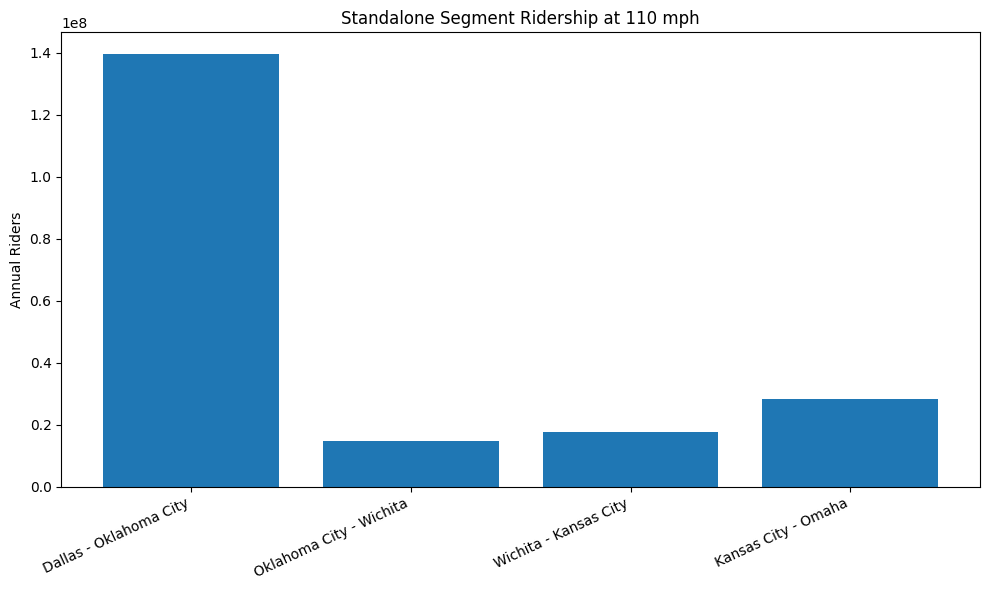

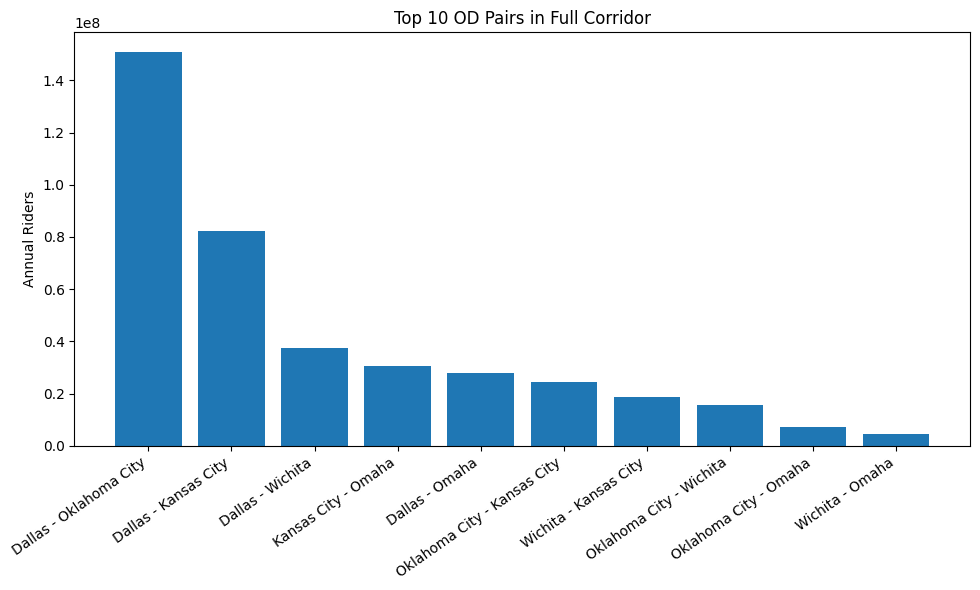

In [79]:
import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# GREAT PLAINS RAIL CORRIDOR MODEL
# Dallas -> Oklahoma City -> Wichita -> Kansas City -> Omaha
#
# Purpose:
#   1. Evaluate each segment as a standalone corridor
#   2. Evaluate the full multi-city corridor
#   3. Produce summary tables and simple plots
#
# Modeling style:
#   This is a planning-level, sketch model intended for scenario testing,
#   not a forecasting model for real-world procurement or grant work.
# ============================================================


@dataclass
class City:
    name: str
    population_metro: float  # in millions


@dataclass
class Segment:
    origin: str
    destination: str
    distance_miles: float


# -----------------------------
# USER-ADJUSTABLE PARAMETERS
# -----------------------------
SPEED_MPH = 110.0
DWELL_PER_INTERMEDIATE_STOP_HOURS = 0.08     # ~5 minutes
WAIT_TIME_HOURS = 0.25
TRANSFER_PENALTY_HOURS = 0.20
VALUE_OF_TIME_PER_HOUR = 20.0
FARE_PER_MILE = 0.25
TRIPS_PER_YEAR_FACTOR = 10.0                 # calibration factor
DEMAND_EXPONENT = 1.0
TIME_SENSITIVITY = 0.45                      # higher => travelers care more about time advantage
RAIL_SHARE_FLOOR = 0.03
RAIL_SHARE_CEILING = 0.72
ANNUALIZATION_FACTOR = 365.0

# Annual O&M and capex assumptions for 110 mph upgraded/regional rail.
ANNUAL_OM_PER_ROUTE_MILE_M = 0.10            # $0.10M per route-mile per year = $100k per mile
CAPEX_PER_ROUTE_MILE_M = 28.0                # $28M per route-mile

# Optional network uplift for full-corridor analysis.
NETWORK_UPLIFT = 1.08


# -----------------------------
# CORRIDOR DEFINITION
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
}

SEGMENTS: List[Segment] = [
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
    Segment("Kansas City", "Omaha", 190),
]

CORRIDOR_ORDER = [
    "Dallas",
    "Oklahoma City",
    "Wichita",
    "Kansas City",
    "Omaha",
]


# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def auto_travel_time_hours(distance_miles: float, avg_speed_mph: float = 68.0) -> float:
    """
    Approximate car travel time using an effective highway speed.
    """
    return distance_miles / avg_speed_mph


def rail_in_vehicle_time_hours(distance_miles: float, speed_mph: float = SPEED_MPH) -> float:
    return distance_miles / speed_mph


def generalized_rail_time_hours(
    distance_miles: float,
    intermediate_stops: int = 0,
    include_wait: bool = True,
    transfers: int = 0,
) -> float:
    time = rail_in_vehicle_time_hours(distance_miles)
    time += intermediate_stops * DWELL_PER_INTERMEDIATE_STOP_HOURS
    if include_wait:
        time += WAIT_TIME_HOURS
    time += transfers * TRANSFER_PENALTY_HOURS
    return time


def rail_share_function(auto_time: float, rail_time: float) -> float:
    """
    Smooth share response based on relative time competitiveness.

    share rises when rail time becomes more competitive with auto time.
    """
    ratio = auto_time / rail_time
    raw_share = 1.0 / (1.0 + math.exp(-6.0 * (ratio - 1.0)))
    share = RAIL_SHARE_FLOOR + (RAIL_SHARE_CEILING - RAIL_SHARE_FLOOR) * raw_share
    return max(RAIL_SHARE_FLOOR, min(RAIL_SHARE_CEILING, share))


def annual_trip_demand(pop_a_m: float, pop_b_m: float, distance_miles: float) -> float:
    """
    Planning-level gravity formulation.

    Demand rises with endpoint metro size and falls with distance.
    The calibration here is intentionally simple and tunable.
    """
    base = TRIPS_PER_YEAR_FACTOR * ((pop_a_m * 1_000_000) * (pop_b_m * 1_000_000))
    base /= (distance_miles ** DEMAND_EXPONENT)
    return base / 1_000_000  # keep numbers manageable before annualization scaling


def annual_rail_trips_between(
    origin: str,
    destination: str,
    distance_miles: float,
    intermediate_stops: int = 0,
    transfers: int = 0,
    network_uplift: float = 1.0,
) -> Dict[str, float]:
    pop_a = CITIES[origin].population_metro
    pop_b = CITIES[destination].population_metro

    auto_time = auto_travel_time_hours(distance_miles)
    rail_time = generalized_rail_time_hours(
        distance_miles=distance_miles,
        intermediate_stops=intermediate_stops,
        include_wait=True,
        transfers=transfers,
    )

    total_trips = annual_trip_demand(pop_a, pop_b, distance_miles) * ANNUALIZATION_FACTOR
    rail_share = rail_share_function(auto_time, rail_time)
    annual_riders = total_trips * rail_share * network_uplift

    revenue_m = annual_riders * distance_miles * FARE_PER_MILE / 1_000_000
    time_saved_hours = max(0.0, auto_time - rail_time)
    public_benefit_m = annual_riders * time_saved_hours * VALUE_OF_TIME_PER_HOUR / 1_000_000

    return {
        "origin": origin,
        "destination": destination,
        "distance_miles": distance_miles,
        "auto_time_hours": auto_time,
        "rail_time_hours": rail_time,
        "rail_share": rail_share,
        "annual_riders": annual_riders,
        "annual_revenue_m": revenue_m,
        "annual_public_benefit_m": public_benefit_m,
    }


def corridor_distance(origin: str, destination: str, ordered_stops: List[str], segments: List[Segment]) -> Tuple[float, int]:
    """
    Returns total route distance and number of intermediate stops between two cities
    along the defined corridor.
    """
    idx_a = ordered_stops.index(origin)
    idx_b = ordered_stops.index(destination)
    if idx_a > idx_b:
        idx_a, idx_b = idx_b, idx_a

    stop_slice = ordered_stops[idx_a:idx_b + 1]
    route_distance = 0.0
    for i in range(len(stop_slice) - 1):
        a = stop_slice[i]
        b = stop_slice[i + 1]
        match = next(s for s in segments if s.origin == a and s.destination == b)
        route_distance += match.distance_miles

    intermediate_stops = max(0, len(stop_slice) - 2)
    return route_distance, intermediate_stops


def segment_standalone_analysis(segments: List[Segment]) -> pd.DataFrame:
    rows = []
    for seg in segments:
        result = annual_rail_trips_between(
            origin=seg.origin,
            destination=seg.destination,
            distance_miles=seg.distance_miles,
            intermediate_stops=0,
            transfers=0,
            network_uplift=1.0,
        )
        om_m = seg.distance_miles * ANNUAL_OM_PER_ROUTE_MILE_M
        capex_m = seg.distance_miles * CAPEX_PER_ROUTE_MILE_M
        farebox_recovery = result["annual_revenue_m"] / om_m if om_m > 0 else 0.0
        bcr = (result["annual_revenue_m"] + result["annual_public_benefit_m"]) / om_m if om_m > 0 else 0.0

        rows.append({
            "segment": f"{seg.origin} - {seg.destination}",
            "distance_miles": seg.distance_miles,
            "travel_time_hours": result["rail_time_hours"],
            "auto_time_hours": result["auto_time_hours"],
            "rail_share": result["rail_share"],
            "annual_riders": result["annual_riders"],
            "annual_revenue_m": result["annual_revenue_m"],
            "annual_public_benefit_m": result["annual_public_benefit_m"],
            "annual_om_m": om_m,
            "farebox_recovery": farebox_recovery,
            "capex_m": capex_m,
            "bcr_like": bcr,
        })

    return pd.DataFrame(rows)


def full_corridor_analysis(ordered_stops: List[str], segments: List[Segment]) -> Tuple[pd.DataFrame, Dict[str, float]]:
    od_rows = []
    for origin, destination in combinations(ordered_stops, 2):
        route_distance, intermediate_stops = corridor_distance(origin, destination, ordered_stops, segments)
        result = annual_rail_trips_between(
            origin=origin,
            destination=destination,
            distance_miles=route_distance,
            intermediate_stops=intermediate_stops,
            transfers=0,
            network_uplift=NETWORK_UPLIFT,
        )
        od_rows.append(result)

    od_df = pd.DataFrame(od_rows)

    total_distance = sum(s.distance_miles for s in segments)
    total_om_m = total_distance * ANNUAL_OM_PER_ROUTE_MILE_M
    total_capex_m = total_distance * CAPEX_PER_ROUTE_MILE_M
    total_riders = od_df["annual_riders"].sum()
    total_revenue_m = od_df["annual_revenue_m"].sum()
    total_benefit_m = od_df["annual_public_benefit_m"].sum()
    farebox_recovery = total_revenue_m / total_om_m if total_om_m > 0 else 0.0
    bcr = (total_revenue_m + total_benefit_m) / total_om_m if total_om_m > 0 else 0.0

    summary = {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue_m,
        "annual_public_benefit_m": total_benefit_m,
        "annual_om_m": total_om_m,
        "farebox_recovery": farebox_recovery,
        "capex_m": total_capex_m,
        "bcr_like": bcr,
        "route_miles": total_distance,
    }

    return od_df.sort_values("annual_riders", ascending=False), summary


def print_section(title: str):
    print("\n" + "=" * 12 + f" {title} " + "=" * 12)


def format_results(segment_df: pd.DataFrame, od_df: pd.DataFrame, summary: Dict[str, float]):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

    print_section("SEGMENT STANDALONE ANALYSIS")
    print(segment_df)

    print_section("FULL CORRIDOR OD FLOWS")
    print(od_df)

    print_section("FULL CORRIDOR SUMMARY")
    for k, v in summary.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:,.3f}")
        else:
            print(f"{k}: {v}")


def plot_segment_riders(segment_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    plt.bar(segment_df["segment"], segment_df["annual_riders"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Annual Riders")
    plt.title("Standalone Segment Ridership at 110 mph")
    plt.tight_layout()
    plt.show()


def plot_od_riders(od_df: pd.DataFrame, top_n: int = 10):
    plot_df = od_df.head(top_n).copy()
    plot_df["pair"] = plot_df["origin"] + " - " + plot_df["destination"]

    plt.figure(figsize=(10, 6))
    plt.bar(plot_df["pair"], plot_df["annual_riders"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Annual Riders")
    plt.title(f"Top {top_n} OD Pairs in Full Corridor")
    plt.tight_layout()
    plt.show()


def main():
    segment_df = segment_standalone_analysis(SEGMENTS)
    od_df, summary = full_corridor_analysis(CORRIDOR_ORDER, SEGMENTS)
    format_results(segment_df, od_df, summary)

    # Export tables if desired
    segment_df.to_csv("great_plains_segment_analysis.csv", index=False)
    od_df.to_csv("great_plains_full_corridor_od.csv", index=False)

    # Optional plots
    plot_segment_riders(segment_df)
    plot_od_riders(od_df)


if __name__ == "__main__":
    main()



============ SEGMENT STANDALONE ANALYSIS ============
                   segment  distance_miles  travel_time_hours  auto_time_hours  rail_share  annual_riders  annual_revenue_m  annual_public_benefit_m  \
0   Dallas - Oklahoma City             205              2.114            3.015       0.670    306,090.049            15.687                    5.516   
1  Oklahoma City - Wichita             160              1.705            2.353       0.656     31,985.333             1.279                    0.415   
2    Wichita - Kansas City             200              2.068            2.941       0.669     38,279.109             1.914                    0.668   
3      Kansas City - Omaha             190              1.977            2.794       0.667     61,749.904             2.933                    1.009   

   annual_om_m  farebox_recovery   capex_m  bcr_like  
0       20.500             0.765 5,740.000     1.034  
1       16.000             0.080 4,480.000     0.106  
2       20.000     

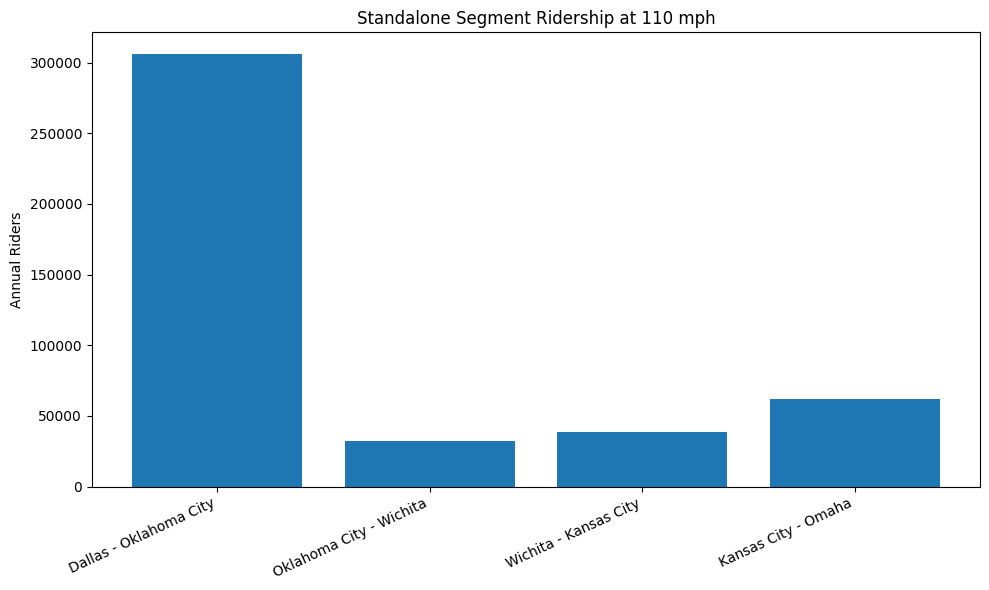

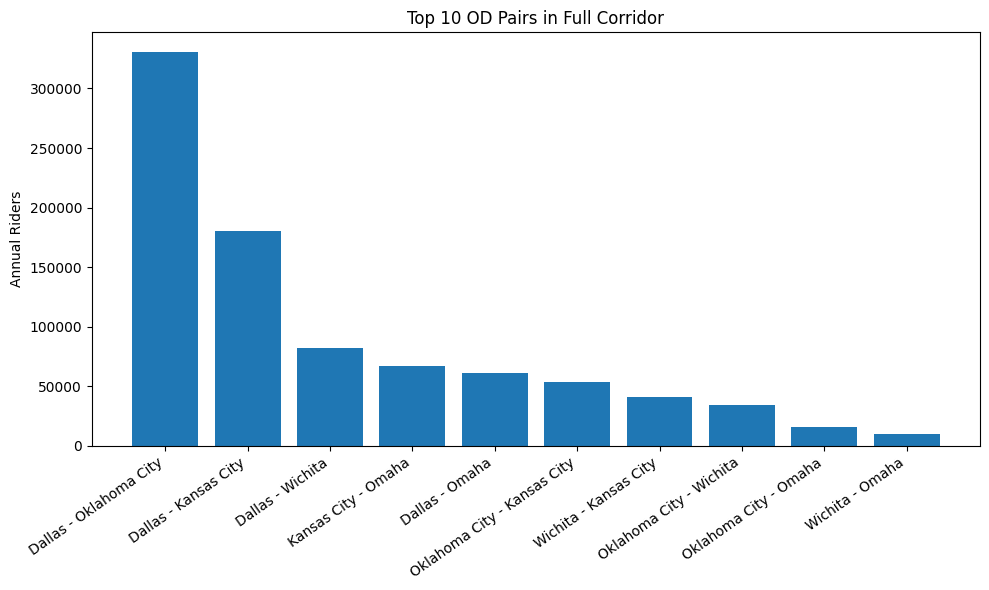

In [80]:
import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# GREAT PLAINS RAIL CORRIDOR MODEL
# Dallas -> Oklahoma City -> Wichita -> Kansas City -> Omaha
#
# Purpose:
#   1. Evaluate each segment as a standalone corridor
#   2. Evaluate the full multi-city corridor
#   3. Produce summary tables and simple plots
#
# Modeling style:
#   This is a planning-level, sketch model intended for scenario testing,
#   not a forecasting model for real-world procurement or grant work.
# ============================================================


@dataclass
class City:
    name: str
    population_metro: float  # in millions


@dataclass
class Segment:
    origin: str
    destination: str
    distance_miles: float


# -----------------------------
# USER-ADJUSTABLE PARAMETERS
# -----------------------------
SPEED_MPH = 110.0
DWELL_PER_INTERMEDIATE_STOP_HOURS = 0.08     # ~5 minutes
WAIT_TIME_HOURS = 0.25
TRANSFER_PENALTY_HOURS = 0.20
VALUE_OF_TIME_PER_HOUR = 20.0
FARE_PER_MILE = 0.25
TRIPS_PER_YEAR_FACTOR = 8_000_000.0         # annual gravity calibration constant
DEMAND_EXPONENT = 1.0
TIME_SENSITIVITY = 6.0                       # higher => travelers care more about time advantage
RAIL_SHARE_FLOOR = 0.03
RAIL_SHARE_CEILING = 0.72

# Annual O&M and capex assumptions for 110 mph upgraded/regional rail.
ANNUAL_OM_PER_ROUTE_MILE_M = 0.10            # $0.10M per route-mile per year = $100k per mile
CAPEX_PER_ROUTE_MILE_M = 28.0                # $28M per route-mile

# Optional network uplift for full-corridor analysis.
NETWORK_UPLIFT = 1.08


# -----------------------------
# CORRIDOR DEFINITION
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
}

SEGMENTS: List[Segment] = [
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
    Segment("Kansas City", "Omaha", 190),
]

CORRIDOR_ORDER = [
    "Dallas",
    "Oklahoma City",
    "Wichita",
    "Kansas City",
    "Omaha",
]


# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def auto_travel_time_hours(distance_miles: float, avg_speed_mph: float = 68.0) -> float:
    """
    Approximate car travel time using an effective highway speed.
    """
    return distance_miles / avg_speed_mph


def rail_in_vehicle_time_hours(distance_miles: float, speed_mph: float = SPEED_MPH) -> float:
    return distance_miles / speed_mph


def generalized_rail_time_hours(
    distance_miles: float,
    intermediate_stops: int = 0,
    include_wait: bool = True,
    transfers: int = 0,
) -> float:
    time = rail_in_vehicle_time_hours(distance_miles)
    time += intermediate_stops * DWELL_PER_INTERMEDIATE_STOP_HOURS
    if include_wait:
        time += WAIT_TIME_HOURS
    time += transfers * TRANSFER_PENALTY_HOURS
    return time


def rail_share_function(auto_time: float, rail_time: float) -> float:
    """
    Smooth share response based on relative time competitiveness.

    share rises when rail time becomes more competitive with auto time.
    """
    ratio = auto_time / rail_time
    raw_share = 1.0 / (1.0 + math.exp(-TIME_SENSITIVITY * (ratio - 1.0)))
    share = RAIL_SHARE_FLOOR + (RAIL_SHARE_CEILING - RAIL_SHARE_FLOOR) * raw_share
    return max(RAIL_SHARE_FLOOR, min(RAIL_SHARE_CEILING, share))


def annual_trip_demand(pop_a_m: float, pop_b_m: float, distance_miles: float) -> float:
    """
    Planning-level gravity formulation.

    This version returns ANNUAL total person-trips directly.
    Metro populations stay in millions, and the calibration constant handles scale.
    """
    return TRIPS_PER_YEAR_FACTOR * ((pop_a_m * pop_b_m) / (distance_miles ** DEMAND_EXPONENT))


def annual_rail_trips_between(
    origin: str,
    destination: str,
    distance_miles: float,
    intermediate_stops: int = 0,
    transfers: int = 0,
    network_uplift: float = 1.0,
) -> Dict[str, float]:
    pop_a = CITIES[origin].population_metro
    pop_b = CITIES[destination].population_metro

    auto_time = auto_travel_time_hours(distance_miles)
    rail_time = generalized_rail_time_hours(
        distance_miles=distance_miles,
        intermediate_stops=intermediate_stops,
        include_wait=True,
        transfers=transfers,
    )

    total_trips = annual_trip_demand(pop_a, pop_b, distance_miles)
    rail_share = rail_share_function(auto_time, rail_time)
    annual_riders = total_trips * rail_share * network_uplift

    revenue_m = annual_riders * distance_miles * FARE_PER_MILE / 1_000_000
    time_saved_hours = max(0.0, auto_time - rail_time)
    public_benefit_m = annual_riders * time_saved_hours * VALUE_OF_TIME_PER_HOUR / 1_000_000

    return {
        "origin": origin,
        "destination": destination,
        "distance_miles": distance_miles,
        "auto_time_hours": auto_time,
        "rail_time_hours": rail_time,
        "rail_share": rail_share,
        "annual_riders": annual_riders,
        "annual_revenue_m": revenue_m,
        "annual_public_benefit_m": public_benefit_m,
    }


def corridor_distance(origin: str, destination: str, ordered_stops: List[str], segments: List[Segment]) -> Tuple[float, int]:
    """
    Returns total route distance and number of intermediate stops between two cities
    along the defined corridor.
    """
    idx_a = ordered_stops.index(origin)
    idx_b = ordered_stops.index(destination)
    if idx_a > idx_b:
        idx_a, idx_b = idx_b, idx_a

    stop_slice = ordered_stops[idx_a:idx_b + 1]
    route_distance = 0.0
    for i in range(len(stop_slice) - 1):
        a = stop_slice[i]
        b = stop_slice[i + 1]
        match = next(s for s in segments if s.origin == a and s.destination == b)
        route_distance += match.distance_miles

    intermediate_stops = max(0, len(stop_slice) - 2)
    return route_distance, intermediate_stops


def segment_standalone_analysis(segments: List[Segment]) -> pd.DataFrame:
    rows = []
    for seg in segments:
        result = annual_rail_trips_between(
            origin=seg.origin,
            destination=seg.destination,
            distance_miles=seg.distance_miles,
            intermediate_stops=0,
            transfers=0,
            network_uplift=1.0,
        )
        om_m = seg.distance_miles * ANNUAL_OM_PER_ROUTE_MILE_M
        capex_m = seg.distance_miles * CAPEX_PER_ROUTE_MILE_M
        farebox_recovery = result["annual_revenue_m"] / om_m if om_m > 0 else 0.0
        bcr = (result["annual_revenue_m"] + result["annual_public_benefit_m"]) / om_m if om_m > 0 else 0.0

        rows.append({
            "segment": f"{seg.origin} - {seg.destination}",
            "distance_miles": seg.distance_miles,
            "travel_time_hours": result["rail_time_hours"],
            "auto_time_hours": result["auto_time_hours"],
            "rail_share": result["rail_share"],
            "annual_riders": result["annual_riders"],
            "annual_revenue_m": result["annual_revenue_m"],
            "annual_public_benefit_m": result["annual_public_benefit_m"],
            "annual_om_m": om_m,
            "farebox_recovery": farebox_recovery,
            "capex_m": capex_m,
            "bcr_like": bcr,
        })

    return pd.DataFrame(rows)


def full_corridor_analysis(ordered_stops: List[str], segments: List[Segment]) -> Tuple[pd.DataFrame, Dict[str, float]]:
    od_rows = []
    for origin, destination in combinations(ordered_stops, 2):
        route_distance, intermediate_stops = corridor_distance(origin, destination, ordered_stops, segments)
        result = annual_rail_trips_between(
            origin=origin,
            destination=destination,
            distance_miles=route_distance,
            intermediate_stops=intermediate_stops,
            transfers=0,
            network_uplift=NETWORK_UPLIFT,
        )
        od_rows.append(result)

    od_df = pd.DataFrame(od_rows)

    total_distance = sum(s.distance_miles for s in segments)
    total_om_m = total_distance * ANNUAL_OM_PER_ROUTE_MILE_M
    total_capex_m = total_distance * CAPEX_PER_ROUTE_MILE_M
    total_riders = od_df["annual_riders"].sum()
    total_revenue_m = od_df["annual_revenue_m"].sum()
    total_benefit_m = od_df["annual_public_benefit_m"].sum()
    farebox_recovery = total_revenue_m / total_om_m if total_om_m > 0 else 0.0
    bcr = (total_revenue_m + total_benefit_m) / total_om_m if total_om_m > 0 else 0.0

    summary = {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue_m,
        "annual_public_benefit_m": total_benefit_m,
        "annual_om_m": total_om_m,
        "farebox_recovery": farebox_recovery,
        "capex_m": total_capex_m,
        "bcr_like": bcr,
        "route_miles": total_distance,
    }

    return od_df.sort_values("annual_riders", ascending=False), summary


def print_section(title: str):
    print("\n" + "=" * 12 + f" {title} " + "=" * 12)


def format_results(segment_df: pd.DataFrame, od_df: pd.DataFrame, summary: Dict[str, float]):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

    print_section("SEGMENT STANDALONE ANALYSIS")
    print(segment_df)

    print_section("FULL CORRIDOR OD FLOWS")
    print(od_df)

    print_section("FULL CORRIDOR SUMMARY")
    for k, v in summary.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:,.3f}")
        else:
            print(f"{k}: {v}")


def plot_segment_riders(segment_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    plt.bar(segment_df["segment"], segment_df["annual_riders"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Annual Riders")
    plt.title("Standalone Segment Ridership at 110 mph")
    plt.tight_layout()
    plt.show()


def plot_od_riders(od_df: pd.DataFrame, top_n: int = 10):
    plot_df = od_df.head(top_n).copy()
    plot_df["pair"] = plot_df["origin"] + " - " + plot_df["destination"]

    plt.figure(figsize=(10, 6))
    plt.bar(plot_df["pair"], plot_df["annual_riders"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Annual Riders")
    plt.title(f"Top {top_n} OD Pairs in Full Corridor")
    plt.tight_layout()
    plt.show()


def main():
    segment_df = segment_standalone_analysis(SEGMENTS)
    od_df, summary = full_corridor_analysis(CORRIDOR_ORDER, SEGMENTS)
    format_results(segment_df, od_df, summary)

    # Export tables if desired
    segment_df.to_csv("great_plains_segment_analysis.csv", index=False)
    od_df.to_csv("great_plains_full_corridor_od.csv", index=False)

    # Optional plots
    plot_segment_riders(segment_df)
    plot_od_riders(od_df)


if __name__ == "__main__":
    main()



============ SEGMENT STANDALONE ANALYSIS ============
                       segment  distance_miles  travel_time_hours  auto_time_hours  rail_share  annual_riders  annual_revenue_m  annual_public_benefit_m  \
0       Dallas - Oklahoma City             205              1.617            3.015       0.716    326,993.330            16.758                    9.143   
1  Oklahoma City - Kansas City             360              2.650            5.294       0.718     52,673.212             4.741                    2.785   
2          Kansas City - Omaha             190              1.517            2.794       0.716     66,289.163             3.149                    1.694   

   annual_om_m  farebox_recovery    capex_m  bcr_like  
0       20.500             0.817  5,740.000     1.263  
1       36.000             0.132 10,080.000     0.209  
2       19.000             0.166  5,320.000     0.255  

============ FULL CORRIDOR OD FLOWS ============
          origin    destination  distance_mile

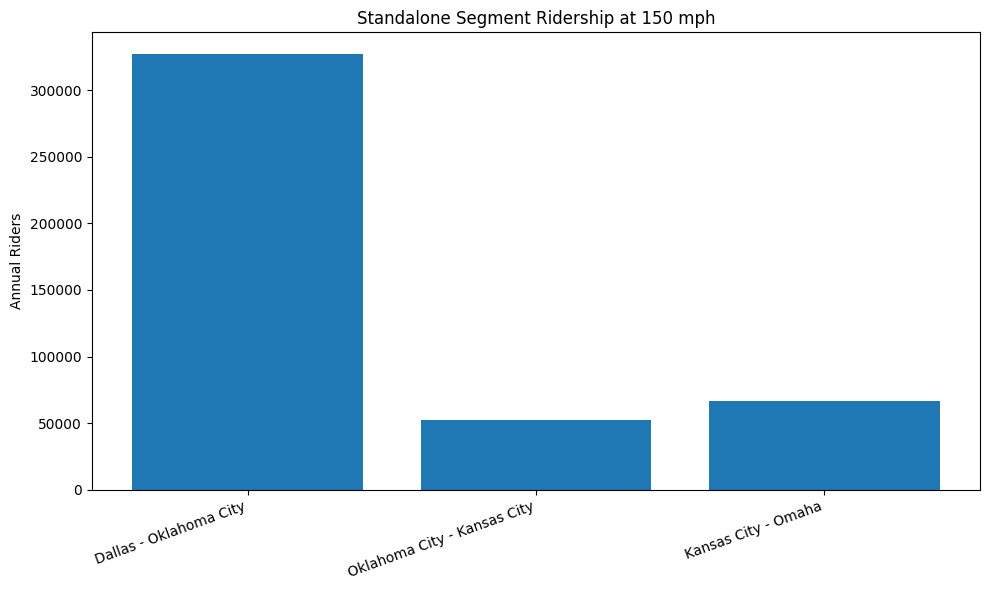

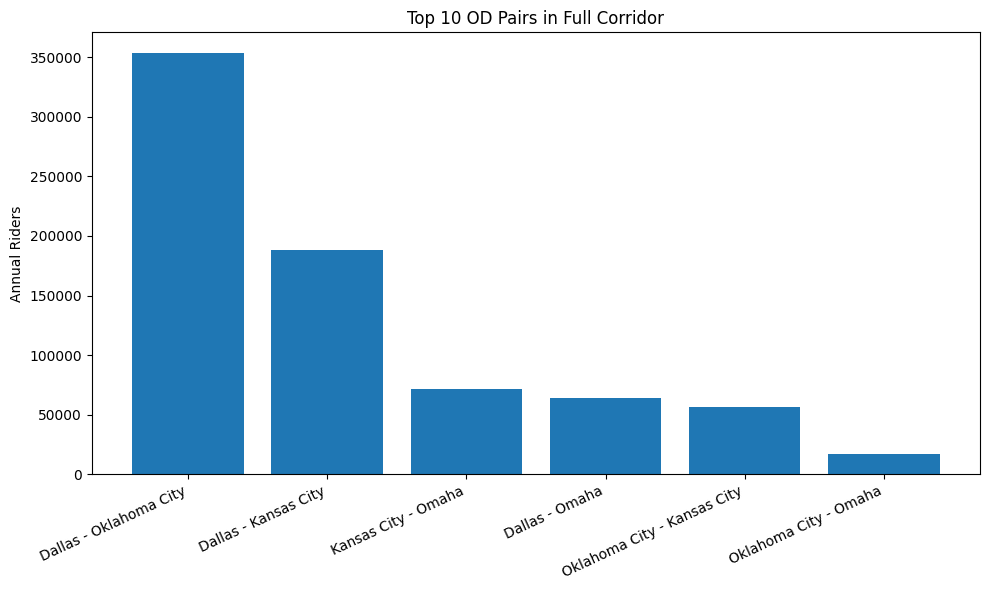

In [81]:
import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# GREAT PLAINS DIRECT CORRIDOR MODEL
# Dallas -> Oklahoma City -> Kansas City -> Omaha
#
# Purpose:
#   1. Evaluate each segment as a standalone corridor
#   2. Evaluate the full multi-city corridor
#   3. Produce summary tables and simple plots
#
# Current scenario:
#   - Wichita removed
#   - Operating speed increased to 150 mph
#
# This is a planning-level sketch model for scenario testing.
# ============================================================


@dataclass
class City:
    name: str
    population_metro: float  # in millions


@dataclass
class Segment:
    origin: str
    destination: str
    distance_miles: float


# -----------------------------
# USER-ADJUSTABLE PARAMETERS
# -----------------------------
SPEED_MPH = 150.0
DWELL_PER_INTERMEDIATE_STOP_HOURS = 0.08   # ~5 minutes
WAIT_TIME_HOURS = 0.25
TRANSFER_PENALTY_HOURS = 0.20
VALUE_OF_TIME_PER_HOUR = 20.0
FARE_PER_MILE = 0.25

# Demand calibration
TRIPS_PER_YEAR_FACTOR = 8_000_000.0
DEMAND_EXPONENT = 1.0
TIME_SENSITIVITY = 6.0
RAIL_SHARE_FLOOR = 0.03
RAIL_SHARE_CEILING = 0.72

# Cost assumptions
ANNUAL_OM_PER_ROUTE_MILE_M = 0.10          # $M per route-mile per year
CAPEX_PER_ROUTE_MILE_M = 28.0              # $M per route-mile

# Optional network uplift applied only in full-corridor analysis
NETWORK_UPLIFT = 1.08

# Approximate effective highway speed for car comparison
AUTO_SPEED_MPH = 68.0


# -----------------------------
# CORRIDOR DEFINITION
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
}

SEGMENTS: List[Segment] = [
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Kansas City", 360),
    Segment("Kansas City", "Omaha", 190),
]

CORRIDOR_ORDER = [
    "Dallas",
    "Oklahoma City",
    "Kansas City",
    "Omaha",
]


# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def auto_travel_time_hours(distance_miles: float, avg_speed_mph: float = AUTO_SPEED_MPH) -> float:
    return distance_miles / avg_speed_mph



def rail_in_vehicle_time_hours(distance_miles: float, speed_mph: float = SPEED_MPH) -> float:
    return distance_miles / speed_mph



def generalized_rail_time_hours(
    distance_miles: float,
    intermediate_stops: int = 0,
    include_wait: bool = True,
    transfers: int = 0,
) -> float:
    time = rail_in_vehicle_time_hours(distance_miles)
    time += intermediate_stops * DWELL_PER_INTERMEDIATE_STOP_HOURS
    if include_wait:
        time += WAIT_TIME_HOURS
    time += transfers * TRANSFER_PENALTY_HOURS
    return time



def rail_share_function(auto_time: float, rail_time: float) -> float:
    """
    Smooth share response based on relative time competitiveness.
    """
    ratio = auto_time / rail_time
    raw_share = 1.0 / (1.0 + math.exp(-TIME_SENSITIVITY * (ratio - 1.0)))
    share = RAIL_SHARE_FLOOR + (RAIL_SHARE_CEILING - RAIL_SHARE_FLOOR) * raw_share
    return max(RAIL_SHARE_FLOOR, min(RAIL_SHARE_CEILING, share))



def annual_trip_demand(pop_a_m: float, pop_b_m: float, distance_miles: float) -> float:
    """
    Planning-level gravity formulation.
    Returns ANNUAL total person-trips directly.
    """
    return TRIPS_PER_YEAR_FACTOR * ((pop_a_m * pop_b_m) / (distance_miles ** DEMAND_EXPONENT))



def annual_rail_trips_between(
    origin: str,
    destination: str,
    distance_miles: float,
    intermediate_stops: int = 0,
    transfers: int = 0,
    network_uplift: float = 1.0,
) -> Dict[str, float]:
    pop_a = CITIES[origin].population_metro
    pop_b = CITIES[destination].population_metro

    auto_time = auto_travel_time_hours(distance_miles)
    rail_time = generalized_rail_time_hours(
        distance_miles=distance_miles,
        intermediate_stops=intermediate_stops,
        include_wait=True,
        transfers=transfers,
    )

    total_trips = annual_trip_demand(pop_a, pop_b, distance_miles)
    rail_share = rail_share_function(auto_time, rail_time)
    annual_riders = total_trips * rail_share * network_uplift

    revenue_m = annual_riders * distance_miles * FARE_PER_MILE / 1_000_000
    time_saved_hours = max(0.0, auto_time - rail_time)
    public_benefit_m = annual_riders * time_saved_hours * VALUE_OF_TIME_PER_HOUR / 1_000_000

    return {
        "origin": origin,
        "destination": destination,
        "distance_miles": distance_miles,
        "auto_time_hours": auto_time,
        "rail_time_hours": rail_time,
        "rail_share": rail_share,
        "annual_riders": annual_riders,
        "annual_revenue_m": revenue_m,
        "annual_public_benefit_m": public_benefit_m,
    }



def corridor_distance(origin: str, destination: str, ordered_stops: List[str], segments: List[Segment]) -> Tuple[float, int]:
    """
    Returns total route distance and number of intermediate stops between two cities
    along the defined corridor.
    """
    idx_a = ordered_stops.index(origin)
    idx_b = ordered_stops.index(destination)
    if idx_a > idx_b:
        idx_a, idx_b = idx_b, idx_a

    stop_slice = ordered_stops[idx_a:idx_b + 1]
    route_distance = 0.0
    for i in range(len(stop_slice) - 1):
        a = stop_slice[i]
        b = stop_slice[i + 1]
        match = next(s for s in segments if s.origin == a and s.destination == b)
        route_distance += match.distance_miles

    intermediate_stops = max(0, len(stop_slice) - 2)
    return route_distance, intermediate_stops



def segment_standalone_analysis(segments: List[Segment]) -> pd.DataFrame:
    rows = []
    for seg in segments:
        result = annual_rail_trips_between(
            origin=seg.origin,
            destination=seg.destination,
            distance_miles=seg.distance_miles,
            intermediate_stops=0,
            transfers=0,
            network_uplift=1.0,
        )
        om_m = seg.distance_miles * ANNUAL_OM_PER_ROUTE_MILE_M
        capex_m = seg.distance_miles * CAPEX_PER_ROUTE_MILE_M
        farebox_recovery = result["annual_revenue_m"] / om_m if om_m > 0 else 0.0
        bcr_like = (result["annual_revenue_m"] + result["annual_public_benefit_m"]) / om_m if om_m > 0 else 0.0

        rows.append({
            "segment": f"{seg.origin} - {seg.destination}",
            "distance_miles": seg.distance_miles,
            "travel_time_hours": result["rail_time_hours"],
            "auto_time_hours": result["auto_time_hours"],
            "rail_share": result["rail_share"],
            "annual_riders": result["annual_riders"],
            "annual_revenue_m": result["annual_revenue_m"],
            "annual_public_benefit_m": result["annual_public_benefit_m"],
            "annual_om_m": om_m,
            "farebox_recovery": farebox_recovery,
            "capex_m": capex_m,
            "bcr_like": bcr_like,
        })

    return pd.DataFrame(rows)



def full_corridor_analysis(ordered_stops: List[str], segments: List[Segment]) -> Tuple[pd.DataFrame, Dict[str, float]]:
    od_rows = []
    for origin, destination in combinations(ordered_stops, 2):
        route_distance, intermediate_stops = corridor_distance(origin, destination, ordered_stops, segments)
        result = annual_rail_trips_between(
            origin=origin,
            destination=destination,
            distance_miles=route_distance,
            intermediate_stops=intermediate_stops,
            transfers=0,
            network_uplift=NETWORK_UPLIFT,
        )
        od_rows.append(result)

    od_df = pd.DataFrame(od_rows)

    total_distance = sum(s.distance_miles for s in segments)
    total_om_m = total_distance * ANNUAL_OM_PER_ROUTE_MILE_M
    total_capex_m = total_distance * CAPEX_PER_ROUTE_MILE_M
    total_riders = od_df["annual_riders"].sum()
    total_revenue_m = od_df["annual_revenue_m"].sum()
    total_benefit_m = od_df["annual_public_benefit_m"].sum()
    farebox_recovery = total_revenue_m / total_om_m if total_om_m > 0 else 0.0
    bcr_like = (total_revenue_m + total_benefit_m) / total_om_m if total_om_m > 0 else 0.0

    summary = {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue_m,
        "annual_public_benefit_m": total_benefit_m,
        "annual_om_m": total_om_m,
        "farebox_recovery": farebox_recovery,
        "capex_m": total_capex_m,
        "bcr_like": bcr_like,
        "route_miles": total_distance,
    }

    return od_df.sort_values("annual_riders", ascending=False), summary



def print_section(title: str):
    print("\n" + "=" * 12 + f" {title} " + "=" * 12)



def format_results(segment_df: pd.DataFrame, od_df: pd.DataFrame, summary: Dict[str, float]):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

    print_section("SEGMENT STANDALONE ANALYSIS")
    print(segment_df)

    print_section("FULL CORRIDOR OD FLOWS")
    print(od_df)

    print_section("FULL CORRIDOR SUMMARY")
    for k, v in summary.items():
        print(f"{k}: {v:,.3f}")



def plot_segment_riders(segment_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    plt.bar(segment_df["segment"], segment_df["annual_riders"])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Annual Riders")
    plt.title("Standalone Segment Ridership at 150 mph")
    plt.tight_layout()
    plt.show()



def plot_od_riders(od_df: pd.DataFrame, top_n: int = 10):
    plot_df = od_df.head(top_n).copy()
    plot_df["pair"] = plot_df["origin"] + " - " + plot_df["destination"]

    plt.figure(figsize=(10, 6))
    plt.bar(plot_df["pair"], plot_df["annual_riders"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Annual Riders")
    plt.title(f"Top {top_n} OD Pairs in Full Corridor")
    plt.tight_layout()
    plt.show()



def main():
    segment_df = segment_standalone_analysis(SEGMENTS)
    od_df, summary = full_corridor_analysis(CORRIDOR_ORDER, SEGMENTS)

    format_results(segment_df, od_df, summary)

    # Exports
    segment_df.to_csv("great_plains_direct_segment_analysis.csv", index=False)
    od_df.to_csv("great_plains_direct_full_corridor_od.csv", index=False)

    # Plots
    plot_segment_riders(segment_df)
    plot_od_riders(od_df)


if __name__ == "__main__":
    main()



============ SEGMENT STANDALONE ANALYSIS ============
                   segment  distance_miles  travel_time_hours  auto_time_hours  rail_share  annual_riders  annual_revenue_m  annual_public_benefit_m  \
0   Dallas - Oklahoma City             205              1.617            3.015       0.716    326,993.330            16.758                    9.143   
1  Oklahoma City - Wichita             160              1.317            2.353       0.714     34,803.432             1.392                    0.721   
2    Wichita - Kansas City             200              1.583            2.941       0.716     40,955.411             2.048                    1.112   
3      Kansas City - Omaha             190              1.517            2.794       0.716     66,289.163             3.149                    1.694   

   annual_om_m  farebox_recovery   capex_m  bcr_like  
0       20.500             0.817 5,740.000     1.263  
1       16.000             0.087 4,480.000     0.132  
2       20.000     

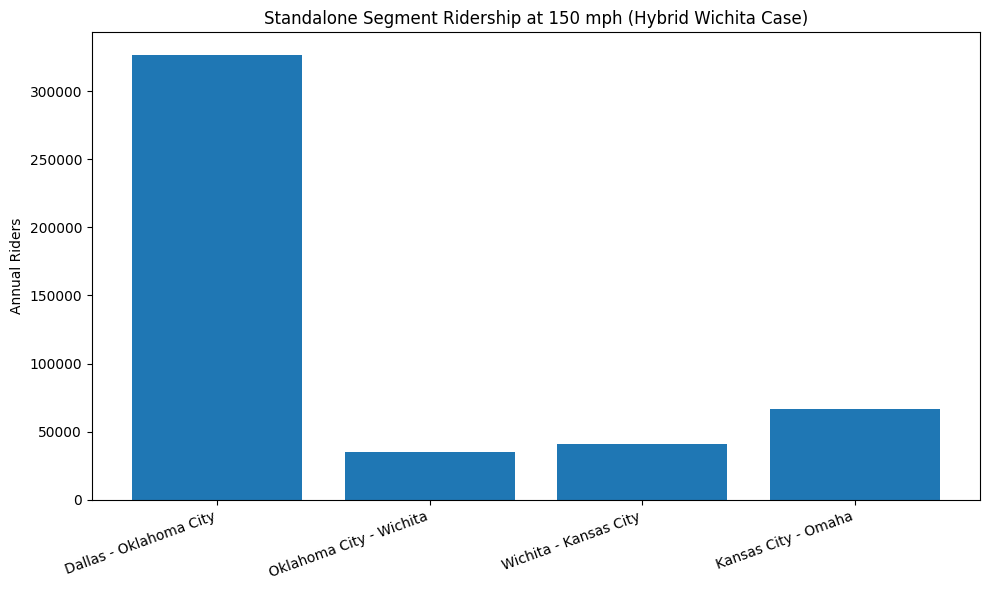

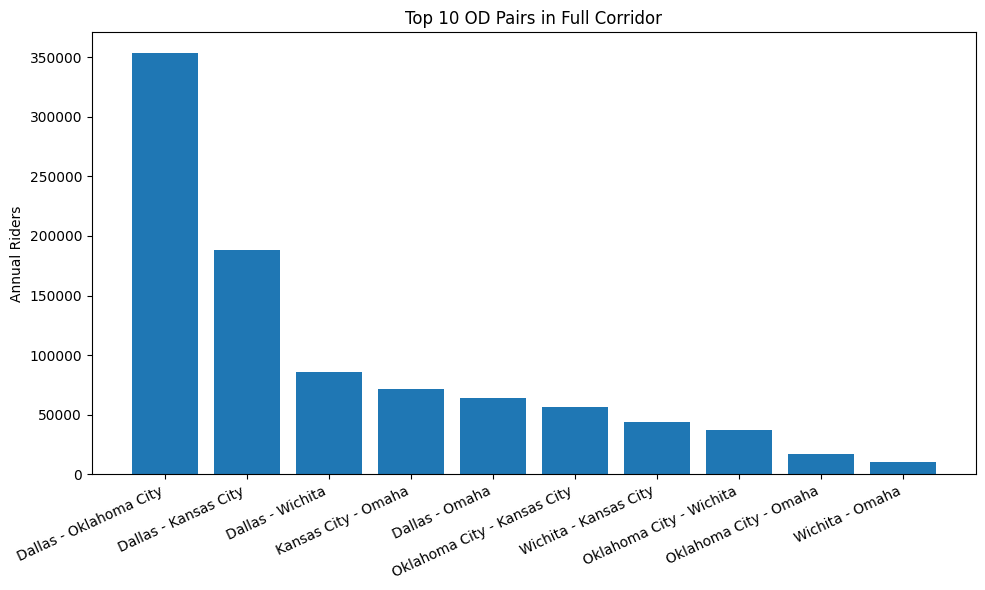

In [82]:
import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# GREAT PLAINS HYBRID CORRIDOR MODEL
# Dallas -> Oklahoma City -> Wichita -> Kansas City -> Omaha
#
# Purpose:
#   1. Evaluate each segment as a standalone corridor
#   2. Evaluate the full multi-city corridor
#   3. Produce summary tables and simple plots
#
# Current scenario:
#   - Wichita restored
#   - Operating speed set to 150 mph
#
# This is a planning-level sketch model for scenario testing.
# ============================================================


@dataclass
class City:
    name: str
    population_metro: float  # in millions


@dataclass
class Segment:
    origin: str
    destination: str
    distance_miles: float


# -----------------------------
# USER-ADJUSTABLE PARAMETERS
# -----------------------------
SPEED_MPH = 150.0
DWELL_PER_INTERMEDIATE_STOP_HOURS = 0.08   # ~5 minutes
WAIT_TIME_HOURS = 0.25
TRANSFER_PENALTY_HOURS = 0.20
VALUE_OF_TIME_PER_HOUR = 20.0
FARE_PER_MILE = 0.25

# Demand calibration
TRIPS_PER_YEAR_FACTOR = 8_000_000.0
DEMAND_EXPONENT = 1.0
TIME_SENSITIVITY = 6.0
RAIL_SHARE_FLOOR = 0.03
RAIL_SHARE_CEILING = 0.72

# Cost assumptions
ANNUAL_OM_PER_ROUTE_MILE_M = 0.10          # $M per route-mile per year
CAPEX_PER_ROUTE_MILE_M = 28.0              # $M per route-mile

# Optional network uplift applied only in full-corridor analysis
NETWORK_UPLIFT = 1.08

# Approximate effective highway speed for car comparison
AUTO_SPEED_MPH = 68.0


# -----------------------------
# CORRIDOR DEFINITION
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
}

SEGMENTS: List[Segment] = [
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
    Segment("Kansas City", "Omaha", 190),
]

CORRIDOR_ORDER = [
    "Dallas",
    "Oklahoma City",
    "Wichita",
    "Kansas City",
    "Omaha",
]


# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def auto_travel_time_hours(distance_miles: float, avg_speed_mph: float = AUTO_SPEED_MPH) -> float:
    return distance_miles / avg_speed_mph



def rail_in_vehicle_time_hours(distance_miles: float, speed_mph: float = SPEED_MPH) -> float:
    return distance_miles / speed_mph



def generalized_rail_time_hours(
    distance_miles: float,
    intermediate_stops: int = 0,
    include_wait: bool = True,
    transfers: int = 0,
) -> float:
    time = rail_in_vehicle_time_hours(distance_miles)
    time += intermediate_stops * DWELL_PER_INTERMEDIATE_STOP_HOURS
    if include_wait:
        time += WAIT_TIME_HOURS
    time += transfers * TRANSFER_PENALTY_HOURS
    return time



def rail_share_function(auto_time: float, rail_time: float) -> float:
    """
    Smooth share response based on relative time competitiveness.
    """
    ratio = auto_time / rail_time
    raw_share = 1.0 / (1.0 + math.exp(-TIME_SENSITIVITY * (ratio - 1.0)))
    share = RAIL_SHARE_FLOOR + (RAIL_SHARE_CEILING - RAIL_SHARE_FLOOR) * raw_share
    return max(RAIL_SHARE_FLOOR, min(RAIL_SHARE_CEILING, share))



def annual_trip_demand(pop_a_m: float, pop_b_m: float, distance_miles: float) -> float:
    """
    Planning-level gravity formulation.
    Returns ANNUAL total person-trips directly.
    """
    return TRIPS_PER_YEAR_FACTOR * ((pop_a_m * pop_b_m) / (distance_miles ** DEMAND_EXPONENT))



def annual_rail_trips_between(
    origin: str,
    destination: str,
    distance_miles: float,
    intermediate_stops: int = 0,
    transfers: int = 0,
    network_uplift: float = 1.0,
) -> Dict[str, float]:
    pop_a = CITIES[origin].population_metro
    pop_b = CITIES[destination].population_metro

    auto_time = auto_travel_time_hours(distance_miles)
    rail_time = generalized_rail_time_hours(
        distance_miles=distance_miles,
        intermediate_stops=intermediate_stops,
        include_wait=True,
        transfers=transfers,
    )

    total_trips = annual_trip_demand(pop_a, pop_b, distance_miles)
    rail_share = rail_share_function(auto_time, rail_time)
    annual_riders = total_trips * rail_share * network_uplift

    revenue_m = annual_riders * distance_miles * FARE_PER_MILE / 1_000_000
    time_saved_hours = max(0.0, auto_time - rail_time)
    public_benefit_m = annual_riders * time_saved_hours * VALUE_OF_TIME_PER_HOUR / 1_000_000

    return {
        "origin": origin,
        "destination": destination,
        "distance_miles": distance_miles,
        "auto_time_hours": auto_time,
        "rail_time_hours": rail_time,
        "rail_share": rail_share,
        "annual_riders": annual_riders,
        "annual_revenue_m": revenue_m,
        "annual_public_benefit_m": public_benefit_m,
    }



def corridor_distance(origin: str, destination: str, ordered_stops: List[str], segments: List[Segment]) -> Tuple[float, int]:
    """
    Returns total route distance and number of intermediate stops between two cities
    along the defined corridor.
    """
    idx_a = ordered_stops.index(origin)
    idx_b = ordered_stops.index(destination)
    if idx_a > idx_b:
        idx_a, idx_b = idx_b, idx_a

    stop_slice = ordered_stops[idx_a:idx_b + 1]
    route_distance = 0.0
    for i in range(len(stop_slice) - 1):
        a = stop_slice[i]
        b = stop_slice[i + 1]
        match = next(s for s in segments if s.origin == a and s.destination == b)
        route_distance += match.distance_miles

    intermediate_stops = max(0, len(stop_slice) - 2)
    return route_distance, intermediate_stops



def segment_standalone_analysis(segments: List[Segment]) -> pd.DataFrame:
    rows = []
    for seg in segments:
        result = annual_rail_trips_between(
            origin=seg.origin,
            destination=seg.destination,
            distance_miles=seg.distance_miles,
            intermediate_stops=0,
            transfers=0,
            network_uplift=1.0,
        )
        om_m = seg.distance_miles * ANNUAL_OM_PER_ROUTE_MILE_M
        capex_m = seg.distance_miles * CAPEX_PER_ROUTE_MILE_M
        farebox_recovery = result["annual_revenue_m"] / om_m if om_m > 0 else 0.0
        bcr_like = (result["annual_revenue_m"] + result["annual_public_benefit_m"]) / om_m if om_m > 0 else 0.0

        rows.append({
            "segment": f"{seg.origin} - {seg.destination}",
            "distance_miles": seg.distance_miles,
            "travel_time_hours": result["rail_time_hours"],
            "auto_time_hours": result["auto_time_hours"],
            "rail_share": result["rail_share"],
            "annual_riders": result["annual_riders"],
            "annual_revenue_m": result["annual_revenue_m"],
            "annual_public_benefit_m": result["annual_public_benefit_m"],
            "annual_om_m": om_m,
            "farebox_recovery": farebox_recovery,
            "capex_m": capex_m,
            "bcr_like": bcr_like,
        })

    return pd.DataFrame(rows)



def full_corridor_analysis(ordered_stops: List[str], segments: List[Segment]) -> Tuple[pd.DataFrame, Dict[str, float]]:
    od_rows = []
    for origin, destination in combinations(ordered_stops, 2):
        route_distance, intermediate_stops = corridor_distance(origin, destination, ordered_stops, segments)
        result = annual_rail_trips_between(
            origin=origin,
            destination=destination,
            distance_miles=route_distance,
            intermediate_stops=intermediate_stops,
            transfers=0,
            network_uplift=NETWORK_UPLIFT,
        )
        od_rows.append(result)

    od_df = pd.DataFrame(od_rows)

    total_distance = sum(s.distance_miles for s in segments)
    total_om_m = total_distance * ANNUAL_OM_PER_ROUTE_MILE_M
    total_capex_m = total_distance * CAPEX_PER_ROUTE_MILE_M
    total_riders = od_df["annual_riders"].sum()
    total_revenue_m = od_df["annual_revenue_m"].sum()
    total_benefit_m = od_df["annual_public_benefit_m"].sum()
    farebox_recovery = total_revenue_m / total_om_m if total_om_m > 0 else 0.0
    bcr_like = (total_revenue_m + total_benefit_m) / total_om_m if total_om_m > 0 else 0.0

    summary = {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue_m,
        "annual_public_benefit_m": total_benefit_m,
        "annual_om_m": total_om_m,
        "farebox_recovery": farebox_recovery,
        "capex_m": total_capex_m,
        "bcr_like": bcr_like,
        "route_miles": total_distance,
    }

    return od_df.sort_values("annual_riders", ascending=False), summary



def print_section(title: str):
    print("\n" + "=" * 12 + f" {title} " + "=" * 12)



def format_results(segment_df: pd.DataFrame, od_df: pd.DataFrame, summary: Dict[str, float]):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 160)
    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

    print_section("SEGMENT STANDALONE ANALYSIS")
    print(segment_df)

    print_section("FULL CORRIDOR OD FLOWS")
    print(od_df)

    print_section("FULL CORRIDOR SUMMARY")
    for k, v in summary.items():
        print(f"{k}: {v:,.3f}")



def plot_segment_riders(segment_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    plt.bar(segment_df["segment"], segment_df["annual_riders"])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Annual Riders")
    plt.title("Standalone Segment Ridership at 150 mph (Hybrid Wichita Case)")
    plt.tight_layout()
    plt.show()



def plot_od_riders(od_df: pd.DataFrame, top_n: int = 10):
    plot_df = od_df.head(top_n).copy()
    plot_df["pair"] = plot_df["origin"] + " - " + plot_df["destination"]

    plt.figure(figsize=(10, 6))
    plt.bar(plot_df["pair"], plot_df["annual_riders"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Annual Riders")
    plt.title(f"Top {top_n} OD Pairs in Full Corridor")
    plt.tight_layout()
    plt.show()



def main():
    segment_df = segment_standalone_analysis(SEGMENTS)
    od_df, summary = full_corridor_analysis(CORRIDOR_ORDER, SEGMENTS)

    format_results(segment_df, od_df, summary)

    # Exports
    segment_df.to_csv("great_plains_hybrid_segment_analysis.csv", index=False)
    od_df.to_csv("great_plains_hybrid_full_corridor_od.csv", index=False)

    # Plots
    plot_segment_riders(segment_df)
    plot_od_riders(od_df)


if __name__ == "__main__":
    main()



============ KC_Peoria_Chicago - SEGMENT STANDALONE ANALYSIS ============
            scenario                  segment  distance_miles  travel_time_hours  auto_time_hours  rail_share  annual_riders  annual_revenue_m  annual_public_benefit_m  \
0  KC_Peoria_Chicago   Dallas - Oklahoma City             205              1.617            3.015       0.716    326,993.330            16.758                    9.143   
1  KC_Peoria_Chicago  Oklahoma City - Wichita             160              1.317            2.353       0.714     34,803.432             1.392                    0.721   
2  KC_Peoria_Chicago    Wichita - Kansas City             200              1.583            2.941       0.716     40,955.411             2.048                    1.112   
3  KC_Peoria_Chicago      Kansas City - Omaha             190              1.517            2.794       0.716     66,289.163             3.149                    1.694   
4  KC_Peoria_Chicago     Kansas City - Peoria             330         

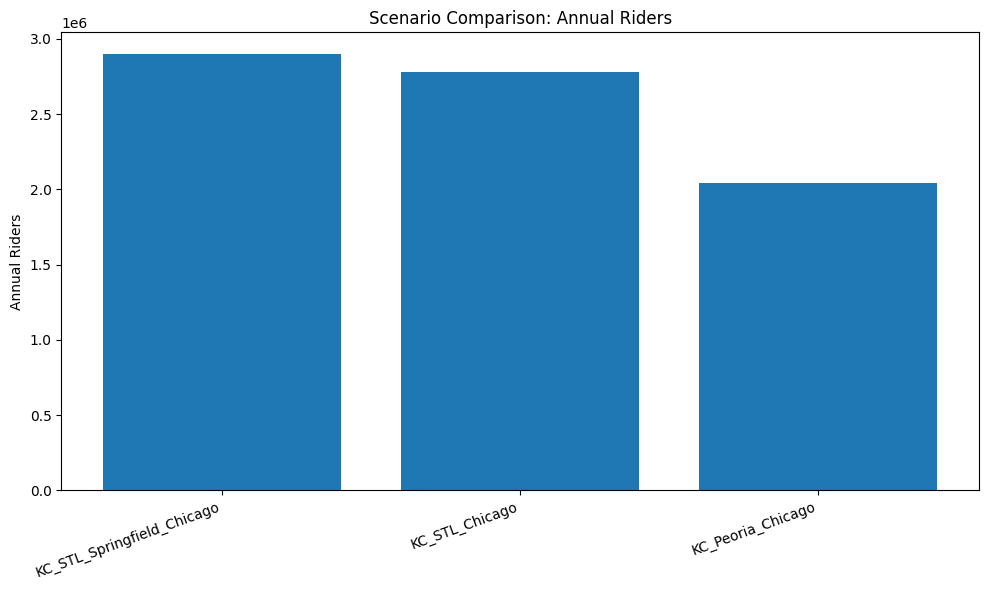

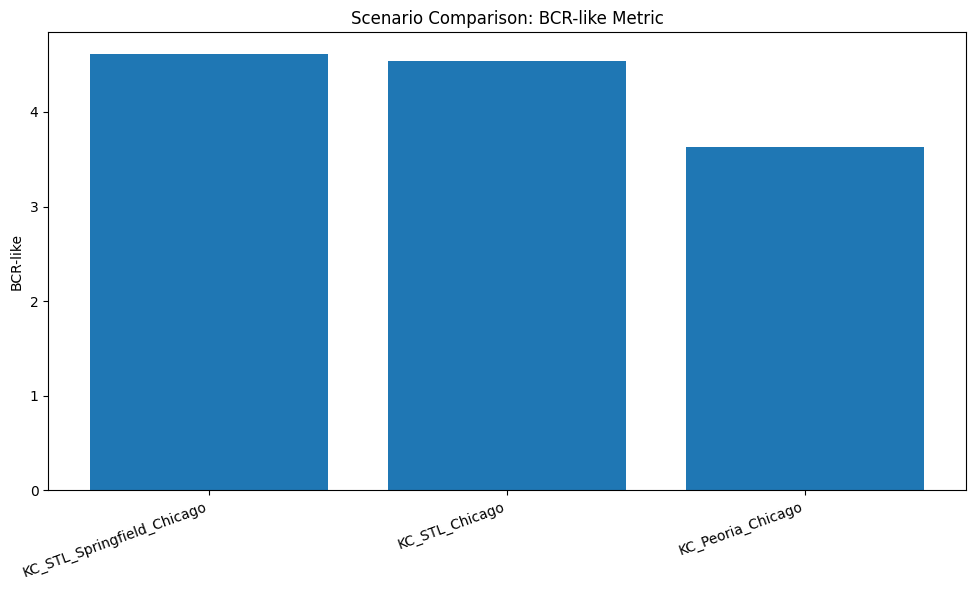

In [83]:
import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# GREAT PLAINS + MIDWEST EXTENSION SCENARIO MODEL
#
# Base spine:
#   Dallas -> Oklahoma City -> Wichita -> Kansas City -> Omaha
#
# Chicago extension scenarios:
#   A. Kansas City -> Peoria -> Chicago
#   B. Kansas City -> St. Louis -> Chicago
#   C. Kansas City -> St. Louis -> Springfield (IL) -> Chicago
#
# Purpose:
#   1. Evaluate standalone segments for each scenario
#   2. Evaluate full-corridor OD flows for each scenario
#   3. Compare total riders, revenue, benefits, O&M, farebox, and BCR-like output
# ============================================================


@dataclass
class City:
    name: str
    population_metro: float  # in millions


@dataclass
class Segment:
    origin: str
    destination: str
    distance_miles: float


# -----------------------------
# USER-ADJUSTABLE PARAMETERS
# -----------------------------
SPEED_MPH = 150.0
DWELL_PER_INTERMEDIATE_STOP_HOURS = 0.08
WAIT_TIME_HOURS = 0.25
TRANSFER_PENALTY_HOURS = 0.20
VALUE_OF_TIME_PER_HOUR = 20.0
FARE_PER_MILE = 0.25

TRIPS_PER_YEAR_FACTOR = 8_000_000.0
DEMAND_EXPONENT = 1.0
TIME_SENSITIVITY = 6.0
RAIL_SHARE_FLOOR = 0.03
RAIL_SHARE_CEILING = 0.72

ANNUAL_OM_PER_ROUTE_MILE_M = 0.10
CAPEX_PER_ROUTE_MILE_M = 28.0
NETWORK_UPLIFT = 1.08
AUTO_SPEED_MPH = 68.0


# -----------------------------
# CITY DEFINITIONS
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
    "Peoria": City("Peoria", 0.40),
    "St. Louis": City("St. Louis", 2.8),
    "Springfield IL": City("Springfield IL", 0.20),
    "Chicago": City("Chicago", 9.5),
}


# -----------------------------
# SCENARIO DEFINITIONS
# -----------------------------
BASE_SEGMENTS: List[Segment] = [
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
    Segment("Kansas City", "Omaha", 190),
]

BASE_ORDER: List[str] = [
    "Dallas",
    "Oklahoma City",
    "Wichita",
    "Kansas City",
    "Omaha",
]

SCENARIOS = {
    "KC_Peoria_Chicago": {
        "added_segments": [
            Segment("Kansas City", "Peoria", 330),
            Segment("Peoria", "Chicago", 175),
        ],
        "order": [
            "Dallas",
            "Oklahoma City",
            "Wichita",
            "Kansas City",
            "Peoria",
            "Chicago",
            "Omaha",
        ],
    },
    "KC_STL_Chicago": {
        "added_segments": [
            Segment("Kansas City", "St. Louis", 250),
            Segment("St. Louis", "Chicago", 300),
        ],
        "order": [
            "Dallas",
            "Oklahoma City",
            "Wichita",
            "Kansas City",
            "St. Louis",
            "Chicago",
            "Omaha",
        ],
    },
    "KC_STL_Springfield_Chicago": {
        "added_segments": [
            Segment("Kansas City", "St. Louis", 250),
            Segment("St. Louis", "Springfield IL", 100),
            Segment("Springfield IL", "Chicago", 200),
        ],
        "order": [
            "Dallas",
            "Oklahoma City",
            "Wichita",
            "Kansas City",
            "St. Louis",
            "Springfield IL",
            "Chicago",
            "Omaha",
        ],
    },
}


# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def auto_travel_time_hours(distance_miles: float, avg_speed_mph: float = AUTO_SPEED_MPH) -> float:
    return distance_miles / avg_speed_mph



def rail_in_vehicle_time_hours(distance_miles: float, speed_mph: float = SPEED_MPH) -> float:
    return distance_miles / speed_mph



def generalized_rail_time_hours(
    distance_miles: float,
    intermediate_stops: int = 0,
    include_wait: bool = True,
    transfers: int = 0,
) -> float:
    time = rail_in_vehicle_time_hours(distance_miles)
    time += intermediate_stops * DWELL_PER_INTERMEDIATE_STOP_HOURS
    if include_wait:
        time += WAIT_TIME_HOURS
    time += transfers * TRANSFER_PENALTY_HOURS
    return time



def rail_share_function(auto_time: float, rail_time: float) -> float:
    ratio = auto_time / rail_time
    raw_share = 1.0 / (1.0 + math.exp(-TIME_SENSITIVITY * (ratio - 1.0)))
    share = RAIL_SHARE_FLOOR + (RAIL_SHARE_CEILING - RAIL_SHARE_FLOOR) * raw_share
    return max(RAIL_SHARE_FLOOR, min(RAIL_SHARE_CEILING, share))



def annual_trip_demand(pop_a_m: float, pop_b_m: float, distance_miles: float) -> float:
    return TRIPS_PER_YEAR_FACTOR * ((pop_a_m * pop_b_m) / (distance_miles ** DEMAND_EXPONENT))



def annual_rail_trips_between(
    origin: str,
    destination: str,
    distance_miles: float,
    intermediate_stops: int = 0,
    transfers: int = 0,
    network_uplift: float = 1.0,
) -> Dict[str, float]:
    pop_a = CITIES[origin].population_metro
    pop_b = CITIES[destination].population_metro

    auto_time = auto_travel_time_hours(distance_miles)
    rail_time = generalized_rail_time_hours(
        distance_miles=distance_miles,
        intermediate_stops=intermediate_stops,
        include_wait=True,
        transfers=transfers,
    )

    total_trips = annual_trip_demand(pop_a, pop_b, distance_miles)
    rail_share = rail_share_function(auto_time, rail_time)
    annual_riders = total_trips * rail_share * network_uplift

    revenue_m = annual_riders * distance_miles * FARE_PER_MILE / 1_000_000
    time_saved_hours = max(0.0, auto_time - rail_time)
    public_benefit_m = annual_riders * time_saved_hours * VALUE_OF_TIME_PER_HOUR / 1_000_000

    return {
        "origin": origin,
        "destination": destination,
        "distance_miles": distance_miles,
        "auto_time_hours": auto_time,
        "rail_time_hours": rail_time,
        "rail_share": rail_share,
        "annual_riders": annual_riders,
        "annual_revenue_m": revenue_m,
        "annual_public_benefit_m": public_benefit_m,
    }



def build_segment_lookup(segments: List[Segment]) -> Dict[Tuple[str, str], float]:
    lookup: Dict[Tuple[str, str], float] = {}
    for seg in segments:
        lookup[(seg.origin, seg.destination)] = seg.distance_miles
    return lookup



def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for seg in segments:
        graph.setdefault(seg.origin, []).append((seg.destination, seg.distance_miles))
        graph.setdefault(seg.destination, []).append((seg.origin, seg.distance_miles))
    return graph


def corridor_distance(origin: str, destination: str, ordered_stops: List[str], segments: List[Segment]) -> Tuple[float, int]:
    """
    Find the path distance between two nodes in the network.
    This supports branch structures such as Omaha branching from Kansas City.
    """
    graph = build_graph(segments)

    stack = [(origin, 0.0, [origin])]

    while stack:
        node, distance_so_far, path = stack.pop()
        if node == destination:
            intermediate_stops = max(0, len(path) - 2)
            return distance_so_far, intermediate_stops

        for neighbor, edge_distance in graph.get(node, []):
            if neighbor not in path:
                stack.append((neighbor, distance_so_far + edge_distance, path + [neighbor]))

    raise ValueError(f"No path found between {origin} and {destination}")



def segment_standalone_analysis(segments: List[Segment], scenario_name: str) -> pd.DataFrame:
    rows = []
    for seg in segments:
        result = annual_rail_trips_between(
            origin=seg.origin,
            destination=seg.destination,
            distance_miles=seg.distance_miles,
            intermediate_stops=0,
            transfers=0,
            network_uplift=1.0,
        )
        om_m = seg.distance_miles * ANNUAL_OM_PER_ROUTE_MILE_M
        capex_m = seg.distance_miles * CAPEX_PER_ROUTE_MILE_M
        farebox_recovery = result["annual_revenue_m"] / om_m if om_m > 0 else 0.0
        bcr_like = (result["annual_revenue_m"] + result["annual_public_benefit_m"]) / om_m if om_m > 0 else 0.0

        rows.append({
            "scenario": scenario_name,
            "segment": f"{seg.origin} - {seg.destination}",
            "distance_miles": seg.distance_miles,
            "travel_time_hours": result["rail_time_hours"],
            "auto_time_hours": result["auto_time_hours"],
            "rail_share": result["rail_share"],
            "annual_riders": result["annual_riders"],
            "annual_revenue_m": result["annual_revenue_m"],
            "annual_public_benefit_m": result["annual_public_benefit_m"],
            "annual_om_m": om_m,
            "farebox_recovery": farebox_recovery,
            "capex_m": capex_m,
            "bcr_like": bcr_like,
        })

    return pd.DataFrame(rows)



def full_corridor_analysis(ordered_stops: List[str], segments: List[Segment], scenario_name: str) -> Tuple[pd.DataFrame, Dict[str, float]]:
    od_rows = []
    for origin, destination in combinations(ordered_stops, 2):
        route_distance, intermediate_stops = corridor_distance(origin, destination, ordered_stops, segments)
        result = annual_rail_trips_between(
            origin=origin,
            destination=destination,
            distance_miles=route_distance,
            intermediate_stops=intermediate_stops,
            transfers=0,
            network_uplift=NETWORK_UPLIFT,
        )
        result["scenario"] = scenario_name
        od_rows.append(result)

    od_df = pd.DataFrame(od_rows)

    total_distance = sum(s.distance_miles for s in segments)
    total_om_m = total_distance * ANNUAL_OM_PER_ROUTE_MILE_M
    total_capex_m = total_distance * CAPEX_PER_ROUTE_MILE_M
    total_riders = od_df["annual_riders"].sum()
    total_revenue_m = od_df["annual_revenue_m"].sum()
    total_benefit_m = od_df["annual_public_benefit_m"].sum()
    farebox_recovery = total_revenue_m / total_om_m if total_om_m > 0 else 0.0
    bcr_like = (total_revenue_m + total_benefit_m) / total_om_m if total_om_m > 0 else 0.0

    summary = {
        "scenario": scenario_name,
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue_m,
        "annual_public_benefit_m": total_benefit_m,
        "annual_om_m": total_om_m,
        "farebox_recovery": farebox_recovery,
        "capex_m": total_capex_m,
        "bcr_like": bcr_like,
        "route_miles": total_distance,
    }

    return od_df.sort_values("annual_riders", ascending=False), summary



def print_section(title: str):
    print("\n" + "=" * 12 + f" {title} " + "=" * 12)



def run_scenario(scenario_name: str, added_segments: List[Segment], order: List[str]):
    segments = BASE_SEGMENTS + added_segments
    segment_df = segment_standalone_analysis(segments, scenario_name)
    od_df, summary = full_corridor_analysis(order, segments, scenario_name)
    return segment_df, od_df, summary



def plot_scenario_comparison(summary_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    plt.bar(summary_df["scenario"], summary_df["annual_riders"])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("Annual Riders")
    plt.title("Scenario Comparison: Annual Riders")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.bar(summary_df["scenario"], summary_df["bcr_like"])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel("BCR-like")
    plt.title("Scenario Comparison: BCR-like Metric")
    plt.tight_layout()
    plt.show()



def main():
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 180)
    pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

    all_segment_dfs = []
    all_od_dfs = []
    summary_rows = []

    for scenario_name, config in SCENARIOS.items():
        segment_df, od_df, summary = run_scenario(
            scenario_name,
            config["added_segments"],
            config["order"],
        )
        all_segment_dfs.append(segment_df)
        all_od_dfs.append(od_df)
        summary_rows.append(summary)

        print_section(f"{scenario_name} - SEGMENT STANDALONE ANALYSIS")
        print(segment_df)

        print_section(f"{scenario_name} - TOP OD FLOWS")
        print(od_df.head(12))

        print_section(f"{scenario_name} - SUMMARY")
        for k, v in summary.items():
            if isinstance(v, (int, float)):
                print(f"{k}: {v:,.3f}")
            else:
                print(f"{k}: {v}")

    segment_results = pd.concat(all_segment_dfs, ignore_index=True)
    od_results = pd.concat(all_od_dfs, ignore_index=True)
    summary_df = pd.DataFrame(summary_rows).sort_values("annual_riders", ascending=False)

    print_section("SCENARIO COMPARISON")
    print(summary_df)

    segment_results.to_csv("great_plains_midwest_segment_results.csv", index=False)
    od_results.to_csv("great_plains_midwest_od_results.csv", index=False)
    summary_df.to_csv("great_plains_midwest_scenario_summary.csv", index=False)

    plot_scenario_comparison(summary_df)


if __name__ == "__main__":
    main()



=== SCENARIO COMPARISON ===

         riders  revenue  benefit  farebox   bcr  miles            scenario
1 5,149,416.761  684.845  397.757    4.307 6.809   1590  Texas_Waco_Houston
0 4,975,362.341  588.379  340.260    3.724 5.877   1580     Texas_Austin_SA


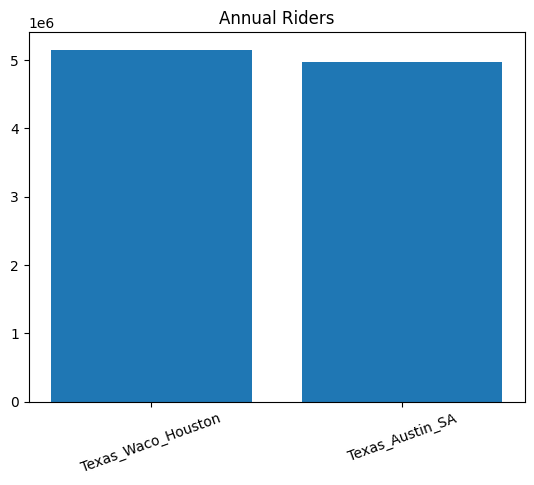

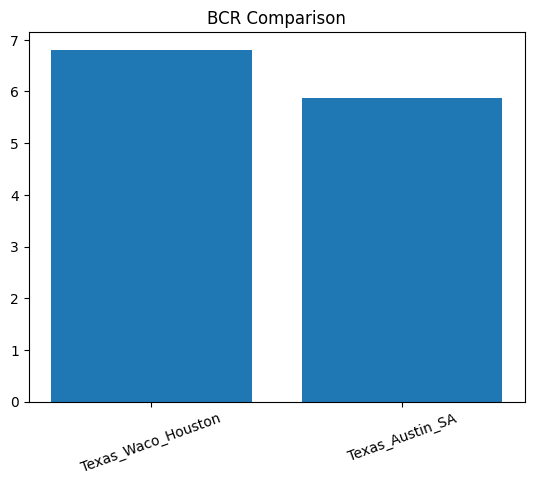

In [84]:
# ============================================================
# FULL CLEAN CELL: TEXAS + MIDWEST RAIL SCENARIO COMPARISON
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# PARAMETERS
# -----------------------------
SPEED_MPH = 150.0
WAIT_TIME = 0.25
DWELL = 0.08
VALUE_OF_TIME = 20
FARE_PER_MILE = 0.25

TRIPS_FACTOR = 8_000_000
TIME_SENS = 6.0
RAIL_SHARE_MIN = 0.03
RAIL_SHARE_MAX = 0.72

OM_PER_MILE = 0.10
CAPEX_PER_MILE = 28.0
AUTO_SPEED = 68.0
NETWORK_UPLIFT = 1.08


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float  # millions

@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITY LIST
# -----------------------------
CITIES = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
    "St. Louis": City("St. Louis", 2.8),
    "Springfield IL": City("Springfield IL", 0.2),
    "Chicago": City("Chicago", 9.5),
    "Austin": City("Austin", 2.4),
    "San Antonio": City("San Antonio", 2.6),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
}


# -----------------------------
# BASE NETWORK (BEST VERSION)
# -----------------------------
BASE = [
    Segment("Dallas","Oklahoma City",205),
    Segment("Oklahoma City","Wichita",160),
    Segment("Wichita","Kansas City",200),
    Segment("Kansas City","Omaha",190),
    Segment("Kansas City","St. Louis",250),
    Segment("St. Louis","Springfield IL",100),
    Segment("Springfield IL","Chicago",200),
]


# -----------------------------
# TEXAS SCENARIOS
# -----------------------------
SCENARIOS = {
    "Texas_Austin_SA": [
        Segment("Dallas","Austin",195),
        Segment("Austin","San Antonio",80),
    ],
    "Texas_Waco_Houston": [
        Segment("Dallas","Waco",100),
        Segment("Waco","Houston",185),
    ],
}


# -----------------------------
# GRAPH BUILD
# -----------------------------
def build_graph(segments):
    g = {}
    for s in segments:
        g.setdefault(s.a, []).append((s.b, s.dist))
        g.setdefault(s.b, []).append((s.a, s.dist))
    return g


def find_path(graph, start, end):
    stack = [(start, 0, [start])]
    while stack:
        node, dist, path = stack.pop()
        if node == end:
            return dist, len(path)-2
        for nxt, d in graph[node]:
            if nxt not in path:
                stack.append((nxt, dist+d, path+[nxt]))
    return None, None


# -----------------------------
# MODEL CORE
# -----------------------------
def rail_share(auto, rail):
    ratio = auto / rail
    x = 1/(1+math.exp(-TIME_SENS*(ratio-1)))
    return RAIL_SHARE_MIN + (RAIL_SHARE_MAX-RAIL_SHARE_MIN)*x


def demand(p1, p2, dist):
    return TRIPS_FACTOR * (p1*p2)/(dist)


def evaluate(segments):
    graph = build_graph(segments)
    nodes = list({n for s in segments for n in (s.a, s.b)})

    rows = []
    for a,b in combinations(nodes,2):
        dist, stops = find_path(graph,a,b)
        if dist is None:
            continue

        auto = dist/AUTO_SPEED
        rail = dist/SPEED_MPH + WAIT_TIME + stops*DWELL

        share = rail_share(auto, rail)
        trips = demand(CITIES[a].pop, CITIES[b].pop, dist)
        riders = trips * share * NETWORK_UPLIFT

        rev = riders*dist*FARE_PER_MILE/1e6
        benefit = riders*(auto-rail)*VALUE_OF_TIME/1e6

        rows.append({
            "origin":a,"dest":b,"riders":riders,
            "revenue":rev,"benefit":benefit
        })

    df = pd.DataFrame(rows)

    total_dist = sum(s.dist for s in segments)
    om = total_dist*OM_PER_MILE
    rev = df.revenue.sum()
    ben = df.benefit.sum()

    return {
        "riders": df.riders.sum(),
        "revenue": rev,
        "benefit": ben,
        "farebox": rev/om,
        "bcr": (rev+ben)/om,
        "miles": total_dist
    }


# -----------------------------
# RUN
# -----------------------------
results = []

for name, extra in SCENARIOS.items():
    segs = BASE + extra
    out = evaluate(segs)
    out["scenario"] = name
    results.append(out)

df = pd.DataFrame(results).sort_values("riders",ascending=False)

print("\n=== SCENARIO COMPARISON ===\n")
print(df)


# -----------------------------
# PLOT
# -----------------------------
plt.figure()
plt.bar(df.scenario, df.riders)
plt.title("Annual Riders")
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(df.scenario, df.bcr)
plt.title("BCR Comparison")
plt.xticks(rotation=20)
plt.show()


=== PHASE COMPARISON ===

         riders  revenue  benefit  farebox   bcr  miles                   phase
0   766,381.532   61.407   34.830    1.087 1.703    565  Phase_1_DAL_OKC_WIC_KC
1 2,614,240.862  342.051  199.209    3.068 4.854   1115     Phase_2_Add_STL_CHI
2 4,819,377.282  634.849  368.446    4.535 7.166   1400     Phase_3_Add_HOUSTON
3 5,149,416.761  684.845  397.757    4.307 6.809   1590       Phase_4_Add_OMAHA

=== INCREMENTAL VALUE ===

                    phase  delta_riders  delta_revenue  delta_bcr
0  Phase_1_DAL_OKC_WIC_KC           NaN            NaN        NaN
1     Phase_2_Add_STL_CHI 1,847,859.330        280.644      3.151
2     Phase_3_Add_HOUSTON 2,205,136.419        292.798      2.312
3       Phase_4_Add_OMAHA   330,039.479         49.996     -0.358


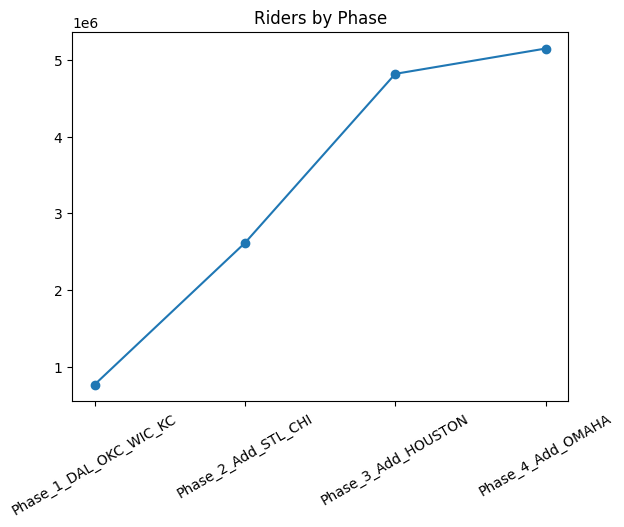

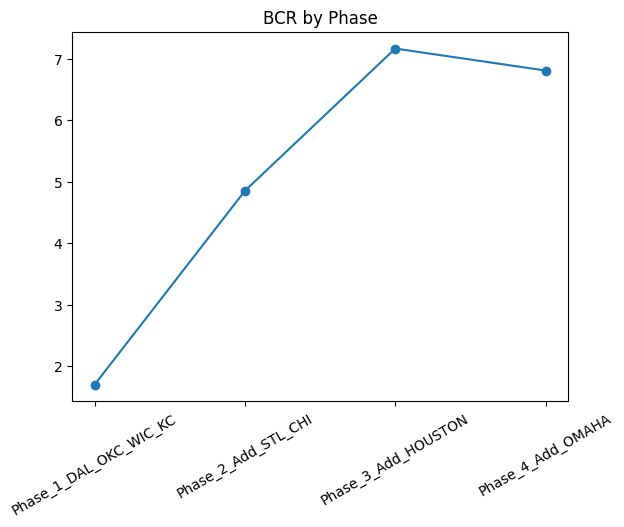

In [85]:
# ============================================================
# PHASE-BY-PHASE BUILDOUT MODEL
# ============================================================

PHASES = {
    "Phase_1_DAL_OKC_WIC_KC": [
        Segment("Dallas","Oklahoma City",205),
        Segment("Oklahoma City","Wichita",160),
        Segment("Wichita","Kansas City",200),
    ],

    "Phase_2_Add_STL_CHI": [
        Segment("Dallas","Oklahoma City",205),
        Segment("Oklahoma City","Wichita",160),
        Segment("Wichita","Kansas City",200),
        Segment("Kansas City","St. Louis",250),
        Segment("St. Louis","Springfield IL",100),
        Segment("Springfield IL","Chicago",200),
    ],

    "Phase_3_Add_HOUSTON": [
        Segment("Dallas","Oklahoma City",205),
        Segment("Oklahoma City","Wichita",160),
        Segment("Wichita","Kansas City",200),
        Segment("Kansas City","St. Louis",250),
        Segment("St. Louis","Springfield IL",100),
        Segment("Springfield IL","Chicago",200),
        Segment("Dallas","Waco",100),
        Segment("Waco","Houston",185),
    ],

    "Phase_4_Add_OMAHA": [
        Segment("Dallas","Oklahoma City",205),
        Segment("Oklahoma City","Wichita",160),
        Segment("Wichita","Kansas City",200),
        Segment("Kansas City","St. Louis",250),
        Segment("St. Louis","Springfield IL",100),
        Segment("Springfield IL","Chicago",200),
        Segment("Dallas","Waco",100),
        Segment("Waco","Houston",185),
        Segment("Kansas City","Omaha",190),
    ],
}


# -----------------------------
# RUN PHASE ANALYSIS
# -----------------------------
phase_results = []

for name, segs in PHASES.items():
    result = evaluate(segs)
    result["phase"] = name
    phase_results.append(result)

phase_df = pd.DataFrame(phase_results).sort_values("riders")

print("\n=== PHASE COMPARISON ===\n")
print(phase_df)


# -----------------------------
# INCREMENTAL GAINS
# -----------------------------
phase_df = phase_df.sort_values("riders").reset_index(drop=True)

phase_df["delta_riders"] = phase_df["riders"].diff()
phase_df["delta_revenue"] = phase_df["revenue"].diff()
phase_df["delta_bcr"] = phase_df["bcr"].diff()

print("\n=== INCREMENTAL VALUE ===\n")
print(phase_df[["phase","delta_riders","delta_revenue","delta_bcr"]])


# -----------------------------
# PLOTS
# -----------------------------
plt.figure()
plt.plot(phase_df.phase, phase_df.riders, marker='o')
plt.xticks(rotation=30)
plt.title("Riders by Phase")
plt.show()

plt.figure()
plt.plot(phase_df.phase, phase_df.bcr, marker='o')
plt.xticks(rotation=30)
plt.title("BCR by Phase")
plt.show()


============ Core_Spine_Only - TOP OD FLOWS ============

           scenario       origin    destination  distance_miles  stops_between                                               path  annual_riders  annual_revenue_m  \
8   Core_Spine_Only       Dallas        Houston         285.000              1                          Dallas -> Waco -> Houston  1,236,795.876            88.122   
5   Core_Spine_Only      Chicago      St. Louis         300.000              1             Chicago -> Springfield IL -> St. Louis    549,106.239            41.183   
0   Core_Spine_Only      Chicago         Dallas       1,115.000              5  Chicago -> Springfield IL -> St. Louis -> Kans...    412,592.221           115.010   
10  Core_Spine_Only       Dallas  Oklahoma City         205.000              0                            Dallas -> Oklahoma City    353,152.797            18.099   
1   Core_Spine_Only      Chicago        Houston       1,400.000              7  Chicago -> Springfield IL -> St

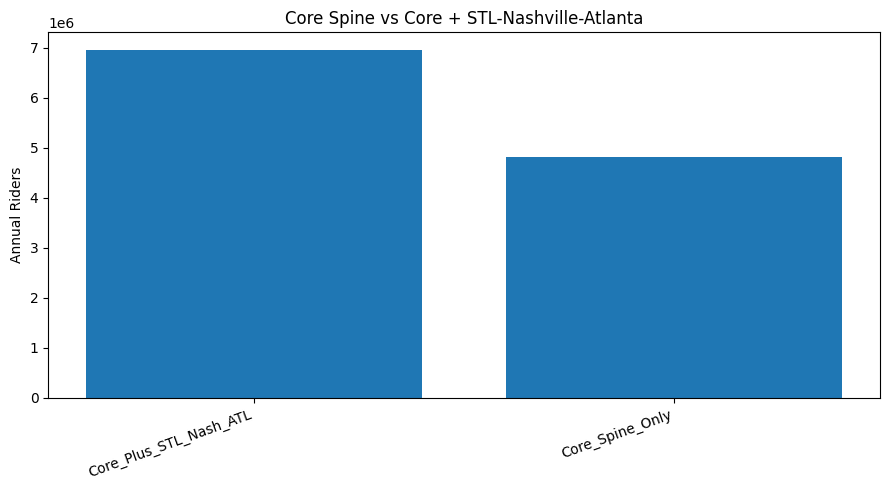

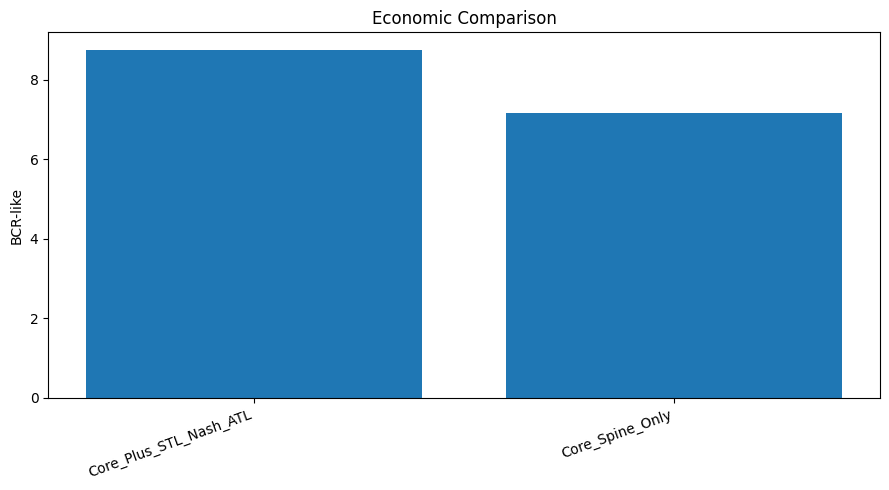

In [86]:
# ============================================================
# SOUTHEAST ADD-ON TEST
# Compare:
#   1) Core Chicago-Houston spine
#   2) Core spine + STL-Nashville-Atlanta branch
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# PARAMETERS
# -----------------------------
SPEED_MPH = 150.0
WAIT_TIME = 0.25
DWELL = 0.08
VALUE_OF_TIME = 20.0
FARE_PER_MILE = 0.25

TRIPS_FACTOR = 8_000_000.0
TIME_SENS = 6.0
RAIL_SHARE_MIN = 0.03
RAIL_SHARE_MAX = 0.72

OM_PER_MILE = 0.10          # $M per route-mile per year
CAPEX_PER_MILE = 28.0       # $M per route-mile
AUTO_SPEED = 68.0
NETWORK_UPLIFT = 1.08


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float   # metro population, in millions


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITY LIST
# -----------------------------
CITIES: Dict[str, City] = {
    "Dallas": City("Dallas", 7.8),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Wichita": City("Wichita", 0.65),
    "Kansas City": City("Kansas City", 2.2),
    "Omaha": City("Omaha", 1.0),
    "St. Louis": City("St. Louis", 2.8),
    "Springfield IL": City("Springfield IL", 0.2),
    "Chicago": City("Chicago", 9.5),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
}


# -----------------------------
# CORE WINNING SPINE
# -----------------------------
CORE_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
]

# Southeast branch
SOUTHEAST_BRANCH = [
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]


# -----------------------------
# SCENARIOS
# -----------------------------
SCENARIOS = {
    "Core_Spine_Only": CORE_SPINE,
    "Core_Plus_STL_Nash_ATL": CORE_SPINE + SOUTHEAST_BRANCH,
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path

        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))

    return None, None, None


# -----------------------------
# MODEL FUNCTIONS
# -----------------------------
def rail_share(auto_time: float, rail_time: float) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-TIME_SENS * (ratio - 1.0)))
    return RAIL_SHARE_MIN + (RAIL_SHARE_MAX - RAIL_SHARE_MIN) * x


def demand(pop1: float, pop2: float, dist: float) -> float:
    return TRIPS_FACTOR * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], scenario_name: str):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / AUTO_SPEED
        rail_time = dist / SPEED_MPH + WAIT_TIME + stops * DWELL

        share = rail_share(auto_time, rail_time)
        trips = demand(CITIES[a].pop, CITIES[b].pop, dist)
        riders = trips * share * NETWORK_UPLIFT

        revenue = riders * dist * FARE_PER_MILE / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * VALUE_OF_TIME / 1_000_000

        od_rows.append({
            "scenario": scenario_name,
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "path": " -> ".join(path),
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * OM_PER_MILE
    capex = total_miles * CAPEX_PER_MILE
    total_riders = od_df["annual_riders"].sum()
    total_revenue = od_df["annual_revenue_m"].sum()
    total_benefit = od_df["annual_public_benefit_m"].sum()

    summary = {
        "scenario": scenario_name,
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": total_revenue / annual_om,
        "capex_m": capex,
        "bcr_like": (total_revenue + total_benefit) / annual_om,
        "route_miles": total_miles,
    }

    return od_df, summary


# -----------------------------
# RUN SCENARIOS
# -----------------------------
all_od = []
summary_rows = []

for name, segs in SCENARIOS.items():
    od_df, summary = evaluate_network(segs, name)
    all_od.append(od_df)
    summary_rows.append(summary)

    print(f"\n============ {name} - TOP OD FLOWS ============\n")
    print(od_df.head(15))

    print(f"\n============ {name} - SUMMARY ============\n")
    for k, v in summary.items():
        if isinstance(v, float):
            print(f"{k}: {v:,.3f}")
        else:
            print(f"{k}: {v}")

summary_df = pd.DataFrame(summary_rows).sort_values("annual_riders", ascending=False)

# Incremental comparison
base = summary_df[summary_df["scenario"] == "Core_Spine_Only"].iloc[0]
sext = summary_df[summary_df["scenario"] == "Core_Plus_STL_Nash_ATL"].iloc[0]

incremental_df = pd.DataFrame([{
    "comparison": "SE_Branch_Minus_Core",
    "delta_riders": sext["annual_riders"] - base["annual_riders"],
    "delta_revenue_m": sext["annual_revenue_m"] - base["annual_revenue_m"],
    "delta_public_benefit_m": sext["annual_public_benefit_m"] - base["annual_public_benefit_m"],
    "delta_annual_om_m": sext["annual_om_m"] - base["annual_om_m"],
    "delta_capex_m": sext["capex_m"] - base["capex_m"],
    "delta_farebox": sext["farebox_recovery"] - base["farebox_recovery"],
    "delta_bcr_like": sext["bcr_like"] - base["bcr_like"],
}])


print("\n============ SCENARIO COMPARISON ============\n")
print(summary_df)

print("\n============ INCREMENTAL IMPACT OF STL-NASHVILLE-ATLANTA ============\n")
print(incremental_df)


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Core Spine vs Core + STL-Nashville-Atlanta")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Economic Comparison")
plt.tight_layout()
plt.show()


=== WHAT BREAKS FIRST STRESS TEST ===

               case  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  passes_farebox  passes_bcr   delta_riders  \
18       Break_Test  3,231,671.914           397.763                   94.554      312.000             1.275     1.578            True        True -3,733,279.483   
17     Heavy_Stress  4,955,301.688           636.982                  279.581      273.000             2.333     3.357            True        True -2,009,649.710   
12          OM_+60%  6,964,951.397         1,075.594                  631.979      312.000             3.447     5.473            True        True          0.000   
16  Moderate_Stress  6,139,801.769           840.865                  464.806      234.000             3.593     5.580            True        True   -825,149.629   
3          Speed_90  5,612,182.477           885.152                  205.861      195.000             4.539     5.595            True 

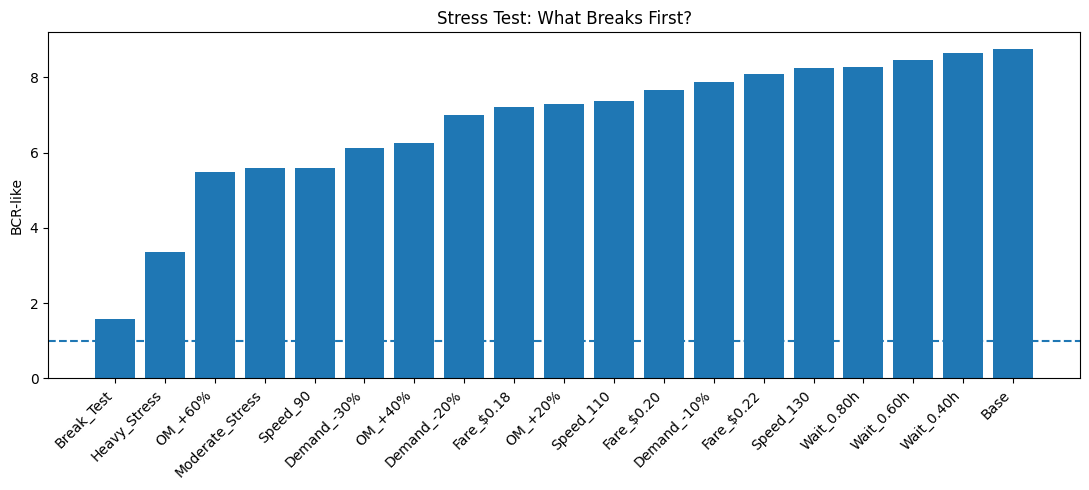

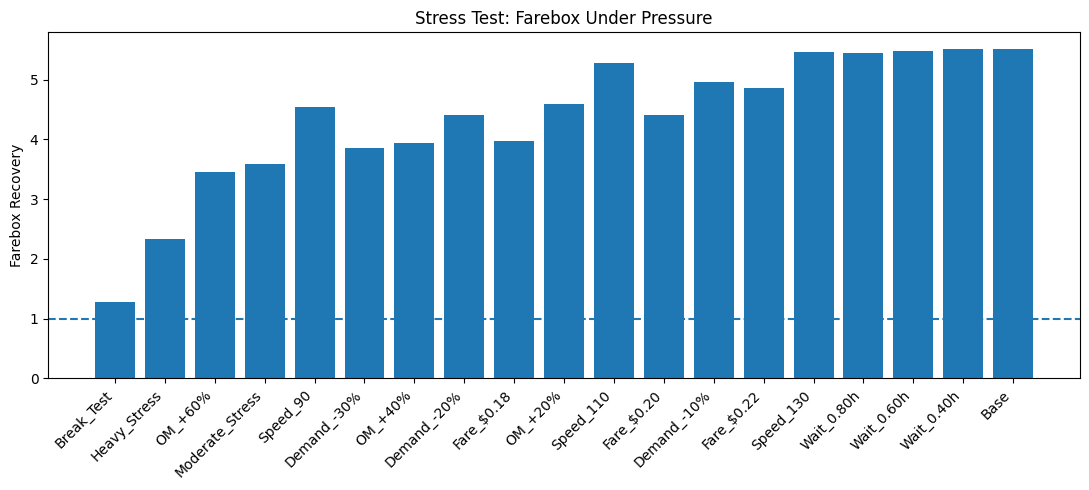

In [87]:
# ============================================================
# WHAT BREAKS FIRST STRESS TEST
# Full network:
# Chicago - Springfield IL - STL - KC - Wichita - OKC - Dallas - Waco - Houston
# plus STL - Nashville - Atlanta
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# BASE PARAMETERS
# -----------------------------
BASE_PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 20.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "time_sens": 6.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,     # $M per route-mile per year
    "capex_per_mile": 28.0,  # $M per route-mile
    "auto_speed": 68.0,
    "network_uplift": 1.08,
}

# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
}

# -----------------------------
# FULL NETWORK
# -----------------------------
FULL_NETWORK = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# MODEL
# -----------------------------
def rail_share(auto_time: float, rail_time: float, p: dict) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-p["time_sens"] * (ratio - 1.0)))
    return p["rail_share_min"] + (p["rail_share_max"] - p["rail_share_min"]) * x


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        share = rail_share(auto_time, rail_time, p)
        trips = demand(CITIES[a].pop, CITIES[b].pop, dist, p)
        riders = trips * share * p["network_uplift"]

        revenue = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
        })

    od_df = pd.DataFrame(od_rows)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * p["om_per_mile"]
    capex = total_miles * p["capex_per_mile"]

    total_riders = od_df["annual_riders"].sum()
    total_revenue = od_df["annual_revenue_m"].sum()
    total_benefit = od_df["annual_public_benefit_m"].sum()

    return {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": total_revenue / annual_om,
        "capex_m": capex,
        "bcr_like": (total_revenue + total_benefit) / annual_om,
        "route_miles": total_miles,
    }


# -----------------------------
# STRESS CASES
# -----------------------------
STRESS_CASES = {
    "Base": {},

    # speed stress
    "Speed_130": {"speed_mph": 130.0},
    "Speed_110": {"speed_mph": 110.0},
    "Speed_90": {"speed_mph": 90.0},

    # demand stress
    "Demand_-10%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.90},
    "Demand_-20%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.80},
    "Demand_-30%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.70},

    # fare stress
    "Fare_$0.22": {"fare_per_mile": 0.22},
    "Fare_$0.20": {"fare_per_mile": 0.20},
    "Fare_$0.18": {"fare_per_mile": 0.18},

    # O&M stress
    "OM_+20%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.20},
    "OM_+40%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.40},
    "OM_+60%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.60},

    # wait time / frequency stress
    "Wait_0.40h": {"wait_time": 0.40},
    "Wait_0.60h": {"wait_time": 0.60},
    "Wait_0.80h": {"wait_time": 0.80},

    # combo scenarios
    "Moderate_Stress": {
        "speed_mph": 130.0,
        "trips_factor": BASE_PARAMS["trips_factor"] * 0.90,
        "om_per_mile": BASE_PARAMS["om_per_mile"] * 1.20,
        "fare_per_mile": 0.22,
        "wait_time": 0.40,
    },
    "Heavy_Stress": {
        "speed_mph": 110.0,
        "trips_factor": BASE_PARAMS["trips_factor"] * 0.80,
        "om_per_mile": BASE_PARAMS["om_per_mile"] * 1.40,
        "fare_per_mile": 0.20,
        "wait_time": 0.60,
    },
    "Break_Test": {
        "speed_mph": 90.0,
        "trips_factor": BASE_PARAMS["trips_factor"] * 0.70,
        "om_per_mile": BASE_PARAMS["om_per_mile"] * 1.60,
        "fare_per_mile": 0.18,
        "wait_time": 0.80,
    },
}


# -----------------------------
# RUN STRESS TEST
# -----------------------------
rows = []

for case_name, overrides in STRESS_CASES.items():
    p = BASE_PARAMS.copy()
    p.update(overrides)

    result = evaluate_network(FULL_NETWORK, p)
    result["case"] = case_name
    result["passes_farebox"] = result["farebox_recovery"] >= 1.0
    result["passes_bcr"] = result["bcr_like"] >= 1.0
    rows.append(result)

stress_df = pd.DataFrame(rows)

# compare against base
base_row = stress_df.loc[stress_df["case"] == "Base"].iloc[0]
stress_df["delta_riders"] = stress_df["annual_riders"] - base_row["annual_riders"]
stress_df["delta_revenue_m"] = stress_df["annual_revenue_m"] - base_row["annual_revenue_m"]
stress_df["delta_bcr"] = stress_df["bcr_like"] - base_row["bcr_like"]
stress_df["delta_farebox"] = stress_df["farebox_recovery"] - base_row["farebox_recovery"]

# sort by BCR from weakest to strongest
stress_sorted = stress_df.sort_values("bcr_like")

print("\n=== WHAT BREAKS FIRST STRESS TEST ===\n")
print(stress_sorted[[
    "case",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "annual_om_m",
    "farebox_recovery",
    "bcr_like",
    "passes_farebox",
    "passes_bcr",
    "delta_riders",
    "delta_revenue_m",
    "delta_bcr",
    "delta_farebox",
]])

# first failures
farebox_failures = stress_sorted[stress_sorted["passes_farebox"] == False]
bcr_failures = stress_sorted[stress_sorted["passes_bcr"] == False]

print("\n=== FIRST FAREBOX FAILURE ===\n")
if not farebox_failures.empty:
    print(farebox_failures.iloc[0][["case", "farebox_recovery", "bcr_like", "annual_riders"]])
else:
    print("No farebox failure in tested cases.")

print("\n=== FIRST BCR FAILURE ===\n")
if not bcr_failures.empty:
    print(bcr_failures.iloc[0][["case", "farebox_recovery", "bcr_like", "annual_riders"]])
else:
    print("No BCR failure in tested cases.")


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(11, 5))
plt.bar(stress_sorted["case"], stress_sorted["bcr_like"])
plt.axhline(1.0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("BCR-like")
plt.title("Stress Test: What Breaks First?")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(stress_sorted["case"], stress_sorted["farebox_recovery"])
plt.axhline(1.0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Farebox Recovery")
plt.title("Stress Test: Farebox Under Pressure")
plt.tight_layout()
plt.show()


=== BASELINE NETWORK ===

   annual_riders  annual_revenue_m  annual_public_benefit_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs
0  6,964,951.397         1,075.594                  631.979             5.516     8.757         1950               11        55

=== NODE IMPORTANCE RANKING ===

      removed_node  annual_riders  annual_revenue_m  farebox_recovery  bcr_like  rider_loss_pct  revenue_loss_pct  bcr_loss_pct  route_miles  connected_nodes  od_pairs
9        St. Louis  2,908,513.942           230.579             1.774     2.770          58.241            78.563        68.371         1300               10        17
3           Dallas  3,044,467.850           381.475             2.319     3.676          56.289            64.534        58.024         1645               10        29
5      Kansas City  4,061,778.656           375.739             2.505     3.935          41.683            65.067        55.061         1500               10        20
7    Oklaho

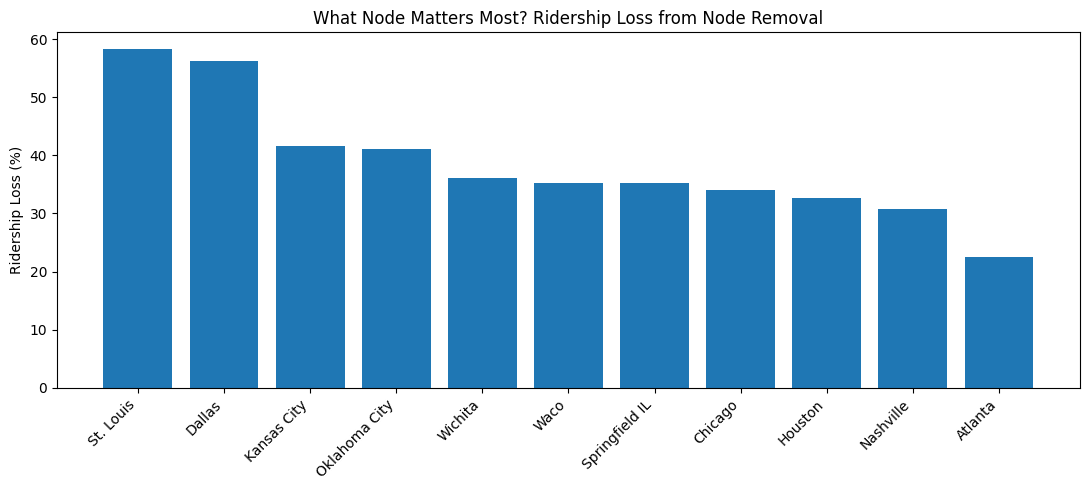

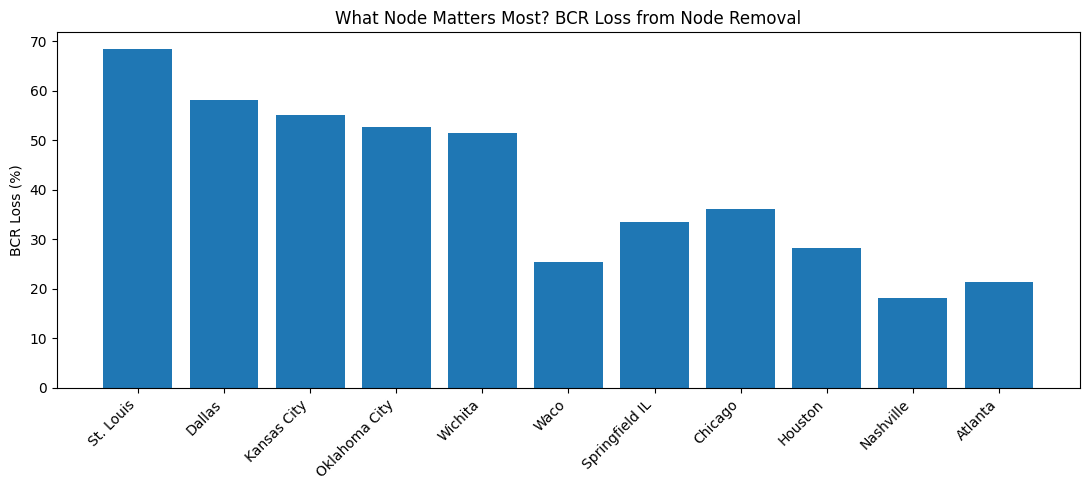

In [88]:
# ============================================================
# WHAT NODE MATTERS MOST?
# Full network node removal stress test
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# BASE PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 20.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "time_sens": 6.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
}


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
}


# -----------------------------
# FULL NETWORK
# -----------------------------
FULL_NETWORK = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# MODEL
# -----------------------------
def rail_share(auto_time: float, rail_time: float, p: dict) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-p["time_sens"] * (ratio - 1.0)))
    return p["rail_share_min"] + (p["rail_share_max"] - p["rail_share_min"]) * x


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        share = rail_share(auto_time, rail_time, p)
        trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        riders = trips * share * p["network_uplift"]

        revenue = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "path": " -> ".join(path),
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
        })

    od_df = pd.DataFrame(od_rows)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * p["om_per_mile"]
    capex = total_miles * p["capex_per_mile"]

    total_riders = od_df["annual_riders"].sum() if not od_df.empty else 0.0
    total_revenue = od_df["annual_revenue_m"].sum() if not od_df.empty else 0.0
    total_benefit = od_df["annual_public_benefit_m"].sum() if not od_df.empty else 0.0

    return {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": (total_revenue / annual_om) if annual_om > 0 else 0.0,
        "capex_m": capex,
        "bcr_like": ((total_revenue + total_benefit) / annual_om) if annual_om > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }


# -----------------------------
# NODE REMOVAL
# -----------------------------
def remove_node(segments: List[Segment], city_dict: Dict[str, City], node_to_remove: str):
    new_segments = [
        s for s in segments
        if s.a != node_to_remove and s.b != node_to_remove
    ]
    new_cities = {
        k: v for k, v in city_dict.items()
        if k != node_to_remove
    }
    return new_segments, new_cities


# -----------------------------
# BASELINE
# -----------------------------
base_result = evaluate_network(FULL_NETWORK, CITIES, PARAMS)

rows = [{
    "removed_node": "NONE_BASELINE",
    **base_result
}]

test_nodes = sorted({n for s in FULL_NETWORK for n in (s.a, s.b)})

for node in test_nodes:
    segs2, cities2 = remove_node(FULL_NETWORK, CITIES, node)
    result = evaluate_network(segs2, cities2, PARAMS)
    result["removed_node"] = node
    rows.append(result)

node_df = pd.DataFrame(rows)

# deltas vs baseline
baseline = node_df[node_df["removed_node"] == "NONE_BASELINE"].iloc[0]

for col in ["annual_riders", "annual_revenue_m", "annual_public_benefit_m", "farebox_recovery", "bcr_like"]:
    node_df[f"delta_{col}"] = node_df[col] - baseline[col]

node_df["rider_loss_pct"] = 100 * (baseline["annual_riders"] - node_df["annual_riders"]) / baseline["annual_riders"]
node_df["revenue_loss_pct"] = 100 * (baseline["annual_revenue_m"] - node_df["annual_revenue_m"]) / baseline["annual_revenue_m"]
node_df["bcr_loss_pct"] = 100 * (baseline["bcr_like"] - node_df["bcr_like"]) / baseline["bcr_like"]

# importance ranking
rank_df = node_df[node_df["removed_node"] != "NONE_BASELINE"].copy()
rank_df = rank_df.sort_values(
    by=["rider_loss_pct", "revenue_loss_pct", "bcr_loss_pct"],
    ascending=False
)

print("\n=== BASELINE NETWORK ===\n")
print(node_df[node_df["removed_node"] == "NONE_BASELINE"][[
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "farebox_recovery",
    "bcr_like",
    "route_miles",
    "connected_nodes",
    "od_pairs",
]])

print("\n=== NODE IMPORTANCE RANKING ===\n")
print(rank_df[[
    "removed_node",
    "annual_riders",
    "annual_revenue_m",
    "farebox_recovery",
    "bcr_like",
    "rider_loss_pct",
    "revenue_loss_pct",
    "bcr_loss_pct",
    "route_miles",
    "connected_nodes",
    "od_pairs",
]])

print("\n=== TOP 5 MOST IMPORTANT NODES BY RIDERSHIP LOSS ===\n")
print(rank_df[[
    "removed_node",
    "rider_loss_pct",
    "revenue_loss_pct",
    "bcr_loss_pct"
]].head(5))


# -----------------------------
# PLOTS
# -----------------------------
plot_df = rank_df.copy()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["removed_node"], plot_df["rider_loss_pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Ridership Loss (%)")
plt.title("What Node Matters Most? Ridership Loss from Node Removal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["removed_node"], plot_df["bcr_loss_pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("BCR Loss (%)")
plt.title("What Node Matters Most? BCR Loss from Node Removal")
plt.tight_layout()
plt.show()


=== FINAL BOSS TEST: STL REPLACEMENT TOPOLOGIES ===

                scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs  rider_loss_pct  \
4  STL_Bypass_LittleRock  8,492,057.345         1,237.355                  724.296             5.512     8.738         2245               13        78         -21.926   
3     STL_Bypass_Memphis  8,115,238.507         1,188.210                  699.473             5.316     8.446         2235               12        66         -16.515   
0  Baseline_Full_Network  6,964,951.397         1,075.594                  631.979             5.516     8.757         1950               11        55           0.000   
2        STL_Bypass_Indy  4,535,879.366           409.687                  234.234             2.601     4.088         1575               10        21          34.876   
1                 No_STL  2,908,513.942           230.579                  129.480             1

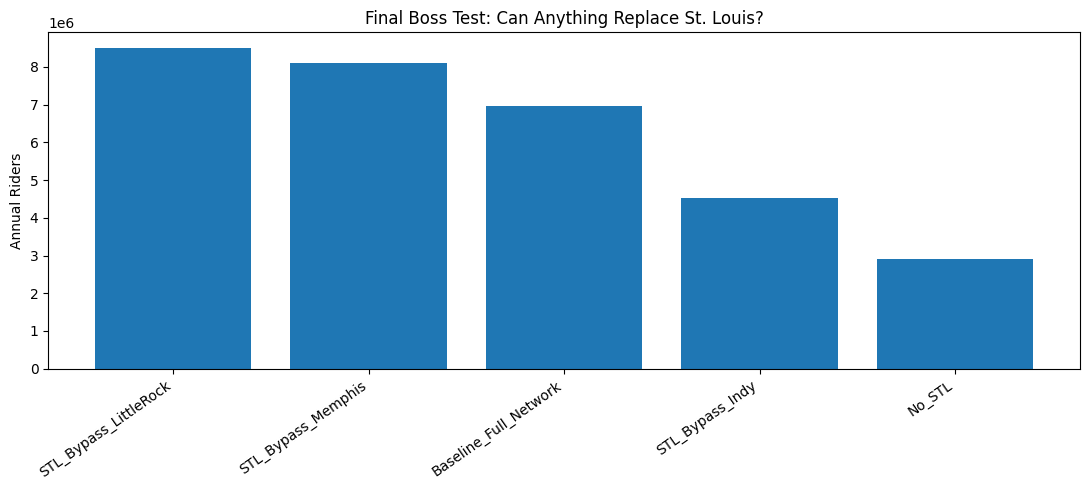

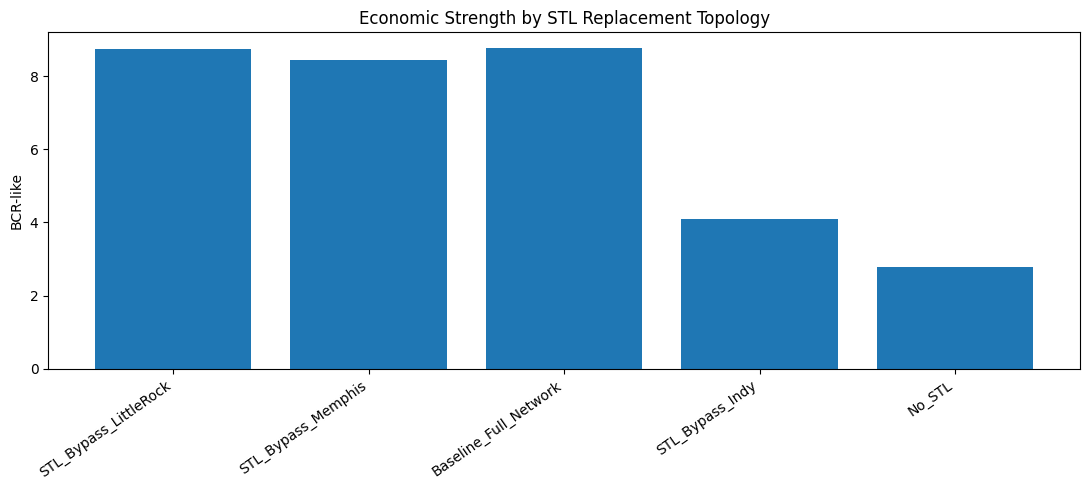

In [89]:
# ============================================================
# FINAL BOSS TEST:
# Can the network survive without St. Louis?
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 20.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "time_sens": 6.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
}


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# BASELINE FULL NETWORK
# -----------------------------
BASELINE_NETWORK = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]


# -----------------------------
# STL REMOVAL / REPLACEMENT CASES
# -----------------------------
SCENARIOS = {
    "Baseline_Full_Network": BASELINE_NETWORK,

    "No_STL": [
        Segment("Kansas City", "Wichita", 200),
        Segment("Wichita", "Oklahoma City", 160),
        Segment("Oklahoma City", "Dallas", 205),
        Segment("Dallas", "Waco", 100),
        Segment("Waco", "Houston", 185),
        Segment("Nashville", "Atlanta", 250),
        Segment("Chicago", "Springfield IL", 200),
    ],

    "STL_Bypass_Indy": [
        Segment("Chicago", "Indianapolis", 185),
        Segment("Indianapolis", "Nashville", 290),
        Segment("Nashville", "Atlanta", 250),
        Segment("Kansas City", "Wichita", 200),
        Segment("Wichita", "Oklahoma City", 160),
        Segment("Oklahoma City", "Dallas", 205),
        Segment("Dallas", "Waco", 100),
        Segment("Waco", "Houston", 185),
    ],

    "STL_Bypass_Memphis": [
        Segment("Chicago", "Indianapolis", 185),
        Segment("Indianapolis", "Louisville", 115),
        Segment("Louisville", "Nashville", 175),
        Segment("Nashville", "Atlanta", 250),
        Segment("Nashville", "Memphis", 210),
        Segment("Memphis", "Dallas", 450),
        Segment("Dallas", "Waco", 100),
        Segment("Waco", "Houston", 185),
        Segment("Kansas City", "Wichita", 200),
        Segment("Wichita", "Oklahoma City", 160),
        Segment("Oklahoma City", "Dallas", 205),
    ],

    "STL_Bypass_LittleRock": [
        Segment("Chicago", "Indianapolis", 185),
        Segment("Indianapolis", "Louisville", 115),
        Segment("Louisville", "Nashville", 175),
        Segment("Nashville", "Atlanta", 250),
        Segment("Nashville", "Memphis", 210),
        Segment("Memphis", "Little Rock", 140),
        Segment("Little Rock", "Dallas", 320),
        Segment("Dallas", "Waco", 100),
        Segment("Waco", "Houston", 185),
        Segment("Kansas City", "Wichita", 200),
        Segment("Wichita", "Oklahoma City", 160),
        Segment("Oklahoma City", "Dallas", 205),
    ],
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# MODEL
# -----------------------------
def rail_share(auto_time: float, rail_time: float, p: dict) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-p["time_sens"] * (ratio - 1.0)))
    return p["rail_share_min"] + (p["rail_share_max"] - p["rail_share_min"]) * x


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        share = rail_share(auto_time, rail_time, p)
        trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        riders = trips * share * p["network_uplift"]

        revenue = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "path": " -> ".join(path),
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * p["om_per_mile"]
    capex = total_miles * p["capex_per_mile"]

    total_riders = od_df["annual_riders"].sum() if not od_df.empty else 0.0
    total_revenue = od_df["annual_revenue_m"].sum() if not od_df.empty else 0.0
    total_benefit = od_df["annual_public_benefit_m"].sum() if not od_df.empty else 0.0

    return od_df, {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": (total_revenue / annual_om) if annual_om > 0 else 0.0,
        "capex_m": capex,
        "bcr_like": ((total_revenue + total_benefit) / annual_om) if annual_om > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }


# -----------------------------
# RUN
# -----------------------------
all_summaries = []
top_ods = {}

for name, segs in SCENARIOS.items():
    od_df, summary = evaluate_network(segs, CITIES, PARAMS)
    summary["scenario"] = name
    all_summaries.append(summary)
    top_ods[name] = od_df.head(12)

summary_df = pd.DataFrame(all_summaries)

baseline = summary_df.loc[summary_df["scenario"] == "Baseline_Full_Network"].iloc[0]

summary_df["delta_riders"] = summary_df["annual_riders"] - baseline["annual_riders"]
summary_df["delta_revenue_m"] = summary_df["annual_revenue_m"] - baseline["annual_revenue_m"]
summary_df["delta_bcr"] = summary_df["bcr_like"] - baseline["bcr_like"]
summary_df["rider_loss_pct"] = 100 * (baseline["annual_riders"] - summary_df["annual_riders"]) / baseline["annual_riders"]
summary_df["revenue_loss_pct"] = 100 * (baseline["annual_revenue_m"] - summary_df["annual_revenue_m"]) / baseline["annual_revenue_m"]
summary_df["bcr_loss_pct"] = 100 * (baseline["bcr_like"] - summary_df["bcr_like"]) / baseline["bcr_like"]

summary_df = summary_df.sort_values("annual_riders", ascending=False)

print("\n=== FINAL BOSS TEST: STL REPLACEMENT TOPOLOGIES ===\n")
print(summary_df[[
    "scenario",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "farebox_recovery",
    "bcr_like",
    "route_miles",
    "connected_nodes",
    "od_pairs",
    "rider_loss_pct",
    "revenue_loss_pct",
    "bcr_loss_pct",
]])

for name in summary_df["scenario"]:
    print(f"\n=== {name} - TOP OD FLOWS ===\n")
    print(top_ods[name][[
        "origin", "destination", "distance_miles", "annual_riders", "annual_revenue_m", "annual_public_benefit_m", "path"
    ]])


# -----------------------------
# PLOTS
# -----------------------------
plot_df = summary_df.copy()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["scenario"], plot_df["annual_riders"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Annual Riders")
plt.title("Final Boss Test: Can Anything Replace St. Louis?")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(plot_df["scenario"], plot_df["bcr_like"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("BCR-like")
plt.title("Economic Strength by STL Replacement Topology")
plt.tight_layout()
plt.show()


=== FLAGSHIP SUMMARY COMPARISON ===

               scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs  delta_riders_vs_stl  \
1  Alt_Spine_LittleRock  8,492,057.345         1,237.355                  724.296             5.512     8.738         2245               13        78        1,527,105.948   
0             STL_Spine  6,964,951.397         1,075.594                  631.979             5.516     8.757         1950               11        55                0.000   

   delta_revenue_vs_stl  delta_bcr_vs_stl  
1               161.760            -0.019  
0                 0.000             0.000  

=== STL_Spine - TOP OD FLOWS ===

         origin    destination  distance_miles  annual_riders  annual_revenue_m  annual_public_benefit_m                                               path
19       Dallas        Houston         285.000  1,236,795.876            88.122                   48.511            

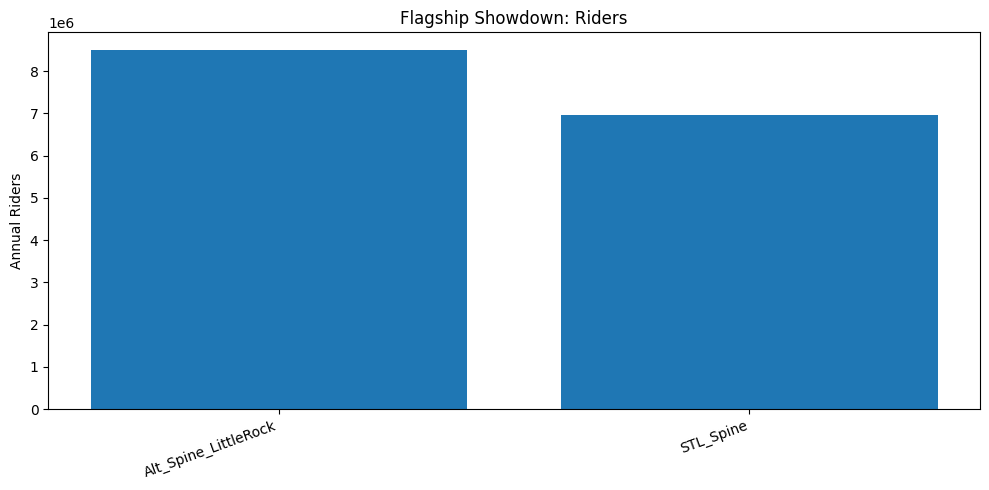

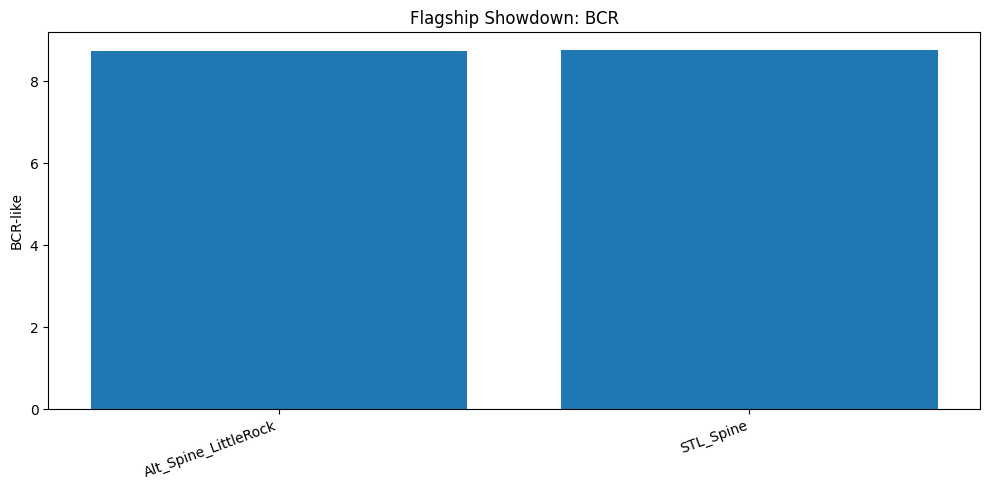

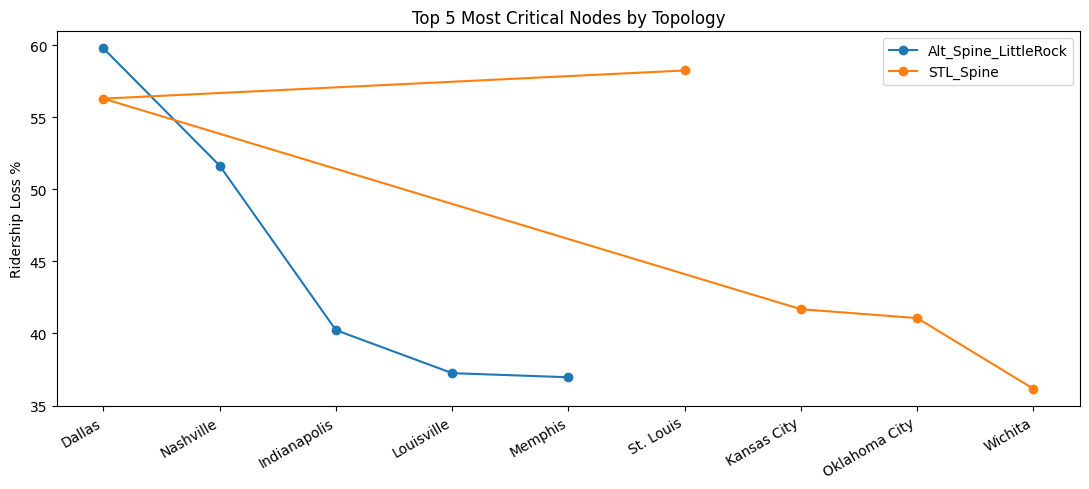

In [90]:
# ============================================================
# FLAGSHIP SHOWDOWN:
# STL Spine vs Alternate Indy-Memphis-Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 20.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "time_sens": 6.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
}


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORK DEFINITIONS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE,
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# MODEL FUNCTIONS
# -----------------------------
def rail_share(auto_time: float, rail_time: float, p: dict) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-p["time_sens"] * (ratio - 1.0)))
    return p["rail_share_min"] + (p["rail_share_max"] - p["rail_share_min"]) * x


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        share = rail_share(auto_time, rail_time, p)
        trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        riders = trips * share * p["network_uplift"]

        revenue = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "path": " -> ".join(path),
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * p["om_per_mile"]
    capex = total_miles * p["capex_per_mile"]

    total_riders = od_df["annual_riders"].sum() if not od_df.empty else 0.0
    total_revenue = od_df["annual_revenue_m"].sum() if not od_df.empty else 0.0
    total_benefit = od_df["annual_public_benefit_m"].sum() if not od_df.empty else 0.0

    summary = {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": (total_revenue / annual_om) if annual_om > 0 else 0.0,
        "capex_m": capex,
        "bcr_like": ((total_revenue + total_benefit) / annual_om) if annual_om > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }

    return od_df, summary


def segment_standalone_analysis(segments: List[Segment], city_dict: Dict[str, City], p: dict, scenario_name: str):
    rows = []
    for s in segments:
        auto_time = s.dist / p["auto_speed"]
        rail_time = s.dist / p["speed_mph"] + p["wait_time"]
        share = rail_share(auto_time, rail_time, p)
        trips = demand(city_dict[s.a].pop, city_dict[s.b].pop, s.dist, p)
        riders = trips * share
        revenue = riders * s.dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000
        om = s.dist * p["om_per_mile"]

        rows.append({
            "scenario": scenario_name,
            "segment": f"{s.a} - {s.b}",
            "distance_miles": s.dist,
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
            "annual_om_m": om,
            "farebox_recovery": revenue / om if om > 0 else 0.0,
            "bcr_like": (revenue + benefit) / om if om > 0 else 0.0,
        })

    return pd.DataFrame(rows).sort_values("annual_riders", ascending=False)


def remove_node(segments: List[Segment], city_dict: Dict[str, City], node_to_remove: str):
    new_segments = [s for s in segments if s.a != node_to_remove and s.b != node_to_remove]
    new_cities = {k: v for k, v in city_dict.items() if k != node_to_remove}
    return new_segments, new_cities


def node_importance_analysis(segments: List[Segment], city_dict: Dict[str, City], p: dict, scenario_name: str):
    _, base_summary = evaluate_network(segments, city_dict, p)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rows = []
    for node in nodes:
        segs2, cities2 = remove_node(segments, city_dict, node)
        _, summary2 = evaluate_network(segs2, cities2, p)

        rows.append({
            "scenario": scenario_name,
            "removed_node": node,
            "annual_riders": summary2["annual_riders"],
            "annual_revenue_m": summary2["annual_revenue_m"],
            "farebox_recovery": summary2["farebox_recovery"],
            "bcr_like": summary2["bcr_like"],
            "rider_loss_pct": 100 * (base_summary["annual_riders"] - summary2["annual_riders"]) / base_summary["annual_riders"],
            "revenue_loss_pct": 100 * (base_summary["annual_revenue_m"] - summary2["annual_revenue_m"]) / base_summary["annual_revenue_m"],
            "bcr_loss_pct": 100 * (base_summary["bcr_like"] - summary2["bcr_like"]) / base_summary["bcr_like"],
        })

    return pd.DataFrame(rows).sort_values("rider_loss_pct", ascending=False)


def run_stress_cases(segments: List[Segment], city_dict: Dict[str, City], scenario_name: str):
    stress_cases = {
        "Base": {},
        "Speed_110": {"speed_mph": 110.0},
        "Speed_90": {"speed_mph": 90.0},
        "Demand_-20%": {"trips_factor": PARAMS["trips_factor"] * 0.80},
        "Fare_$0.20": {"fare_per_mile": 0.20},
        "OM_+40%": {"om_per_mile": PARAMS["om_per_mile"] * 1.40},
        "Heavy_Stress": {
            "speed_mph": 110.0,
            "trips_factor": PARAMS["trips_factor"] * 0.80,
            "om_per_mile": PARAMS["om_per_mile"] * 1.40,
            "fare_per_mile": 0.20,
            "wait_time": 0.60,
        },
    }

    rows = []
    for case_name, overrides in stress_cases.items():
        p2 = p.copy()
        p2.update(overrides)
        _, summary = evaluate_network(segments, city_dict, p2)
        rows.append({
            "scenario": scenario_name,
            "case": case_name,
            **summary
        })

    return pd.DataFrame(rows)


# -----------------------------
# RUN COMPARISON
# -----------------------------
summary_rows = []
all_segment_tables = []
all_node_tables = []
all_stress_tables = []
top_ods = {}

for name, segs in NETWORKS.items():
    od_df, summary = evaluate_network(segs, CITIES, PARAMS)
    summary["scenario"] = name
    summary_rows.append(summary)

    top_ods[name] = od_df.head(15)
    all_segment_tables.append(segment_standalone_analysis(segs, CITIES, PARAMS, name))
    all_node_tables.append(node_importance_analysis(segs, CITIES, PARAMS, name))
    all_stress_tables.append(run_stress_cases(segs, CITIES, name))

summary_df = pd.DataFrame(summary_rows).sort_values("annual_riders", ascending=False)
segment_df = pd.concat(all_segment_tables, ignore_index=True)
node_df = pd.concat(all_node_tables, ignore_index=True)
stress_df = pd.concat(all_stress_tables, ignore_index=True)

base_stl = summary_df.loc[summary_df["scenario"] == "STL_Spine"].iloc[0]
summary_df["delta_riders_vs_stl"] = summary_df["annual_riders"] - base_stl["annual_riders"]
summary_df["delta_revenue_vs_stl"] = summary_df["annual_revenue_m"] - base_stl["annual_revenue_m"]
summary_df["delta_bcr_vs_stl"] = summary_df["bcr_like"] - base_stl["bcr_like"]

print("\n=== FLAGSHIP SUMMARY COMPARISON ===\n")
print(summary_df[[
    "scenario",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "farebox_recovery",
    "bcr_like",
    "route_miles",
    "connected_nodes",
    "od_pairs",
    "delta_riders_vs_stl",
    "delta_revenue_vs_stl",
    "delta_bcr_vs_stl",
]])

for name in NETWORKS.keys():
    print(f"\n=== {name} - TOP OD FLOWS ===\n")
    print(top_ods[name][[
        "origin", "destination", "distance_miles",
        "annual_riders", "annual_revenue_m",
        "annual_public_benefit_m", "path"
    ]])

print("\n=== SEGMENT STANDALONE COMPARISON ===\n")
print(segment_df[[
    "scenario", "segment", "distance_miles", "annual_riders",
    "annual_revenue_m", "farebox_recovery", "bcr_like"
]].sort_values(["scenario", "annual_riders"], ascending=[True, False]))

print("\n=== NODE IMPORTANCE COMPARISON ===\n")
print(node_df[[
    "scenario", "removed_node", "rider_loss_pct",
    "revenue_loss_pct", "bcr_loss_pct"
]].sort_values(["scenario", "rider_loss_pct"], ascending=[True, False]))

print("\n=== STRESS TEST COMPARISON ===\n")
print(stress_df[[
    "scenario", "case", "annual_riders", "annual_revenue_m",
    "farebox_recovery", "bcr_like"
]].sort_values(["scenario", "bcr_like"], ascending=[True, False]))


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Flagship Showdown: Riders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Flagship Showdown: BCR")
plt.tight_layout()
plt.show()

top_nodes = node_df.sort_values("rider_loss_pct", ascending=False).groupby("scenario").head(5)
plt.figure(figsize=(11, 5))
for scenario in top_nodes["scenario"].unique():
    sub = top_nodes[top_nodes["scenario"] == scenario]
    plt.plot(sub["removed_node"], sub["rider_loss_pct"], marker="o", label=scenario)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Ridership Loss %")
plt.title("Top 5 Most Critical Nodes by Topology")
plt.legend()
plt.tight_layout()
plt.show()


=== FLAGSHIP BASELINE SUMMARY ===

               scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs
1  Alt_Spine_LittleRock  8,492,057.345         1,237.355                  724.296      224.500             5.512     8.738         2245               13        78
0             STL_Spine  6,964,951.397         1,075.594                  631.979      195.000             5.516     8.757         1950               11        55

=== STRESS TEST RESULTS (FULL) ===

                scenario          case  annual_riders  annual_revenue_m  farebox_recovery  bcr_like  passes_farebox  passes_bcr   delta_riders  delta_revenue_m  delta_farebox  \
18  Alt_Spine_LittleRock          Base  8,492,057.345         1,237.355             5.512     8.738            True        True          0.000            0.000          0.000   
0              STL_Spine          Base  6,964,951.397         1,075.594           

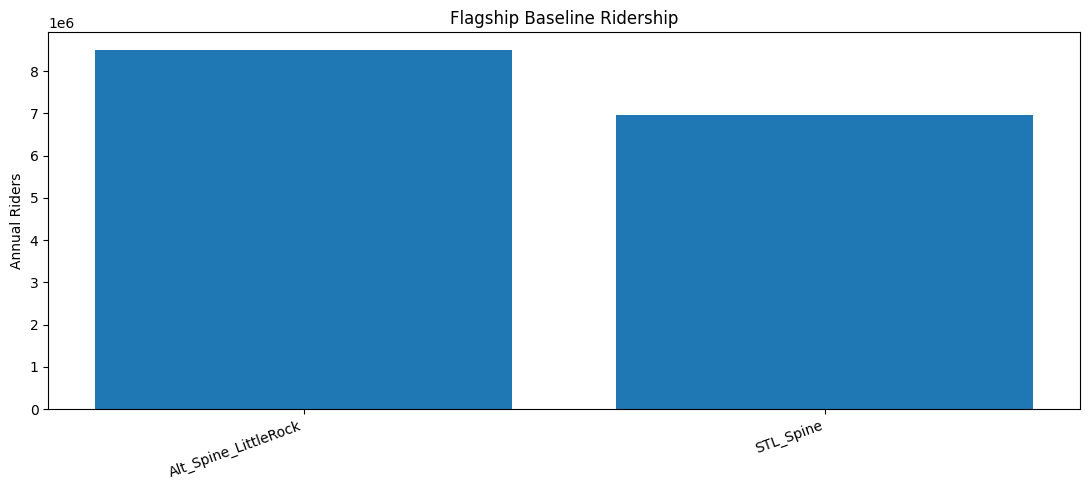

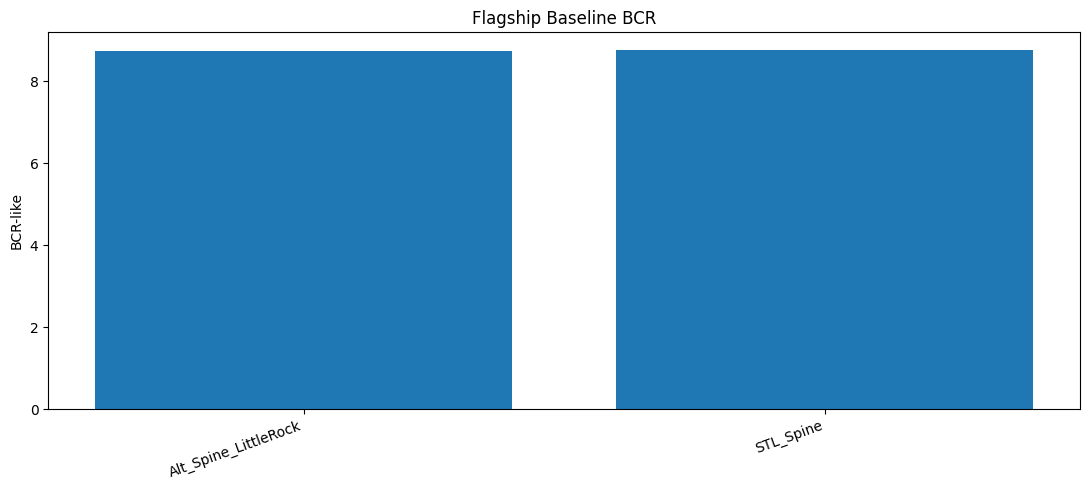

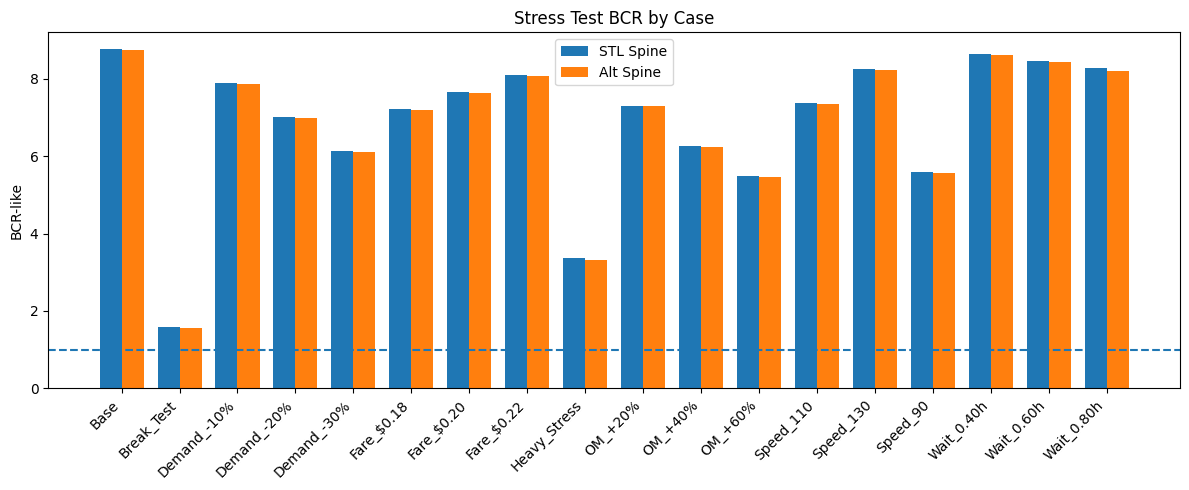

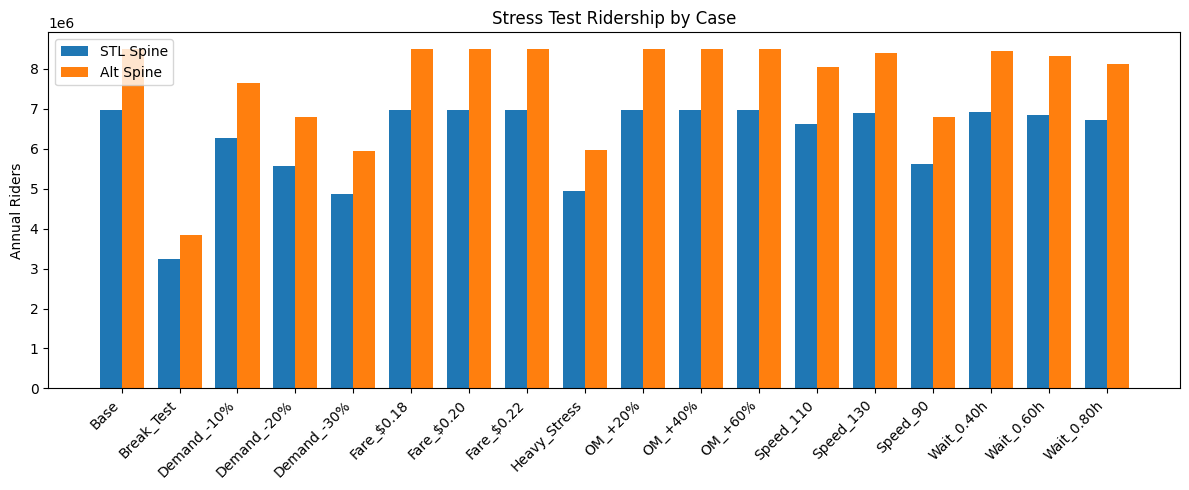

In [91]:
# ============================================================
# CLEAN FLAGSHIP STRESS TEST
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# PARAMETERS
# -----------------------------
BASE_PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 20.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "time_sens": 6.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
}


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORK DEFINITIONS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# MODEL
# -----------------------------
def rail_share(auto_time: float, rail_time: float, p: dict) -> float:
    ratio = auto_time / rail_time
    x = 1.0 / (1.0 + math.exp(-p["time_sens"] * (ratio - 1.0)))
    return p["rail_share_min"] + (p["rail_share_max"] - p["rail_share_min"]) * x


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        share = rail_share(auto_time, rail_time, p)
        trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        riders = trips * share * p["network_uplift"]

        revenue = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "annual_riders": riders,
            "annual_revenue_m": revenue,
            "annual_public_benefit_m": benefit,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om = total_miles * p["om_per_mile"]
    capex = total_miles * p["capex_per_mile"]

    total_riders = od_df["annual_riders"].sum() if not od_df.empty else 0.0
    total_revenue = od_df["annual_revenue_m"].sum() if not od_df.empty else 0.0
    total_benefit = od_df["annual_public_benefit_m"].sum() if not od_df.empty else 0.0

    return od_df, {
        "annual_riders": total_riders,
        "annual_revenue_m": total_revenue,
        "annual_public_benefit_m": total_benefit,
        "annual_om_m": annual_om,
        "farebox_recovery": total_revenue / annual_om if annual_om > 0 else 0.0,
        "capex_m": capex,
        "bcr_like": (total_revenue + total_benefit) / annual_om if annual_om > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }


# -----------------------------
# STRESS CASES
# -----------------------------
STRESS_CASES = {
    "Base": {},
    "Speed_130": {"speed_mph": 130.0},
    "Speed_110": {"speed_mph": 110.0},
    "Speed_90": {"speed_mph": 90.0},
    "Demand_-10%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.90},
    "Demand_-20%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.80},
    "Demand_-30%": {"trips_factor": BASE_PARAMS["trips_factor"] * 0.70},
    "Fare_$0.22": {"fare_per_mile": 0.22},
    "Fare_$0.20": {"fare_per_mile": 0.20},
    "Fare_$0.18": {"fare_per_mile": 0.18},
    "OM_+20%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.20},
    "OM_+40%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.40},
    "OM_+60%": {"om_per_mile": BASE_PARAMS["om_per_mile"] * 1.60},
    "Wait_0.40h": {"wait_time": 0.40},
    "Wait_0.60h": {"wait_time": 0.60},
    "Wait_0.80h": {"wait_time": 0.80},
    "Heavy_Stress": {
        "speed_mph": 110.0,
        "trips_factor": BASE_PARAMS["trips_factor"] * 0.80,
        "om_per_mile": BASE_PARAMS["om_per_mile"] * 1.40,
        "fare_per_mile": 0.20,
        "wait_time": 0.60,
    },
    "Break_Test": {
        "speed_mph": 90.0,
        "trips_factor": BASE_PARAMS["trips_factor"] * 0.70,
        "om_per_mile": BASE_PARAMS["om_per_mile"] * 1.60,
        "fare_per_mile": 0.18,
        "wait_time": 0.80,
    },
}


# -----------------------------
# RUN
# -----------------------------
summary_rows = []
stress_rows = []

for scenario_name, segs in NETWORKS.items():
    # baseline summary for each network
    _, base_summary = evaluate_network(segs, CITIES, BASE_PARAMS)
    base_summary["scenario"] = scenario_name
    summary_rows.append(base_summary)

    # stress
    for case_name, overrides in STRESS_CASES.items():
        p2 = BASE_PARAMS.copy()
        p2.update(overrides)
        _, result = evaluate_network(segs, CITIES, p2)
        result["scenario"] = scenario_name
        result["case"] = case_name
        stress_rows.append(result)

summary_df = pd.DataFrame(summary_rows).sort_values("annual_riders", ascending=False)
stress_df = pd.DataFrame(stress_rows)

# delta vs each network's own base
base_lookup = (
    stress_df[stress_df["case"] == "Base"]
    .set_index("scenario")[["annual_riders", "annual_revenue_m", "farebox_recovery", "bcr_like"]]
)

def add_base_deltas(row):
    base = base_lookup.loc[row["scenario"]]
    row["delta_riders"] = row["annual_riders"] - base["annual_riders"]
    row["delta_revenue_m"] = row["annual_revenue_m"] - base["annual_revenue_m"]
    row["delta_farebox"] = row["farebox_recovery"] - base["farebox_recovery"]
    row["delta_bcr"] = row["bcr_like"] - base["bcr_like"]
    row["passes_farebox"] = row["farebox_recovery"] >= 1.0
    row["passes_bcr"] = row["bcr_like"] >= 1.0
    return row

stress_df = stress_df.apply(add_base_deltas, axis=1)

# head-to-head table
pivot_bcr = stress_df.pivot(index="case", columns="scenario", values="bcr_like")
pivot_farebox = stress_df.pivot(index="case", columns="scenario", values="farebox_recovery")
pivot_riders = stress_df.pivot(index="case", columns="scenario", values="annual_riders")

comparison_df = pd.DataFrame({
    "STL_BCR": pivot_bcr["STL_Spine"],
    "ALT_BCR": pivot_bcr["Alt_Spine_LittleRock"],
    "BCR_Winner": pivot_bcr.idxmax(axis=1),
    "STL_Farebox": pivot_farebox["STL_Spine"],
    "ALT_Farebox": pivot_farebox["Alt_Spine_LittleRock"],
    "Farebox_Winner": pivot_farebox.idxmax(axis=1),
    "STL_Riders": pivot_riders["STL_Spine"],
    "ALT_Riders": pivot_riders["Alt_Spine_LittleRock"],
    "Rider_Winner": pivot_riders.idxmax(axis=1),
}).reset_index()

print("\n=== FLAGSHIP BASELINE SUMMARY ===\n")
print(summary_df[[
    "scenario", "annual_riders", "annual_revenue_m", "annual_public_benefit_m",
    "annual_om_m", "farebox_recovery", "bcr_like", "route_miles", "connected_nodes", "od_pairs"
]])

print("\n=== STRESS TEST RESULTS (FULL) ===\n")
print(stress_df[[
    "scenario", "case", "annual_riders", "annual_revenue_m",
    "farebox_recovery", "bcr_like", "passes_farebox", "passes_bcr",
    "delta_riders", "delta_revenue_m", "delta_farebox", "delta_bcr"
]].sort_values(["case", "scenario"]))

print("\n=== HEAD-TO-HEAD WINNERS BY CASE ===\n")
print(comparison_df)

# worst-case comparison
worst_df = (
    stress_df.groupby("scenario")[["farebox_recovery", "bcr_like", "annual_riders"]]
    .min()
    .rename(columns={
        "farebox_recovery": "worst_farebox",
        "bcr_like": "worst_bcr",
        "annual_riders": "worst_riders"
    })
    .reset_index()
)

print("\n=== WORST-CASE RESILIENCE ===\n")
print(worst_df)

# first failure check
failures = stress_df[(~stress_df["passes_farebox"]) | (~stress_df["passes_bcr"])]
print("\n=== FAILURE CASES ===\n")
if failures.empty:
    print("No failure cases for either topology in the tested scenarios.")
else:
    print(failures.sort_values(["scenario", "bcr_like"]))


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(11, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Flagship Baseline Ridership")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Flagship Baseline BCR")
plt.tight_layout()
plt.show()

plot_cases = comparison_df["case"]
x = range(len(plot_cases))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], comparison_df["STL_BCR"], width=width, label="STL Spine")
plt.bar([i + width/2 for i in x], comparison_df["ALT_BCR"], width=width, label="Alt Spine")
plt.axhline(1.0, linestyle="--")
plt.xticks(list(x), plot_cases, rotation=45, ha="right")
plt.ylabel("BCR-like")
plt.title("Stress Test BCR by Case")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar([i - width/2 for i in x], comparison_df["STL_Riders"], width=width, label="STL Spine")
plt.bar([i + width/2 for i in x], comparison_df["ALT_Riders"], width=width, label="Alt Spine")
plt.xticks(list(x), plot_cases, rotation=45, ha="right")
plt.ylabel("Annual Riders")
plt.title("Stress Test Ridership by Case")
plt.legend()
plt.tight_layout()
plt.show()


=== MONTE CARLO SUMMARY ===

    Metric      STL Mean      ALT Mean
0   Riders 6,729,505.956 8,167,794.032
1  Revenue       999.687     1,148.149
2      BCR         7.507         7.467
3  Farebox         4.500         4.489

=== WIN RATES ===

BCR Winner:
bcr_winner
STL   1.000
Name: proportion, dtype: float64

Rider Winner:
rider_winner
ALT   1.000
Name: proportion, dtype: float64

Farebox Winner:
farebox_winner
STL   1.000
Name: proportion, dtype: float64


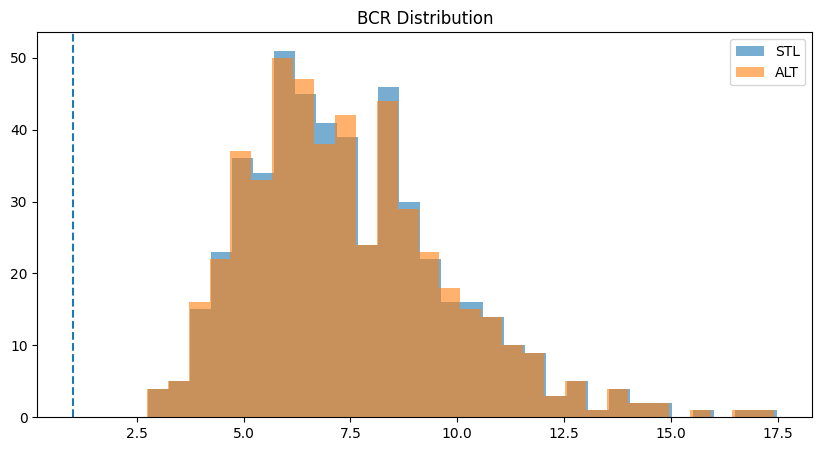

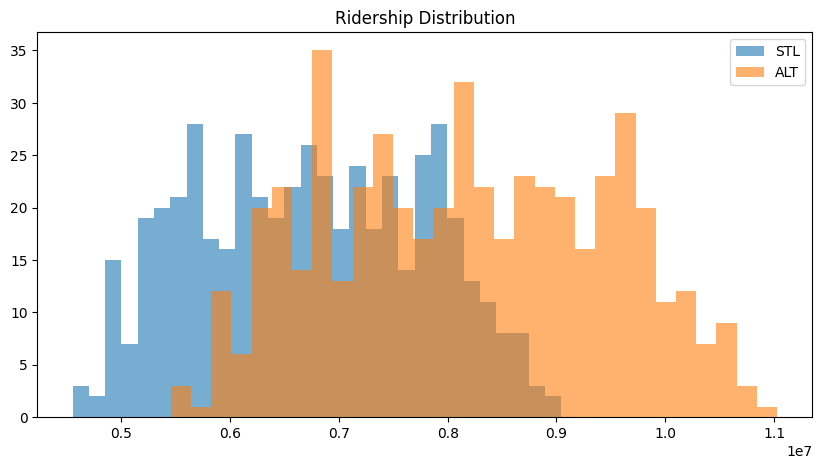


=== WORST CASE (BCR) ===

     stl_bcr  alt_bcr
143    2.758    2.736
24     3.050    3.032
273    3.081    3.048

=== BEST CASE (BCR) ===

     stl_bcr  alt_bcr
491   17.483   17.408
230   16.863   16.809
56    15.890   15.858


In [92]:
# ============================================================
# MONTE CARLO ROBUSTNESS TEST
# STL Spine vs Alt Little Rock Spine
# ============================================================

import random
import pandas as pd
import matplotlib.pyplot as plt

N_RUNS = 500  # change to 1000 if you want


# -----------------------------
# PARAMETER SAMPLING
# -----------------------------
def sample_params():
    return {
        "speed_mph": random.uniform(110, 160),
        "wait_time": random.uniform(0.2, 0.8),
        "dwell": 0.08,
        "value_of_time": random.uniform(15, 35),
        "fare_per_mile": random.uniform(0.18, 0.30),
        "trips_factor": random.uniform(6_000_000, 10_000_000),
        "time_sens": 6.0,
        "rail_share_min": 0.03,
        "rail_share_max": 0.72,
        "om_per_mile": random.uniform(0.08, 0.16),
        "capex_per_mile": 28.0,
        "auto_speed": random.uniform(60, 75),
        "network_uplift": random.uniform(1.0, 1.15),
    }


# -----------------------------
# RUN MONTE CARLO
# -----------------------------
results = []

for i in range(N_RUNS):
    p = sample_params()

    _, stl = evaluate_network(STL_SPINE, CITIES, p)
    _, alt = evaluate_network(ALT_SPINE_LITTLEROCK, CITIES, p)

    results.append({
        "run": i,

        "stl_riders": stl["annual_riders"],
        "alt_riders": alt["annual_riders"],

        "stl_revenue": stl["annual_revenue_m"],
        "alt_revenue": alt["annual_revenue_m"],

        "stl_bcr": stl["bcr_like"],
        "alt_bcr": alt["bcr_like"],

        "stl_farebox": stl["farebox_recovery"],
        "alt_farebox": alt["farebox_recovery"],

        "bcr_winner": "STL" if stl["bcr_like"] > alt["bcr_like"] else "ALT",
        "rider_winner": "STL" if stl["annual_riders"] > alt["annual_riders"] else "ALT",
        "farebox_winner": "STL" if stl["farebox_recovery"] > alt["farebox_recovery"] else "ALT",
    })

df = pd.DataFrame(results)


# -----------------------------
# SUMMARY STATS
# -----------------------------
summary = pd.DataFrame({
    "Metric": ["Riders", "Revenue", "BCR", "Farebox"],
    "STL Mean": [
        df["stl_riders"].mean(),
        df["stl_revenue"].mean(),
        df["stl_bcr"].mean(),
        df["stl_farebox"].mean(),
    ],
    "ALT Mean": [
        df["alt_riders"].mean(),
        df["alt_revenue"].mean(),
        df["alt_bcr"].mean(),
        df["alt_farebox"].mean(),
    ],
})

print("\n=== MONTE CARLO SUMMARY ===\n")
print(summary)


# -----------------------------
# WIN RATES
# -----------------------------
print("\n=== WIN RATES ===\n")

print("BCR Winner:")
print(df["bcr_winner"].value_counts(normalize=True))

print("\nRider Winner:")
print(df["rider_winner"].value_counts(normalize=True))

print("\nFarebox Winner:")
print(df["farebox_winner"].value_counts(normalize=True))


# -----------------------------
# DISTRIBUTIONS
# -----------------------------
plt.figure(figsize=(10,5))
plt.hist(df["stl_bcr"], bins=30, alpha=0.6, label="STL")
plt.hist(df["alt_bcr"], bins=30, alpha=0.6, label="ALT")
plt.axvline(1.0, linestyle="--")
plt.title("BCR Distribution")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df["stl_riders"], bins=30, alpha=0.6, label="STL")
plt.hist(df["alt_riders"], bins=30, alpha=0.6, label="ALT")
plt.title("Ridership Distribution")
plt.legend()
plt.show()


# -----------------------------
# EXTREME CASES
# -----------------------------
print("\n=== WORST CASE (BCR) ===\n")
print(df.sort_values("stl_bcr").head(3)[["stl_bcr", "alt_bcr"]])

print("\n=== BEST CASE (BCR) ===\n")
print(df.sort_values("stl_bcr", ascending=False).head(3)[["stl_bcr", "alt_bcr"]])

In [93]:
# ============================================================
# AMTRAK CALIBRATION CHECK
# Compare model corridors to real-world Amtrak ranges
# ============================================================

import pandas as pd

# -----------------------------
# STEP 1: DEFINE REAL-WORLD BENCHMARKS
# (approximate annual ridership ranges based on recent Amtrak data)
# -----------------------------
amtrak_benchmarks = pd.DataFrame([
    {"corridor": "Chicago - St. Louis", "low": 600_000, "high": 900_000},
    {"corridor": "Chicago - Kansas City", "low": 200_000, "high": 400_000},
    {"corridor": "Chicago - Dallas", "low": 150_000, "high": 300_000},
    {"corridor": "Dallas - Houston", "low": 0, "high": 0},  # no true Amtrak comp
    {"corridor": "Chicago - Nashville", "low": 100_000, "high": 250_000},
    {"corridor": "Chicago - Atlanta", "low": 150_000, "high": 300_000},
])

# midpoint for easier comparison
amtrak_benchmarks["mid"] = (amtrak_benchmarks["low"] + amtrak_benchmarks["high"]) / 2


# -----------------------------
# STEP 2: EXTRACT MODEL FLOWS
# (use your STL spine OD table)
# -----------------------------
# make sure this variable exists from earlier cell:
# top_ods["STL_Spine"]

model_df = top_ods["STL_Spine"].copy()

# create matching labels
def corridor_label(row):
    return f"{row['origin']} - {row['destination']}"

model_df["corridor"] = model_df.apply(corridor_label, axis=1)

# filter only corridors we care about
target_corridors = amtrak_benchmarks["corridor"].tolist()
model_subset = model_df[model_df["corridor"].isin(target_corridors)].copy()


# -----------------------------
# STEP 3: MERGE + COMPARE
# -----------------------------
compare_df = pd.merge(
    model_subset,
    amtrak_benchmarks,
    on="corridor",
    how="left"
)

# compute ratios
compare_df["ratio_vs_mid"] = compare_df["annual_riders"] / compare_df["mid"]
compare_df["ratio_vs_high"] = compare_df["annual_riders"] / compare_df["high"]

# flag realism
def realism_flag(r):
    if pd.isna(r["mid"]) or r["mid"] == 0:
        return "No Direct Benchmark"
    elif r["ratio_vs_mid"] < 2:
        return "Conservative"
    elif r["ratio_vs_mid"] < 5:
        return "Reasonable Upgrade"
    elif r["ratio_vs_mid"] < 10:
        return "Aggressive but Defensible"
    else:
        return "High – Needs Justification"

compare_df["assessment"] = compare_df.apply(realism_flag, axis=1)


# -----------------------------
# OUTPUT
# -----------------------------
print("\n=== AMTRAK CALIBRATION CHECK ===\n")
print(compare_df[[
    "corridor",
    "annual_riders",
    "mid",
    "ratio_vs_mid",
    "ratio_vs_high",
    "assessment"
]].sort_values("ratio_vs_mid", ascending=False))


=== AMTRAK CALIBRATION CHECK ===

                corridor  annual_riders         mid  ratio_vs_mid  ratio_vs_high           assessment
0       Dallas - Houston  1,236,795.876       0.000           inf            inf  No Direct Benchmark
2       Chicago - Dallas    412,592.221 225,000.000         1.834          1.375         Conservative
4    Chicago - Nashville    206,353.811 175,000.000         1.179          0.825         Conservative
3  Chicago - Kansas City    235,774.080 300,000.000         0.786          0.589         Conservative
1    Chicago - St. Louis    549,106.239 750,000.000         0.732          0.610         Conservative



=== DEMAND SCALING RESULTS ===

   scale   total_riders    bcr  farebox       CHI-STL      CHI-KC       CHI-DAL
0  0.500  3,482,475.699  4.378    2.758   274,553.119 117,887.040   206,296.110
1  0.750  5,223,713.548  6.568    4.137   411,829.679 176,830.560   309,444.166
2  1.000  6,964,951.397  8.757    5.516   549,106.239 235,774.080   412,592.221
3  1.250  8,706,189.247 10.946    6.895   686,382.798 294,717.600   515,740.276
4  1.500 10,447,427.096 13.135    8.274   823,659.358 353,661.120   618,888.331
5  2.000 13,929,902.795 17.514   11.032 1,098,212.477 471,548.159   825,184.441
6  3.000 20,894,854.192 26.270   16.548 1,647,318.716 707,322.239 1,237,776.662


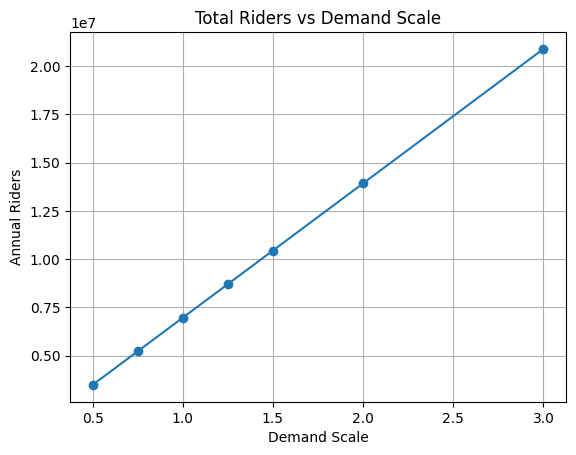

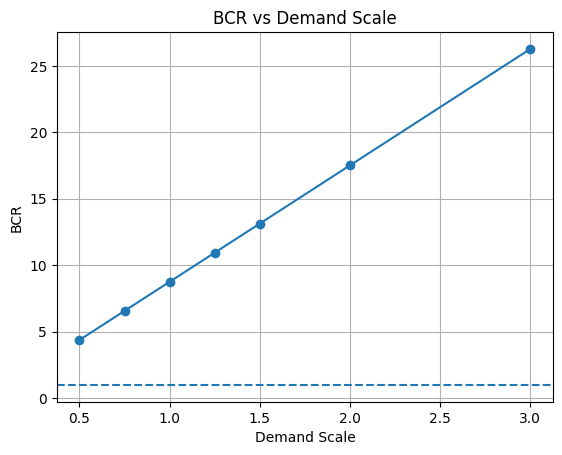

In [94]:
# ============================================================
# DEMAND SCALING TEST
# How much demand can we support vs Amtrak benchmarks?
# ============================================================

import pandas as pd
import numpy as np

# scaling factors to test
scales = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]

results = []

for scale in scales:
    params = BASE_PARAMS.copy()
    params["trips_factor"] *= scale

    _, summary = evaluate_network(STL_SPINE, CITIES, params)
    od_df, _ = evaluate_network(STL_SPINE, CITIES, params)

    # extract key corridors
    def get_corridor(df, o, d):
        row = df[(df["origin"] == o) & (df["destination"] == d)]
        return row["annual_riders"].values[0] if not row.empty else 0

    chi_stl = get_corridor(od_df, "Chicago", "St. Louis")
    chi_kc  = get_corridor(od_df, "Chicago", "Kansas City")
    chi_dal = get_corridor(od_df, "Chicago", "Dallas")

    results.append({
        "scale": scale,
        "total_riders": summary["annual_riders"],
        "bcr": summary["bcr_like"],
        "farebox": summary["farebox_recovery"],
        "CHI-STL": chi_stl,
        "CHI-KC": chi_kc,
        "CHI-DAL": chi_dal,
    })

df = pd.DataFrame(results)

print("\n=== DEMAND SCALING RESULTS ===\n")
print(df)


# -----------------------------
# OPTIONAL: QUICK VISUALS
# -----------------------------
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["scale"], df["total_riders"], marker="o")
plt.title("Total Riders vs Demand Scale")
plt.xlabel("Demand Scale")
plt.ylabel("Annual Riders")
plt.grid()
plt.show()

plt.figure()
plt.plot(df["scale"], df["bcr"], marker="o")
plt.axhline(1.0, linestyle="--")
plt.title("BCR vs Demand Scale")
plt.xlabel("Demand Scale")
plt.ylabel("BCR")
plt.grid()
plt.show()


=== ADVANCED REALISM SUMMARY ===

               scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  route_miles  trains_per_day  on_time_pct  \
1  Alt_Spine_LittleRock  4,437,266.020           348.578                  245.269      224.500             1.553     2.645         2245              10        0.850   
0             STL_Spine  3,530,531.083           290.494                  205.264      195.000             1.490     2.542         1950              10        0.850   

   frequency_multiplier  reliability_multiplier  annual_capacity_per_od  num_capacity_bound_pairs  
1                 1.050                   0.940           2,044,000.000                         0  
0                 1.050                   0.940           2,044,000.000                         0  

=== STL_Spine - TOP OD FLOWS ===

         origin     destination  distance_miles  rail_share  annual_riders  capacity_bound  annual_revenue_m                 

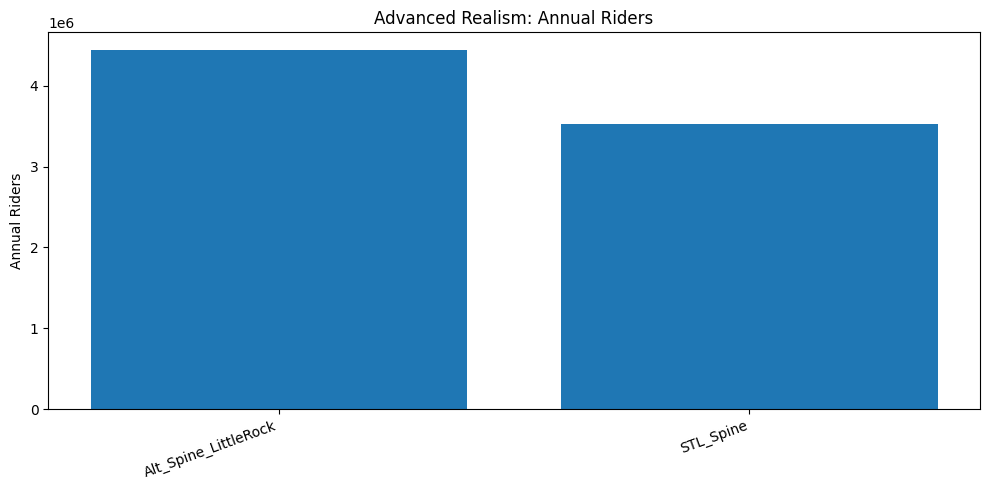

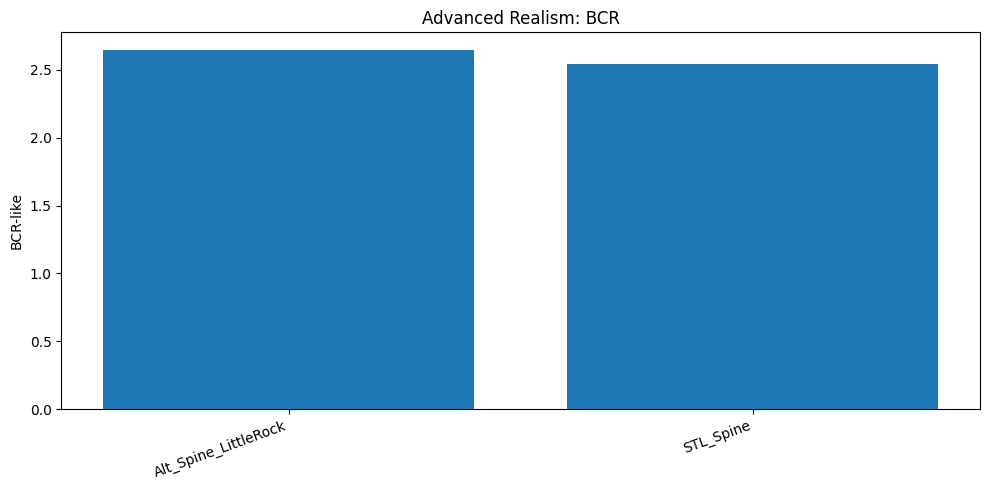

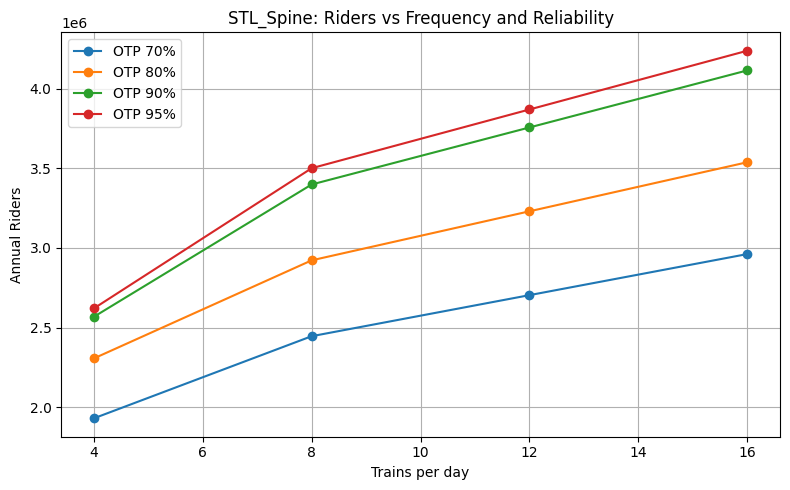

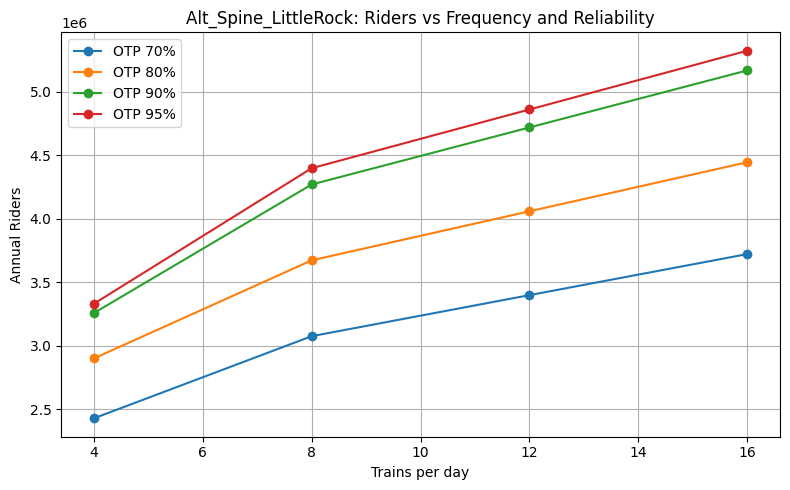

In [95]:
# ============================================================
# FRESH CELL: ADVANCED REALISM MODEL
# Frequency + Rail/Car/Air + Capacity + Reliability
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float  # metro population in millions


@dataclass
class Segment:
    a: str
    b: str
    dist: float  # miles


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# BASE PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,       # $M per route-mile-year
    "capex_per_mile": 28.0,    # $M per route-mile
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "trains_per_day": 10,      # service frequency
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,       # reliability
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# REALISM LAYERS
# -----------------------------
def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def annual_capacity(trains_per_day: int, seats_per_train: int, load_factor: float) -> float:
    # bi-directional annual seat capacity
    return trains_per_day * seats_per_train * load_factor * 365 * 2


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    """
    Simple logit-style rail share against auto and air.
    """
    # generalized disutility in dollar-equivalent terms
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75  # access/security/boarding/deplaning
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0  # sensitivity scaling
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0

    share = max(p["rail_share_min"], min(p["rail_share_max"], share))
    return share


# -----------------------------
# MODEL
# -----------------------------
def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def evaluate_network_advanced(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    freq_mult = frequency_multiplier(p["trains_per_day"])
    rel_mult = reliability_multiplier(p["on_time_pct"])
    cap = annual_capacity(p["trains_per_day"], p["seats_per_train"], p["load_factor"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders_uncapped = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        riders = min(riders_uncapped, cap)

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "path": " -> ".join(path),
            "auto_time_h": auto_time,
            "rail_time_h": rail_time,
            "rail_share": rail_share,
            "annual_riders_uncapped": riders_uncapped,
            "annual_riders": riders,
            "capacity_cap": cap,
            "capacity_bound": riders_uncapped > cap,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]
    capex_m = total_miles * p["capex_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
        "trains_per_day": p["trains_per_day"],
        "on_time_pct": p["on_time_pct"],
        "frequency_multiplier": freq_mult,
        "reliability_multiplier": rel_mult,
        "annual_capacity_per_od": cap,
        "num_capacity_bound_pairs": int(od_df["capacity_bound"].sum()),
    }

    return od_df, summary


# -----------------------------
# RUN BASE ADVANCED MODEL
# -----------------------------
all_summaries = []
top_flows = {}

for name, segs in NETWORKS.items():
    od_df, summary = evaluate_network_advanced(segs, CITIES, PARAMS)
    summary["scenario"] = name
    all_summaries.append(summary)
    top_flows[name] = od_df.head(15)

summary_df = pd.DataFrame(all_summaries).sort_values("annual_riders", ascending=False)

print("\n=== ADVANCED REALISM SUMMARY ===\n")
print(summary_df[[
    "scenario", "annual_riders", "annual_revenue_m", "annual_public_benefit_m",
    "annual_om_m", "farebox_recovery", "bcr_like", "route_miles",
    "trains_per_day", "on_time_pct", "frequency_multiplier",
    "reliability_multiplier", "annual_capacity_per_od", "num_capacity_bound_pairs"
]])

for name, df in top_flows.items():
    print(f"\n=== {name} - TOP OD FLOWS ===\n")
    print(df[[
        "origin", "destination", "distance_miles", "rail_share",
        "annual_riders", "capacity_bound", "annual_revenue_m", "path"
    ]])


# -----------------------------
# SENSITIVITY SWEEP:
# FREQUENCY x RELIABILITY
# -----------------------------
sweep_rows = []
for scenario_name, segs in NETWORKS.items():
    for trains_per_day in [4, 8, 12, 16]:
        for on_time_pct in [0.70, 0.80, 0.90, 0.95]:
            p2 = PARAMS.copy()
            p2["trains_per_day"] = trains_per_day
            p2["on_time_pct"] = on_time_pct

            _, s = evaluate_network_advanced(segs, CITIES, p2)
            sweep_rows.append({
                "scenario": scenario_name,
                "trains_per_day": trains_per_day,
                "on_time_pct": on_time_pct,
                "annual_riders": s["annual_riders"],
                "annual_revenue_m": s["annual_revenue_m"],
                "farebox_recovery": s["farebox_recovery"],
                "bcr_like": s["bcr_like"],
                "num_capacity_bound_pairs": s["num_capacity_bound_pairs"],
            })

sweep_df = pd.DataFrame(sweep_rows)

print("\n=== FREQUENCY / RELIABILITY SWEEP ===\n")
print(sweep_df.sort_values(["scenario", "trains_per_day", "on_time_pct"]))


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Advanced Realism: Annual Riders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Advanced Realism: BCR")
plt.tight_layout()
plt.show()

for scenario_name in sweep_df["scenario"].unique():
    sub = sweep_df[sweep_df["scenario"] == scenario_name].copy()
    pivot = sub.pivot(index="trains_per_day", columns="on_time_pct", values="annual_riders")

    plt.figure(figsize=(8, 5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker="o", label=f"OTP {col:.0%}")
    plt.title(f"{scenario_name}: Riders vs Frequency and Reliability")
    plt.xlabel("Trains per day")
    plt.ylabel("Annual Riders")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [96]:
import pandas as pd
from itertools import combinations

# =========================
# USER INPUTS
# =========================

TRAINS_PER_DAY = 10
SEATS_PER_TRAIN = 400
LOAD_FACTOR = 0.70
DAYS_PER_YEAR = 365

ANNUAL_CAPACITY_PER_DIRECTION = TRAINS_PER_DAY * SEATS_PER_TRAIN * LOAD_FACTOR * DAYS_PER_YEAR

# =========================
# BUILD SEGMENT LIST
# =========================

def build_segment_list(ordered_stops):
    segments = []
    for i in range(len(ordered_stops)-1):
        a = ordered_stops[i]
        b = ordered_stops[i+1]
        segments.append((a, b))
    return segments

# =========================
# GET PATH BETWEEN NODES
# =========================

def get_path(origin, destination, ordered_stops):
    i = ordered_stops.index(origin)
    j = ordered_stops.index(destination)

    if i < j:
        return ordered_stops[i:j+1]
    else:
        return list(reversed(ordered_stops[j:i+1]))

# =========================
# SEGMENT LOAD CALCULATION
# =========================

def segment_load_analysis(od_df, ordered_stops):
    segments = build_segment_list(ordered_stops)

    segment_loads = {seg: 0 for seg in segments}

    for _, row in od_df.iterrows():
        origin = row["origin"]
        destination = row["destination"]
        riders = row["annual_riders"]

        path = get_path(origin, destination, ordered_stops)

        for i in range(len(path)-1):
            seg = (path[i], path[i+1])
            if seg in segment_loads:
                segment_loads[seg] += riders
            else:
                segment_loads[(path[i+1], path[i])] += riders

    results = []

    for seg, load in segment_loads.items():
        utilization = load / ANNUAL_CAPACITY_PER_DIRECTION

        results.append({
            "segment": f"{seg[0]} - {seg[1]}",
            "annual_riders_on_segment": load,
            "capacity": ANNUAL_CAPACITY_PER_DIRECTION,
            "utilization_pct": utilization,
            "over_capacity": utilization > 1.0
        })

    df = pd.DataFrame(results).sort_values("utilization_pct", ascending=False)

    return df

# =========================
# MAIN EXECUTION
# =========================

def run_capacity_test(od_df, ordered_stops, scenario_name):

    seg_df = segment_load_analysis(od_df, ordered_stops)

    print(f"\n=== {scenario_name} - SEGMENT CAPACITY ANALYSIS ===\n")
    print(seg_df.head(15))

    print("\n=== BOTTLENECK SEGMENTS ===\n")
    print(seg_df[seg_df["over_capacity"] == True])

    print("\n=== SUMMARY ===\n")
    print(f"Max Utilization: {seg_df['utilization_pct'].max():.2f}")
    print(f"Segments Over Capacity: {seg_df['over_capacity'].sum()}")

    return seg_df


=== NETWORK SUMMARY ===

               scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  farebox_recovery  bcr_like  route_miles  segment_capacity  max_segment_utilization_pct  \
1  Alt_Spine_LittleRock  4,437,266.020           348.578                  245.269             1.553     2.645         2245     2,044,000.000                        0.730   
0             STL_Spine  3,530,531.083           290.494                  205.264             1.490     2.542         1950     2,044,000.000                        0.712   

   segments_over_capacity  
1                       0  
0                       0  

=== STL_Spine - TOP OD FLOWS ===

         origin     destination  distance_miles  rail_share  annual_riders  annual_revenue_m                                               path
19       Dallas         Houston         285.000       0.720  1,226,693.303            87.402                          Dallas -> Waco -> Houston
16      Chicago       St. Louis         300.000

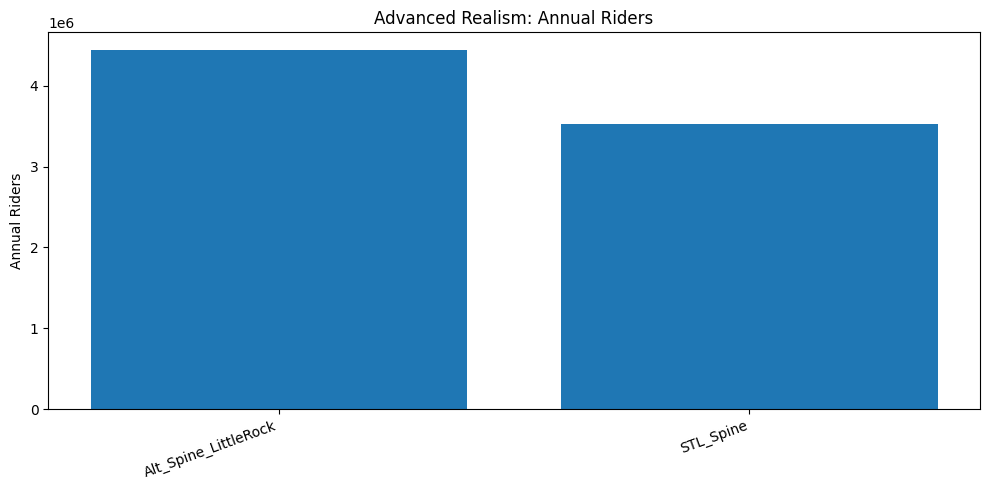

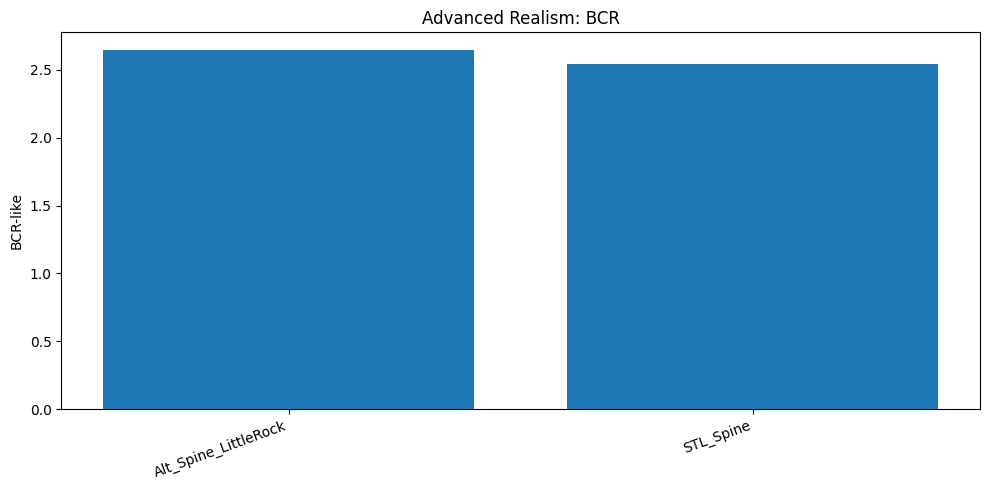

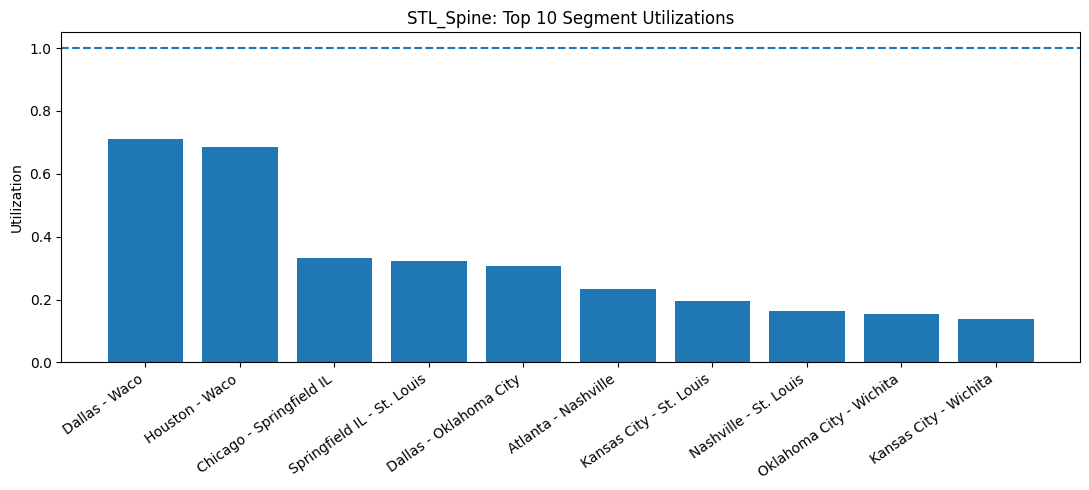

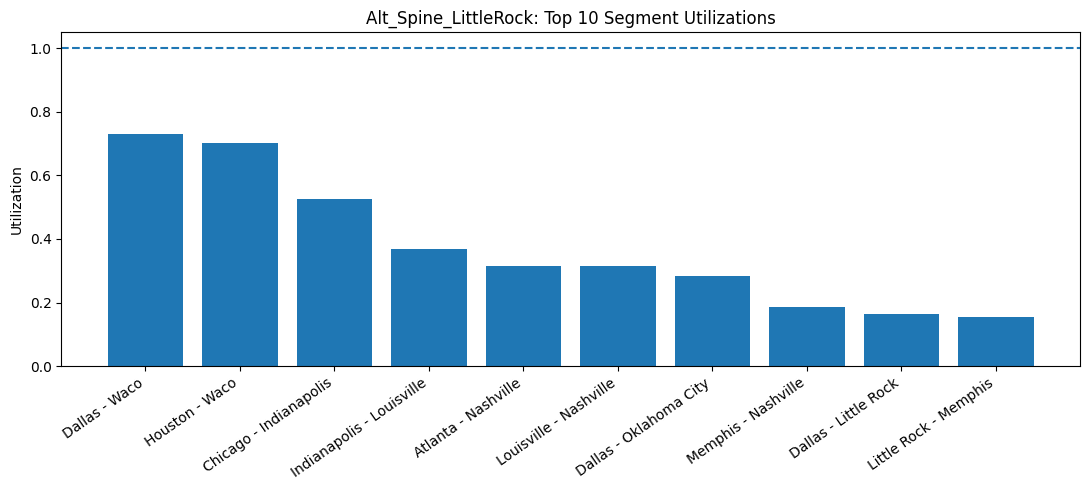

In [97]:
# ============================================================
# CLEAN FULL CELL:
# Advanced Realism + Segment Load / Capacity Analysis
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float  # metro population in millions


@dataclass
class Segment:
    a: str
    b: str
    dist: float  # miles


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,       # $M per route-mile-year
    "capex_per_mile": 28.0,    # $M per route-mile
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "trains_per_day": 10,
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,
    "days_per_year": 365,
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# REALISM LAYERS
# -----------------------------
def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def annual_segment_capacity(
    trains_per_day: int,
    seats_per_train: int,
    load_factor: float,
    days_per_year: int,
) -> float:
    return trains_per_day * seats_per_train * load_factor * days_per_year * 2


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


# -----------------------------
# CORE MODEL
# -----------------------------
def evaluate_network_advanced(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    freq_mult = frequency_multiplier(p["trains_per_day"])
    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "path_nodes": path,
            "path": " -> ".join(path),
            "auto_time_h": auto_time,
            "rail_time_h": rail_time,
            "rail_share": rail_share,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
        "trains_per_day": p["trains_per_day"],
        "on_time_pct": p["on_time_pct"],
        "frequency_multiplier": freq_mult,
        "reliability_multiplier": rel_mult,
    }

    return od_df, summary


# -----------------------------
# SEGMENT LOAD / CAPACITY
# -----------------------------
def segment_capacity_analysis(segments: List[Segment], od_df: pd.DataFrame, p: dict) -> pd.DataFrame:
    segment_map = {}
    for s in segments:
        key = tuple(sorted((s.a, s.b)))
        segment_map[key] = s.dist

    segment_loads = {k: 0.0 for k in segment_map.keys()}

    for _, row in od_df.iterrows():
        riders = row["annual_riders"]
        path_nodes = row["path_nodes"]

        for i in range(len(path_nodes) - 1):
            seg_key = tuple(sorted((path_nodes[i], path_nodes[i + 1])))
            if seg_key in segment_loads:
                segment_loads[seg_key] += riders

    cap = annual_segment_capacity(
        trains_per_day=p["trains_per_day"],
        seats_per_train=p["seats_per_train"],
        load_factor=p["load_factor"],
        days_per_year=p["days_per_year"],
    )

    rows = []
    for seg_key, load in segment_loads.items():
        a, b = seg_key
        rows.append({
            "segment": f"{a} - {b}",
            "distance_miles": segment_map[seg_key],
            "annual_riders_on_segment": load,
            "annual_segment_capacity": cap,
            "utilization_pct": load / cap if cap > 0 else 0.0,
            "over_capacity": load > cap,
        })

    seg_df = pd.DataFrame(rows).sort_values("utilization_pct", ascending=False)
    return seg_df


# -----------------------------
# RUN BOTH NETWORKS
# -----------------------------
all_summaries = []
all_seg_caps = {}
all_top_flows = {}

for name, segs in NETWORKS.items():
    od_df, summary = evaluate_network_advanced(segs, CITIES, PARAMS)
    seg_cap_df = segment_capacity_analysis(segs, od_df, PARAMS)

    summary["scenario"] = name
    summary["segment_capacity"] = annual_segment_capacity(
        PARAMS["trains_per_day"],
        PARAMS["seats_per_train"],
        PARAMS["load_factor"],
        PARAMS["days_per_year"],
    )
    summary["max_segment_utilization_pct"] = seg_cap_df["utilization_pct"].max()
    summary["segments_over_capacity"] = int(seg_cap_df["over_capacity"].sum())

    all_summaries.append(summary)
    all_seg_caps[name] = seg_cap_df
    all_top_flows[name] = od_df.head(15)

summary_df = pd.DataFrame(all_summaries).sort_values("annual_riders", ascending=False)

print("\n=== NETWORK SUMMARY ===\n")
print(summary_df[[
    "scenario",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "farebox_recovery",
    "bcr_like",
    "route_miles",
    "segment_capacity",
    "max_segment_utilization_pct",
    "segments_over_capacity",
]])

for name in NETWORKS.keys():
    print(f"\n=== {name} - TOP OD FLOWS ===\n")
    print(all_top_flows[name][[
        "origin", "destination", "distance_miles", "rail_share",
        "annual_riders", "annual_revenue_m", "path"
    ]])

    print(f"\n=== {name} - TOP LOADED SEGMENTS ===\n")
    print(all_seg_caps[name].head(15))

    print(f"\n=== {name} - BOTTLENECK SEGMENTS ===\n")
    bottlenecks = all_seg_caps[name][all_seg_caps[name]["over_capacity"]]
    if bottlenecks.empty:
        print("No segments over capacity.")
    else:
        print(bottlenecks)


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Advanced Realism: Annual Riders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Advanced Realism: BCR")
plt.tight_layout()
plt.show()

for name, seg_df in all_seg_caps.items():
    plot_df = seg_df.head(10).copy()

    plt.figure(figsize=(11, 5))
    plt.bar(plot_df["segment"], plot_df["utilization_pct"])
    plt.axhline(1.0, linestyle="--")
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Utilization")
    plt.title(f"{name}: Top 10 Segment Utilizations")
    plt.tight_layout()
    plt.show()


=== VARIABLE-FREQUENCY NETWORK SUMMARY ===

               scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  farebox_recovery  bcr_like  route_miles  max_segment_utilization_pct  segments_over_capacity
1  Alt_Spine_LittleRock  4,448,522.221           344.687                  242.109             1.535     2.614         2245                        0.491                       0
0             STL_Spine  3,536,261.166           285.578                  201.326             1.465     2.497         1950                        0.480                       0

=== STL_Spine - TOP OD FLOWS ===

         origin     destination  distance_miles  effective_trains_per_day  rail_share  annual_riders  annual_revenue_m                                               path
19       Dallas         Houston         285.000                        16       0.720  1,343,521.237            95.726                          Dallas -> Waco -> Houston
16      Chicago       St. Louis         300.000     

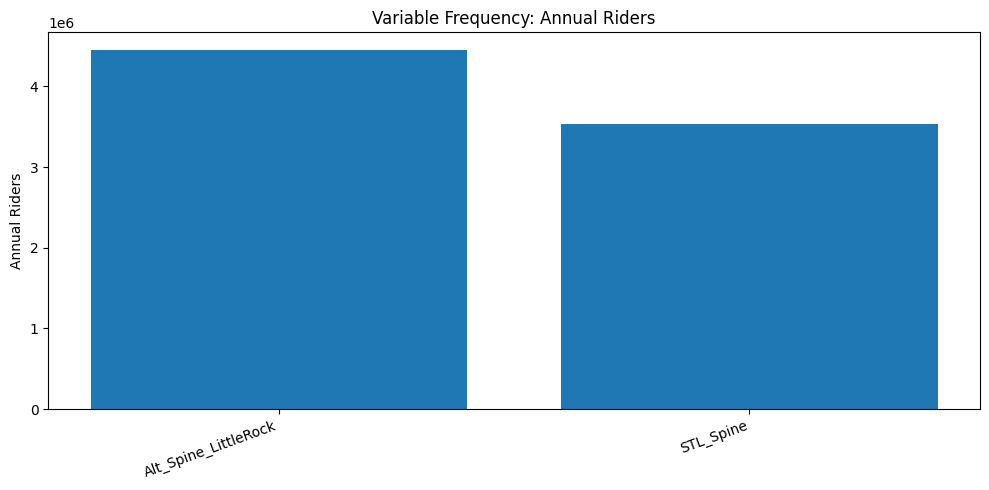

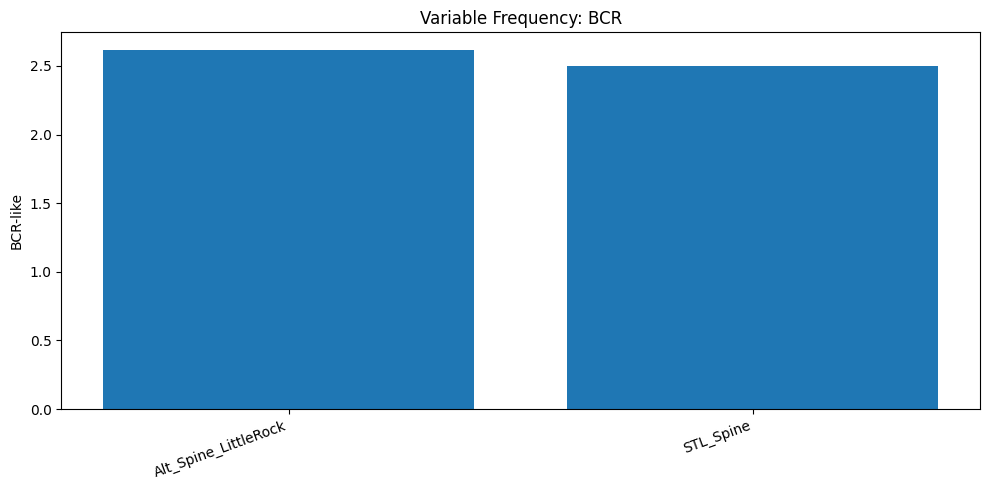

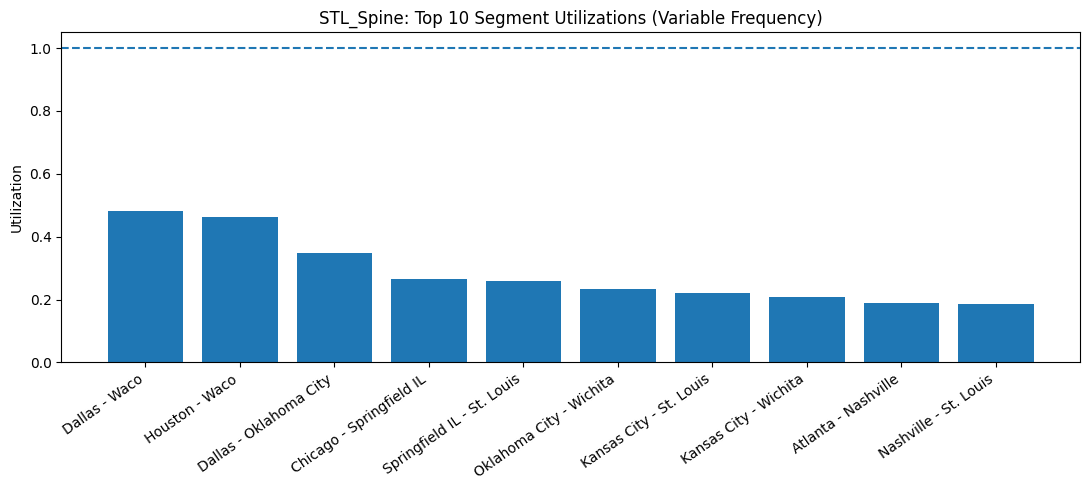

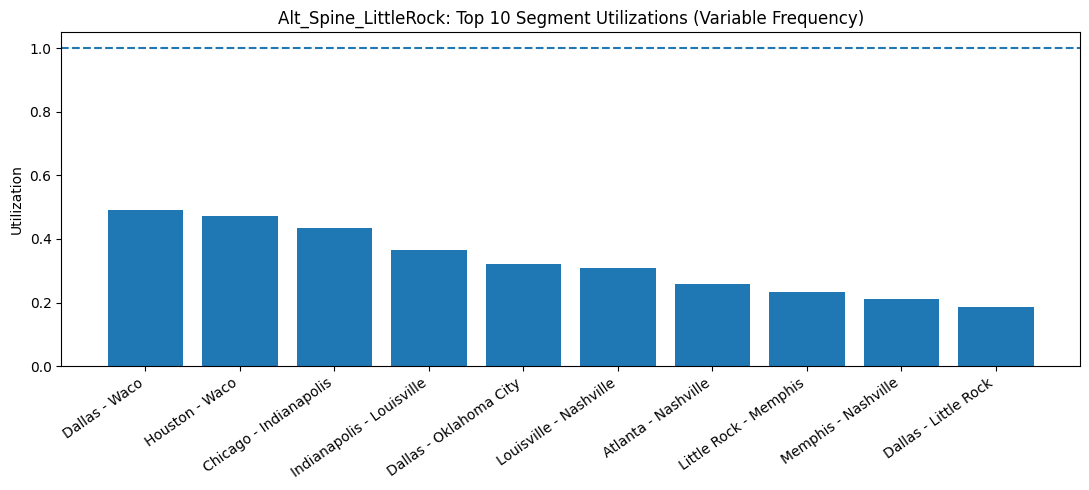

In [98]:
# ============================================================
# CLEAN CELL:
# Variable-Frequency Advanced Realism + Segment Capacity
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float  # metro population in millions


@dataclass
class Segment:
    a: str
    b: str
    dist: float  # miles


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,
    "days_per_year": 365,
}

# Segment-specific train frequencies
# Direction-agnostic, applied to the undirected segment
SEGMENT_FREQUENCIES = {
    # Common Texas core
    tuple(sorted(("Dallas", "Waco"))): 16,
    tuple(sorted(("Waco", "Houston"))): 16,
    tuple(sorted(("Dallas", "Oklahoma City"))): 8,
    tuple(sorted(("Oklahoma City", "Wichita"))): 6,
    tuple(sorted(("Wichita", "Kansas City"))): 6,

    # STL spine
    tuple(sorted(("Chicago", "Springfield IL"))): 12,
    tuple(sorted(("Springfield IL", "St. Louis"))): 12,
    tuple(sorted(("St. Louis", "Kansas City"))): 8,
    tuple(sorted(("St. Louis", "Nashville"))): 8,
    tuple(sorted(("Nashville", "Atlanta"))): 12,

    # Alt spine
    tuple(sorted(("Chicago", "Indianapolis"))): 12,
    tuple(sorted(("Indianapolis", "Louisville"))): 10,
    tuple(sorted(("Louisville", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Memphis"))): 8,
    tuple(sorted(("Memphis", "Little Rock"))): 6,
    tuple(sorted(("Little Rock", "Dallas"))): 8,
}


# -----------------------------
# GRAPH HELPERS
# -----------------------------
def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


# -----------------------------
# REALISM LAYERS
# -----------------------------
def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def annual_segment_capacity(trains_per_day: int, seats_per_train: int, load_factor: float, days_per_year: int) -> float:
    return trains_per_day * seats_per_train * load_factor * days_per_year * 2


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def segment_key(a: str, b: str) -> Tuple[str, str]:
    return tuple(sorted((a, b)))


def path_frequency(path_nodes: List[str]) -> int:
    """
    Use the minimum segment frequency along the path as the effective
    through-service frequency for that OD pair.
    """
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(SEGMENT_FREQUENCIES.get(key, 6))
    return min(freqs) if freqs else 6


# -----------------------------
# CORE MODEL
# -----------------------------
def evaluate_network_variable_freq(segments: List[Segment], city_dict: Dict[str, City], p: dict):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = path_frequency(path)
        freq_mult = frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "effective_trains_per_day": eff_trains_per_day,
            "path_nodes": path,
            "path": " -> ".join(path),
            "auto_time_h": auto_time,
            "rail_time_h": rail_time,
            "rail_share": rail_share,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
        "on_time_pct": p["on_time_pct"],
        "reliability_multiplier": rel_mult,
    }

    return od_df, summary


# -----------------------------
# SEGMENT LOAD / CAPACITY
# -----------------------------
def segment_capacity_analysis_variable_freq(segments: List[Segment], od_df: pd.DataFrame, p: dict) -> pd.DataFrame:
    segment_dist = {}
    for s in segments:
        segment_dist[segment_key(s.a, s.b)] = s.dist

    segment_loads = {k: 0.0 for k in segment_dist.keys()}

    for _, row in od_df.iterrows():
        riders = row["annual_riders"]
        path_nodes = row["path_nodes"]

        for i in range(len(path_nodes) - 1):
            key = segment_key(path_nodes[i], path_nodes[i + 1])
            if key in segment_loads:
                segment_loads[key] += riders

    rows = []
    for key, load in segment_loads.items():
        a, b = key
        trains = SEGMENT_FREQUENCIES.get(key, 6)
        cap = annual_segment_capacity(
            trains_per_day=trains,
            seats_per_train=p["seats_per_train"],
            load_factor=p["load_factor"],
            days_per_year=p["days_per_year"],
        )

        rows.append({
            "segment": f"{a} - {b}",
            "distance_miles": segment_dist[key],
            "trains_per_day": trains,
            "annual_riders_on_segment": load,
            "annual_segment_capacity": cap,
            "utilization_pct": load / cap if cap > 0 else 0.0,
            "over_capacity": load > cap,
        })

    seg_df = pd.DataFrame(rows).sort_values("utilization_pct", ascending=False)
    return seg_df


# -----------------------------
# RUN BOTH NETWORKS
# -----------------------------
all_summaries = []
all_seg_caps = {}
all_top_flows = {}

for name, segs in NETWORKS.items():
    od_df, summary = evaluate_network_variable_freq(segs, CITIES, PARAMS)
    seg_cap_df = segment_capacity_analysis_variable_freq(segs, od_df, PARAMS)

    summary["scenario"] = name
    summary["max_segment_utilization_pct"] = seg_cap_df["utilization_pct"].max()
    summary["segments_over_capacity"] = int(seg_cap_df["over_capacity"].sum())

    all_summaries.append(summary)
    all_seg_caps[name] = seg_cap_df
    all_top_flows[name] = od_df.head(15)

summary_df = pd.DataFrame(all_summaries).sort_values("annual_riders", ascending=False)

print("\n=== VARIABLE-FREQUENCY NETWORK SUMMARY ===\n")
print(summary_df[[
    "scenario",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "farebox_recovery",
    "bcr_like",
    "route_miles",
    "max_segment_utilization_pct",
    "segments_over_capacity",
]])

for name in NETWORKS.keys():
    print(f"\n=== {name} - TOP OD FLOWS ===\n")
    print(all_top_flows[name][[
        "origin", "destination", "distance_miles",
        "effective_trains_per_day", "rail_share",
        "annual_riders", "annual_revenue_m", "path"
    ]])

    print(f"\n=== {name} - TOP LOADED SEGMENTS ===\n")
    print(all_seg_caps[name].head(15))

    print(f"\n=== {name} - BOTTLENECK SEGMENTS ===\n")
    bottlenecks = all_seg_caps[name][all_seg_caps[name]["over_capacity"]]
    if bottlenecks.empty:
        print("No segments over capacity.")
    else:
        print(bottlenecks)


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["annual_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Riders")
plt.title("Variable Frequency: Annual Riders")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["bcr_like"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("BCR-like")
plt.title("Variable Frequency: BCR")
plt.tight_layout()
plt.show()

for name, seg_df in all_seg_caps.items():
    plot_df = seg_df.head(10).copy()
    plt.figure(figsize=(11, 5))
    plt.bar(plot_df["segment"], plot_df["utilization_pct"])
    plt.axhline(1.0, linestyle="--")
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Utilization")
    plt.title(f"{name}: Top 10 Segment Utilizations (Variable Frequency)")
    plt.tight_layout()
    plt.show()


=== BASELINE VARIABLE-FREQUENCY SUMMARY ===

               scenario  annual_riders  annual_revenue_m  bcr_like  max_segment_utilization_pct  segments_over_capacity
1  Alt_Spine_LittleRock  4,448,522.221           344.687     2.614                        0.491                       0
0             STL_Spine  3,536,261.166           285.578     2.497                        0.480                       0

=== TEST 1: STRATEGIC FREQUENCY UPGRADES ===

               scenario                          test  annual_riders  annual_revenue_m  bcr_like  delta_riders  delta_revenue_m  delta_bcr
9  Alt_Spine_LittleRock             Texas_OKC_8_to_12  4,487,250.674           347.110     2.632    38,728.453            2.423      0.018
6  Alt_Spine_LittleRock      STL_Plain_Bridge_6_to_10  4,459,224.168           345.330     2.619    10,701.947            0.643      0.005
5  Alt_Spine_LittleRock                          Base  4,448,522.221           344.687     2.614         0.000            0.000   

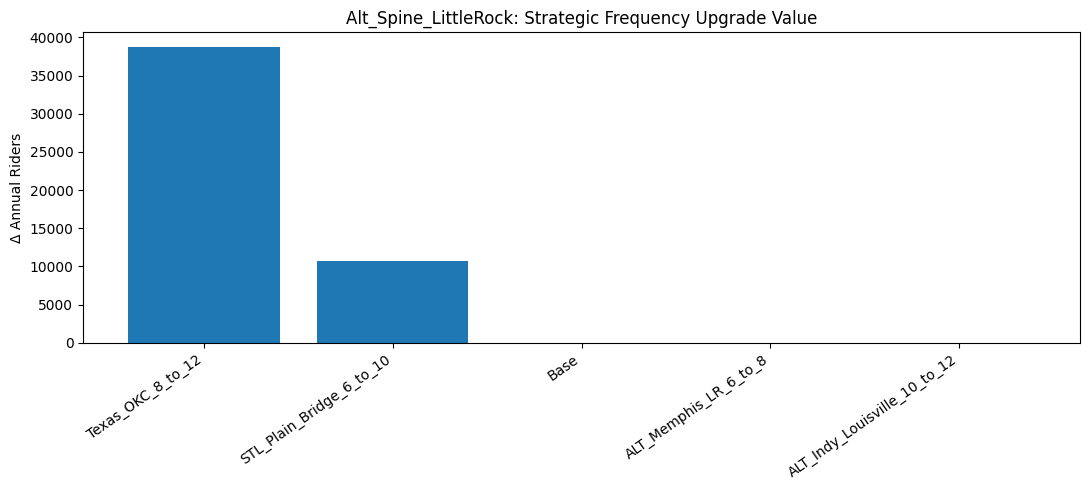

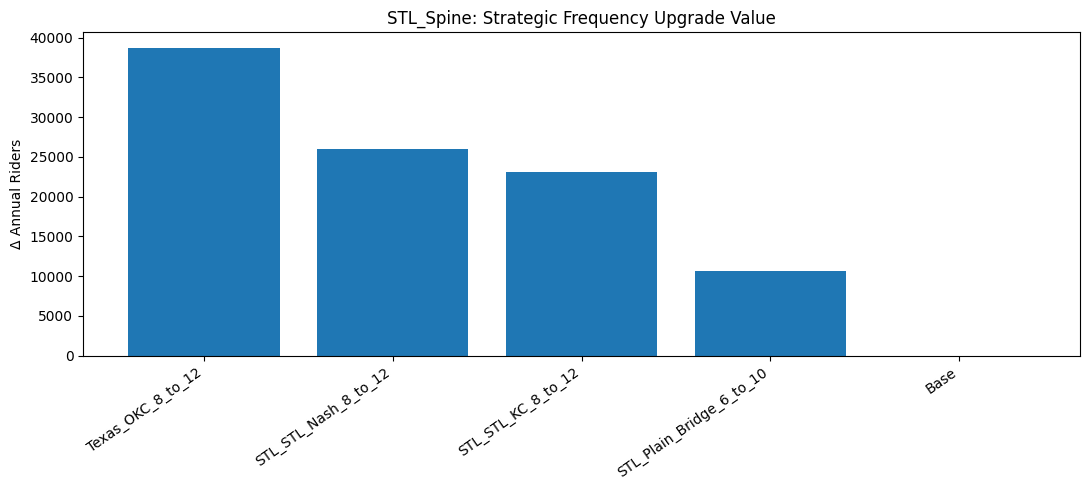

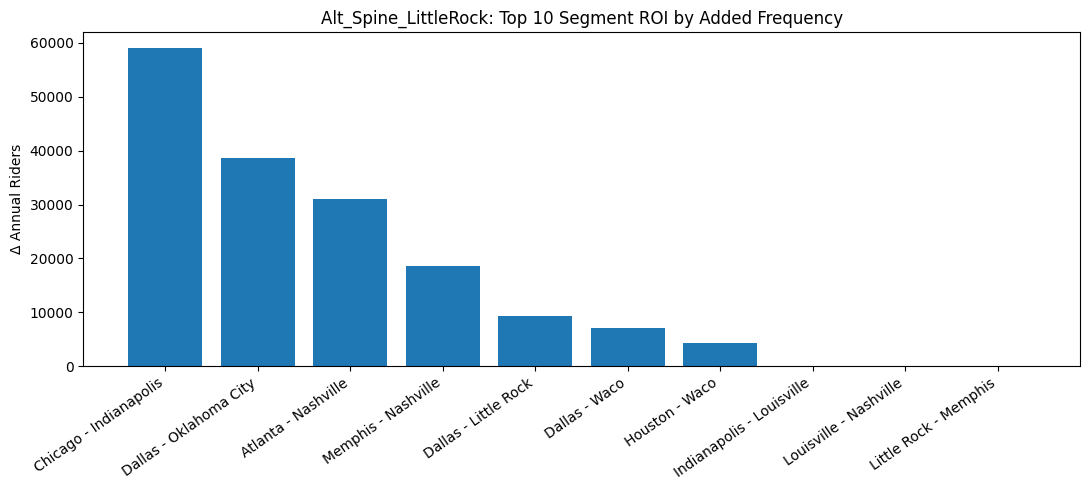

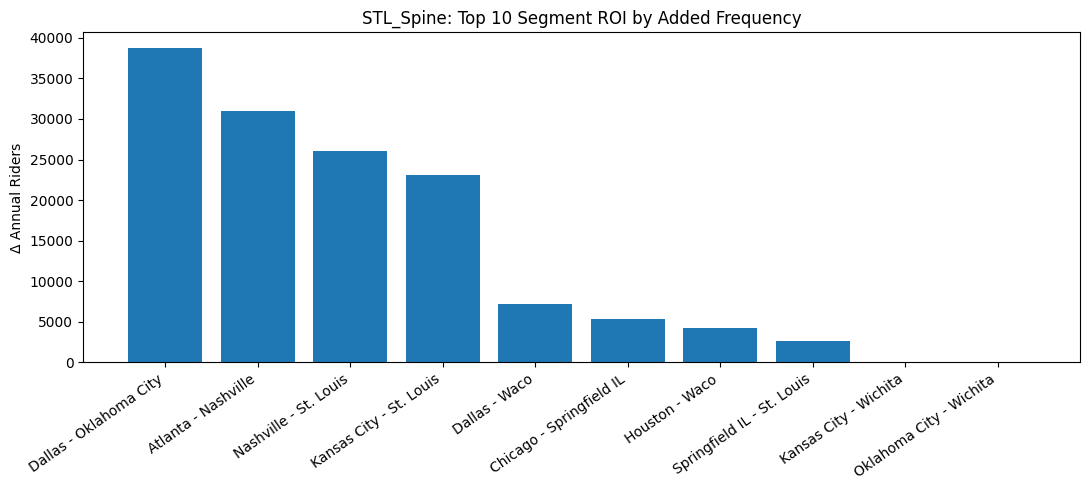

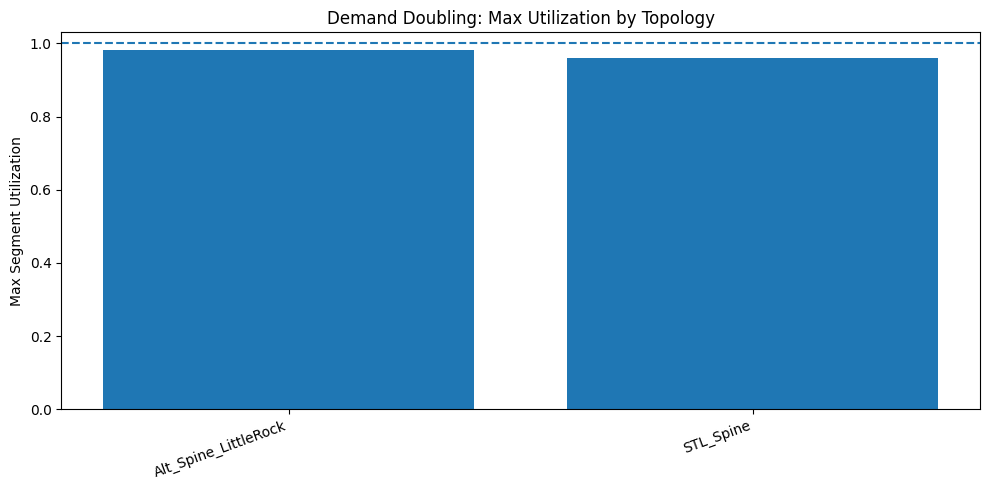

In [99]:
# ============================================================
# CLEAN CELL:
# 3 TESTS ON THE VARIABLE-FREQUENCY NETWORK
# 1) Strategic frequency upgrades
# 2) Demand-doubling bottleneck test
# 3) Corridor ROI ranking for added trains
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple
import copy

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,
    "days_per_year": 365,
}

BASE_SEGMENT_FREQUENCIES = {
    tuple(sorted(("Dallas", "Waco"))): 16,
    tuple(sorted(("Waco", "Houston"))): 16,
    tuple(sorted(("Dallas", "Oklahoma City"))): 8,
    tuple(sorted(("Oklahoma City", "Wichita"))): 6,
    tuple(sorted(("Wichita", "Kansas City"))): 6,

    tuple(sorted(("Chicago", "Springfield IL"))): 12,
    tuple(sorted(("Springfield IL", "St. Louis"))): 12,
    tuple(sorted(("St. Louis", "Kansas City"))): 8,
    tuple(sorted(("St. Louis", "Nashville"))): 8,
    tuple(sorted(("Nashville", "Atlanta"))): 12,

    tuple(sorted(("Chicago", "Indianapolis"))): 12,
    tuple(sorted(("Indianapolis", "Louisville"))): 10,
    tuple(sorted(("Louisville", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Memphis"))): 8,
    tuple(sorted(("Memphis", "Little Rock"))): 6,
    tuple(sorted(("Little Rock", "Dallas"))): 8,
}


# -----------------------------
# HELPERS
# -----------------------------
def segment_key(a: str, b: str) -> Tuple[str, str]:
    return tuple(sorted((a, b)))


def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def annual_segment_capacity(trains_per_day: int, seats_per_train: int, load_factor: float, days_per_year: int) -> float:
    return trains_per_day * seats_per_train * load_factor * days_per_year * 2


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def path_frequency(path_nodes: List[str], seg_freqs: Dict[Tuple[str, str], int]) -> int:
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6


# -----------------------------
# MODEL
# -----------------------------
def evaluate_network_variable_freq(
    segments: List[Segment],
    city_dict: Dict[str, City],
    p: dict,
    seg_freqs: Dict[Tuple[str, str], int],
):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = path_frequency(path, seg_freqs)
        freq_mult = frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "stops_between": stops,
            "effective_trains_per_day": eff_trains_per_day,
            "path_nodes": path,
            "path": " -> ".join(path),
            "auto_time_h": auto_time,
            "rail_time_h": rail_time,
            "rail_share": rail_share,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }

    return od_df, summary


def segment_capacity_analysis_variable_freq(
    segments: List[Segment],
    od_df: pd.DataFrame,
    p: dict,
    seg_freqs: Dict[Tuple[str, str], int],
) -> pd.DataFrame:
    segment_dist = {}
    for s in segments:
        segment_dist[segment_key(s.a, s.b)] = s.dist

    segment_loads = {k: 0.0 for k in segment_dist.keys()}

    for _, row in od_df.iterrows():
        riders = row["annual_riders"]
        path_nodes = row["path_nodes"]

        for i in range(len(path_nodes) - 1):
            key = segment_key(path_nodes[i], path_nodes[i + 1])
            if key in segment_loads:
                segment_loads[key] += riders

    rows = []
    for key, load in segment_loads.items():
        a, b = key
        trains = seg_freqs.get(key, 6)
        cap = annual_segment_capacity(
            trains_per_day=trains,
            seats_per_train=p["seats_per_train"],
            load_factor=p["load_factor"],
            days_per_year=p["days_per_year"],
        )

        rows.append({
            "segment": f"{a} - {b}",
            "distance_miles": segment_dist[key],
            "trains_per_day": trains,
            "annual_riders_on_segment": load,
            "annual_segment_capacity": cap,
            "utilization_pct": load / cap if cap > 0 else 0.0,
            "over_capacity": load > cap,
        })

    return pd.DataFrame(rows).sort_values("utilization_pct", ascending=False)


# -----------------------------
# TEST 1: STRATEGIC FREQUENCY UPGRADES
# -----------------------------
UPGRADE_PACKAGES = {
    "STL_Plain_Bridge_6_to_10": [
        segment_key("Oklahoma City", "Wichita"),
        segment_key("Wichita", "Kansas City"),
    ],
    "ALT_Memphis_LR_6_to_8": [
        segment_key("Memphis", "Little Rock"),
    ],
    "ALT_Indy_Louisville_10_to_12": [
        segment_key("Indianapolis", "Louisville"),
        segment_key("Louisville", "Nashville"),
    ],
    "Texas_OKC_8_to_12": [
        segment_key("Dallas", "Oklahoma City"),
    ],
    "STL_STL_Nash_8_to_12": [
        segment_key("St. Louis", "Nashville"),
    ],
    "STL_STL_KC_8_to_12": [
        segment_key("St. Louis", "Kansas City"),
    ],
}

def apply_upgrade_package(base_freqs, package_name):
    new_freqs = copy.deepcopy(base_freqs)
    if package_name == "STL_Plain_Bridge_6_to_10":
        for seg in UPGRADE_PACKAGES[package_name]:
            new_freqs[seg] = 10
    elif package_name == "ALT_Memphis_LR_6_to_8":
        for seg in UPGRADE_PACKAGES[package_name]:
            new_freqs[seg] = 8
    elif package_name == "ALT_Indy_Louisville_10_to_12":
        new_freqs[segment_key("Indianapolis", "Louisville")] = 12
        new_freqs[segment_key("Louisville", "Nashville")] = 12
    elif package_name == "Texas_OKC_8_to_12":
        new_freqs[segment_key("Dallas", "Oklahoma City")] = 12
    elif package_name == "STL_STL_Nash_8_to_12":
        new_freqs[segment_key("St. Louis", "Nashville")] = 12
    elif package_name == "STL_STL_KC_8_to_12":
        new_freqs[segment_key("St. Louis", "Kansas City")] = 12
    return new_freqs


strategic_rows = []

for scenario_name, segs in NETWORKS.items():
    _, base_summary = evaluate_network_variable_freq(segs, CITIES, PARAMS, BASE_SEGMENT_FREQUENCIES)

    strategic_rows.append({
        "scenario": scenario_name,
        "test": "Base",
        "annual_riders": base_summary["annual_riders"],
        "annual_revenue_m": base_summary["annual_revenue_m"],
        "bcr_like": base_summary["bcr_like"],
        "delta_riders": 0.0,
        "delta_revenue_m": 0.0,
        "delta_bcr": 0.0,
    })

    for package_name in UPGRADE_PACKAGES.keys():
        # only evaluate packages that touch segments in the network
        package_segments = UPGRADE_PACKAGES[package_name]
        network_seg_keys = {segment_key(s.a, s.b) for s in segs}
        if not any(seg in network_seg_keys for seg in package_segments):
            continue

        upgraded_freqs = apply_upgrade_package(BASE_SEGMENT_FREQUENCIES, package_name)
        _, upgraded_summary = evaluate_network_variable_freq(segs, CITIES, PARAMS, upgraded_freqs)

        strategic_rows.append({
            "scenario": scenario_name,
            "test": package_name,
            "annual_riders": upgraded_summary["annual_riders"],
            "annual_revenue_m": upgraded_summary["annual_revenue_m"],
            "bcr_like": upgraded_summary["bcr_like"],
            "delta_riders": upgraded_summary["annual_riders"] - base_summary["annual_riders"],
            "delta_revenue_m": upgraded_summary["annual_revenue_m"] - base_summary["annual_revenue_m"],
            "delta_bcr": upgraded_summary["bcr_like"] - base_summary["bcr_like"],
        })

strategic_df = pd.DataFrame(strategic_rows).sort_values(["scenario", "delta_riders"], ascending=[True, False])


# -----------------------------
# TEST 2: DEMAND DOUBLING / FIRST BOTTLENECKS
# -----------------------------
double_params = copy.deepcopy(PARAMS)
double_params["trips_factor"] = PARAMS["trips_factor"] * 2.0

doubling_summary_rows = []
doubling_seg_caps = {}

for scenario_name, segs in NETWORKS.items():
    doubled_od_df, doubled_summary = evaluate_network_variable_freq(segs, CITIES, double_params, BASE_SEGMENT_FREQUENCIES)
    doubled_seg_cap_df = segment_capacity_analysis_variable_freq(segs, doubled_od_df, double_params, BASE_SEGMENT_FREQUENCIES)

    doubled_summary["scenario"] = scenario_name
    doubled_summary["max_segment_utilization_pct"] = doubled_seg_cap_df["utilization_pct"].max()
    doubled_summary["segments_over_capacity"] = int(doubled_seg_cap_df["over_capacity"].sum())

    doubling_summary_rows.append(doubled_summary)
    doubling_seg_caps[scenario_name] = doubled_seg_cap_df

doubling_summary_df = pd.DataFrame(doubling_summary_rows).sort_values("annual_riders", ascending=False)


# -----------------------------
# TEST 3: CORRIDOR ROI RANKING FOR ADDED TRAINS
# -----------------------------
roi_rows = []

for scenario_name, segs in NETWORKS.items():
    _, base_summary = evaluate_network_variable_freq(segs, CITIES, PARAMS, BASE_SEGMENT_FREQUENCIES)
    network_seg_keys = {segment_key(s.a, s.b): s.dist for s in segs}

    for seg_key_, dist in network_seg_keys.items():
        current_freq = BASE_SEGMENT_FREQUENCIES.get(seg_key_, 6)
        upgraded_freqs = copy.deepcopy(BASE_SEGMENT_FREQUENCIES)
        upgraded_freqs[seg_key_] = current_freq + 2

        _, upgraded_summary = evaluate_network_variable_freq(segs, CITIES, PARAMS, upgraded_freqs)

        delta_riders = upgraded_summary["annual_riders"] - base_summary["annual_riders"]
        delta_revenue = upgraded_summary["annual_revenue_m"] - base_summary["annual_revenue_m"]
        delta_bcr = upgraded_summary["bcr_like"] - base_summary["bcr_like"]

        added_daily_seats = 2 * PARAMS["seats_per_train"] * PARAMS["load_factor"] * 2  # +2 trains/day, bidirectional
        riders_per_added_train = delta_riders / 2.0 if 2.0 > 0 else 0.0

        roi_rows.append({
            "scenario": scenario_name,
            "segment": f"{seg_key_[0]} - {seg_key_[1]}",
            "current_trains_per_day": current_freq,
            "new_trains_per_day": current_freq + 2,
            "distance_miles": dist,
            "delta_riders": delta_riders,
            "delta_revenue_m": delta_revenue,
            "delta_bcr": delta_bcr,
            "riders_per_added_train": riders_per_added_train,
        })

roi_df = pd.DataFrame(roi_rows).sort_values(["scenario", "delta_riders"], ascending=[True, False])


# -----------------------------
# BASELINE SUMMARIES
# -----------------------------
baseline_rows = []
baseline_segcaps = {}

for scenario_name, segs in NETWORKS.items():
    od_df, summary = evaluate_network_variable_freq(segs, CITIES, PARAMS, BASE_SEGMENT_FREQUENCIES)
    segcap_df = segment_capacity_analysis_variable_freq(segs, od_df, PARAMS, BASE_SEGMENT_FREQUENCIES)
    summary["scenario"] = scenario_name
    summary["max_segment_utilization_pct"] = segcap_df["utilization_pct"].max()
    summary["segments_over_capacity"] = int(segcap_df["over_capacity"].sum())
    baseline_rows.append(summary)
    baseline_segcaps[scenario_name] = segcap_df

baseline_summary_df = pd.DataFrame(baseline_rows).sort_values("annual_riders", ascending=False)


# -----------------------------
# OUTPUT
# -----------------------------
print("\n=== BASELINE VARIABLE-FREQUENCY SUMMARY ===\n")
print(baseline_summary_df[[
    "scenario", "annual_riders", "annual_revenue_m", "bcr_like",
    "max_segment_utilization_pct", "segments_over_capacity"
]])

print("\n=== TEST 1: STRATEGIC FREQUENCY UPGRADES ===\n")
print(strategic_df)

print("\n=== TEST 2: DEMAND-DOUBLING SUMMARY ===\n")
print(doubling_summary_df[[
    "scenario", "annual_riders", "annual_revenue_m", "bcr_like",
    "max_segment_utilization_pct", "segments_over_capacity"
]])

for scenario_name, segcap_df in doubling_seg_caps.items():
    print(f"\n=== {scenario_name} - DOUBLED DEMAND TOP LOADED SEGMENTS ===\n")
    print(segcap_df.head(15))

    print(f"\n=== {scenario_name} - DOUBLED DEMAND BOTTLENECKS ===\n")
    bottlenecks = segcap_df[segcap_df["over_capacity"]]
    if bottlenecks.empty:
        print("No segments over capacity under doubled demand.")
    else:
        print(bottlenecks)

print("\n=== TEST 3: CORRIDOR ROI RANKING ===\n")
print(roi_df)


# -----------------------------
# PLOTS
# -----------------------------
for scenario_name in strategic_df["scenario"].unique():
    sub = strategic_df[strategic_df["scenario"] == scenario_name].copy()
    sub = sub.sort_values("delta_riders", ascending=False)

    plt.figure(figsize=(11, 5))
    plt.bar(sub["test"], sub["delta_riders"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Δ Annual Riders")
    plt.title(f"{scenario_name}: Strategic Frequency Upgrade Value")
    plt.tight_layout()
    plt.show()

for scenario_name in roi_df["scenario"].unique():
    sub = roi_df[roi_df["scenario"] == scenario_name].copy().sort_values("delta_riders", ascending=False).head(10)

    plt.figure(figsize=(11, 5))
    plt.bar(sub["segment"], sub["delta_riders"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Δ Annual Riders")
    plt.title(f"{scenario_name}: Top 10 Segment ROI by Added Frequency")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
plt.bar(doubling_summary_df["scenario"], doubling_summary_df["max_segment_utilization_pct"])
plt.axhline(1.0, linestyle="--")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Max Segment Utilization")
plt.title("Demand Doubling: Max Utilization by Topology")
plt.tight_layout()
plt.show()


=== FREQUENCY OPTIMIZATION HISTORY ===

    step              scenario              chosen_segment  old_freq  new_freq  delta_riders  delta_revenue_m  delta_bcr  annual_riders  annual_revenue_m  bcr_like
0      0             STL_Spine                        BASE       NaN       NaN         0.000            0.000      0.000  3,536,261.166           285.578     2.497
1      1             STL_Spine      Dallas - Oklahoma City     8.000    10.000    38,728.453            2.423      0.021  3,574,989.619           288.001     2.518
2      2             STL_Spine         Atlanta - Nashville    12.000    14.000    30,945.245            1.934      0.017  3,605,934.864           289.935     2.535
3      3             STL_Spine       Nashville - St. Louis     8.000    10.000    26,057.683            3.414      0.030  3,631,992.547           293.349     2.565
4      4             STL_Spine     Kansas City - St. Louis     8.000    10.000    26,302.756            2.591      0.023  3,658,295.303    

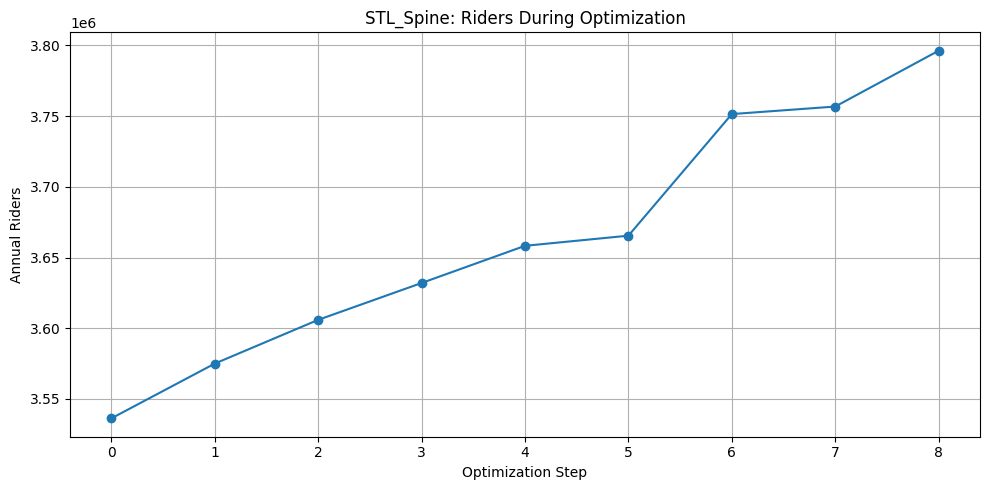

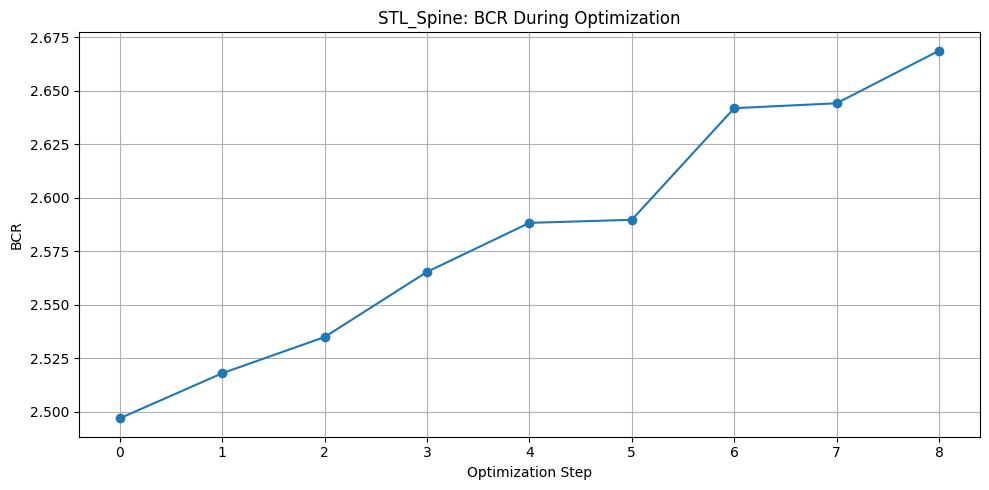

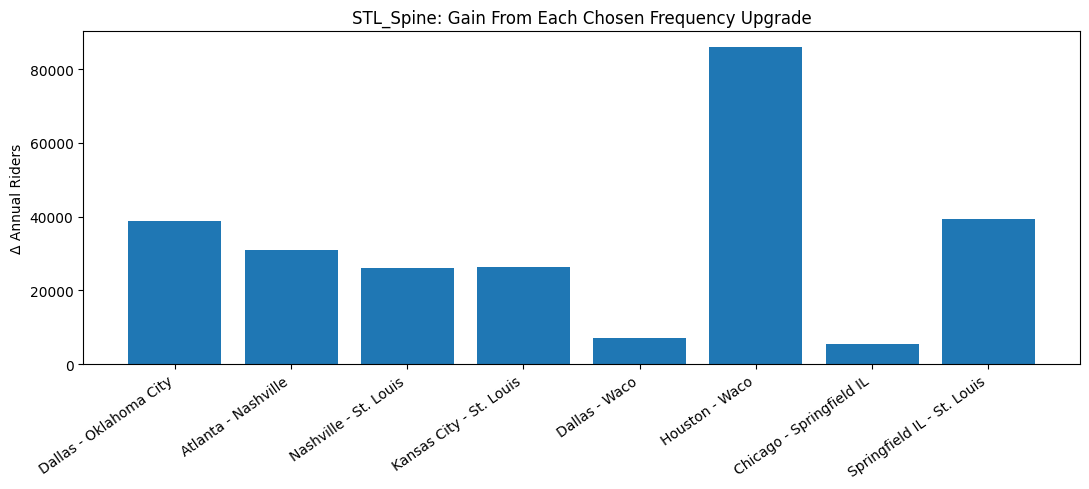

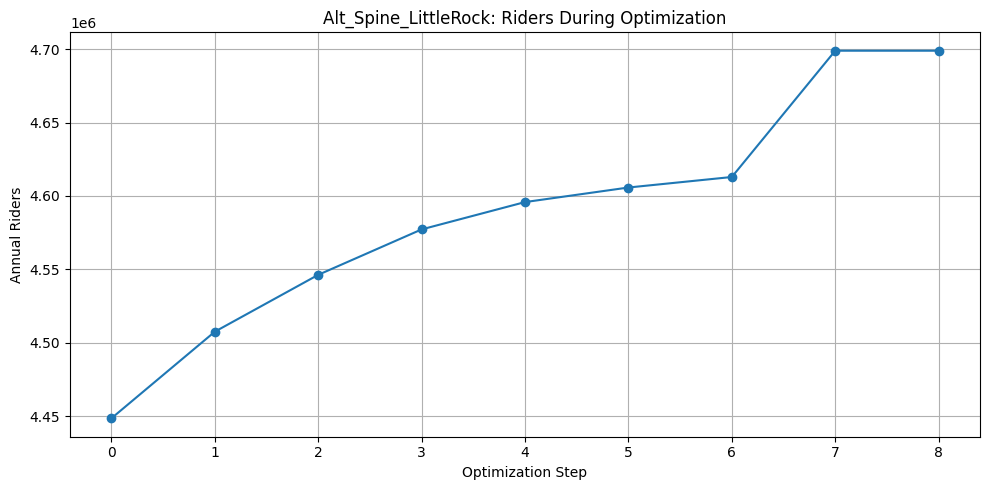

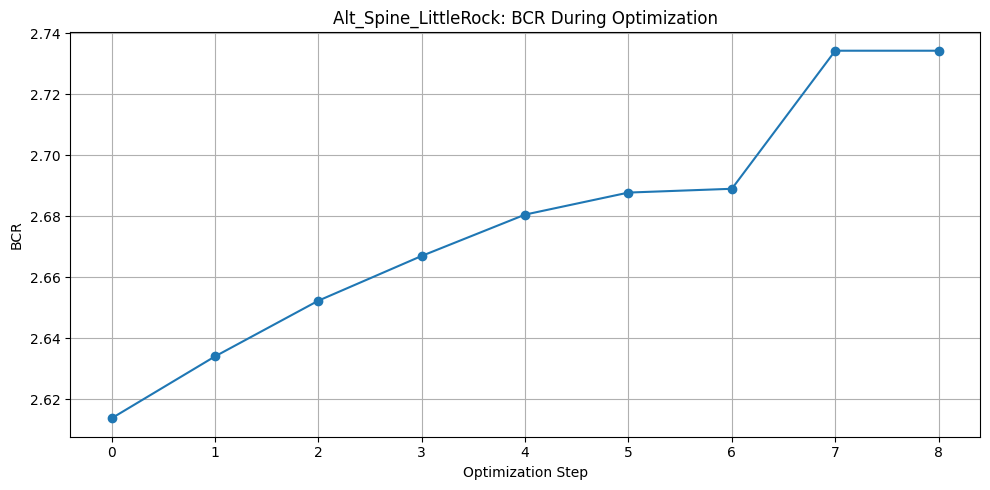

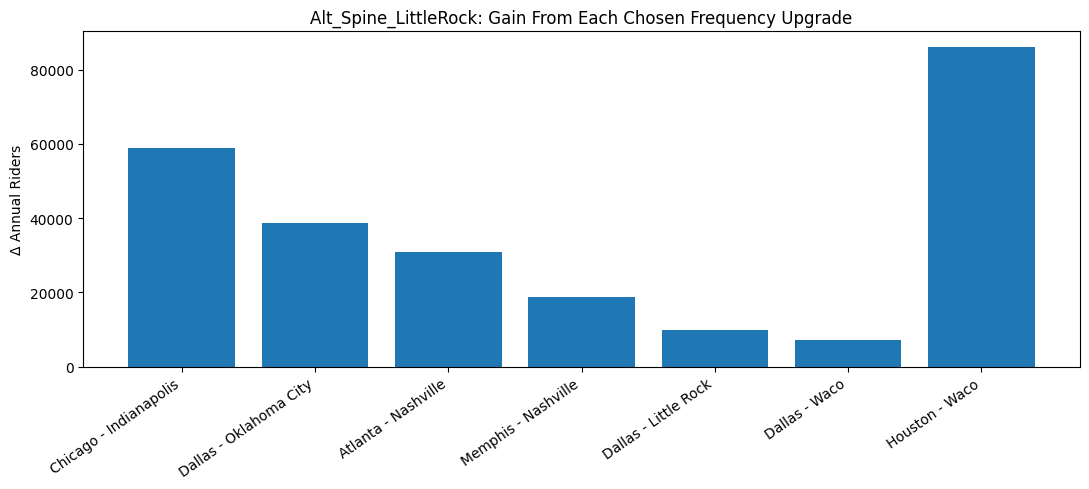

In [100]:
# ============================================================
# CLEAN CELL:
# GREEDY FREQUENCY OPTIMIZATION ENGINE
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
import copy
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,
    "days_per_year": 365,
}

BASE_SEGMENT_FREQUENCIES = {
    tuple(sorted(("Dallas", "Waco"))): 16,
    tuple(sorted(("Waco", "Houston"))): 16,
    tuple(sorted(("Dallas", "Oklahoma City"))): 8,
    tuple(sorted(("Oklahoma City", "Wichita"))): 6,
    tuple(sorted(("Wichita", "Kansas City"))): 6,

    tuple(sorted(("Chicago", "Springfield IL"))): 12,
    tuple(sorted(("Springfield IL", "St. Louis"))): 12,
    tuple(sorted(("St. Louis", "Kansas City"))): 8,
    tuple(sorted(("St. Louis", "Nashville"))): 8,
    tuple(sorted(("Nashville", "Atlanta"))): 12,

    tuple(sorted(("Chicago", "Indianapolis"))): 12,
    tuple(sorted(("Indianapolis", "Louisville"))): 10,
    tuple(sorted(("Louisville", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Memphis"))): 8,
    tuple(sorted(("Memphis", "Little Rock"))): 6,
    tuple(sorted(("Little Rock", "Dallas"))): 8,
}


# -----------------------------
# HELPERS
# -----------------------------
def segment_key(a: str, b: str) -> Tuple[str, str]:
    return tuple(sorted((a, b)))


def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def path_frequency(path_nodes: List[str], seg_freqs: Dict[Tuple[str, str], int]) -> int:
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6


# -----------------------------
# MODEL
# -----------------------------
def evaluate_network_variable_freq(
    segments: List[Segment],
    city_dict: Dict[str, City],
    p: dict,
    seg_freqs: Dict[Tuple[str, str], int],
):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = path_frequency(path, seg_freqs)
        freq_mult = frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "path": " -> ".join(path),
            "effective_trains_per_day": eff_trains_per_day,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
    }

    return od_df, summary


# -----------------------------
# OPTIMIZATION ENGINE
# -----------------------------
def optimize_frequencies(
    scenario_name: str,
    segments: List[Segment],
    base_freqs: Dict[Tuple[str, str], int],
    params: dict,
    n_steps: int = 8,
    train_increment: int = 2,
    max_trains_per_day: int = 20,
):
    network_seg_keys = {segment_key(s.a, s.b): s.dist for s in segments}
    current_freqs = copy.deepcopy(base_freqs)

    _, base_summary = evaluate_network_variable_freq(segments, CITIES, params, current_freqs)

    history = [{
        "step": 0,
        "scenario": scenario_name,
        "chosen_segment": "BASE",
        "old_freq": None,
        "new_freq": None,
        "delta_riders": 0.0,
        "delta_revenue_m": 0.0,
        "delta_bcr": 0.0,
        "annual_riders": base_summary["annual_riders"],
        "annual_revenue_m": base_summary["annual_revenue_m"],
        "bcr_like": base_summary["bcr_like"],
    }]

    for step in range(1, n_steps + 1):
        _, current_summary = evaluate_network_variable_freq(segments, CITIES, params, current_freqs)

        best_choice = None
        best_result = None

        for seg_key_, dist in network_seg_keys.items():
            old_freq = current_freqs.get(seg_key_, 6)
            if old_freq >= max_trains_per_day:
                continue

            trial_freqs = copy.deepcopy(current_freqs)
            trial_freqs[seg_key_] = min(max_trains_per_day, old_freq + train_increment)

            _, trial_summary = evaluate_network_variable_freq(segments, CITIES, params, trial_freqs)

            delta_riders = trial_summary["annual_riders"] - current_summary["annual_riders"]
            delta_revenue = trial_summary["annual_revenue_m"] - current_summary["annual_revenue_m"]
            delta_bcr = trial_summary["bcr_like"] - current_summary["bcr_like"]

            score = (delta_riders, delta_revenue, delta_bcr)

            if best_choice is None or score > best_choice["score"]:
                best_choice = {
                    "segment": f"{seg_key_[0]} - {seg_key_[1]}",
                    "seg_key": seg_key_,
                    "old_freq": old_freq,
                    "new_freq": trial_freqs[seg_key_],
                    "delta_riders": delta_riders,
                    "delta_revenue_m": delta_revenue,
                    "delta_bcr": delta_bcr,
                    "score": score,
                }
                best_result = trial_summary

        if best_choice is None:
            break

        current_freqs[best_choice["seg_key"]] = best_choice["new_freq"]

        history.append({
            "step": step,
            "scenario": scenario_name,
            "chosen_segment": best_choice["segment"],
            "old_freq": best_choice["old_freq"],
            "new_freq": best_choice["new_freq"],
            "delta_riders": best_choice["delta_riders"],
            "delta_revenue_m": best_choice["delta_revenue_m"],
            "delta_bcr": best_choice["delta_bcr"],
            "annual_riders": best_result["annual_riders"],
            "annual_revenue_m": best_result["annual_revenue_m"],
            "bcr_like": best_result["bcr_like"],
        })

    final_freqs_rows = []
    for seg_key_, dist in sorted(network_seg_keys.items()):
        final_freqs_rows.append({
            "scenario": scenario_name,
            "segment": f"{seg_key_[0]} - {seg_key_[1]}",
            "distance_miles": dist,
            "final_trains_per_day": current_freqs.get(seg_key_, 6),
        })

    return pd.DataFrame(history), pd.DataFrame(final_freqs_rows)


# -----------------------------
# RUN OPTIMIZER
# -----------------------------
histories = []
final_freq_tables = []

for scenario_name, segs in NETWORKS.items():
    hist_df, final_freq_df = optimize_frequencies(
        scenario_name=scenario_name,
        segments=segs,
        base_freqs=BASE_SEGMENT_FREQUENCIES,
        params=PARAMS,
        n_steps=8,
        train_increment=2,
        max_trains_per_day=20,
    )
    histories.append(hist_df)
    final_freq_tables.append(final_freq_df)

history_df = pd.concat(histories, ignore_index=True)
final_freq_df = pd.concat(final_freq_tables, ignore_index=True)

print("\n=== FREQUENCY OPTIMIZATION HISTORY ===\n")
print(history_df)

print("\n=== FINAL OPTIMIZED FREQUENCIES ===\n")
print(final_freq_df.sort_values(["scenario", "final_trains_per_day"], ascending=[True, False]))


# -----------------------------
# PLOTS
# -----------------------------
for scenario_name in history_df["scenario"].unique():
    sub = history_df[history_df["scenario"] == scenario_name].copy()

    plt.figure(figsize=(10, 5))
    plt.plot(sub["step"], sub["annual_riders"], marker="o")
    plt.title(f"{scenario_name}: Riders During Optimization")
    plt.xlabel("Optimization Step")
    plt.ylabel("Annual Riders")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(sub["step"], sub["bcr_like"], marker="o")
    plt.title(f"{scenario_name}: BCR During Optimization")
    plt.xlabel("Optimization Step")
    plt.ylabel("BCR")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    choice_sub = sub[sub["step"] > 0].copy()
    plt.figure(figsize=(11, 5))
    plt.bar(choice_sub["chosen_segment"], choice_sub["delta_riders"])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Δ Annual Riders")
    plt.title(f"{scenario_name}: Gain From Each Chosen Frequency Upgrade")
    plt.tight_layout()
    plt.show()


=== STOP-RULE OPTIMIZATION HISTORY ===

   step              scenario           chosen_segment  old_freq  new_freq  delta_riders  delta_revenue_m  delta_bcr  annual_riders  annual_revenue_m  bcr_like stop_reason
0     0             STL_Spine                     BASE       NaN       NaN         0.000            0.000      0.000  3,536,261.166           285.578     2.497            
1     1             STL_Spine   Dallas - Oklahoma City     8.000    10.000    38,728.453            2.423      0.021  3,574,989.619           288.001     2.518            
2     2             STL_Spine      Atlanta - Nashville    12.000    14.000    30,945.245            1.934      0.017  3,605,934.864           289.935     2.535            
3     3             STL_Spine    Nashville - St. Louis     8.000    10.000    26,057.683            3.414      0.030  3,631,992.547           293.349     2.565            
4     4             STL_Spine  Kansas City - St. Louis     8.000    10.000    26,302.756           

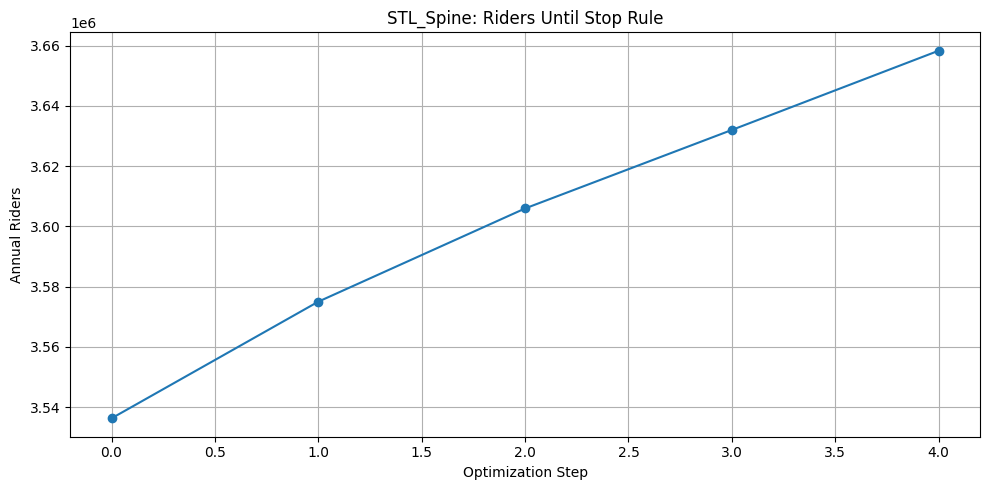

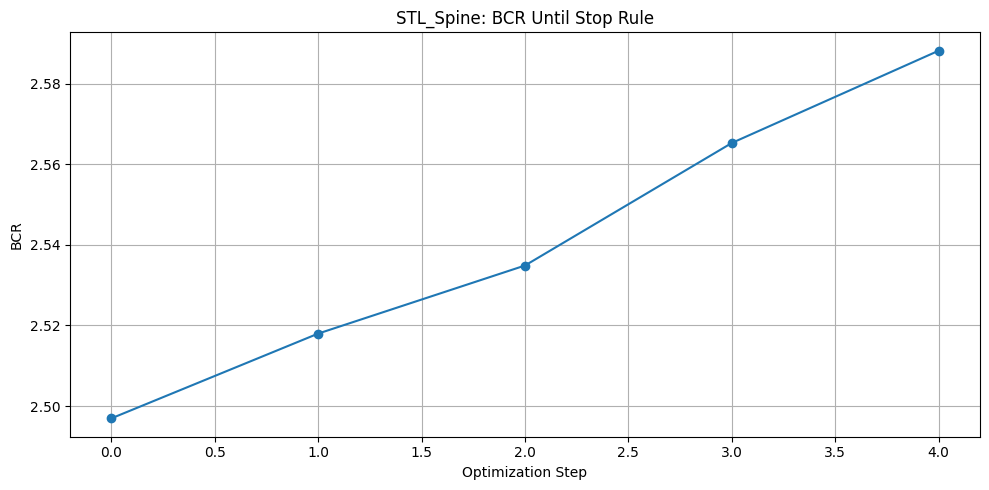

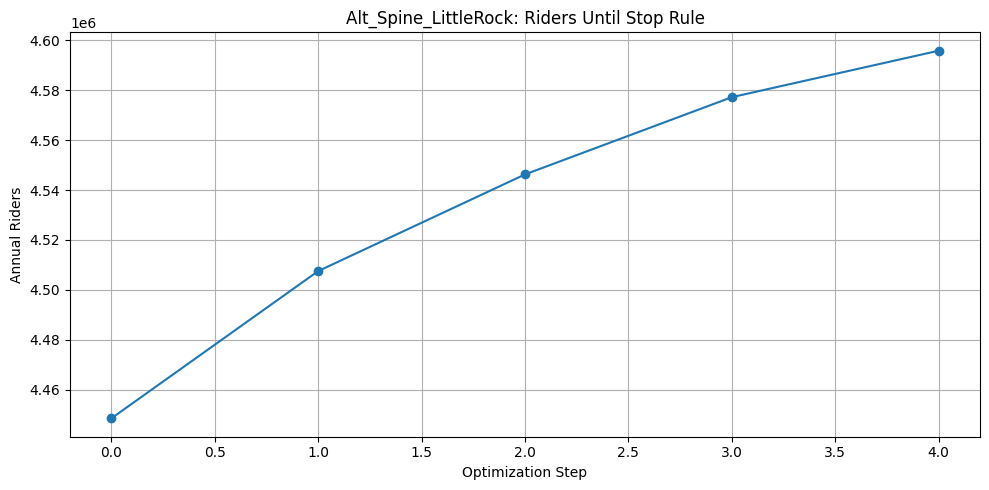

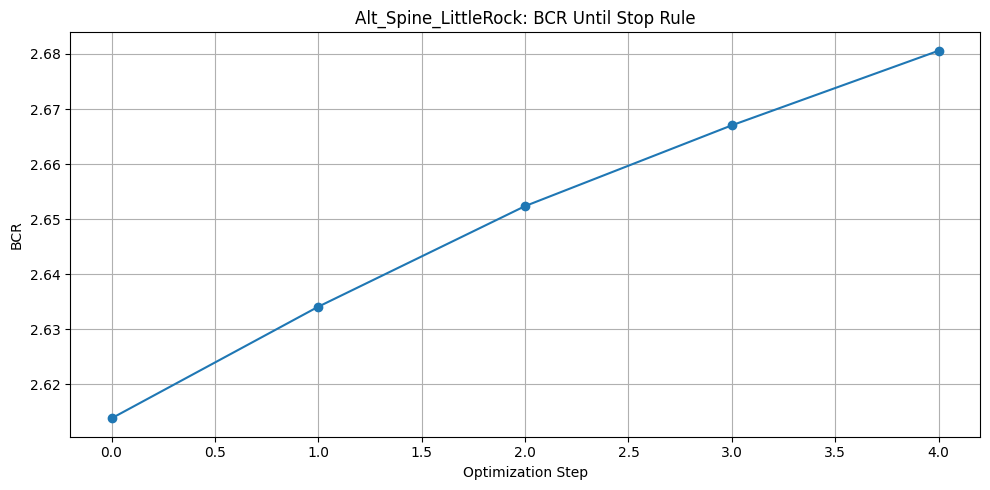

In [101]:
# ============================================================
# CLEAN CELL:
# FREQUENCY OPTIMIZATION WITH STOP RULE
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
import copy
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float


@dataclass
class Segment:
    a: str
    b: str
    dist: float


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "om_per_mile": 0.10,
    "capex_per_mile": 28.0,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "seats_per_train": 400,
    "load_factor": 0.70,
    "on_time_pct": 0.85,
    "days_per_year": 365,
}

BASE_SEGMENT_FREQUENCIES = {
    tuple(sorted(("Dallas", "Waco"))): 16,
    tuple(sorted(("Waco", "Houston"))): 16,
    tuple(sorted(("Dallas", "Oklahoma City"))): 8,
    tuple(sorted(("Oklahoma City", "Wichita"))): 6,
    tuple(sorted(("Wichita", "Kansas City"))): 6,

    tuple(sorted(("Chicago", "Springfield IL"))): 12,
    tuple(sorted(("Springfield IL", "St. Louis"))): 12,
    tuple(sorted(("St. Louis", "Kansas City"))): 8,
    tuple(sorted(("St. Louis", "Nashville"))): 8,
    tuple(sorted(("Nashville", "Atlanta"))): 12,

    tuple(sorted(("Chicago", "Indianapolis"))): 12,
    tuple(sorted(("Indianapolis", "Louisville"))): 10,
    tuple(sorted(("Louisville", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Memphis"))): 8,
    tuple(sorted(("Memphis", "Little Rock"))): 6,
    tuple(sorted(("Little Rock", "Dallas"))): 8,
}


# -----------------------------
# STOP RULES
# -----------------------------
MIN_DELTA_RIDERS = 10_000
MIN_DELTA_REVENUE_M = 1.0
MIN_DELTA_BCR = 0.01
MAX_TRAINS_PER_DAY = 20
TRAIN_INCREMENT = 2
MAX_STEPS = 20


# -----------------------------
# HELPERS
# -----------------------------
def segment_key(a: str, b: str) -> Tuple[str, str]:
    return tuple(sorted((a, b)))


def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def mode_share_rail(distance: float, rail_time: float, auto_time: float, p: dict) -> float:
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


def path_frequency(path_nodes: List[str], seg_freqs: Dict[Tuple[str, str], int]) -> int:
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6


# -----------------------------
# MODEL
# -----------------------------
def evaluate_network_variable_freq(
    segments: List[Segment],
    city_dict: Dict[str, City],
    p: dict,
    seg_freqs: Dict[Tuple[str, str], int],
):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = path_frequency(path, seg_freqs)
        freq_mult = frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = mode_share_rail(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]

        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p["om_per_mile"]

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
    }

    return od_df, summary


# -----------------------------
# OPTIMIZER WITH STOP RULE
# -----------------------------
def optimize_with_stop_rule(
    scenario_name: str,
    segments: List[Segment],
    base_freqs: Dict[Tuple[str, str], int],
    params: dict,
):
    network_seg_keys = {segment_key(s.a, s.b): s.dist for s in segments}
    current_freqs = copy.deepcopy(base_freqs)

    _, base_summary = evaluate_network_variable_freq(segments, CITIES, params, current_freqs)

    history = [{
        "step": 0,
        "scenario": scenario_name,
        "chosen_segment": "BASE",
        "old_freq": None,
        "new_freq": None,
        "delta_riders": 0.0,
        "delta_revenue_m": 0.0,
        "delta_bcr": 0.0,
        "annual_riders": base_summary["annual_riders"],
        "annual_revenue_m": base_summary["annual_revenue_m"],
        "bcr_like": base_summary["bcr_like"],
        "stop_reason": "",
    }]

    stop_reason = None

    for step in range(1, MAX_STEPS + 1):
        _, current_summary = evaluate_network_variable_freq(segments, CITIES, params, current_freqs)

        best_choice = None
        best_result = None

        for seg_key_, dist in network_seg_keys.items():
            old_freq = current_freqs.get(seg_key_, 6)
            if old_freq >= MAX_TRAINS_PER_DAY:
                continue

            trial_freqs = copy.deepcopy(current_freqs)
            trial_freqs[seg_key_] = min(MAX_TRAINS_PER_DAY, old_freq + TRAIN_INCREMENT)

            _, trial_summary = evaluate_network_variable_freq(segments, CITIES, params, trial_freqs)

            delta_riders = trial_summary["annual_riders"] - current_summary["annual_riders"]
            delta_revenue = trial_summary["annual_revenue_m"] - current_summary["annual_revenue_m"]
            delta_bcr = trial_summary["bcr_like"] - current_summary["bcr_like"]

            score = (delta_riders, delta_revenue, delta_bcr)

            if best_choice is None or score > best_choice["score"]:
                best_choice = {
                    "segment": f"{seg_key_[0]} - {seg_key_[1]}",
                    "seg_key": seg_key_,
                    "old_freq": old_freq,
                    "new_freq": trial_freqs[seg_key_],
                    "delta_riders": delta_riders,
                    "delta_revenue_m": delta_revenue,
                    "delta_bcr": delta_bcr,
                    "score": score,
                }
                best_result = trial_summary

        if best_choice is None:
            stop_reason = "No eligible segments left"
            break

        if (
            best_choice["delta_riders"] < MIN_DELTA_RIDERS
            or best_choice["delta_revenue_m"] < MIN_DELTA_REVENUE_M
            or best_choice["delta_bcr"] < MIN_DELTA_BCR
        ):
            stop_reason = (
                f"Threshold reached at step {step}: "
                f"delta_riders={best_choice['delta_riders']:.0f}, "
                f"delta_revenue_m={best_choice['delta_revenue_m']:.3f}, "
                f"delta_bcr={best_choice['delta_bcr']:.3f}"
            )
            break

        current_freqs[best_choice["seg_key"]] = best_choice["new_freq"]

        history.append({
            "step": step,
            "scenario": scenario_name,
            "chosen_segment": best_choice["segment"],
            "old_freq": best_choice["old_freq"],
            "new_freq": best_choice["new_freq"],
            "delta_riders": best_choice["delta_riders"],
            "delta_revenue_m": best_choice["delta_revenue_m"],
            "delta_bcr": best_choice["delta_bcr"],
            "annual_riders": best_result["annual_riders"],
            "annual_revenue_m": best_result["annual_revenue_m"],
            "bcr_like": best_result["bcr_like"],
            "stop_reason": "",
        })

    final_freq_rows = []
    for seg_key_, dist in sorted(network_seg_keys.items()):
        final_freq_rows.append({
            "scenario": scenario_name,
            "segment": f"{seg_key_[0]} - {seg_key_[1]}",
            "distance_miles": dist,
            "final_trains_per_day": current_freqs.get(seg_key_, 6),
        })

    return pd.DataFrame(history), pd.DataFrame(final_freq_rows), stop_reason


# -----------------------------
# RUN
# -----------------------------
all_histories = []
all_final_freqs = []
stop_summaries = []

for scenario_name, segs in NETWORKS.items():
    hist_df, final_freq_df, stop_reason = optimize_with_stop_rule(
        scenario_name=scenario_name,
        segments=segs,
        base_freqs=BASE_SEGMENT_FREQUENCIES,
        params=PARAMS,
    )
    all_histories.append(hist_df)
    all_final_freqs.append(final_freq_df)
    stop_summaries.append({
        "scenario": scenario_name,
        "steps_taken": hist_df["step"].max(),
        "stop_reason": stop_reason if stop_reason else "Reached max steps",
        "final_riders": hist_df.iloc[-1]["annual_riders"],
        "final_revenue_m": hist_df.iloc[-1]["annual_revenue_m"],
        "final_bcr_like": hist_df.iloc[-1]["bcr_like"],
    })

history_df = pd.concat(all_histories, ignore_index=True)
final_freq_df = pd.concat(all_final_freqs, ignore_index=True)
stop_summary_df = pd.DataFrame(stop_summaries)

print("\n=== STOP-RULE OPTIMIZATION HISTORY ===\n")
print(history_df)

print("\n=== STOP SUMMARY ===\n")
print(stop_summary_df)

print("\n=== FINAL FREQUENCIES AFTER STOP RULE ===\n")
print(final_freq_df.sort_values(["scenario", "final_trains_per_day"], ascending=[True, False]))


# -----------------------------
# PLOTS
# -----------------------------
for scenario_name in history_df["scenario"].unique():
    sub = history_df[history_df["scenario"] == scenario_name].copy()

    plt.figure(figsize=(10, 5))
    plt.plot(sub["step"], sub["annual_riders"], marker="o")
    plt.title(f"{scenario_name}: Riders Until Stop Rule")
    plt.xlabel("Optimization Step")
    plt.ylabel("Annual Riders")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(sub["step"], sub["bcr_like"], marker="o")
    plt.title(f"{scenario_name}: BCR Until Stop Rule")
    plt.xlabel("Optimization Step")
    plt.ylabel("BCR")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [102]:
# ============================================================
# FINAL MONTE CARLO VALIDATION (OPTIMIZED NETWORKS)
# STL vs ALT (Little Rock)
# ============================================================

import numpy as np
import pandas as pd
import copy
import random

N_RUNS = 300  # 200–500 is ideal

results = []

for run in range(N_RUNS):

    # -----------------------------
    # RANDOMIZE KEY UNCERTAINTIES
    # -----------------------------
    params_mc = copy.deepcopy(PARAMS)

    demand_scale = random.uniform(0.7, 1.3)
    vot = random.uniform(20, 35)
    reliability = random.uniform(0.80, 0.95)
    freq_noise = random.uniform(0.90, 1.10)

    params_mc["trips_factor"] *= demand_scale
    params_mc["value_of_time"] = vot
    params_mc["on_time_pct"] = reliability

    # -----------------------------
    # APPLY FREQUENCY NOISE
    # -----------------------------
    def noisy_freqs(base_freqs):
        f = {}
        for k, v in base_freqs.items():
            noisy = int(round(v * freq_noise))
            f[k] = max(4, min(20, noisy))
        return f

    stl_freqs = noisy_freqs({
        ('Dallas','Waco'):16, ('Waco','Houston'):16,
        ('Dallas','Oklahoma City'):10,
        ('Oklahoma City','Wichita'):6,
        ('Wichita','Kansas City'):6,
        ('Chicago','Springfield IL'):12,
        ('Springfield IL','St. Louis'):12,
        ('St. Louis','Kansas City'):10,
        ('St. Louis','Nashville'):10,
        ('Nashville','Atlanta'):14
    })

    alt_freqs = noisy_freqs({
        ('Dallas','Waco'):16, ('Waco','Houston'):16,
        ('Dallas','Oklahoma City'):10,
        ('Oklahoma City','Wichita'):6,
        ('Wichita','Kansas City'):6,
        ('Chicago','Indianapolis'):14,
        ('Indianapolis','Louisville'):10,
        ('Louisville','Nashville'):10,
        ('Nashville','Atlanta'):14,
        ('Nashville','Memphis'):10,
        ('Memphis','Little Rock'):6,
        ('Little Rock','Dallas'):8
    })

    # normalize keys
    stl_freqs = {tuple(sorted(k)):v for k,v in stl_freqs.items()}
    alt_freqs = {tuple(sorted(k)):v for k,v in alt_freqs.items()}

    # -----------------------------
    # RUN BOTH NETWORKS
    # -----------------------------
    _, stl_summary = evaluate_network_variable_freq(
        STL_SPINE, CITIES, params_mc, stl_freqs
    )

    _, alt_summary = evaluate_network_variable_freq(
        ALT_SPINE_LITTLEROCK, CITIES, params_mc, alt_freqs
    )

    results.append({
        "stl_riders": stl_summary["annual_riders"],
        "alt_riders": alt_summary["annual_riders"],
        "stl_revenue": stl_summary["annual_revenue_m"],
        "alt_revenue": alt_summary["annual_revenue_m"],
        "stl_bcr": stl_summary["bcr_like"],
        "alt_bcr": alt_summary["bcr_like"],
        "stl_farebox": stl_summary["farebox_recovery"],
        "alt_farebox": alt_summary["farebox_recovery"],
    })

# -----------------------------
# RESULTS DATAFRAME
# -----------------------------
df = pd.DataFrame(results)

# -----------------------------
# SUMMARY TABLE
# -----------------------------
summary = pd.DataFrame({
    "Metric": ["Riders", "Revenue", "BCR", "Farebox"],
    "STL Mean": [
        df["stl_riders"].mean(),
        df["stl_revenue"].mean(),
        df["stl_bcr"].mean(),
        df["stl_farebox"].mean()
    ],
    "ALT Mean": [
        df["alt_riders"].mean(),
        df["alt_revenue"].mean(),
        df["alt_bcr"].mean(),
        df["alt_farebox"].mean()
    ]
})

print("\n=== MONTE CARLO SUMMARY ===\n")
print(summary)

# -----------------------------
# WIN RATES
# -----------------------------
df["bcr_winner"] = np.where(df["stl_bcr"] > df["alt_bcr"], "STL", "ALT")
df["rider_winner"] = np.where(df["stl_riders"] > df["alt_riders"], "STL", "ALT")
df["farebox_winner"] = np.where(df["stl_farebox"] > df["alt_farebox"], "STL", "ALT")

print("\n=== WIN RATES ===\n")
print("BCR Winner:")
print(df["bcr_winner"].value_counts(normalize=True))

print("\nRider Winner:")
print(df["rider_winner"].value_counts(normalize=True))

print("\nFarebox Winner:")
print(df["farebox_winner"].value_counts(normalize=True))

# -----------------------------
# WORST / BEST CASES
# -----------------------------
print("\n=== WORST CASE (BCR) ===\n")
print(df.sort_values("stl_bcr")[["stl_bcr","alt_bcr"]].head(3))

print("\n=== BEST CASE (BCR) ===\n")
print(df.sort_values("stl_bcr", ascending=False)[["stl_bcr","alt_bcr"]].head(3))


=== MONTE CARLO SUMMARY ===

    Metric      STL Mean      ALT Mean
0   Riders 3,632,901.334 4,550,402.791
1  Revenue       290.173       345.499
2      BCR         2.633         2.718
3  Farebox         1.488         1.539

=== WIN RATES ===

BCR Winner:
bcr_winner
ALT   1.000
Name: proportion, dtype: float64

Rider Winner:
rider_winner
ALT   1.000
Name: proportion, dtype: float64

Farebox Winner:
farebox_winner
ALT   1.000
Name: proportion, dtype: float64

=== WORST CASE (BCR) ===

     stl_bcr  alt_bcr
24     1.701    1.762
107    1.761    1.804
130    1.806    1.872

=== BEST CASE (BCR) ===

     stl_bcr  alt_bcr
68     3.835    3.928
38     3.795    3.921
172    3.716    3.799


In [103]:
import numpy as np

# -----------------------------
# HUB CLASSIFICATION
# -----------------------------
hub_cities = {"Chicago", "Dallas", "Atlanta", "Houston"}

def is_hub(city):
    return city in hub_cities

# -----------------------------
# TIME COMPONENTS (hours)
# -----------------------------
AIR_ACCESS = 0.75
AIR_SECURITY = 0.75
AIR_EGRESS = 0.5
AIR_LAYOVER = 1.25  # avg layover

RAIL_ACCESS = 0.4
RAIL_EGRESS = 0.3

CAR_SPEED = 68  # mph
AIR_SPEED = 500  # mph effective cruise

# -----------------------------
# AIR TIME FUNCTION
# -----------------------------
def air_time(distance, origin, destination):
    flight_time = distance / AIR_SPEED

    # If both are hubs → direct flight
    if is_hub(origin) and is_hub(destination):
        layover = 0
        legs = 1
    else:
        layover = AIR_LAYOVER
        legs = 2

    return (
        AIR_ACCESS
        + AIR_SECURITY
        + (flight_time * legs)
        + layover
        + AIR_EGRESS
    )

# -----------------------------
# CAR TIME
# -----------------------------
def car_time(distance):
    return distance / CAR_SPEED

# -----------------------------
# RAIL GENERALIZED TIME
# -----------------------------
def rail_time(in_vehicle_time, wait_time=0.5, reliability_penalty=1.0):
    return (
        (in_vehicle_time * reliability_penalty)
        + wait_time
        + RAIL_ACCESS
        + RAIL_EGRESS
    )

# -----------------------------
# MODE SHARE (LOGIT MODEL)
# -----------------------------
def mode_share(rail_t, air_t, car_t, scale=0.8):
    utilities = np.array([
        -scale * rail_t,
        -scale * air_t,
        -scale * car_t
    ])
    exp_util = np.exp(utilities)
    probs = exp_util / exp_util.sum()

    return {
        "rail": probs[0],
        "air": probs[1],
        "car": probs[2]
    }

# -----------------------------
# EXAMPLE TEST
# -----------------------------
distance = 500  # miles
rail_ivt = 4.5  # hours (your model)

origin = "St. Louis"
destination = "Nashville"

rt = rail_time(rail_ivt)
at = air_time(distance, origin, destination)
ct = car_time(distance)

shares = mode_share(rt, at, ct)

print("Rail Time:", round(rt,2))
print("Air Time:", round(at,2))
print("Car Time:", round(ct,2))
print("Mode Share:", shares)

Rail Time: 5.7
Air Time: 5.25
Car Time: 7.35
Mode Share: {'rail': np.float64(0.3703927445930148), 'air': np.float64(0.5308948157649036), 'car': np.float64(0.09871243964208155)}



=== FULL OD MODE COMPETITION SUMMARY ===

               scenario  annual_rail_riders  annual_air_riders  annual_car_riders  annual_revenue_m  annual_public_benefit_m  mean_rail_share  mean_air_share  mean_car_share  \
1  Alt_Spine_LittleRock       4,602,994.552      4,835,852.533      1,791,665.777           527.309                  292.090            0.450           0.430           0.120   
0             STL_Spine       3,716,719.837      4,154,245.597      1,345,699.727           435.882                  244.045            0.451           0.420           0.129   

   layover_od_pairs  total_od_pairs  
1                72              78  
0                49              55  

=== STL_Spine - TOP 20 RAIL OD FLOWS ===

         origin    destination  distance_miles  needs_air_layover  effective_trains_per_day  rail_time_h  air_time_h  car_time_h  rail_share  air_share  car_share  \
19       Dallas        Houston         285.000              False                        16        2.9

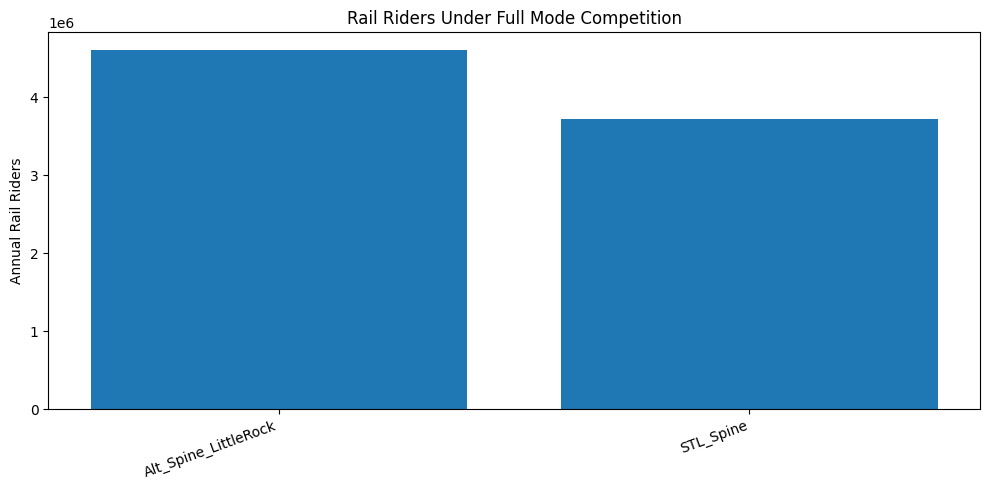

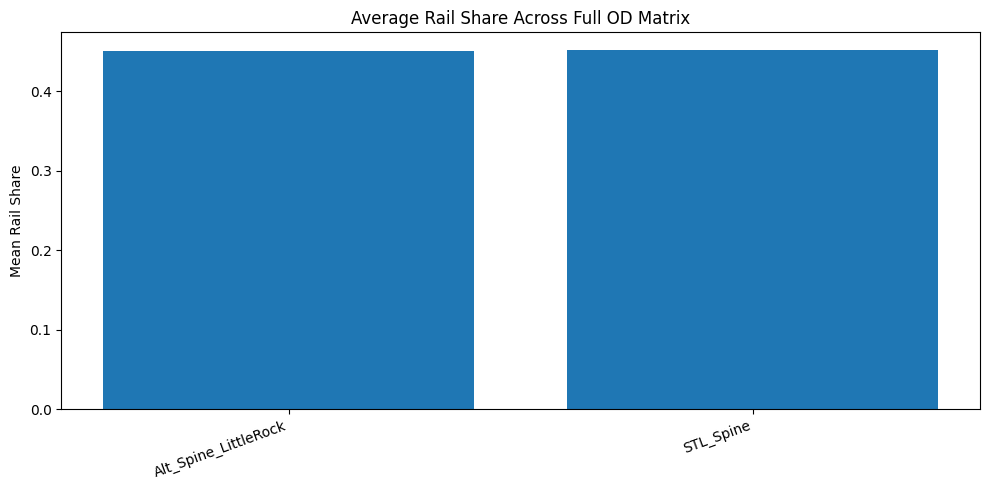

In [104]:
# ============================================================
# CLEAN CELL:
# FULL OD MATRIX MODE COMPETITION
# Rail vs Air vs Car with Hub / Non-Hub Air Logic
# STL Spine vs Alt Little Rock Spine
# ============================================================

import math
from dataclasses import dataclass
from itertools import combinations
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# DATA STRUCTURES
# -----------------------------
@dataclass
class City:
    name: str
    pop: float  # metro population in millions


@dataclass
class Segment:
    a: str
    b: str
    dist: float  # miles


# -----------------------------
# CITIES
# -----------------------------
CITIES: Dict[str, City] = {
    "Chicago": City("Chicago", 9.5),
    "Springfield IL": City("Springfield IL", 0.2),
    "St. Louis": City("St. Louis", 2.8),
    "Kansas City": City("Kansas City", 2.2),
    "Wichita": City("Wichita", 0.65),
    "Oklahoma City": City("Oklahoma City", 1.5),
    "Dallas": City("Dallas", 7.8),
    "Waco": City("Waco", 0.28),
    "Houston": City("Houston", 7.3),
    "Nashville": City("Nashville", 2.1),
    "Atlanta": City("Atlanta", 6.3),
    "Indianapolis": City("Indianapolis", 2.1),
    "Louisville": City("Louisville", 1.3),
    "Memphis": City("Memphis", 1.35),
    "Little Rock": City("Little Rock", 0.75),
}


# -----------------------------
# NETWORKS
# -----------------------------
STL_SPINE = [
    Segment("Chicago", "Springfield IL", 200),
    Segment("Springfield IL", "St. Louis", 100),
    Segment("St. Louis", "Kansas City", 250),
    Segment("Kansas City", "Wichita", 200),
    Segment("Wichita", "Oklahoma City", 160),
    Segment("Oklahoma City", "Dallas", 205),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("St. Louis", "Nashville", 300),
    Segment("Nashville", "Atlanta", 250),
]

ALT_SPINE_LITTLEROCK = [
    Segment("Chicago", "Indianapolis", 185),
    Segment("Indianapolis", "Louisville", 115),
    Segment("Louisville", "Nashville", 175),
    Segment("Nashville", "Atlanta", 250),
    Segment("Nashville", "Memphis", 210),
    Segment("Memphis", "Little Rock", 140),
    Segment("Little Rock", "Dallas", 320),
    Segment("Dallas", "Waco", 100),
    Segment("Waco", "Houston", 185),
    Segment("Dallas", "Oklahoma City", 205),
    Segment("Oklahoma City", "Wichita", 160),
    Segment("Wichita", "Kansas City", 200),
]

NETWORKS = {
    "STL_Spine": STL_SPINE,
    "Alt_Spine_LittleRock": ALT_SPINE_LITTLEROCK,
}


# -----------------------------
# PARAMETERS
# -----------------------------
PARAMS = {
    "speed_mph": 150.0,
    "wait_time": 0.25,
    "dwell": 0.08,
    "value_of_time": 25.0,
    "fare_per_mile": 0.25,
    "trips_factor": 8_000_000.0,
    "rail_share_min": 0.03,
    "rail_share_max": 0.72,
    "auto_speed": 68.0,
    "network_uplift": 1.08,
    "on_time_pct": 0.85,
}

BASE_SEGMENT_FREQUENCIES = {
    tuple(sorted(("Dallas", "Waco"))): 16,
    tuple(sorted(("Waco", "Houston"))): 16,
    tuple(sorted(("Dallas", "Oklahoma City"))): 10,
    tuple(sorted(("Oklahoma City", "Wichita"))): 6,
    tuple(sorted(("Wichita", "Kansas City"))): 6,

    tuple(sorted(("Chicago", "Springfield IL"))): 12,
    tuple(sorted(("Springfield IL", "St. Louis"))): 12,
    tuple(sorted(("St. Louis", "Kansas City"))): 10,
    tuple(sorted(("St. Louis", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Atlanta"))): 14,

    tuple(sorted(("Chicago", "Indianapolis"))): 14,
    tuple(sorted(("Indianapolis", "Louisville"))): 10,
    tuple(sorted(("Louisville", "Nashville"))): 10,
    tuple(sorted(("Nashville", "Memphis"))): 10,
    tuple(sorted(("Memphis", "Little Rock"))): 6,
    tuple(sorted(("Little Rock", "Dallas"))): 8,
}


# -----------------------------
# AIR NETWORK ASSUMPTIONS
# -----------------------------
HUB_CITIES = {"Chicago", "Dallas", "Atlanta", "Houston"}

AIR_ACCESS = 0.75
AIR_SECURITY = 0.75
AIR_EGRESS = 0.50
AIR_LAYOVER = 1.25
AIR_LAYOVER_PENALTY = 0.50
AIR_SPEED = 500.0

RAIL_ACCESS = 0.40
RAIL_EGRESS = 0.30

CAR_SPEED = 68.0

MODE_SCALE = 0.50  # lower = less hypersensitive than 0.8


# -----------------------------
# HELPERS
# -----------------------------
def segment_key(a: str, b: str) -> Tuple[str, str]:
    return tuple(sorted((a, b)))


def is_hub(city: str) -> bool:
    return city in HUB_CITIES


def build_graph(segments: List[Segment]) -> Dict[str, List[Tuple[str, float]]]:
    graph: Dict[str, List[Tuple[str, float]]] = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph


def find_path(graph: Dict[str, List[Tuple[str, float]]], start: str, end: str):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None


def path_frequency(path_nodes: List[str], seg_freqs: Dict[Tuple[str, str], int]) -> int:
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6


def frequency_multiplier(trains_per_day: int) -> float:
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22


def reliability_multiplier(on_time_pct: float) -> float:
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55


def car_time(distance: float) -> float:
    return distance / CAR_SPEED


def air_time(distance: float, origin: str, destination: str) -> Tuple[float, bool]:
    flight_time = distance / AIR_SPEED

    direct = is_hub(origin) and is_hub(destination)

    if direct:
        total = AIR_ACCESS + AIR_SECURITY + flight_time + AIR_EGRESS
        needs_layover = False
    else:
        total = (
            AIR_ACCESS
            + AIR_SECURITY
            + flight_time * 2
            + AIR_LAYOVER
            + AIR_EGRESS
            + AIR_LAYOVER_PENALTY
        )
        needs_layover = True

    return total, needs_layover


def rail_generalized_time(in_vehicle_time: float, wait_time: float, on_time_pct: float) -> float:
    reliability_penalty = 1.0
    if on_time_pct < 0.90:
        reliability_penalty = 1.0 + (0.90 - on_time_pct) * 0.5

    return in_vehicle_time * reliability_penalty + wait_time + RAIL_ACCESS + RAIL_EGRESS


def mode_share(rail_t: float, air_t: float, car_t: float, scale: float = MODE_SCALE):
    utilities = [
        -scale * rail_t,
        -scale * air_t,
        -scale * car_t,
    ]
    exps = [math.exp(u) for u in utilities]
    total = sum(exps)
    return {
        "rail": exps[0] / total,
        "air": exps[1] / total,
        "car": exps[2] / total,
    }


def demand(pop1: float, pop2: float, dist: float, p: dict) -> float:
    return p["trips_factor"] * (pop1 * pop2) / dist


# -----------------------------
# FULL OD MODE COMPETITION MODEL
# -----------------------------
def evaluate_mode_competition_network(
    segments: List[Segment],
    city_dict: Dict[str, City],
    p: dict,
    seg_freqs: Dict[Tuple[str, str], int],
):
    graph = build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = path_frequency(path, seg_freqs)
        freq_mult = frequency_multiplier(eff_trains_per_day)

        rail_ivt = dist / p["speed_mph"] + stops * p["dwell"]
        rail_t = rail_generalized_time(rail_ivt, p["wait_time"], p["on_time_pct"])
        air_t, needs_layover = air_time(dist, a, b)
        car_t = car_time(dist)

        shares = mode_share(rail_t, air_t, car_t, MODE_SCALE)

        base_trips = demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_riders = base_trips * shares["rail"] * freq_mult * rel_mult * p["network_uplift"]
        air_riders = base_trips * shares["air"]
        car_riders = base_trips * shares["car"]

        revenue_m = rail_riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = rail_riders * max(0.0, car_t - rail_t) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "path": " -> ".join(path),
            "effective_trains_per_day": eff_trains_per_day,
            "needs_air_layover": needs_layover,
            "rail_time_h": rail_t,
            "air_time_h": air_t,
            "car_time_h": car_t,
            "rail_share": shares["rail"],
            "air_share": shares["air"],
            "car_share": shares["car"],
            "annual_rail_riders": rail_riders,
            "annual_air_riders": air_riders,
            "annual_car_riders": car_riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_rail_riders", ascending=False)

    summary = {
        "annual_rail_riders": od_df["annual_rail_riders"].sum(),
        "annual_air_riders": od_df["annual_air_riders"].sum(),
        "annual_car_riders": od_df["annual_car_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "mean_rail_share": od_df["rail_share"].mean(),
        "mean_air_share": od_df["air_share"].mean(),
        "mean_car_share": od_df["car_share"].mean(),
        "layover_od_pairs": int(od_df["needs_air_layover"].sum()),
        "total_od_pairs": len(od_df),
    }

    return od_df, summary


# -----------------------------
# RUN BOTH NETWORKS
# -----------------------------
all_summaries = []
all_ods = {}

for name, segs in NETWORKS.items():
    od_df, summary = evaluate_mode_competition_network(
        segs,
        CITIES,
        PARAMS,
        BASE_SEGMENT_FREQUENCIES,
    )
    summary["scenario"] = name
    all_summaries.append(summary)
    all_ods[name] = od_df

summary_df = pd.DataFrame(all_summaries).sort_values("annual_rail_riders", ascending=False)

print("\n=== FULL OD MODE COMPETITION SUMMARY ===\n")
print(summary_df[[
    "scenario",
    "annual_rail_riders",
    "annual_air_riders",
    "annual_car_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "mean_rail_share",
    "mean_air_share",
    "mean_car_share",
    "layover_od_pairs",
    "total_od_pairs",
]])

for name, od_df in all_ods.items():
    print(f"\n=== {name} - TOP 20 RAIL OD FLOWS ===\n")
    print(od_df.head(20)[[
        "origin", "destination", "distance_miles",
        "needs_air_layover",
        "effective_trains_per_day",
        "rail_time_h", "air_time_h", "car_time_h",
        "rail_share", "air_share", "car_share",
        "annual_rail_riders", "annual_revenue_m"
    ]])

    print(f"\n=== {name} - MOST RAIL-COMPETITIVE NON-HUB OD PAIRS ===\n")
    nonhub_df = od_df[
        (~od_df["origin"].isin(HUB_CITIES)) &
        (~od_df["destination"].isin(HUB_CITIES))
    ].sort_values("rail_share", ascending=False)

    print(nonhub_df.head(15)[[
        "origin", "destination", "distance_miles",
        "needs_air_layover",
        "rail_time_h", "air_time_h", "car_time_h",
        "rail_share", "air_share", "car_share",
        "annual_rail_riders"
    ]])

    print(f"\n=== {name} - LAYOVER-DEPENDENT OD PAIRS WITH STRONG RAIL SHARE ===\n")
    layover_df = od_df[od_df["needs_air_layover"]].sort_values("rail_share", ascending=False)
    print(layover_df.head(15)[[
        "origin", "destination", "distance_miles",
        "rail_time_h", "air_time_h", "car_time_h",
        "rail_share", "air_share", "car_share",
        "annual_rail_riders"
    ]])


# -----------------------------
# PLOTS
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["annual_rail_riders"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Annual Rail Riders")
plt.title("Rail Riders Under Full Mode Competition")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(summary_df["scenario"], summary_df["mean_rail_share"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Mean Rail Share")
plt.title("Average Rail Share Across Full OD Matrix")
plt.tight_layout()
plt.show()

In [105]:
# =========================
# NEW RELIABILITY LOOP CELL v2
# If you still see "segments_df = segments_df.copy()" in an error,
# you are running the OLD cell, not this one.
# =========================

import pandas as pd
import numpy as np

print("Running NEW RELIABILITY LOOP CELL v2")

# -------------------------------------------------
# REQUIRED INPUT
# -------------------------------------------------
# Change OD_SOURCE below to whichever dataframe you already have:
# 1) all_ods["STL_Spine"]
# 2) all_ods["Alt_Spine_LittleRock"]
# 3) some other OD dataframe with columns:
#    origin, destination, path, annual_rail_riders
#
# Example:
# OD_SOURCE = all_ods["Alt_Spine_LittleRock"].copy()
# -------------------------------------------------

OD_SOURCE = all_ods["Alt_Spine_LittleRock"].copy()


# =========================
# STEP 1: BUILD OD DATA
# =========================

required_cols = {"origin", "destination", "path", "annual_rail_riders"}
missing = required_cols - set(OD_SOURCE.columns)
if missing:
    raise ValueError(f"OD_SOURCE is missing required columns: {missing}")

def extract_segments(path_str: str):
    nodes = path_str.split(" -> ")
    segs = []
    for i in range(len(nodes) - 1):
        a = nodes[i].strip()
        b = nodes[i + 1].strip()
        segs.append(" | ".join(sorted([a, b])))
    return segs

od_df = pd.DataFrame({
    "origin": OD_SOURCE["origin"],
    "destination": OD_SOURCE["destination"],
    "annual_riders": OD_SOURCE["annual_rail_riders"],
    "path_segments": OD_SOURCE["path"].apply(extract_segments),
})

# =========================
# STEP 2: BUILD SEGMENT TABLE FROM OD PATHS
# =========================

all_segments = set()
for seg_list in od_df["path_segments"]:
    all_segments.update(seg_list)

segments_df = pd.DataFrame({
    "segment": sorted(all_segments)
})

# Use a simple default capacity for now.
# You can later replace this with segment-specific capacities.
DEFAULT_CAPACITY = 2_044_000.0
segments_df["annual_segment_capacity"] = DEFAULT_CAPACITY


# =========================
# PARAMETERS
# =========================

BASE_RELIABILITY = 0.90
MIN_RELIABILITY = 0.70
MAX_RELIABILITY = 0.97

RELIABILITY_DEMAND_ELASTICITY = 0.60
CROWDING_PENALTY_FACTOR = 0.25

MAX_ITER = 20
CONVERGENCE_TOL = 1e-4


# =========================
# INITIAL STATE
# =========================

current_reliability = BASE_RELIABILITY
od_df["adjusted_riders"] = od_df["annual_riders"]

history = []


# =========================
# ITERATION LOOP
# =========================

for i in range(MAX_ITER):
    prev_reliability = current_reliability

    # Demand response to reliability
    multiplier = (current_reliability / BASE_RELIABILITY) ** RELIABILITY_DEMAND_ELASTICITY
    od_df["adjusted_riders"] = od_df["annual_riders"] * multiplier

    # Recompute segment loads
    segment_loads = {seg: 0.0 for seg in segments_df["segment"]}

    for _, row in od_df.iterrows():
        riders = float(row["adjusted_riders"])
        for seg in row["path_segments"]:
            segment_loads[seg] += riders

    segments_df["adjusted_load"] = segments_df["segment"].map(segment_loads).fillna(0.0)
    segments_df["utilization"] = segments_df["adjusted_load"] / segments_df["annual_segment_capacity"]

    # Reliability penalty from crowding
    avg_util = float(segments_df["utilization"].mean())
    penalty = CROWDING_PENALTY_FACTOR * avg_util

    new_reliability = BASE_RELIABILITY * (1.0 - penalty)
    new_reliability = max(MIN_RELIABILITY, min(MAX_RELIABILITY, new_reliability))

    history.append({
        "iteration": i,
        "reliability": new_reliability,
        "avg_utilization": avg_util,
        "total_riders": float(od_df["adjusted_riders"].sum()),
    })

    if abs(new_reliability - prev_reliability) < CONVERGENCE_TOL:
        print(f"Converged at iteration {i}")
        current_reliability = new_reliability
        break

    current_reliability = new_reliability

history_df = pd.DataFrame(history)

print("\n=== FINAL RESULTS ===")
print({
    "final_reliability": round(float(current_reliability), 4),
    "final_riders": round(float(od_df["adjusted_riders"].sum()), 3),
    "avg_utilization": round(float(segments_df["utilization"].mean()), 4),
    "max_utilization": round(float(segments_df["utilization"].max()), 4),
})

print("\n=== ITERATION HISTORY ===")
print(history_df)

print("\n=== TOP LOADED SEGMENTS ===")
display(segments_df.sort_values("utilization", ascending=False).head(15))

Running NEW RELIABILITY LOOP CELL v2
Converged at iteration 3

=== FINAL RESULTS ===
{'final_reliability': 0.8015, 'final_riders': 4293610.566, 'avg_utilization': 0.4378, 'max_utilization': 0.5687}

=== ITERATION HISTORY ===
   iteration  reliability  avg_utilization  total_riders
0          0        0.794            0.469 4,602,994.552
1          1        0.802            0.435 4,270,888.947
2          2        0.801            0.438 4,295,419.249
3          3        0.801            0.438 4,293,610.566

=== TOP LOADED SEGMENTS ===


,segment,annual_segment_capacity,adjusted_load,utilization
4,Dallas | Waco,"2,044,000.000","1,162,409.680",0.569
1,Chicago | Indianapolis,"2,044,000.000","1,155,253.521",0.565
6,Indianapolis | Louisville,"2,044,000.000","1,100,622.812",0.538
9,Louisville | Nashville,"2,044,000.000","1,099,863.456",0.538
5,Houston | Waco,"2,044,000.000","1,095,619.504",0.536
10,Memphis | Nashville,"2,044,000.000","958,741.823",0.469
2,Dallas | Little Rock,"2,044,000.000","899,243.598",0.440
8,Little Rock | Memphis,"2,044,000.000","891,994.679",0.436
0,Atlanta | Nashville,"2,044,000.000","807,644.746",0.395
3,Dallas | Oklahoma City,"2,044,000.000","803,456.782",0.393


In [106]:
# ============================================================
# NEW PEAK VS OFF-PEAK ANALYSIS CELL v2
# Self-contained: rebuilds segment frequencies and path segments
# ============================================================

import pandas as pd
import numpy as np

print("Running NEW PEAK vs OFF-PEAK ANALYSIS v2")

# -------------------------------------------------
# CHOOSE SCENARIO
# -------------------------------------------------
# Options:
#   "STL_Spine"
#   "Alt_Spine_LittleRock"
SCENARIO = "Alt_Spine_LittleRock"

# Requires:
#   all_ods[SCENARIO]
#   BASE_SEGMENT_FREQUENCIES
# to already exist from your earlier working cells

OD_SOURCE = all_ods[SCENARIO].copy()

# =========================
# ASSUMPTIONS
# =========================
PEAK_SHARE = 0.60
OFFPEAK_SHARE = 0.40

PEAK_CAPACITY_FACTOR = 1.00
OFFPEAK_CAPACITY_FACTOR = 0.70

PEAK_FREQUENCY_FACTOR = 1.20
OFFPEAK_FREQUENCY_FACTOR = 0.70

SEATS_PER_TRAIN = 400
DAYS_PER_YEAR = 365

# =========================
# HELPERS
# =========================
def canonical_seg(a: str, b: str) -> str:
    return " | ".join(sorted([a.strip(), b.strip()]))

def extract_segments(path_str: str):
    nodes = [x.strip() for x in path_str.split(" -> ")]
    return [canonical_seg(nodes[i], nodes[i+1]) for i in range(len(nodes)-1)]

def seg_capacity(trains_per_day: float, capacity_factor: float) -> float:
    # bidirectional annual seats
    return trains_per_day * SEATS_PER_TRAIN * capacity_factor * DAYS_PER_YEAR * 2

def reliability(util: float) -> float:
    if util < 0.60:
        return 0.90
    elif util < 0.80:
        return 0.85
    elif util < 1.00:
        return 0.78
    else:
        return 0.65

# =========================
# BUILD OD DATA
# =========================
required_cols = {"origin", "destination", "path", "annual_rail_riders"}
missing = required_cols - set(OD_SOURCE.columns)
if missing:
    raise ValueError(f"OD_SOURCE is missing required columns: {missing}")

od = pd.DataFrame({
    "origin": OD_SOURCE["origin"],
    "destination": OD_SOURCE["destination"],
    "annual_riders": OD_SOURCE["annual_rail_riders"],
    "path_segments": OD_SOURCE["path"].apply(extract_segments),
})

od["peak_riders"] = od["annual_riders"] * PEAK_SHARE
od["offpeak_riders"] = od["annual_riders"] * OFFPEAK_SHARE

# =========================
# BUILD SEGMENT TABLE
# =========================
all_segments = set()
for seg_list in od["path_segments"]:
    all_segments.update(seg_list)

segments = pd.DataFrame({"segment": sorted(all_segments)})

# Build trains_per_day from BASE_SEGMENT_FREQUENCIES
# BASE_SEGMENT_FREQUENCIES keys are tuples like ('Dallas','Waco')
freq_lookup = {
    canonical_seg(a, b): v
    for (a, b), v in BASE_SEGMENT_FREQUENCIES.items()
}

segments["trains_per_day"] = segments["segment"].map(freq_lookup)

# Safety fallback in case any segment is missing from the frequency map
segments["trains_per_day"] = segments["trains_per_day"].fillna(6)

# =========================
# ASSIGN LOADS TO SEGMENTS
# =========================
segment_loads_peak = {seg: 0.0 for seg in segments["segment"]}
segment_loads_offpeak = {seg: 0.0 for seg in segments["segment"]}

for _, row in od.iterrows():
    for seg in row["path_segments"]:
        segment_loads_peak[seg] += float(row["peak_riders"])
        segment_loads_offpeak[seg] += float(row["offpeak_riders"])

segments["peak_load"] = segments["segment"].map(segment_loads_peak).fillna(0.0)
segments["offpeak_load"] = segments["segment"].map(segment_loads_offpeak).fillna(0.0)

# =========================
# PEAK / OFFPEAK SERVICE
# =========================
segments["peak_trains"] = segments["trains_per_day"] * PEAK_FREQUENCY_FACTOR
segments["offpeak_trains"] = segments["trains_per_day"] * OFFPEAK_FREQUENCY_FACTOR

segments["peak_capacity"] = segments["peak_trains"].apply(
    lambda x: seg_capacity(x, PEAK_CAPACITY_FACTOR)
)
segments["offpeak_capacity"] = segments["offpeak_trains"].apply(
    lambda x: seg_capacity(x, OFFPEAK_CAPACITY_FACTOR)
)

# =========================
# UTILIZATION + RELIABILITY
# =========================
segments["peak_util"] = segments["peak_load"] / segments["peak_capacity"]
segments["offpeak_util"] = segments["offpeak_load"] / segments["offpeak_capacity"]

segments["peak_over_capacity"] = segments["peak_util"] > 1.0
segments["offpeak_over_capacity"] = segments["offpeak_util"] > 1.0

segments["peak_reliability"] = segments["peak_util"].apply(reliability)
segments["offpeak_reliability"] = segments["offpeak_util"].apply(reliability)

# =========================
# SUMMARY
# =========================
summary = pd.DataFrame({
    "metric": [
        "Peak Avg Util",
        "Peak Max Util",
        "Peak Over Cap",
        "Peak Avg Reliability",
        "Offpeak Avg Util",
        "Offpeak Max Util",
        "Offpeak Over Cap",
        "Offpeak Avg Reliability",
    ],
    "value": [
        segments["peak_util"].mean(),
        segments["peak_util"].max(),
        segments["peak_over_capacity"].sum(),
        segments["peak_reliability"].mean(),
        segments["offpeak_util"].mean(),
        segments["offpeak_util"].max(),
        segments["offpeak_over_capacity"].sum(),
        segments["offpeak_reliability"].mean(),
    ]
})

print(f"\n=== {SCENARIO} - PEAK VS OFF-PEAK SUMMARY ===\n")
print(summary)

print(f"\n=== {SCENARIO} - TOP PEAK BOTTLENECK RISK SEGMENTS ===\n")
print(
    segments.sort_values("peak_util", ascending=False)[[
        "segment",
        "trains_per_day",
        "peak_trains",
        "peak_load",
        "peak_capacity",
        "peak_util",
        "peak_reliability",
        "peak_over_capacity",
    ]].head(15)
)

print(f"\n=== {SCENARIO} - TOP OFF-PEAK SEGMENTS ===\n")
print(
    segments.sort_values("offpeak_util", ascending=False)[[
        "segment",
        "trains_per_day",
        "offpeak_trains",
        "offpeak_load",
        "offpeak_capacity",
        "offpeak_util",
        "offpeak_reliability",
        "offpeak_over_capacity",
    ]].head(15)
)

Running NEW PEAK vs OFF-PEAK ANALYSIS v2

=== Alt_Spine_LittleRock - PEAK VS OFF-PEAK SUMMARY ===

                    metric  value
0            Peak Avg Util  0.163
1            Peak Max Util  0.273
2            Peak Over Cap  0.000
3     Peak Avg Reliability  0.900
4         Offpeak Avg Util  0.266
5         Offpeak Max Util  0.446
6         Offpeak Over Cap  0.000
7  Offpeak Avg Reliability  0.900

=== Alt_Spine_LittleRock - TOP PEAK BOTTLENECK RISK SEGMENTS ===

                      segment  trains_per_day  peak_trains   peak_load  peak_capacity  peak_util  peak_reliability  peak_over_capacity
8       Little Rock | Memphis               6        7.200 573,761.395  2,102,400.000      0.273             0.900               False
2        Dallas | Little Rock               8        9.600 578,424.147  2,803,200.000      0.206             0.900               False
6   Indianapolis | Louisville              10       12.000 707,958.124  3,504,000.000      0.202             0.900         

In [107]:
# ============================================================
# NEW PEAK VS OFF-PEAK ANALYSIS CELL v2
# Self-contained: rebuilds segment frequencies and path segments
# ============================================================

import pandas as pd
import numpy as np

print("Running NEW PEAK vs OFF-PEAK ANALYSIS v2")

# -------------------------------------------------
# CHOOSE SCENARIO
# -------------------------------------------------
# Options:
#   "STL_Spine"
#   "Alt_Spine_LittleRock"
SCENARIO = "STL_Spine"

# Requires:
#   all_ods[SCENARIO]
#   BASE_SEGMENT_FREQUENCIES
# to already exist from your earlier working cells

OD_SOURCE = all_ods[SCENARIO].copy()

# =========================
# ASSUMPTIONS
# =========================
PEAK_SHARE = 0.60
OFFPEAK_SHARE = 0.40

PEAK_CAPACITY_FACTOR = 1.00
OFFPEAK_CAPACITY_FACTOR = 0.70

PEAK_FREQUENCY_FACTOR = 1.20
OFFPEAK_FREQUENCY_FACTOR = 0.70

SEATS_PER_TRAIN = 400
DAYS_PER_YEAR = 365

# =========================
# HELPERS
# =========================
def canonical_seg(a: str, b: str) -> str:
    return " | ".join(sorted([a.strip(), b.strip()]))

def extract_segments(path_str: str):
    nodes = [x.strip() for x in path_str.split(" -> ")]
    return [canonical_seg(nodes[i], nodes[i+1]) for i in range(len(nodes)-1)]

def seg_capacity(trains_per_day: float, capacity_factor: float) -> float:
    # bidirectional annual seats
    return trains_per_day * SEATS_PER_TRAIN * capacity_factor * DAYS_PER_YEAR * 2

def reliability(util: float) -> float:
    if util < 0.60:
        return 0.90
    elif util < 0.80:
        return 0.85
    elif util < 1.00:
        return 0.78
    else:
        return 0.65

# =========================
# BUILD OD DATA
# =========================
required_cols = {"origin", "destination", "path", "annual_rail_riders"}
missing = required_cols - set(OD_SOURCE.columns)
if missing:
    raise ValueError(f"OD_SOURCE is missing required columns: {missing}")

od = pd.DataFrame({
    "origin": OD_SOURCE["origin"],
    "destination": OD_SOURCE["destination"],
    "annual_riders": OD_SOURCE["annual_rail_riders"],
    "path_segments": OD_SOURCE["path"].apply(extract_segments),
})

od["peak_riders"] = od["annual_riders"] * PEAK_SHARE
od["offpeak_riders"] = od["annual_riders"] * OFFPEAK_SHARE

# =========================
# BUILD SEGMENT TABLE
# =========================
all_segments = set()
for seg_list in od["path_segments"]:
    all_segments.update(seg_list)

segments = pd.DataFrame({"segment": sorted(all_segments)})

# Build trains_per_day from BASE_SEGMENT_FREQUENCIES
# BASE_SEGMENT_FREQUENCIES keys are tuples like ('Dallas','Waco')
freq_lookup = {
    canonical_seg(a, b): v
    for (a, b), v in BASE_SEGMENT_FREQUENCIES.items()
}

segments["trains_per_day"] = segments["segment"].map(freq_lookup)

# Safety fallback in case any segment is missing from the frequency map
segments["trains_per_day"] = segments["trains_per_day"].fillna(6)

# =========================
# ASSIGN LOADS TO SEGMENTS
# =========================
segment_loads_peak = {seg: 0.0 for seg in segments["segment"]}
segment_loads_offpeak = {seg: 0.0 for seg in segments["segment"]}

for _, row in od.iterrows():
    for seg in row["path_segments"]:
        segment_loads_peak[seg] += float(row["peak_riders"])
        segment_loads_offpeak[seg] += float(row["offpeak_riders"])

segments["peak_load"] = segments["segment"].map(segment_loads_peak).fillna(0.0)
segments["offpeak_load"] = segments["segment"].map(segment_loads_offpeak).fillna(0.0)

# =========================
# PEAK / OFFPEAK SERVICE
# =========================
segments["peak_trains"] = segments["trains_per_day"] * PEAK_FREQUENCY_FACTOR
segments["offpeak_trains"] = segments["trains_per_day"] * OFFPEAK_FREQUENCY_FACTOR

segments["peak_capacity"] = segments["peak_trains"].apply(
    lambda x: seg_capacity(x, PEAK_CAPACITY_FACTOR)
)
segments["offpeak_capacity"] = segments["offpeak_trains"].apply(
    lambda x: seg_capacity(x, OFFPEAK_CAPACITY_FACTOR)
)

# =========================
# UTILIZATION + RELIABILITY
# =========================
segments["peak_util"] = segments["peak_load"] / segments["peak_capacity"]
segments["offpeak_util"] = segments["offpeak_load"] / segments["offpeak_capacity"]

segments["peak_over_capacity"] = segments["peak_util"] > 1.0
segments["offpeak_over_capacity"] = segments["offpeak_util"] > 1.0

segments["peak_reliability"] = segments["peak_util"].apply(reliability)
segments["offpeak_reliability"] = segments["offpeak_util"].apply(reliability)

# =========================
# SUMMARY
# =========================
summary = pd.DataFrame({
    "metric": [
        "Peak Avg Util",
        "Peak Max Util",
        "Peak Over Cap",
        "Peak Avg Reliability",
        "Offpeak Avg Util",
        "Offpeak Max Util",
        "Offpeak Over Cap",
        "Offpeak Avg Reliability",
    ],
    "value": [
        segments["peak_util"].mean(),
        segments["peak_util"].max(),
        segments["peak_over_capacity"].sum(),
        segments["peak_reliability"].mean(),
        segments["offpeak_util"].mean(),
        segments["offpeak_util"].max(),
        segments["offpeak_over_capacity"].sum(),
        segments["offpeak_reliability"].mean(),
    ]
})

print(f"\n=== {SCENARIO} - PEAK VS OFF-PEAK SUMMARY ===\n")
print(summary)

print(f"\n=== {SCENARIO} - TOP PEAK BOTTLENECK RISK SEGMENTS ===\n")
print(
    segments.sort_values("peak_util", ascending=False)[[
        "segment",
        "trains_per_day",
        "peak_trains",
        "peak_load",
        "peak_capacity",
        "peak_util",
        "peak_reliability",
        "peak_over_capacity",
    ]].head(15)
)

print(f"\n=== {SCENARIO} - TOP OFF-PEAK SEGMENTS ===\n")
print(
    segments.sort_values("offpeak_util", ascending=False)[[
        "segment",
        "trains_per_day",
        "offpeak_trains",
        "offpeak_load",
        "offpeak_capacity",
        "offpeak_util",
        "offpeak_reliability",
        "offpeak_over_capacity",
    ]].head(15)
)

Running NEW PEAK vs OFF-PEAK ANALYSIS v2

=== STL_Spine - PEAK VS OFF-PEAK SUMMARY ===

                    metric  value
0            Peak Avg Util  0.154
1            Peak Max Util  0.234
2            Peak Over Cap  0.000
3     Peak Avg Reliability  0.900
4         Offpeak Avg Util  0.251
5         Offpeak Max Util  0.383
6         Offpeak Over Cap  0.000
7  Offpeak Avg Reliability  0.900

=== STL_Spine - TOP PEAK BOTTLENECK RISK SEGMENTS ===

                      segment  trains_per_day  peak_trains   peak_load  peak_capacity  peak_util  peak_reliability  peak_over_capacity
8     Oklahoma City | Wichita               6        7.200 492,706.528  2,102,400.000      0.234             0.900               False
6       Kansas City | Wichita               6        7.200 485,653.696  2,102,400.000      0.231             0.900               False
2      Dallas | Oklahoma City              10       12.000 590,851.275  3,504,000.000      0.169             0.900               False
5     Kans

In [108]:
# ============================================================
# HYBRID PHASE MODEL: PHASE 1 vs PHASE 2
# ============================================================

import pandas as pd
import numpy as np

print("Running HYBRID PHASE ANALYSIS")

SCENARIO = "Alt_Spine_LittleRock"

od = all_ods[SCENARIO].copy()

# =========================
# BASELINE FREQUENCIES
# =========================
base_freq = {
    "Dallas | Waco": 16,
    "Houston | Waco": 16,
    "Chicago | Indianapolis": 14,
    "Atlanta | Nashville": 14,
    "Dallas | Oklahoma City": 10,
    "Indianapolis | Louisville": 10,
    "Louisville | Nashville": 10,
    "Memphis | Nashville": 10,
    "Dallas | Little Rock": 8,
    "Little Rock | Memphis": 6,
    "Kansas City | Wichita": 6,
    "Oklahoma City | Wichita": 6,
}

# =========================
# PHASE 1 (LEAN BUILD)
# =========================
phase1_freq = {k: max(4, int(v * 0.6)) for k, v in base_freq.items()}

# =========================
# PHASE 2 (OPTIMIZED)
# =========================
phase2_freq = base_freq.copy()

# Add targeted upgrades from optimization
phase2_freq.update({
    "Chicago | Indianapolis": 16,
    "Dallas | Oklahoma City": 12,
    "Atlanta | Nashville": 16,
    "Memphis | Nashville": 12,
})

SEATS = 400
DAYS = 365

def capacity(freq):
    return freq * SEATS * DAYS * 2

# =========================
# DEMAND RESPONSE FUNCTION
# =========================
def demand_multiplier(freq):
    # diminishing returns curve
    return 1 + 0.04 * (freq - 6)

# =========================
# RUN PHASE MODEL
# =========================
results = []

for phase_name, freq_map in [("Phase 1", phase1_freq), ("Phase 2", phase2_freq)]:

    total_riders = 0

    for _, row in od.iterrows():
        path = row["path"].split(" -> ")

        # find minimum frequency along path
        freqs = []
        for i in range(len(path)-1):
            seg = " | ".join(sorted([path[i], path[i+1]]))
            freqs.append(freq_map.get(seg, 6))

        bottleneck_freq = min(freqs)

        # apply demand multiplier
        multiplier = demand_multiplier(bottleneck_freq)

        total_riders += row["annual_rail_riders"] * multiplier

    results.append({
        "phase": phase_name,
        "annual_riders": total_riders,
        "avg_frequency": np.mean(list(freq_map.values())),
    })

df = pd.DataFrame(results)

df["delta_riders"] = df["annual_riders"].diff()

print("\n=== PHASE COMPARISON ===\n")
print(df)

Running HYBRID PHASE ANALYSIS

=== PHASE COMPARISON ===

     phase  annual_riders  avg_frequency  delta_riders
0  Phase 1  4,640,420.213          6.167           NaN
1  Phase 2  5,522,863.080         11.167   882,442.867


In [109]:
# ============================================================
# NEW SUBSIDY SENSITIVITY ANALYSIS v2
# Self-contained and safe
# ============================================================

import pandas as pd
import numpy as np
import copy

print("Running NEW SUBSIDY SENSITIVITY ANALYSIS v2")

# -------------------------------------------------
# REQUIRED INPUTS
# -------------------------------------------------
# These should already exist from earlier cells:
#   evaluate_network_variable_freq
#   STL_SPINE
#   ALT_SPINE_LITTLEROCK
#   CITIES
#   PARAMS
# -------------------------------------------------

# -----------------------------
# SAFE PARAMETER BASE
# -----------------------------
BASE_FARE_PER_MILE = PARAMS.get("fare_per_mile", 0.25)
BASE_TRIPS_FACTOR = PARAMS.get("trips_factor", 8_000_000.0)
BASE_OM_PER_MILE = PARAMS.get("om_per_mile", 0.10)  # fallback if missing

# -----------------------------
# SCENARIOS
# -----------------------------
SCENARIOS = {
    "STL_Phase1": {
        "segments": STL_SPINE,
        "freqs": {
            tuple(sorted(("Dallas","Waco"))): 10,
            tuple(sorted(("Waco","Houston"))): 10,
            tuple(sorted(("Dallas","Oklahoma City"))): 6,
            tuple(sorted(("Oklahoma City","Wichita"))): 4,
            tuple(sorted(("Wichita","Kansas City"))): 4,
            tuple(sorted(("Chicago","Springfield IL"))): 8,
            tuple(sorted(("Springfield IL","St. Louis"))): 8,
            tuple(sorted(("St. Louis","Kansas City"))): 6,
            tuple(sorted(("St. Louis","Nashville"))): 6,
            tuple(sorted(("Nashville","Atlanta"))): 8,
        },
    },
    "STL_Phase2": {
        "segments": STL_SPINE,
        "freqs": {
            tuple(sorted(("Dallas","Waco"))): 16,
            tuple(sorted(("Waco","Houston"))): 16,
            tuple(sorted(("Dallas","Oklahoma City"))): 10,
            tuple(sorted(("Oklahoma City","Wichita"))): 6,
            tuple(sorted(("Wichita","Kansas City"))): 6,
            tuple(sorted(("Chicago","Springfield IL"))): 12,
            tuple(sorted(("Springfield IL","St. Louis"))): 12,
            tuple(sorted(("St. Louis","Kansas City"))): 10,
            tuple(sorted(("St. Louis","Nashville"))): 10,
            tuple(sorted(("Nashville","Atlanta"))): 14,
        },
    },
    "ALT_Phase1": {
        "segments": ALT_SPINE_LITTLEROCK,
        "freqs": {
            tuple(sorted(("Dallas","Waco"))): 10,
            tuple(sorted(("Waco","Houston"))): 10,
            tuple(sorted(("Dallas","Oklahoma City"))): 6,
            tuple(sorted(("Oklahoma City","Wichita"))): 4,
            tuple(sorted(("Wichita","Kansas City"))): 4,
            tuple(sorted(("Chicago","Indianapolis"))): 8,
            tuple(sorted(("Indianapolis","Louisville"))): 6,
            tuple(sorted(("Louisville","Nashville"))): 6,
            tuple(sorted(("Nashville","Atlanta"))): 8,
            tuple(sorted(("Nashville","Memphis"))): 6,
            tuple(sorted(("Memphis","Little Rock"))): 4,
            tuple(sorted(("Little Rock","Dallas"))): 4,
        },
    },
    "ALT_Phase2": {
        "segments": ALT_SPINE_LITTLEROCK,
        "freqs": {
            tuple(sorted(("Dallas","Waco"))): 16,
            tuple(sorted(("Waco","Houston"))): 16,
            tuple(sorted(("Dallas","Oklahoma City"))): 10,
            tuple(sorted(("Oklahoma City","Wichita"))): 6,
            tuple(sorted(("Wichita","Kansas City"))): 6,
            tuple(sorted(("Chicago","Indianapolis"))): 14,
            tuple(sorted(("Indianapolis","Louisville"))): 10,
            tuple(sorted(("Louisville","Nashville"))): 10,
            tuple(sorted(("Nashville","Atlanta"))): 14,
            tuple(sorted(("Nashville","Memphis"))): 10,
            tuple(sorted(("Memphis","Little Rock"))): 6,
            tuple(sorted(("Little Rock","Dallas"))): 8,
        },
    },
}

# -----------------------------
# SENSITIVITY RANGES
# -----------------------------
FARE_MULTIPLIERS = [0.80, 0.90, 1.00, 1.10]
OM_MULTIPLIERS = [0.90, 1.00, 1.15, 1.30]
DEMAND_MULTIPLIERS = [0.85, 1.00, 1.15]

rows = []

for scenario_name, cfg in SCENARIOS.items():
    for fare_mult in FARE_MULTIPLIERS:
        for om_mult in OM_MULTIPLIERS:
            for demand_mult in DEMAND_MULTIPLIERS:
                p = copy.deepcopy(PARAMS)

                p["fare_per_mile"] = BASE_FARE_PER_MILE * fare_mult
                p["trips_factor"] = BASE_TRIPS_FACTOR * demand_mult
                p["om_per_mile"] = BASE_OM_PER_MILE * om_mult

                od_df, summary = evaluate_network_variable_freq(
                    cfg["segments"], CITIES, p, cfg["freqs"]
                )

                annual_revenue = summary["annual_revenue_m"]
                annual_om = summary["annual_om_m"]
                annual_riders = summary["annual_riders"]

                operating_balance = annual_revenue - annual_om
                required_subsidy = max(0.0, annual_om - annual_revenue)
                subsidy_per_rider = (
                    required_subsidy * 1_000_000 / annual_riders
                    if annual_riders > 0 else np.nan
                )

                rows.append({
                    "scenario": scenario_name,
                    "fare_mult": fare_mult,
                    "om_mult": om_mult,
                    "demand_mult": demand_mult,
                    "annual_riders": annual_riders,
                    "annual_revenue_m": annual_revenue,
                    "annual_om_m": annual_om,
                    "farebox_recovery": summary["farebox_recovery"],
                    "bcr_like": summary["bcr_like"],
                    "operating_balance_m": operating_balance,
                    "required_subsidy_m": required_subsidy,
                    "subsidy_per_rider": subsidy_per_rider,
                })

subsidy_df = pd.DataFrame(rows)

# -----------------------------
# SUMMARY TABLE
# -----------------------------
summary_table = subsidy_df.groupby("scenario").agg(
    avg_riders=("annual_riders", "mean"),
    avg_revenue_m=("annual_revenue_m", "mean"),
    avg_om_m=("annual_om_m", "mean"),
    avg_farebox=("farebox_recovery", "mean"),
    avg_required_subsidy_m=("required_subsidy_m", "mean"),
    avg_subsidy_per_rider=("subsidy_per_rider", "mean"),
    worst_required_subsidy_m=("required_subsidy_m", "max"),
    worst_subsidy_per_rider=("subsidy_per_rider", "max"),
    best_operating_balance_m=("operating_balance_m", "max"),
    worst_operating_balance_m=("operating_balance_m", "min"),
).reset_index()

print("\n=== SUBSIDY SENSITIVITY SUMMARY ===\n")
print(summary_table)

# -----------------------------
# BEST / WORST CASES
# -----------------------------
best_cases = (
    subsidy_df.sort_values(["scenario", "operating_balance_m"], ascending=[True, False])
    .groupby("scenario")
    .head(3)
)

worst_cases = (
    subsidy_df.sort_values(["scenario", "required_subsidy_m"], ascending=[True, False])
    .groupby("scenario")
    .head(3)
)

print("\n=== BEST CASES (LOWEST SUBSIDY / HIGHEST BALANCE) ===\n")
print(best_cases[[
    "scenario", "fare_mult", "om_mult", "demand_mult",
    "annual_riders", "farebox_recovery", "operating_balance_m",
    "required_subsidy_m", "subsidy_per_rider"
]])

print("\n=== WORST CASES (HIGHEST SUBSIDY NEED) ===\n")
print(worst_cases[[
    "scenario", "fare_mult", "om_mult", "demand_mult",
    "annual_riders", "farebox_recovery", "operating_balance_m",
    "required_subsidy_m", "subsidy_per_rider"
]])

# -----------------------------
# POLICY THRESHOLDS
# -----------------------------
def hit_rate(df, scenario, condition):
    sub = df[df["scenario"] == scenario]
    return condition(sub).mean()

thresholds = pd.DataFrame({
    "threshold": [
        "Needs no operating subsidy",
        "Subsidy under $5/rider",
        "Subsidy under $10/rider",
        "Farebox >= 1.0",
    ],
    "ALT_Phase1": [
        hit_rate(subsidy_df, "ALT_Phase1", lambda x: x["required_subsidy_m"] == 0),
        hit_rate(subsidy_df, "ALT_Phase1", lambda x: x["subsidy_per_rider"] < 5),
        hit_rate(subsidy_df, "ALT_Phase1", lambda x: x["subsidy_per_rider"] < 10),
        hit_rate(subsidy_df, "ALT_Phase1", lambda x: x["farebox_recovery"] >= 1.0),
    ],
    "ALT_Phase2": [
        hit_rate(subsidy_df, "ALT_Phase2", lambda x: x["required_subsidy_m"] == 0),
        hit_rate(subsidy_df, "ALT_Phase2", lambda x: x["subsidy_per_rider"] < 5),
        hit_rate(subsidy_df, "ALT_Phase2", lambda x: x["subsidy_per_rider"] < 10),
        hit_rate(subsidy_df, "ALT_Phase2", lambda x: x["farebox_recovery"] >= 1.0),
    ],
    "STL_Phase1": [
        hit_rate(subsidy_df, "STL_Phase1", lambda x: x["required_subsidy_m"] == 0),
        hit_rate(subsidy_df, "STL_Phase1", lambda x: x["subsidy_per_rider"] < 5),
        hit_rate(subsidy_df, "STL_Phase1", lambda x: x["subsidy_per_rider"] < 10),
        hit_rate(subsidy_df, "STL_Phase1", lambda x: x["farebox_recovery"] >= 1.0),
    ],
    "STL_Phase2": [
        hit_rate(subsidy_df, "STL_Phase2", lambda x: x["required_subsidy_m"] == 0),
        hit_rate(subsidy_df, "STL_Phase2", lambda x: x["subsidy_per_rider"] < 5),
        hit_rate(subsidy_df, "STL_Phase2", lambda x: x["subsidy_per_rider"] < 10),
        hit_rate(subsidy_df, "STL_Phase2", lambda x: x["farebox_recovery"] >= 1.0),
    ],
})

print("\n=== POLICY THRESHOLD HIT RATES ===\n")
print(thresholds)

# -----------------------------
# SIMPLE RANKING
# -----------------------------
ranking = summary_table.copy()
ranking["rank_score"] = (
    ranking["avg_required_subsidy_m"].rank(ascending=True)
    + ranking["avg_subsidy_per_rider"].rank(ascending=True)
    + ranking["avg_farebox"].rank(ascending=False)
)
ranking = ranking.sort_values("rank_score")

print("\n=== SUBSIDY SENSITIVITY RANKING ===\n")
print(ranking[[
    "scenario",
    "avg_farebox",
    "avg_required_subsidy_m",
    "avg_subsidy_per_rider",
    "worst_required_subsidy_m",
    "worst_subsidy_per_rider",
    "rank_score"
]])

Running NEW SUBSIDY SENSITIVITY ANALYSIS v2

=== SUBSIDY SENSITIVITY SUMMARY ===

     scenario    avg_riders  avg_revenue_m  avg_om_m  avg_farebox  avg_required_subsidy_m  avg_subsidy_per_rider  worst_required_subsidy_m  worst_subsidy_per_rider  \
0  ALT_Phase1 4,205,030.640        312.507   244.144        1.305                   2.202                  0.636                    34.500                   10.844   
1  ALT_Phase2 4,815,508.025        360.602   244.144        1.506                   0.000                  0.000                     0.000                    0.000   
2  STL_Phase1 3,402,276.403        264.957   212.062        1.274                   2.506                  0.890                    34.009                   13.176   
3  STL_Phase2 3,828,470.410        301.000   212.062        1.447                   0.144                  0.049                     4.956                    1.710   

   best_operating_balance_m  worst_operating_balance_m  
0                   173.0

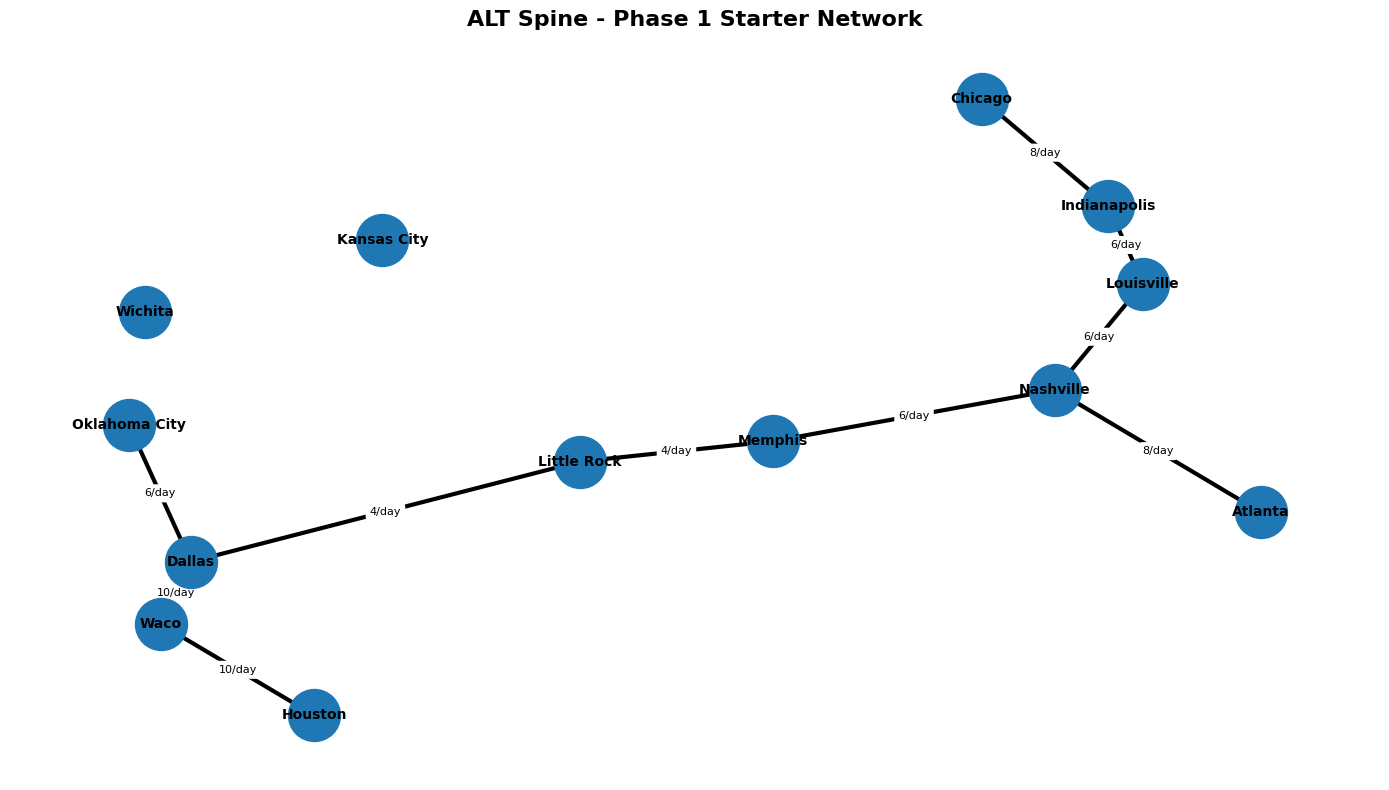

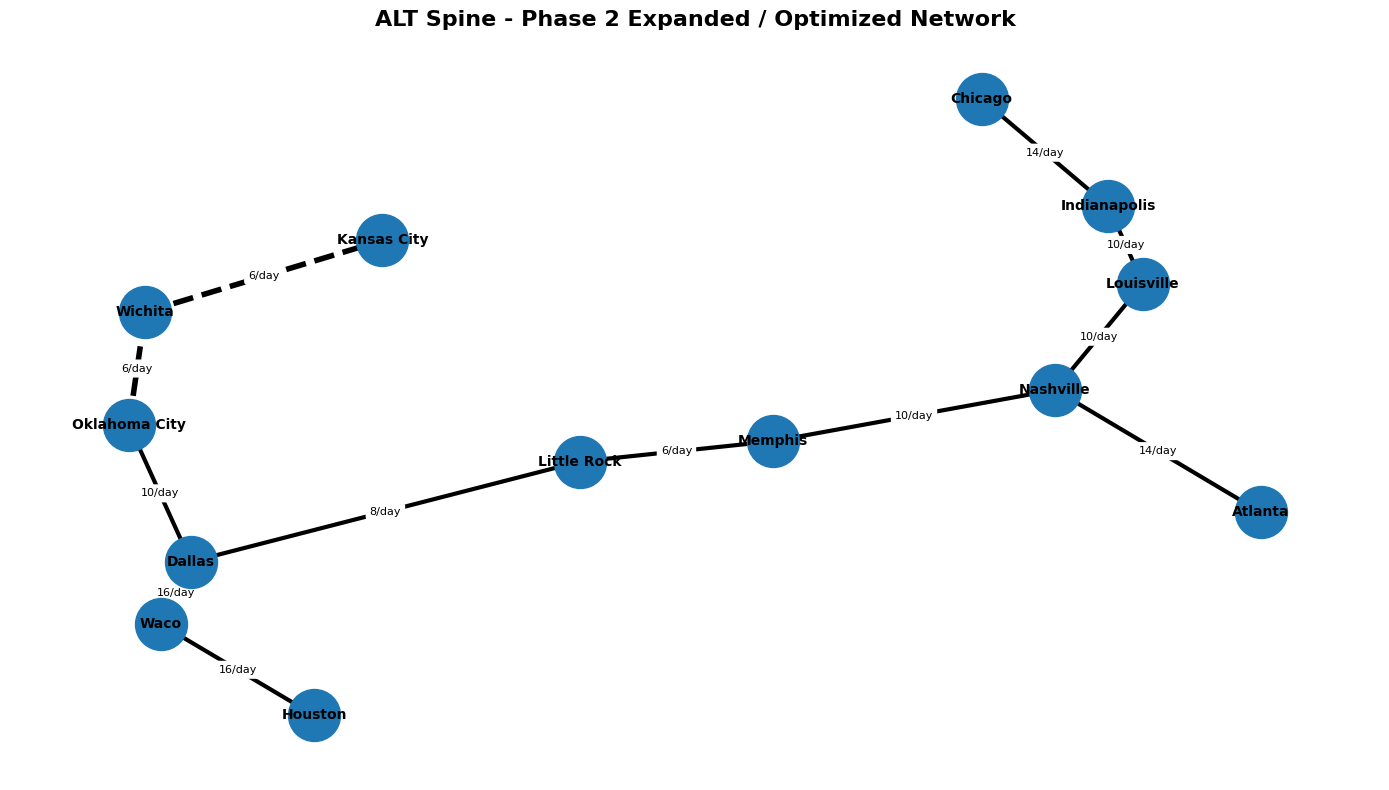

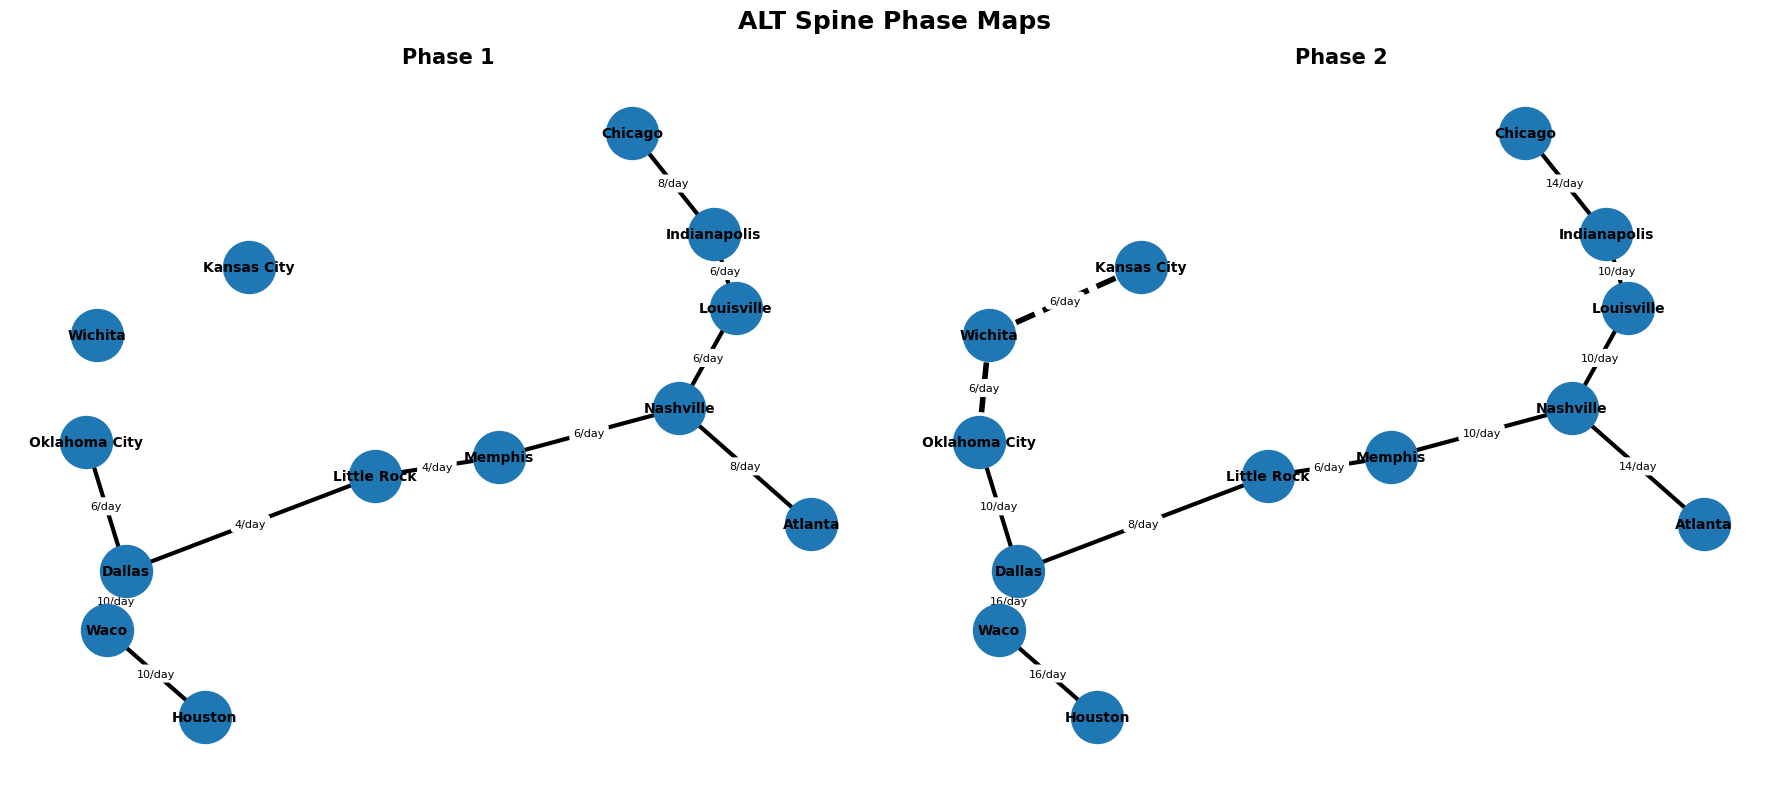

In [110]:
# ============================================================
# PHASE MAPS (ALT SPINE): PYTHON VISUALIZATION
# Creates Phase 1 and Phase 2 network maps with labels
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

# ------------------------------------------------------------
# NODE POSITIONS
# Approximate lon/lat-style plotting coordinates
# x = longitude-ish, y = latitude-ish
# ------------------------------------------------------------
node_pos = {
    "Chicago": (-87.63, 41.88),
    "Indianapolis": (-86.16, 39.77),
    "Louisville": (-85.76, 38.25),
    "Nashville": (-86.78, 36.16),
    "Atlanta": (-84.39, 33.75),
    "Memphis": (-90.05, 35.15),
    "Little Rock": (-92.29, 34.75),
    "Dallas": (-96.80, 32.78),
    "Waco": (-97.15, 31.55),
    "Houston": (-95.37, 29.76),
    "Oklahoma City": (-97.52, 35.47),
    "Wichita": (-97.33, 37.69),
    "Kansas City": (-94.58, 39.10),
}

# ------------------------------------------------------------
# PHASE DEFINITIONS
# ------------------------------------------------------------
phase1_edges = [
    ("Chicago", "Indianapolis"),
    ("Indianapolis", "Louisville"),
    ("Louisville", "Nashville"),
    ("Nashville", "Atlanta"),
    ("Nashville", "Memphis"),
    ("Memphis", "Little Rock"),
    ("Little Rock", "Dallas"),
    ("Dallas", "Waco"),
    ("Waco", "Houston"),
    ("Dallas", "Oklahoma City"),
]

phase2_added_edges = [
    ("Oklahoma City", "Wichita"),
    ("Wichita", "Kansas City"),
]

phase2_edges = phase1_edges + phase2_added_edges

# ------------------------------------------------------------
# OPTIONAL SERVICE FREQUENCIES
# Edit these as needed
# ------------------------------------------------------------
phase1_freq = {
    ("Chicago", "Indianapolis"): 8,
    ("Indianapolis", "Louisville"): 6,
    ("Louisville", "Nashville"): 6,
    ("Nashville", "Atlanta"): 8,
    ("Nashville", "Memphis"): 6,
    ("Memphis", "Little Rock"): 4,
    ("Little Rock", "Dallas"): 4,
    ("Dallas", "Waco"): 10,
    ("Waco", "Houston"): 10,
    ("Dallas", "Oklahoma City"): 6,
}

phase2_freq = {
    ("Chicago", "Indianapolis"): 14,
    ("Indianapolis", "Louisville"): 10,
    ("Louisville", "Nashville"): 10,
    ("Nashville", "Atlanta"): 14,
    ("Nashville", "Memphis"): 10,
    ("Memphis", "Little Rock"): 6,
    ("Little Rock", "Dallas"): 8,
    ("Dallas", "Waco"): 16,
    ("Waco", "Houston"): 16,
    ("Dallas", "Oklahoma City"): 10,
    ("Oklahoma City", "Wichita"): 6,
    ("Wichita", "Kansas City"): 6,
}

# Normalize keys so lookup works regardless of edge direction
def normalize_freq_map(freq_map):
    return {tuple(sorted(k)): v for k, v in freq_map.items()}

phase1_freq = normalize_freq_map(phase1_freq)
phase2_freq = normalize_freq_map(phase2_freq)

# ------------------------------------------------------------
# GRAPH HELPERS
# ------------------------------------------------------------
def build_graph(edges):
    G = nx.Graph()
    for node, pos in node_pos.items():
        G.add_node(node, pos=pos)
    G.add_edges_from(edges)
    return G

def edge_labels_from_freq(edges, freq_map):
    labels = {}
    for a, b in edges:
        freq = freq_map.get(tuple(sorted((a, b))))
        if freq is not None:
            labels[(a, b)] = f"{freq}/day"
    return labels

def draw_network(
    G,
    title,
    freq_map=None,
    added_edges=None,
    figsize=(14, 8),
    show_axis=False,
):
    pos = nx.get_node_attributes(G, "pos")
    added_edges = set(added_edges or [])

    plt.figure(figsize=figsize)

    # Base edges
    base_edges = [e for e in G.edges() if tuple(e) not in added_edges and tuple(reversed(e)) not in added_edges]
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=base_edges,
        width=3,
    )

    # Added edges (Phase 2 additions)
    if added_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=list(added_edges),
            width=4,
            style="dashed",
        )

    # Nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=1400,
    )

    # Labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold",
    )

    # Frequency labels
    if freq_map is not None:
        edge_labels = edge_labels_from_freq(G.edges(), freq_map)
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=8,
            rotate=False,
            label_pos=0.5,
        )

    plt.title(title, fontsize=16, fontweight="bold")
    if not show_axis:
        plt.axis("off")
    else:
        plt.xlabel("Longitude-ish")
        plt.ylabel("Latitude-ish")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# BUILD GRAPHS
# ------------------------------------------------------------
G_phase1 = build_graph(phase1_edges)
G_phase2 = build_graph(phase2_edges)

# ------------------------------------------------------------
# DRAW MAPS
# ------------------------------------------------------------
draw_network(
    G_phase1,
    title="ALT Spine - Phase 1 Starter Network",
    freq_map=phase1_freq,
)

draw_network(
    G_phase2,
    title="ALT Spine - Phase 2 Expanded / Optimized Network",
    freq_map=phase2_freq,
    added_edges=phase2_added_edges,
)

# ------------------------------------------------------------
# OPTIONAL: SIDE-BY-SIDE PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
pos = node_pos

# Phase 1
plt.sca(axes[0])
nx.draw_networkx_edges(G_phase1, pos, width=3)
nx.draw_networkx_nodes(G_phase1, pos, node_size=1400)
nx.draw_networkx_labels(G_phase1, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edge_labels(
    G_phase1,
    pos,
    edge_labels=edge_labels_from_freq(G_phase1.edges(), phase1_freq),
    font_size=8,
    rotate=False,
)
axes[0].set_title("Phase 1", fontsize=15, fontweight="bold")
axes[0].axis("off")

# Phase 2
plt.sca(axes[1])
base_edges = [e for e in G_phase2.edges() if e not in phase2_added_edges and tuple(reversed(e)) not in phase2_added_edges]
nx.draw_networkx_edges(G_phase2, pos, edgelist=base_edges, width=3)
nx.draw_networkx_edges(G_phase2, pos, edgelist=phase2_added_edges, width=4, style="dashed")
nx.draw_networkx_nodes(G_phase2, pos, node_size=1400)
nx.draw_networkx_labels(G_phase2, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edge_labels(
    G_phase2,
    pos,
    edge_labels=edge_labels_from_freq(G_phase2.edges(), phase2_freq),
    font_size=8,
    rotate=False,
)
axes[1].set_title("Phase 2", fontsize=15, fontweight="bold")
axes[1].axis("off")

plt.suptitle("ALT Spine Phase Maps", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [111]:
# ============================================================
# NEW BIRMINGHAM IMPACT TEST v2
# Self-contained; avoids build_graph name collision
# ============================================================

import math
import copy
import pandas as pd
from itertools import combinations

print("Running NEW BIRMINGHAM IMPACT TEST v2")

# -------------------------------------------------
# REQUIREMENTS:
#   City, Segment, CITIES, ALT_SPINE_LITTLEROCK, PARAMS
# must already exist
# -------------------------------------------------

# -----------------------------
# Ensure Birmingham exists
# -----------------------------
if "Birmingham" not in CITIES:
    CITIES["Birmingham"] = City("Birmingham", 1.1)

# -----------------------------
# Safe helpers (unique names)
# -----------------------------
def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

def rail_build_graph(segments):
    graph = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph

def rail_find_path(graph, start, end):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None

def rail_path_frequency(path_nodes, seg_freqs):
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = rail_segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6

def rail_frequency_multiplier(trains_per_day):
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22

def rail_reliability_multiplier(on_time_pct):
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55

def rail_mode_share(distance, rail_time, auto_time, p):
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))

def rail_demand(pop1, pop2, dist, p):
    return p["trips_factor"] * (pop1 * pop2) / dist

def evaluate_network_variable_freq_safe(segments, city_dict, p, seg_freqs):
    graph = rail_build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = rail_reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = rail_find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = rail_path_frequency(path, seg_freqs)
        freq_mult = rail_frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = rail_demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = rail_mode_share(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "effective_trains_per_day": eff_trains_per_day,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p.get("om_per_mile", 0.10)

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }
    return od_df, summary

# -----------------------------
# Base ALT Phase 2 frequencies
# -----------------------------
ALT_PHASE2_FREQS = {
    rail_segment_key("Dallas","Waco"): 16,
    rail_segment_key("Waco","Houston"): 16,
    rail_segment_key("Dallas","Oklahoma City"): 10,
    rail_segment_key("Oklahoma City","Wichita"): 6,
    rail_segment_key("Wichita","Kansas City"): 6,
    rail_segment_key("Chicago","Indianapolis"): 14,
    rail_segment_key("Indianapolis","Louisville"): 10,
    rail_segment_key("Louisville","Nashville"): 10,
    rail_segment_key("Nashville","Atlanta"): 14,
    rail_segment_key("Nashville","Memphis"): 10,
    rail_segment_key("Memphis","Little Rock"): 6,
    rail_segment_key("Little Rock","Dallas"): 8,
}

# -----------------------------
# Birmingham corridor options
# -----------------------------
ATL_BHM = Segment("Atlanta", "Birmingham", 150)
BHM_MEM = Segment("Birmingham", "Memphis", 240)
BHM_NSH = Segment("Birmingham", "Nashville", 190)

BHM_CONNECTOR_FREQ = 8

SCENARIOS = {
    "ALT_Phase2_Baseline": {
        "segments": ALT_SPINE_LITTLEROCK,
        "freqs": copy.deepcopy(ALT_PHASE2_FREQS),
    },
    "ALT_Phase2_Plus_BHM_MEM": {
        "segments": ALT_SPINE_LITTLEROCK + [ATL_BHM, BHM_MEM],
        "freqs": {
            **copy.deepcopy(ALT_PHASE2_FREQS),
            rail_segment_key("Atlanta", "Birmingham"): BHM_CONNECTOR_FREQ,
            rail_segment_key("Birmingham", "Memphis"): BHM_CONNECTOR_FREQ,
        },
    },
    "ALT_Phase2_Plus_BHM_NSH": {
        "segments": ALT_SPINE_LITTLEROCK + [ATL_BHM, BHM_NSH],
        "freqs": {
            **copy.deepcopy(ALT_PHASE2_FREQS),
            rail_segment_key("Atlanta", "Birmingham"): BHM_CONNECTOR_FREQ,
            rail_segment_key("Birmingham", "Nashville"): BHM_CONNECTOR_FREQ,
        },
    },
    "ALT_Phase2_Plus_BHM_Both": {
        "segments": ALT_SPINE_LITTLEROCK + [ATL_BHM, BHM_MEM, BHM_NSH],
        "freqs": {
            **copy.deepcopy(ALT_PHASE2_FREQS),
            rail_segment_key("Atlanta", "Birmingham"): BHM_CONNECTOR_FREQ,
            rail_segment_key("Birmingham", "Memphis"): BHM_CONNECTOR_FREQ,
            rail_segment_key("Birmingham", "Nashville"): BHM_CONNECTOR_FREQ,
        },
    },
}

# -----------------------------
# Run scenarios
# -----------------------------
rows = []
od_outputs = {}

for scenario_name, cfg in SCENARIOS.items():
    od_df, summary = evaluate_network_variable_freq_safe(
        cfg["segments"], CITIES, PARAMS, cfg["freqs"]
    )
    rows.append({
        "scenario": scenario_name,
        "annual_riders": summary["annual_riders"],
        "annual_revenue_m": summary["annual_revenue_m"],
        "annual_public_benefit_m": summary["annual_public_benefit_m"],
        "annual_om_m": summary["annual_om_m"],
        "farebox_recovery": summary["farebox_recovery"],
        "bcr_like": summary["bcr_like"],
        "route_miles": summary["route_miles"],
        "connected_nodes": summary["connected_nodes"],
        "od_pairs": summary["od_pairs"],
    })
    od_outputs[scenario_name] = od_df.copy()

results_df = pd.DataFrame(rows).sort_values("annual_riders", ascending=False)
baseline = results_df[results_df["scenario"] == "ALT_Phase2_Baseline"].iloc[0]

results_df["delta_riders_vs_base"] = results_df["annual_riders"] - baseline["annual_riders"]
results_df["delta_revenue_vs_base"] = results_df["annual_revenue_m"] - baseline["annual_revenue_m"]
results_df["delta_benefit_vs_base"] = results_df["annual_public_benefit_m"] - baseline["annual_public_benefit_m"]
results_df["delta_bcr_vs_base"] = results_df["bcr_like"] - baseline["bcr_like"]
results_df["delta_miles_vs_base"] = results_df["route_miles"] - baseline["route_miles"]

print("\n=== BIRMINGHAM IMPACT SUMMARY ===\n")
print(results_df)

for scenario_name, od_df in od_outputs.items():
    if "Birmingham" in set(od_df["origin"]).union(set(od_df["destination"])):
        print(f"\n=== {scenario_name} - TOP BIRMINGHAM OD FLOWS ===\n")
        bhm_df = od_df[
            (od_df["origin"] == "Birmingham") | (od_df["destination"] == "Birmingham")
        ].sort_values("annual_riders", ascending=False)
        print(bhm_df[[
            "origin", "destination", "distance_miles",
            "effective_trains_per_day", "annual_riders",
            "annual_revenue_m", "annual_public_benefit_m", "path"
        ]].head(20))

roi_df = results_df[results_df["scenario"] != "ALT_Phase2_Baseline"].copy()
roi_df["riders_per_added_mile"] = roi_df["delta_riders_vs_base"] / roi_df["delta_miles_vs_base"]
roi_df["revenue_per_added_mile_m"] = roi_df["delta_revenue_vs_base"] / roi_df["delta_miles_vs_base"]

print("\n=== BIRMINGHAM ADD-ON ROI VIEW ===\n")
print(roi_df[[
    "scenario",
    "delta_riders_vs_base",
    "delta_revenue_vs_base",
    "delta_benefit_vs_base",
    "delta_bcr_vs_base",
    "delta_miles_vs_base",
    "riders_per_added_mile",
    "revenue_per_added_mile_m",
]])

Running NEW BIRMINGHAM IMPACT TEST v2

=== BIRMINGHAM IMPACT SUMMARY ===

                   scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs  \
2   ALT_Phase2_Plus_BHM_NSH  4,602,300.512           347.738                  243.181      258.500             1.345     2.286         2585               14        91   
0       ALT_Phase2_Baseline  4,595,819.776           353.543                  248.250      224.500             1.575     2.681         2245               13        78   
3  ALT_Phase2_Plus_BHM_Both  4,441,766.384           333.854                  233.310      282.500             1.182     2.008         2825               14        91   
1   ALT_Phase2_Plus_BHM_MEM  4,306,498.914           323.651                  226.358      263.500             1.228     2.087         2635               14        91   

   delta_riders_vs_base  delta_revenue_vs_base  delta_benefit_vs_base  delt

In [112]:
# ============================================================
# OHIO / WESTERN PA EXTENSION IMPACT TEST
# ============================================================

import math
import copy
import pandas as pd
from itertools import combinations

print("Running OHIO / WESTERN PA EXTENSION IMPACT TEST")

# -------------------------------------------------
# REQUIREMENTS:
#   City, Segment, CITIES, ALT_SPINE_LITTLEROCK, PARAMS
# must already exist
# -------------------------------------------------

# -----------------------------
# Add missing cities if needed
# -----------------------------
city_additions = {
    "Cincinnati": 2.3,
    "Columbus": 2.2,
    "Cleveland": 2.1,
    "Pittsburgh": 2.4,
    "Dayton": 0.8,
}

for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# -----------------------------
# Safe helper functions
# -----------------------------
def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

def rail_build_graph(segments):
    graph = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph

def rail_find_path(graph, start, end):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None

def rail_path_frequency(path_nodes, seg_freqs):
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = rail_segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6

def rail_frequency_multiplier(trains_per_day):
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22

def rail_reliability_multiplier(on_time_pct):
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55

def rail_mode_share(distance, rail_time, auto_time, p):
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_operating_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_operating_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))

def rail_demand(pop1, pop2, dist, p):
    return p["trips_factor"] * (pop1 * pop2) / dist

def evaluate_network_variable_freq_safe(segments, city_dict, p, seg_freqs):
    graph = rail_build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = rail_reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = rail_find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = rail_path_frequency(path, seg_freqs)
        freq_mult = rail_frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = rail_demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = rail_mode_share(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "effective_trains_per_day": eff_trains_per_day,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows).sort_values("annual_riders", ascending=False)

    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p.get("om_per_mile", 0.10)

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }
    return od_df, summary

# -----------------------------
# Base ALT Phase 2 frequencies
# -----------------------------
ALT_PHASE2_FREQS = {
    rail_segment_key("Dallas","Waco"): 16,
    rail_segment_key("Waco","Houston"): 16,
    rail_segment_key("Dallas","Oklahoma City"): 10,
    rail_segment_key("Oklahoma City","Wichita"): 6,
    rail_segment_key("Wichita","Kansas City"): 6,
    rail_segment_key("Chicago","Indianapolis"): 14,
    rail_segment_key("Indianapolis","Louisville"): 10,
    rail_segment_key("Louisville","Nashville"): 10,
    rail_segment_key("Nashville","Atlanta"): 14,
    rail_segment_key("Nashville","Memphis"): 10,
    rail_segment_key("Memphis","Little Rock"): 6,
    rail_segment_key("Little Rock","Dallas"): 8,
}

# -----------------------------
# Extension segments
# Approximate route miles
# -----------------------------
L_CIN = Segment("Louisville", "Cincinnati", 100)
CIN_COL = Segment("Cincinnati", "Columbus", 110)
COL_CLE = Segment("Columbus", "Cleveland", 140)
CLE_PIT = Segment("Cleveland", "Pittsburgh", 135)

IND_DAY = Segment("Indianapolis", "Dayton", 120)
DAY_CIN = Segment("Dayton", "Cincinnati", 55)

EXT_FREQ = 8

SCENARIOS = {
    "ALT_Phase2_Baseline": {
        "segments": ALT_SPINE_LITTLEROCK,
        "freqs": copy.deepcopy(ALT_PHASE2_FREQS),
    },
    "ALT_Plus_Louisville_Cincy_Columbus_Cleveland_Pittsburgh": {
        "segments": ALT_SPINE_LITTLEROCK + [L_CIN, CIN_COL, COL_CLE, CLE_PIT],
        "freqs": {
            **copy.deepcopy(ALT_PHASE2_FREQS),
            rail_segment_key("Louisville", "Cincinnati"): EXT_FREQ,
            rail_segment_key("Cincinnati", "Columbus"): EXT_FREQ,
            rail_segment_key("Columbus", "Cleveland"): EXT_FREQ,
            rail_segment_key("Cleveland", "Pittsburgh"): EXT_FREQ,
        },
    },
    "ALT_Plus_Indy_Dayton_Cincy_Columbus_Cleveland_Pittsburgh": {
        "segments": ALT_SPINE_LITTLEROCK + [IND_DAY, DAY_CIN, CIN_COL, COL_CLE, CLE_PIT],
        "freqs": {
            **copy.deepcopy(ALT_PHASE2_FREQS),
            rail_segment_key("Indianapolis", "Dayton"): EXT_FREQ,
            rail_segment_key("Dayton", "Cincinnati"): EXT_FREQ,
            rail_segment_key("Cincinnati", "Columbus"): EXT_FREQ,
            rail_segment_key("Columbus", "Cleveland"): EXT_FREQ,
            rail_segment_key("Cleveland", "Pittsburgh"): EXT_FREQ,
        },
    },
}

# -----------------------------
# Run scenarios
# -----------------------------
rows = []
od_outputs = {}

for scenario_name, cfg in SCENARIOS.items():
    od_df, summary = evaluate_network_variable_freq_safe(
        cfg["segments"], CITIES, PARAMS, cfg["freqs"]
    )
    rows.append({
        "scenario": scenario_name,
        "annual_riders": summary["annual_riders"],
        "annual_revenue_m": summary["annual_revenue_m"],
        "annual_public_benefit_m": summary["annual_public_benefit_m"],
        "annual_om_m": summary["annual_om_m"],
        "farebox_recovery": summary["farebox_recovery"],
        "bcr_like": summary["bcr_like"],
        "route_miles": summary["route_miles"],
        "connected_nodes": summary["connected_nodes"],
        "od_pairs": summary["od_pairs"],
    })
    od_outputs[scenario_name] = od_df.copy()

results_df = pd.DataFrame(rows).sort_values("annual_riders", ascending=False)
baseline = results_df[results_df["scenario"] == "ALT_Phase2_Baseline"].iloc[0]

results_df["delta_riders_vs_base"] = results_df["annual_riders"] - baseline["annual_riders"]
results_df["delta_revenue_vs_base"] = results_df["annual_revenue_m"] - baseline["annual_revenue_m"]
results_df["delta_benefit_vs_base"] = results_df["annual_public_benefit_m"] - baseline["annual_public_benefit_m"]
results_df["delta_bcr_vs_base"] = results_df["bcr_like"] - baseline["bcr_like"]
results_df["delta_miles_vs_base"] = results_df["route_miles"] - baseline["route_miles"]

print("\n=== OHIO / WESTERN PA EXTENSION SUMMARY ===\n")
print(results_df)

# -----------------------------
# ROI-style view
# -----------------------------
roi_df = results_df[results_df["scenario"] != "ALT_Phase2_Baseline"].copy()
roi_df["riders_per_added_mile"] = roi_df["delta_riders_vs_base"] / roi_df["delta_miles_vs_base"]
roi_df["revenue_per_added_mile_m"] = roi_df["delta_revenue_vs_base"] / roi_df["delta_miles_vs_base"]

print("\n=== OHIO / WESTERN PA EXTENSION ROI VIEW ===\n")
print(roi_df[[
    "scenario",
    "delta_riders_vs_base",
    "delta_revenue_vs_base",
    "delta_benefit_vs_base",
    "delta_bcr_vs_base",
    "delta_miles_vs_base",
    "riders_per_added_mile",
    "revenue_per_added_mile_m",
]])

# -----------------------------
# Top flows involving new cities
# -----------------------------
new_city_sets = {
    "ALT_Plus_Louisville_Cincy_Columbus_Cleveland_Pittsburgh": {
        "Cincinnati", "Columbus", "Cleveland", "Pittsburgh"
    },
    "ALT_Plus_Indy_Dayton_Cincy_Columbus_Cleveland_Pittsburgh": {
        "Dayton", "Cincinnati", "Columbus", "Cleveland", "Pittsburgh"
    },
}

for scenario_name, od_df in od_outputs.items():
    if scenario_name in new_city_sets:
        city_set = new_city_sets[scenario_name]
        print(f"\n=== {scenario_name} - TOP FLOWS INVOLVING NEW OH/PA CITIES ===\n")
        sub = od_df[
            od_df["origin"].isin(city_set) | od_df["destination"].isin(city_set)
        ].sort_values("annual_riders", ascending=False)

        print(sub[[
            "origin",
            "destination",
            "distance_miles",
            "effective_trains_per_day",
            "annual_riders",
            "annual_revenue_m",
            "annual_public_benefit_m",
            "path",
        ]].head(25))

Running OHIO / WESTERN PA EXTENSION IMPACT TEST

=== OHIO / WESTERN PA EXTENSION SUMMARY ===

                                            scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  route_miles  \
2  ALT_Plus_Indy_Dayton_Cincy_Columbus_Cleveland_...  6,734,277.979           509.061                  353.727      280.500             1.815     3.076         2805   
1  ALT_Plus_Louisville_Cincy_Columbus_Cleveland_P...  6,536,835.831           503.284                  351.301      273.000             1.844     3.130         2730   
0                                ALT_Phase2_Baseline  4,595,819.776           353.543                  248.250      224.500             1.575     2.681         2245   

   connected_nodes  od_pairs  delta_riders_vs_base  delta_revenue_vs_base  delta_benefit_vs_base  delta_bcr_vs_base  delta_miles_vs_base  
2               18       153         2,138,458.203                155.518                105.4

In [113]:
# ============================================================
# BUFFALO EXTENSION TEST (Pittsburgh → Buffalo)
# ============================================================

import copy
import pandas as pd

print("Running BUFFALO EXTENSION TEST")

# -----------------------------
# Add Buffalo if missing
# -----------------------------
if "Buffalo" not in CITIES:
    CITIES["Buffalo"] = City("Buffalo", 1.1)  # metro pop approx

# -----------------------------
# Define new segment
# -----------------------------
PIT_BUF = Segment("Pittsburgh", "Buffalo", 215)

EXT_FREQ = 8  # consistent with Ohio build

def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

# -----------------------------
# Base scenario = your BEST Ohio build
# (Louisville version)
# -----------------------------
BASE_SEGMENTS = ALT_SPINE_LITTLEROCK + [
    Segment("Louisville","Cincinnati",100),
    Segment("Cincinnati","Columbus",110),
    Segment("Columbus","Cleveland",140),
    Segment("Cleveland","Pittsburgh",135),
]

BASE_FREQS = {
    **ALT_PHASE2_FREQS,
    rail_segment_key("Louisville","Cincinnati"): EXT_FREQ,
    rail_segment_key("Cincinnati","Columbus"): EXT_FREQ,
    rail_segment_key("Columbus","Cleveland"): EXT_FREQ,
    rail_segment_key("Cleveland","Pittsburgh"): EXT_FREQ,
}

# -----------------------------
# Buffalo extension scenario
# -----------------------------
BUFFALO_SEGMENTS = BASE_SEGMENTS + [PIT_BUF]

BUFFALO_FREQS = {
    **BASE_FREQS,
    rail_segment_key("Pittsburgh","Buffalo"): EXT_FREQ,
}

# -----------------------------
# Run both
# -----------------------------
SCENARIOS = {
    "Ohio_Spine_Base": {
        "segments": BASE_SEGMENTS,
        "freqs": BASE_FREQS,
    },
    "Ohio_Spine_Plus_Buffalo": {
        "segments": BUFFALO_SEGMENTS,
        "freqs": BUFFALO_FREQS,
    },
}

rows = []
od_outputs = {}

for name, cfg in SCENARIOS.items():
    od_df, summary = evaluate_network_variable_freq_safe(
        cfg["segments"], CITIES, PARAMS, cfg["freqs"]
    )
    rows.append({
        "scenario": name,
        "annual_riders": summary["annual_riders"],
        "annual_revenue_m": summary["annual_revenue_m"],
        "annual_public_benefit_m": summary["annual_public_benefit_m"],
        "annual_om_m": summary["annual_om_m"],
        "farebox_recovery": summary["farebox_recovery"],
        "bcr_like": summary["bcr_like"],
        "route_miles": summary["route_miles"],
        "connected_nodes": summary["connected_nodes"],
        "od_pairs": summary["od_pairs"],
    })
    od_outputs[name] = od_df.copy()

results_df = pd.DataFrame(rows)
baseline = results_df[results_df["scenario"] == "Ohio_Spine_Base"].iloc[0]

# -----------------------------
# Delta metrics
# -----------------------------
results_df["delta_riders"] = results_df["annual_riders"] - baseline["annual_riders"]
results_df["delta_revenue_m"] = results_df["annual_revenue_m"] - baseline["annual_revenue_m"]
results_df["delta_benefit_m"] = results_df["annual_public_benefit_m"] - baseline["annual_public_benefit_m"]
results_df["delta_bcr"] = results_df["bcr_like"] - baseline["bcr_like"]
results_df["delta_miles"] = results_df["route_miles"] - baseline["route_miles"]

print("\n=== BUFFALO EXTENSION SUMMARY ===\n")
print(results_df)

# -----------------------------
# ROI view
# -----------------------------
roi_df = results_df[results_df["scenario"] != "Ohio_Spine_Base"].copy()
roi_df["riders_per_added_mile"] = roi_df["delta_riders"] / roi_df["delta_miles"]
roi_df["revenue_per_added_mile_m"] = roi_df["delta_revenue_m"] / roi_df["delta_miles"]

print("\n=== BUFFALO ROI VIEW ===\n")
print(roi_df[[
    "scenario",
    "delta_riders",
    "delta_revenue_m",
    "delta_bcr",
    "delta_miles",
    "riders_per_added_mile",
    "revenue_per_added_mile_m",
]])

# -----------------------------
# Top Buffalo flows
# -----------------------------
print("\n=== TOP FLOWS INVOLVING BUFFALO ===\n")

buffalo_flows = od_outputs["Ohio_Spine_Plus_Buffalo"]
buffalo_flows = buffalo_flows[
    (buffalo_flows["origin"] == "Buffalo") |
    (buffalo_flows["destination"] == "Buffalo")
].sort_values("annual_riders", ascending=False)

print(buffalo_flows[[
    "origin",
    "destination",
    "distance_miles",
    "effective_trains_per_day",
    "annual_riders",
    "annual_revenue_m",
    "annual_public_benefit_m",
    "path",
]].head(25))

Running BUFFALO EXTENSION TEST

=== BUFFALO EXTENSION SUMMARY ===

                  scenario  annual_riders  annual_revenue_m  annual_public_benefit_m  annual_om_m  farebox_recovery  bcr_like  route_miles  connected_nodes  od_pairs  \
0          Ohio_Spine_Base  6,536,835.831           503.284                  351.301      273.000             1.844     3.130         2730               17       136   
1  Ohio_Spine_Plus_Buffalo  6,659,264.084           514.873                  359.565      294.500             1.748     2.969         2945               18       153   

   delta_riders  delta_revenue_m  delta_benefit_m  delta_bcr  delta_miles  
0         0.000            0.000            0.000      0.000            0  
1   122,428.253           11.590            8.264     -0.161          215  

=== BUFFALO ROI VIEW ===

                  scenario  delta_riders  delta_revenue_m  delta_bcr  delta_miles  riders_per_added_mile  revenue_per_added_mile_m
1  Ohio_Spine_Plus_Buffalo   122,428.25

In [114]:
# ============================================================
# FINAL FULL-SYSTEM MONTE CARLO
# ALT Spine + Ohio/PA extension
# Optional Buffalo toggle
# ============================================================

import math
import copy
import random
import numpy as np
import pandas as pd
from itertools import combinations

print("Running FINAL FULL-SYSTEM MONTE CARLO")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
N_RUNS = 300
INCLUDE_BUFFALO = False
BUFFALO_FREQ = 8

# -------------------------------------------------
# CITY SETUP
# -------------------------------------------------
city_additions = {
    "Cincinnati": 2.3,
    "Columbus": 2.2,
    "Cleveland": 2.1,
    "Pittsburgh": 2.4,
    "Buffalo": 1.1,
}
for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# -------------------------------------------------
# SAFE HELPERS
# -------------------------------------------------
def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

def rail_build_graph(segments):
    graph = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph

def rail_find_path(graph, start, end):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None

def rail_path_frequency(path_nodes, seg_freqs):
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = rail_segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6

def rail_frequency_multiplier(trains_per_day):
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22

def rail_reliability_multiplier(on_time_pct):
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55

def rail_mode_share(distance, rail_time, auto_time, p):
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))

def rail_demand(pop1, pop2, dist, p):
    return p["trips_factor"] * (pop1 * pop2) / dist

def evaluate_network_variable_freq_safe(segments, city_dict, p, seg_freqs):
    graph = rail_build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = rail_reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = rail_find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = rail_path_frequency(path, seg_freqs)
        freq_mult = rail_frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = rail_demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = rail_mode_share(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows)
    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p.get("om_per_mile", 0.10)

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
    }
    return od_df, summary

# -------------------------------------------------
# FINAL FULL SYSTEM
# ALT + Louisville/Cincy/Columbus/Cleveland/Pittsburgh
# -------------------------------------------------
L_CIN = Segment("Louisville", "Cincinnati", 100)
CIN_COL = Segment("Cincinnati", "Columbus", 110)
COL_CLE = Segment("Columbus", "Cleveland", 140)
CLE_PIT = Segment("Cleveland", "Pittsburgh", 135)
PIT_BUF = Segment("Pittsburgh", "Buffalo", 215)

FINAL_SEGMENTS = ALT_SPINE_LITTLEROCK + [L_CIN, CIN_COL, COL_CLE, CLE_PIT]
if INCLUDE_BUFFALO:
    FINAL_SEGMENTS = FINAL_SEGMENTS + [PIT_BUF]

FINAL_FREQS = {
    rail_segment_key("Dallas","Waco"): 16,
    rail_segment_key("Waco","Houston"): 16,
    rail_segment_key("Dallas","Oklahoma City"): 10,
    rail_segment_key("Oklahoma City","Wichita"): 6,
    rail_segment_key("Wichita","Kansas City"): 6,
    rail_segment_key("Chicago","Indianapolis"): 14,
    rail_segment_key("Indianapolis","Louisville"): 10,
    rail_segment_key("Louisville","Nashville"): 10,
    rail_segment_key("Nashville","Atlanta"): 14,
    rail_segment_key("Nashville","Memphis"): 10,
    rail_segment_key("Memphis","Little Rock"): 6,
    rail_segment_key("Little Rock","Dallas"): 8,
    rail_segment_key("Louisville","Cincinnati"): 8,
    rail_segment_key("Cincinnati","Columbus"): 8,
    rail_segment_key("Columbus","Cleveland"): 8,
    rail_segment_key("Cleveland","Pittsburgh"): 8,
}
if INCLUDE_BUFFALO:
    FINAL_FREQS[rail_segment_key("Pittsburgh","Buffalo")] = BUFFALO_FREQ

# -------------------------------------------------
# MONTE CARLO
# -------------------------------------------------
BASE_FARE_PER_MILE = PARAMS.get("fare_per_mile", 0.25)
BASE_TRIPS_FACTOR = PARAMS.get("trips_factor", 8_000_000.0)
BASE_OM_PER_MILE = PARAMS.get("om_per_mile", 0.10)

results = []

for run in range(N_RUNS):
    p = copy.deepcopy(PARAMS)

    demand_scale = random.uniform(0.70, 1.30)
    vot = random.uniform(20, 35)
    reliability = random.uniform(0.80, 0.95)
    fare_scale = random.uniform(0.85, 1.15)
    om_scale = random.uniform(0.90, 1.30)

    p["trips_factor"] = BASE_TRIPS_FACTOR * demand_scale
    p["value_of_time"] = vot
    p["on_time_pct"] = reliability
    p["fare_per_mile"] = BASE_FARE_PER_MILE * fare_scale
    p["om_per_mile"] = BASE_OM_PER_MILE * om_scale

    _, summary = evaluate_network_variable_freq_safe(
        FINAL_SEGMENTS, CITIES, p, FINAL_FREQS
    )

    annual_revenue = summary["annual_revenue_m"]
    annual_om = summary["annual_om_m"]
    annual_riders = summary["annual_riders"]
    required_subsidy = max(0.0, annual_om - annual_revenue)
    subsidy_per_rider = required_subsidy * 1_000_000 / annual_riders if annual_riders > 0 else np.nan

    results.append({
        "annual_riders": annual_riders,
        "annual_revenue_m": annual_revenue,
        "annual_public_benefit_m": summary["annual_public_benefit_m"],
        "annual_om_m": annual_om,
        "farebox_recovery": summary["farebox_recovery"],
        "bcr_like": summary["bcr_like"],
        "required_subsidy_m": required_subsidy,
        "subsidy_per_rider": subsidy_per_rider,
    })

mc_df = pd.DataFrame(results)

summary_df = pd.DataFrame({
    "Metric": [
        "Riders",
        "Revenue ($M)",
        "Public Benefit ($M)",
        "O&M ($M)",
        "Farebox",
        "BCR",
        "Required Subsidy ($M)",
        "Subsidy per Rider ($)"
    ],
    "Mean": [
        mc_df["annual_riders"].mean(),
        mc_df["annual_revenue_m"].mean(),
        mc_df["annual_public_benefit_m"].mean(),
        mc_df["annual_om_m"].mean(),
        mc_df["farebox_recovery"].mean(),
        mc_df["bcr_like"].mean(),
        mc_df["required_subsidy_m"].mean(),
        mc_df["subsidy_per_rider"].mean(),
    ],
    "Worst": [
        mc_df["annual_riders"].min(),
        mc_df["annual_revenue_m"].min(),
        mc_df["annual_public_benefit_m"].min(),
        mc_df["annual_om_m"].max(),
        mc_df["farebox_recovery"].min(),
        mc_df["bcr_like"].min(),
        mc_df["required_subsidy_m"].max(),
        mc_df["subsidy_per_rider"].max(),
    ],
    "Best": [
        mc_df["annual_riders"].max(),
        mc_df["annual_revenue_m"].max(),
        mc_df["annual_public_benefit_m"].max(),
        mc_df["annual_om_m"].min(),
        mc_df["farebox_recovery"].max(),
        mc_df["bcr_like"].max(),
        mc_df["required_subsidy_m"].min(),
        mc_df["subsidy_per_rider"].min(),
    ],
})

print("\n=== FINAL FULL-SYSTEM MONTE CARLO SUMMARY ===\n")
print(summary_df)

thresholds_df = pd.DataFrame({
    "Threshold": [
        "Farebox >= 1.0",
        "BCR >= 2.0",
        "Subsidy = 0",
        "Subsidy per rider < $5",
        "Subsidy per rider < $10"
    ],
    "Hit Rate": [
        (mc_df["farebox_recovery"] >= 1.0).mean(),
        (mc_df["bcr_like"] >= 2.0).mean(),
        (mc_df["required_subsidy_m"] == 0).mean(),
        (mc_df["subsidy_per_rider"] < 5).mean(),
        (mc_df["subsidy_per_rider"] < 10).mean(),
    ]
})

print("\n=== FINAL FULL-SYSTEM POLICY THRESHOLD HIT RATES ===\n")
print(thresholds_df)

print("\n=== WORST 5 BCR RUNS ===\n")
print(mc_df.nsmallest(5, "bcr_like")[[
    "annual_riders", "annual_revenue_m", "annual_om_m",
    "farebox_recovery", "bcr_like", "required_subsidy_m", "subsidy_per_rider"
]])

print("\n=== BEST 5 BCR RUNS ===\n")
print(mc_df.nlargest(5, "bcr_like")[[
    "annual_riders", "annual_revenue_m", "annual_om_m",
    "farebox_recovery", "bcr_like", "required_subsidy_m", "subsidy_per_rider"
]])

Running FINAL FULL-SYSTEM MONTE CARLO

=== FINAL FULL-SYSTEM MONTE CARLO SUMMARY ===

                  Metric          Mean         Worst          Best
0                 Riders 6,532,453.012 3,708,477.648 9,520,776.687
1           Revenue ($M)       493.306       302.807       717.454
2    Public Benefit ($M)       382.258       176.106       685.310
3               O&M ($M)       302.032       354.316       247.120
4                Farebox         1.652         0.954         2.737
5                    BCR         2.932         1.567         5.045
6  Required Subsidy ($M)         0.053        16.010         0.000
7  Subsidy per Rider ($)         0.013         3.760         0.000

=== FINAL FULL-SYSTEM POLICY THRESHOLD HIT RATES ===

                 Threshold  Hit Rate
0           Farebox >= 1.0     0.997
1               BCR >= 2.0     0.897
2              Subsidy = 0     0.997
3   Subsidy per rider < $5     1.000
4  Subsidy per rider < $10     1.000

=== WORST 5 BCR RUNS ===

     an

In [115]:
# ============================================================
# SEGMENT IMPORTANCE / REMOVAL IMPACT TEST
# Full system: ALT + Ohio/PA
# Optional Buffalo toggle
# ============================================================

import math
import copy
import pandas as pd
from itertools import combinations

print("Running SEGMENT IMPORTANCE TEST")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
INCLUDE_BUFFALO = False
BUFFALO_FREQ = 8

# -------------------------------------------------
# CITY SETUP
# -------------------------------------------------
city_additions = {
    "Cincinnati": 2.3,
    "Columbus": 2.2,
    "Cleveland": 2.1,
    "Pittsburgh": 2.4,
    "Buffalo": 1.1,
}
for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# -------------------------------------------------
# SAFE HELPERS
# -------------------------------------------------
def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

def rail_build_graph(segments):
    graph = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph

def rail_find_path(graph, start, end):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None

def rail_path_frequency(path_nodes, seg_freqs):
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = rail_segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6

def rail_frequency_multiplier(trains_per_day):
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22

def rail_reliability_multiplier(on_time_pct):
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55

def rail_mode_share(distance, rail_time, auto_time, p):
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))

def rail_demand(pop1, pop2, dist, p):
    return p["trips_factor"] * (pop1 * pop2) / dist

def evaluate_network_variable_freq_safe(segments, city_dict, p, seg_freqs):
    graph = rail_build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = rail_reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = rail_find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = rail_path_frequency(path, seg_freqs)
        freq_mult = rail_frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = rail_demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = rail_mode_share(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "distance_miles": dist,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows)
    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p.get("om_per_mile", 0.10)

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
        "connected_nodes": len(nodes),
        "od_pairs": len(od_df),
    }
    return od_df, summary

# -------------------------------------------------
# BUILD FINAL FULL SYSTEM
# -------------------------------------------------
L_CIN = Segment("Louisville", "Cincinnati", 100)
CIN_COL = Segment("Cincinnati", "Columbus", 110)
COL_CLE = Segment("Columbus", "Cleveland", 140)
CLE_PIT = Segment("Cleveland", "Pittsburgh", 135)
PIT_BUF = Segment("Pittsburgh", "Buffalo", 215)

FULL_SEGMENTS = ALT_SPINE_LITTLEROCK + [L_CIN, CIN_COL, COL_CLE, CLE_PIT]
if INCLUDE_BUFFALO:
    FULL_SEGMENTS = FULL_SEGMENTS + [PIT_BUF]

FULL_FREQS = {
    rail_segment_key("Dallas","Waco"): 16,
    rail_segment_key("Waco","Houston"): 16,
    rail_segment_key("Dallas","Oklahoma City"): 10,
    rail_segment_key("Oklahoma City","Wichita"): 6,
    rail_segment_key("Wichita","Kansas City"): 6,
    rail_segment_key("Chicago","Indianapolis"): 14,
    rail_segment_key("Indianapolis","Louisville"): 10,
    rail_segment_key("Louisville","Nashville"): 10,
    rail_segment_key("Nashville","Atlanta"): 14,
    rail_segment_key("Nashville","Memphis"): 10,
    rail_segment_key("Memphis","Little Rock"): 6,
    rail_segment_key("Little Rock","Dallas"): 8,
    rail_segment_key("Louisville","Cincinnati"): 8,
    rail_segment_key("Cincinnati","Columbus"): 8,
    rail_segment_key("Columbus","Cleveland"): 8,
    rail_segment_key("Cleveland","Pittsburgh"): 8,
}
if INCLUDE_BUFFALO:
    FULL_FREQS[rail_segment_key("Pittsburgh","Buffalo")] = BUFFALO_FREQ

# -------------------------------------------------
# BASELINE
# -------------------------------------------------
_, base_summary = evaluate_network_variable_freq_safe(FULL_SEGMENTS, CITIES, PARAMS, FULL_FREQS)

base_riders = base_summary["annual_riders"]
base_revenue = base_summary["annual_revenue_m"]
base_bcr = base_summary["bcr_like"]

print("\n=== BASELINE FULL SYSTEM ===\n")
print(base_summary)

# -------------------------------------------------
# REMOVE ONE SEGMENT AT A TIME
# -------------------------------------------------
rows = []

for seg in FULL_SEGMENTS:
    reduced_segments = [s for s in FULL_SEGMENTS if not (s.a == seg.a and s.b == seg.b and s.dist == seg.dist)]

    reduced_freqs = copy.deepcopy(FULL_FREQS)
    reduced_freqs.pop(rail_segment_key(seg.a, seg.b), None)

    _, summary = evaluate_network_variable_freq_safe(reduced_segments, CITIES, PARAMS, reduced_freqs)

    riders = summary["annual_riders"]
    revenue = summary["annual_revenue_m"]
    bcr = summary["bcr_like"]

    rider_loss = base_riders - riders
    revenue_loss = base_revenue - revenue
    bcr_loss = base_bcr - bcr

    rows.append({
        "removed_segment": f"{seg.a} - {seg.b}",
        "distance_miles": seg.dist,
        "annual_riders": riders,
        "annual_revenue_m": revenue,
        "bcr_like": bcr,
        "rider_loss": rider_loss,
        "revenue_loss_m": revenue_loss,
        "bcr_loss": bcr_loss,
        "rider_loss_pct": 100 * rider_loss / base_riders if base_riders > 0 else 0,
        "revenue_loss_pct": 100 * revenue_loss / base_revenue if base_revenue > 0 else 0,
        "bcr_loss_pct": 100 * bcr_loss / base_bcr if base_bcr > 0 else 0,
        "connected_nodes": summary["connected_nodes"],
        "od_pairs": summary["od_pairs"],
    })

importance_df = pd.DataFrame(rows).sort_values("rider_loss", ascending=False)

print("\n=== SEGMENT IMPORTANCE RANKING (BY RIDER LOSS) ===\n")
print(importance_df)

print("\n=== TOP 10 MOST IMPORTANT SEGMENTS ===\n")
print(importance_df[[
    "removed_segment",
    "distance_miles",
    "rider_loss",
    "rider_loss_pct",
    "revenue_loss_m",
    "revenue_loss_pct",
    "bcr_loss",
    "bcr_loss_pct",
]].head(10))

print("\n=== TOP 10 MOST IMPORTANT SEGMENTS (BY BCR LOSS) ===\n")
print(importance_df.sort_values("bcr_loss", ascending=False)[[
    "removed_segment",
    "distance_miles",
    "rider_loss",
    "rider_loss_pct",
    "revenue_loss_m",
    "revenue_loss_pct",
    "bcr_loss",
    "bcr_loss_pct",
]].head(10))

Running SEGMENT IMPORTANCE TEST

=== BASELINE FULL SYSTEM ===

{'annual_riders': np.float64(6536835.83127171), 'annual_revenue_m': np.float64(503.28359309812106), 'annual_public_benefit_m': np.float64(351.30094661048156), 'annual_om_m': 273.0, 'farebox_recovery': np.float64(1.8435296450480625), 'bcr_like': np.float64(3.130346299298911), 'route_miles': 2730, 'connected_nodes': 17, 'od_pairs': 136}

=== SEGMENT IMPORTANCE RANKING (BY RIDER LOSS) ===

              removed_segment  distance_miles  annual_riders  annual_revenue_m  bcr_like    rider_loss  revenue_loss_m  bcr_loss  rider_loss_pct  revenue_loss_pct  bcr_loss_pct  \
7               Dallas - Waco             100  4,914,196.675           374.319     2.418 1,622,639.156         128.965     0.713          24.823            25.625        22.769   
8              Waco - Houston             185  4,975,674.057           375.747     2.507 1,561,161.775         127.537     0.624          23.883            25.341        19.921   
0      

In [116]:
# ============================================================
# SEGMENT IMPORTANCE — OD PAIR LOSS (CONNECTIVITY IMPACT)
# ============================================================

import copy
import pandas as pd

print("Running OD PAIR LOSS ANALYSIS")

# -------------------------------------------------
# BASELINE
# -------------------------------------------------
base_od_df, base_summary = evaluate_network_variable_freq_safe(
    FULL_SEGMENTS, CITIES, PARAMS, FULL_FREQS
)

base_od_pairs = base_summary["od_pairs"]

print("\nBaseline OD pairs:", base_od_pairs)

# -------------------------------------------------
# REMOVE ONE SEGMENT AT A TIME
# -------------------------------------------------
rows = []

for seg in FULL_SEGMENTS:
    reduced_segments = [
        s for s in FULL_SEGMENTS
        if not (s.a == seg.a and s.b == seg.b and s.dist == seg.dist)
    ]

    reduced_freqs = copy.deepcopy(FULL_FREQS)
    reduced_freqs.pop(rail_segment_key(seg.a, seg.b), None)

    od_df, summary = evaluate_network_variable_freq_safe(
        reduced_segments, CITIES, PARAMS, reduced_freqs
    )

    new_od_pairs = summary["od_pairs"]
    lost_od_pairs = base_od_pairs - new_od_pairs

    rows.append({
        "removed_segment": f"{seg.a} - {seg.b}",
        "distance_miles": seg.dist,
        "new_od_pairs": new_od_pairs,
        "lost_od_pairs": lost_od_pairs,
        "lost_od_pct": 100 * lost_od_pairs / base_od_pairs if base_od_pairs > 0 else 0,
        "connected_nodes": summary["connected_nodes"],
    })

od_loss_df = pd.DataFrame(rows)

# -------------------------------------------------
# SORT BY MOST NETWORK DAMAGE
# -------------------------------------------------
od_loss_df = od_loss_df.sort_values("lost_od_pairs", ascending=False)

print("\n=== SEGMENTS BY OD PAIR LOSS (NETWORK FRAGMENTATION) ===\n")
print(od_loss_df)

print("\n=== TOP 10 MOST CRITICAL (BY OD LOSS) ===\n")
print(od_loss_df.head(10))

Running OD PAIR LOSS ANALYSIS

Baseline OD pairs: 136

=== SEGMENTS BY OD PAIR LOSS (NETWORK FRAGMENTATION) ===

              removed_segment  distance_miles  new_od_pairs  lost_od_pairs  lost_od_pct  connected_nodes
4         Nashville - Memphis             210            64             72       52.941               17
2      Louisville - Nashville             175            66             70       51.471               17
5       Memphis - Little Rock             140            66             70       51.471               17
6        Little Rock - Dallas             320            70             66       48.529               17
12    Louisville - Cincinnati             100            84             52       38.235               17
9      Dallas - Oklahoma City             205            94             42       30.882               17
13      Cincinnati - Columbus             110            94             42       30.882               17
1   Indianapolis - Louisville             115  

In [117]:
# ============================================================
# BIRMINGHAM BYPASS RESILIENCE TEST
# ============================================================

print("Running BIRMINGHAM BYPASS TEST")

# -------------------------------------------------
# ADD BIRMINGHAM
# -------------------------------------------------
if "Birmingham" not in CITIES:
    CITIES["Birmingham"] = City("Birmingham", 1.1)

# New bypass segments
LR_BHM = Segment("Little Rock", "Birmingham", 350)
BHM_ATL = Segment("Birmingham", "Atlanta", 150)

# -------------------------------------------------
# BUILD NEW NETWORK
# -------------------------------------------------
BYPASS_SEGMENTS = FULL_SEGMENTS + [LR_BHM, BHM_ATL]

BYPASS_FREQS = FULL_FREQS.copy()
BYPASS_FREQS[rail_segment_key("Little Rock", "Birmingham")] = 6
BYPASS_FREQS[rail_segment_key("Birmingham", "Atlanta")] = 8

# -------------------------------------------------
# BASELINE WITH BYPASS
# -------------------------------------------------
_, base_summary_bypass = evaluate_network_variable_freq_safe(
    BYPASS_SEGMENTS, CITIES, PARAMS, BYPASS_FREQS
)

base_od_pairs_bypass = base_summary_bypass["od_pairs"]

print("\n=== BASELINE WITH BYPASS ===")
print(base_summary_bypass)

# -------------------------------------------------
# REMOVE NASHVILLE-MEMPHIS (CRITICAL TEST)
# -------------------------------------------------
reduced_segments = [
    s for s in BYPASS_SEGMENTS
    if not (s.a == "Nashville" and s.b == "Memphis")
]

reduced_freqs = BYPASS_FREQS.copy()
reduced_freqs.pop(rail_segment_key("Nashville", "Memphis"), None)

_, fail_summary = evaluate_network_variable_freq_safe(
    reduced_segments, CITIES, PARAMS, reduced_freqs
)

lost_od_pairs = base_od_pairs_bypass - fail_summary["od_pairs"]

print("\n=== FAILURE TEST: REMOVE NASHVILLE–MEMPHIS ===")
print("OD pairs remaining:", fail_summary["od_pairs"])
print("OD pairs lost:", lost_od_pairs)
print("OD loss %:", 100 * lost_od_pairs / base_od_pairs_bypass)

# -------------------------------------------------
# FULL OD LOSS RANKING WITH BYPASS
# -------------------------------------------------
rows = []

for seg in BYPASS_SEGMENTS:
    reduced_segments = [
        s for s in BYPASS_SEGMENTS
        if not (s.a == seg.a and s.b == seg.b and s.dist == seg.dist)
    ]

    reduced_freqs = BYPASS_FREQS.copy()
    reduced_freqs.pop(rail_segment_key(seg.a, seg.b), None)

    _, summary = evaluate_network_variable_freq_safe(
        reduced_segments, CITIES, PARAMS, reduced_freqs
    )

    lost_od = base_od_pairs_bypass - summary["od_pairs"]

    rows.append({
        "removed_segment": f"{seg.a} - {seg.b}",
        "lost_od_pairs": lost_od,
        "lost_od_pct": 100 * lost_od / base_od_pairs_bypass
    })

bypass_od_df = pd.DataFrame(rows).sort_values("lost_od_pairs", ascending=False)

print("\n=== NEW CRITICAL SEGMENTS WITH BYPASS ===")
print(bypass_od_df.head(10))

Running BIRMINGHAM BYPASS TEST

=== BASELINE WITH BYPASS ===
{'annual_riders': np.float64(5913122.543675147), 'annual_revenue_m': np.float64(439.8741565525157), 'annual_public_benefit_m': np.float64(305.5062497727288), 'annual_om_m': 323.0, 'farebox_recovery': np.float64(1.3618394939706369), 'bcr_like': np.float64(2.307679276548744), 'route_miles': 3230, 'connected_nodes': 18, 'od_pairs': 153}

=== FAILURE TEST: REMOVE NASHVILLE–MEMPHIS ===
OD pairs remaining: 153
OD pairs lost: 0
OD loss %: 0.0

=== NEW CRITICAL SEGMENTS WITH BYPASS ===
              removed_segment  lost_od_pairs  lost_od_pct
2      Louisville - Nashville             77       50.327
6        Little Rock - Dallas             72       47.059
12    Louisville - Cincinnati             56       36.601
9      Dallas - Oklahoma City             45       29.412
13      Cincinnati - Columbus             45       29.412
1   Indianapolis - Louisville             32       20.915
14       Columbus - Cleveland             32      

In [118]:
# ============================================================
# MONTE CARLO: WITH vs WITHOUT BIRMINGHAM BYPASS
# ============================================================

import math
import copy
import random
import numpy as np
import pandas as pd
from itertools import combinations

print("Running MONTE CARLO: WITH vs WITHOUT BIRMINGHAM BYPASS")

# -------------------------------------------------
# SETTINGS
# -------------------------------------------------
N_RUNS = 300

# -------------------------------------------------
# CITY SETUP
# -------------------------------------------------
city_additions = {
    "Cincinnati": 2.3,
    "Columbus": 2.2,
    "Cleveland": 2.1,
    "Pittsburgh": 2.4,
    "Birmingham": 1.1,
}
for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# -------------------------------------------------
# SAFE HELPERS
# -------------------------------------------------
def rail_segment_key(a: str, b: str):
    return tuple(sorted((a, b)))

def rail_build_graph(segments):
    graph = {}
    for s in segments:
        graph.setdefault(s.a, []).append((s.b, s.dist))
        graph.setdefault(s.b, []).append((s.a, s.dist))
    return graph

def rail_find_path(graph, start, end):
    stack = [(start, 0.0, [start])]
    while stack:
        node, dist_so_far, path = stack.pop()
        if node == end:
            return dist_so_far, max(0, len(path) - 2), path
        for nxt, edge_dist in graph.get(node, []):
            if nxt not in path:
                stack.append((nxt, dist_so_far + edge_dist, path + [nxt]))
    return None, None, None

def rail_path_frequency(path_nodes, seg_freqs):
    freqs = []
    for i in range(len(path_nodes) - 1):
        key = rail_segment_key(path_nodes[i], path_nodes[i + 1])
        freqs.append(seg_freqs.get(key, 6))
    return min(freqs) if freqs else 6

def rail_frequency_multiplier(trains_per_day):
    if trains_per_day <= 2:
        return 0.55
    if trains_per_day <= 4:
        return 0.75
    if trains_per_day <= 8:
        return 0.95
    if trains_per_day <= 12:
        return 1.05
    if trains_per_day <= 16:
        return 1.15
    return 1.22

def rail_reliability_multiplier(on_time_pct):
    if on_time_pct >= 0.95:
        return 1.03
    if on_time_pct >= 0.90:
        return 1.00
    if on_time_pct >= 0.85:
        return 0.94
    if on_time_pct >= 0.80:
        return 0.86
    if on_time_pct >= 0.70:
        return 0.72
    return 0.55

def rail_mode_share(distance, rail_time, auto_time, p):
    rail_gc = rail_time * p["value_of_time"] + distance * p["fare_per_mile"]

    auto_cost_per_mile = 0.22
    auto_gc = auto_time * p["value_of_time"] + distance * auto_cost_per_mile

    if distance >= 300:
        air_linehaul_time = distance / 500.0
        airport_penalty = 1.75
        air_time = air_linehaul_time + airport_penalty
        air_fare_proxy = 0.18 * distance + 35.0
        air_gc = air_time * p["value_of_time"] + air_fare_proxy
    else:
        air_gc = float("inf")

    scale = 35.0
    rail_u = math.exp(-rail_gc / scale)
    auto_u = math.exp(-auto_gc / scale)
    air_u = 0.0 if math.isinf(air_gc) else math.exp(-air_gc / scale)

    total_u = rail_u + auto_u + air_u
    share = rail_u / total_u if total_u > 0 else 0.0
    return max(p["rail_share_min"], min(p["rail_share_max"], share))

def rail_demand(pop1, pop2, dist, p):
    return p["trips_factor"] * (pop1 * pop2) / dist

def evaluate_network_variable_freq_safe(segments, city_dict, p, seg_freqs):
    graph = rail_build_graph(segments)
    nodes = sorted({n for s in segments for n in (s.a, s.b)})

    rel_mult = rail_reliability_multiplier(p["on_time_pct"])

    od_rows = []
    for a, b in combinations(nodes, 2):
        dist, stops, path = rail_find_path(graph, a, b)
        if dist is None:
            continue

        eff_trains_per_day = rail_path_frequency(path, seg_freqs)
        freq_mult = rail_frequency_multiplier(eff_trains_per_day)

        auto_time = dist / p["auto_speed"]
        rail_time = dist / p["speed_mph"] + p["wait_time"] + stops * p["dwell"]

        base_trips = rail_demand(city_dict[a].pop, city_dict[b].pop, dist, p)
        rail_share = rail_mode_share(dist, rail_time, auto_time, p)

        riders = base_trips * rail_share * freq_mult * rel_mult * p["network_uplift"]
        revenue_m = riders * dist * p["fare_per_mile"] / 1_000_000
        benefit_m = riders * max(0.0, auto_time - rail_time) * p["value_of_time"] / 1_000_000

        od_rows.append({
            "origin": a,
            "destination": b,
            "annual_riders": riders,
            "annual_revenue_m": revenue_m,
            "annual_public_benefit_m": benefit_m,
            "path": " -> ".join(path),
        })

    od_df = pd.DataFrame(od_rows)
    total_miles = sum(s.dist for s in segments)
    annual_om_m = total_miles * p.get("om_per_mile", 0.10)

    summary = {
        "annual_riders": od_df["annual_riders"].sum(),
        "annual_revenue_m": od_df["annual_revenue_m"].sum(),
        "annual_public_benefit_m": od_df["annual_public_benefit_m"].sum(),
        "annual_om_m": annual_om_m,
        "farebox_recovery": od_df["annual_revenue_m"].sum() / annual_om_m if annual_om_m > 0 else 0.0,
        "bcr_like": (od_df["annual_revenue_m"].sum() + od_df["annual_public_benefit_m"].sum()) / annual_om_m if annual_om_m > 0 else 0.0,
        "route_miles": total_miles,
    }
    return od_df, summary

# -------------------------------------------------
# BASE NETWORK SEGMENTS
# ALT + Ohio/PA
# -------------------------------------------------
L_CIN = Segment("Louisville", "Cincinnati", 100)
CIN_COL = Segment("Cincinnati", "Columbus", 110)
COL_CLE = Segment("Columbus", "Cleveland", 140)
CLE_PIT = Segment("Cleveland", "Pittsburgh", 135)

BASE_SEGMENTS = ALT_SPINE_LITTLEROCK + [L_CIN, CIN_COL, COL_CLE, CLE_PIT]

BASE_FREQS = {
    rail_segment_key("Dallas","Waco"): 16,
    rail_segment_key("Waco","Houston"): 16,
    rail_segment_key("Dallas","Oklahoma City"): 10,
    rail_segment_key("Oklahoma City","Wichita"): 6,
    rail_segment_key("Wichita","Kansas City"): 6,
    rail_segment_key("Chicago","Indianapolis"): 14,
    rail_segment_key("Indianapolis","Louisville"): 10,
    rail_segment_key("Louisville","Nashville"): 10,
    rail_segment_key("Nashville","Atlanta"): 14,
    rail_segment_key("Nashville","Memphis"): 10,
    rail_segment_key("Memphis","Little Rock"): 6,
    rail_segment_key("Little Rock","Dallas"): 8,
    rail_segment_key("Louisville","Cincinnati"): 8,
    rail_segment_key("Cincinnati","Columbus"): 8,
    rail_segment_key("Columbus","Cleveland"): 8,
    rail_segment_key("Cleveland","Pittsburgh"): 8,
}

# -------------------------------------------------
# BYPASS NETWORK
# -------------------------------------------------
LR_BHM = Segment("Little Rock", "Birmingham", 350)
BHM_ATL = Segment("Birmingham", "Atlanta", 150)

BYPASS_SEGMENTS = BASE_SEGMENTS + [LR_BHM, BHM_ATL]
BYPASS_FREQS = {
    **BASE_FREQS,
    rail_segment_key("Little Rock","Birmingham"): 6,
    rail_segment_key("Birmingham","Atlanta"): 8,
}

# -------------------------------------------------
# MONTE CARLO
# -------------------------------------------------
BASE_FARE_PER_MILE = PARAMS.get("fare_per_mile", 0.25)
BASE_TRIPS_FACTOR = PARAMS.get("trips_factor", 8_000_000.0)
BASE_OM_PER_MILE = PARAMS.get("om_per_mile", 0.10)

rows = []

for run in range(N_RUNS):
    # same random draw applied to both networks
    demand_scale = random.uniform(0.70, 1.30)
    vot = random.uniform(20, 35)
    reliability = random.uniform(0.80, 0.95)
    fare_scale = random.uniform(0.85, 1.15)
    om_scale = random.uniform(0.90, 1.30)

    for scenario_name, segs, freqs in [
        ("No_Bypass", BASE_SEGMENTS, BASE_FREQS),
        ("With_Bypass", BYPASS_SEGMENTS, BYPASS_FREQS),
    ]:
        p = copy.deepcopy(PARAMS)
        p["trips_factor"] = BASE_TRIPS_FACTOR * demand_scale
        p["value_of_time"] = vot
        p["on_time_pct"] = reliability
        p["fare_per_mile"] = BASE_FARE_PER_MILE * fare_scale
        p["om_per_mile"] = BASE_OM_PER_MILE * om_scale

        _, summary = evaluate_network_variable_freq_safe(segs, CITIES, p, freqs)

        annual_revenue = summary["annual_revenue_m"]
        annual_om = summary["annual_om_m"]
        annual_riders = summary["annual_riders"]
        required_subsidy = max(0.0, annual_om - annual_revenue)
        subsidy_per_rider = required_subsidy * 1_000_000 / annual_riders if annual_riders > 0 else np.nan

        rows.append({
            "run": run,
            "scenario": scenario_name,
            "annual_riders": annual_riders,
            "annual_revenue_m": annual_revenue,
            "annual_public_benefit_m": summary["annual_public_benefit_m"],
            "annual_om_m": annual_om,
            "farebox_recovery": summary["farebox_recovery"],
            "bcr_like": summary["bcr_like"],
            "required_subsidy_m": required_subsidy,
            "subsidy_per_rider": subsidy_per_rider,
        })

mc_df = pd.DataFrame(rows)

# -------------------------------------------------
# SUMMARY
# -------------------------------------------------
summary_df = mc_df.groupby("scenario").agg(
    mean_riders=("annual_riders", "mean"),
    mean_revenue_m=("annual_revenue_m", "mean"),
    mean_benefit_m=("annual_public_benefit_m", "mean"),
    mean_om_m=("annual_om_m", "mean"),
    mean_farebox=("farebox_recovery", "mean"),
    mean_bcr=("bcr_like", "mean"),
    mean_subsidy_m=("required_subsidy_m", "mean"),
    mean_subsidy_per_rider=("subsidy_per_rider", "mean"),
    worst_riders=("annual_riders", "min"),
    worst_farebox=("farebox_recovery", "min"),
    worst_bcr=("bcr_like", "min"),
    worst_subsidy_m=("required_subsidy_m", "max"),
).reset_index()

print("\n=== MONTE CARLO SUMMARY: WITH vs WITHOUT BYPASS ===\n")
print(summary_df)

# -------------------------------------------------
# HEAD-TO-HEAD WIN RATES
# -------------------------------------------------
pivot = mc_df.pivot(index="run", columns="scenario", values=["annual_riders", "annual_revenue_m", "farebox_recovery", "bcr_like"])

head_to_head = pd.DataFrame({
    "rider_winner": np.where(
        pivot[("annual_riders", "With_Bypass")] > pivot[("annual_riders", "No_Bypass")],
        "With_Bypass", "No_Bypass"
    ),
    "revenue_winner": np.where(
        pivot[("annual_revenue_m", "With_Bypass")] > pivot[("annual_revenue_m", "No_Bypass")],
        "With_Bypass", "No_Bypass"
    ),
    "farebox_winner": np.where(
        pivot[("farebox_recovery", "With_Bypass")] > pivot[("farebox_recovery", "No_Bypass")],
        "With_Bypass", "No_Bypass"
    ),
    "bcr_winner": np.where(
        pivot[("bcr_like", "With_Bypass")] > pivot[("bcr_like", "No_Bypass")],
        "With_Bypass", "No_Bypass"
    ),
})

print("\n=== HEAD-TO-HEAD WIN RATES ===\n")
for col in head_to_head.columns:
    print(f"\n{col}:")
    print(head_to_head[col].value_counts(normalize=True))

# -------------------------------------------------
# POLICY THRESHOLDS
# -------------------------------------------------
thresholds_df = mc_df.groupby("scenario").agg(
    pct_farebox_ge_1=("farebox_recovery", lambda s: (s >= 1.0).mean()),
    pct_bcr_ge_2=("bcr_like", lambda s: (s >= 2.0).mean()),
    pct_no_subsidy=("required_subsidy_m", lambda s: (s == 0).mean()),
    pct_subsidy_lt_5=("subsidy_per_rider", lambda s: (s < 5).mean()),
).reset_index()

print("\n=== POLICY THRESHOLD HIT RATES ===\n")
print(thresholds_df)

# -------------------------------------------------
# DOWNSIDE COMPARISON
# -------------------------------------------------
downside_df = pd.DataFrame({
    "scenario": ["No_Bypass", "With_Bypass"],
    "p10_riders": [
        mc_df[mc_df["scenario"] == "No_Bypass"]["annual_riders"].quantile(0.10),
        mc_df[mc_df["scenario"] == "With_Bypass"]["annual_riders"].quantile(0.10),
    ],
    "p10_bcr": [
        mc_df[mc_df["scenario"] == "No_Bypass"]["bcr_like"].quantile(0.10),
        mc_df[mc_df["scenario"] == "With_Bypass"]["bcr_like"].quantile(0.10),
    ],
    "p10_farebox": [
        mc_df[mc_df["scenario"] == "No_Bypass"]["farebox_recovery"].quantile(0.10),
        mc_df[mc_df["scenario"] == "With_Bypass"]["farebox_recovery"].quantile(0.10),
    ],
})

print("\n=== DOWNSIDE (10TH PERCENTILE) COMPARISON ===\n")
print(downside_df)

Running MONTE CARLO: WITH vs WITHOUT BIRMINGHAM BYPASS

=== MONTE CARLO SUMMARY: WITH vs WITHOUT BYPASS ===

      scenario   mean_riders  mean_revenue_m  mean_benefit_m  mean_om_m  mean_farebox  mean_bcr  mean_subsidy_m  mean_subsidy_per_rider  worst_riders  worst_farebox  worst_bcr  \
0    No_Bypass 6,658,015.987         503.367         391.553    297.849         1.712     3.043           0.457                   0.110 3,793,180.869          0.909      1.380   
1  With_Bypass 6,040,396.171         441.999         342.098    352.401         1.270     2.253           8.043                   1.920 3,497,297.799          0.677      1.026   

   worst_subsidy_m  
0           32.115  
1          135.010  

=== HEAD-TO-HEAD WIN RATES ===


rider_winner:
rider_winner
No_Bypass   1.000
Name: proportion, dtype: float64

revenue_winner:
revenue_winner
No_Bypass   1.000
Name: proportion, dtype: float64

farebox_winner:
farebox_winner
No_Bypass   1.000
Name: proportion, dtype: float64

bcr_winner:

In [119]:
# ============================================================
# MEMPHIS → ATLANTA CORRIDOR TEST (3 SCENARIOS)
# ============================================================

print("Running MEMPHIS → ATLANTA CORRIDOR TEST")

# -------------------------------------------------
# Ensure cities exist
# -------------------------------------------------
city_additions = {
    "Birmingham": 1.1,
    "Huntsville": 0.5,
}
for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# -------------------------------------------------
# Helper
# -------------------------------------------------
def copy_freqs(base):
    return {k: v for k, v in base.items()}

# -------------------------------------------------
# BASELINE (your current best system)
# -------------------------------------------------
BASE_SEGMENTS = FULL_SEGMENTS
BASE_FREQS = FULL_FREQS

_, base_summary = evaluate_network_variable_freq_safe(
    BASE_SEGMENTS, CITIES, PARAMS, BASE_FREQS
)

# -------------------------------------------------
# SCENARIOS
# -------------------------------------------------

SCENARIOS = {}

# 1️⃣ Direct Memphis → Atlanta
seg_M_ATL = Segment("Memphis", "Atlanta", 380)

freqs_1 = copy_freqs(BASE_FREQS)
freqs_1[rail_segment_key("Memphis","Atlanta")] = 8

SCENARIOS["Direct_MEM_ATL"] = {
    "segments": BASE_SEGMENTS + [seg_M_ATL],
    "freqs": freqs_1
}

# 2️⃣ Memphis → Birmingham → Atlanta
seg_M_BHM = Segment("Memphis", "Birmingham", 240)
seg_BHM_ATL = Segment("Birmingham", "Atlanta", 150)

freqs_2 = copy_freqs(BASE_FREQS)
freqs_2[rail_segment_key("Memphis","Birmingham")] = 8
freqs_2[rail_segment_key("Birmingham","Atlanta")] = 8

SCENARIOS["MEM_BHM_ATL"] = {
    "segments": BASE_SEGMENTS + [seg_M_BHM, seg_BHM_ATL],
    "freqs": freqs_2
}

# 3️⃣ Memphis → Huntsville → Atlanta
seg_M_HSV = Segment("Memphis", "Huntsville", 210)
seg_HSV_ATL = Segment("Huntsville", "Atlanta", 180)

freqs_3 = copy_freqs(BASE_FREQS)
freqs_3[rail_segment_key("Memphis","Huntsville")] = 8
freqs_3[rail_segment_key("Huntsville","Atlanta")] = 8

SCENARIOS["MEM_HSV_ATL"] = {
    "segments": BASE_SEGMENTS + [seg_M_HSV, seg_HSV_ATL],
    "freqs": freqs_3
}

# -------------------------------------------------
# RUN TEST
# -------------------------------------------------
rows = []

for name, cfg in SCENARIOS.items():
    _, summary = evaluate_network_variable_freq_safe(
        cfg["segments"], CITIES, PARAMS, cfg["freqs"]
    )

    delta_riders = summary["annual_riders"] - base_summary["annual_riders"]
    delta_revenue = summary["annual_revenue_m"] - base_summary["annual_revenue_m"]
    delta_benefit = summary["annual_public_benefit_m"] - base_summary["annual_public_benefit_m"]
    delta_bcr = summary["bcr_like"] - base_summary["bcr_like"]
    delta_miles = summary["route_miles"] - base_summary["route_miles"]

    rows.append({
        "scenario": name,
        "annual_riders": summary["annual_riders"],
        "annual_revenue_m": summary["annual_revenue_m"],
        "bcr_like": summary["bcr_like"],
        "delta_riders": delta_riders,
        "delta_revenue_m": delta_revenue,
        "delta_benefit_m": delta_benefit,
        "delta_bcr": delta_bcr,
        "delta_miles": delta_miles,
        "riders_per_added_mile": delta_riders / delta_miles if delta_miles > 0 else 0,
        "revenue_per_added_mile_m": delta_revenue / delta_miles if delta_miles > 0 else 0,
    })

results_df = pd.DataFrame(rows).sort_values("delta_riders", ascending=False)

print("\n=== MEMPHIS → ATLANTA CORRIDOR COMPARISON ===\n")
print(results_df)

# -------------------------------------------------
# TOP NEW FLOWS (optional insight)
# -------------------------------------------------
print("\n=== TOP NEW FLOWS (DIRECT MEMPHIS → ATLANTA ONLY) ===\n")

od_df_direct, _ = evaluate_network_variable_freq_safe(
    SCENARIOS["Direct_MEM_ATL"]["segments"],
    CITIES,
    PARAMS,
    SCENARIOS["Direct_MEM_ATL"]["freqs"]
)

top_direct = od_df_direct[
    (od_df_direct["origin"] == "Memphis") |
    (od_df_direct["destination"] == "Memphis")
].sort_values("annual_riders", ascending=False).head(15)

print(top_direct[[
    "origin","destination","annual_riders","annual_revenue_m","path"
]])

Running MEMPHIS → ATLANTA CORRIDOR TEST

=== MEMPHIS → ATLANTA CORRIDOR COMPARISON ===

         scenario  annual_riders  annual_revenue_m  bcr_like  delta_riders  delta_revenue_m  delta_benefit_m  delta_bcr  delta_miles  riders_per_added_mile  \
1     MEM_BHM_ATL  6,115,487.220           458.793     2.493  -421,348.612          -44.490          -32.419     -0.638          390             -1,080.381   
2     MEM_HSV_ATL  5,956,459.087           450.841     2.450  -580,376.745          -52.442          -37.699     -0.680          390             -1,488.145   
0  Direct_MEM_ATL  5,859,297.604           444.880     2.427  -677,538.227          -58.403          -41.314     -0.703          380             -1,782.995   

   revenue_per_added_mile_m  
1                    -0.114  
2                    -0.134  
0                    -0.154  

=== TOP NEW FLOWS (DIRECT MEMPHIS → ATLANTA ONLY) ===

           origin    destination  annual_riders  annual_revenue_m                                  

Building Figure 1: American Heartland Rail system map


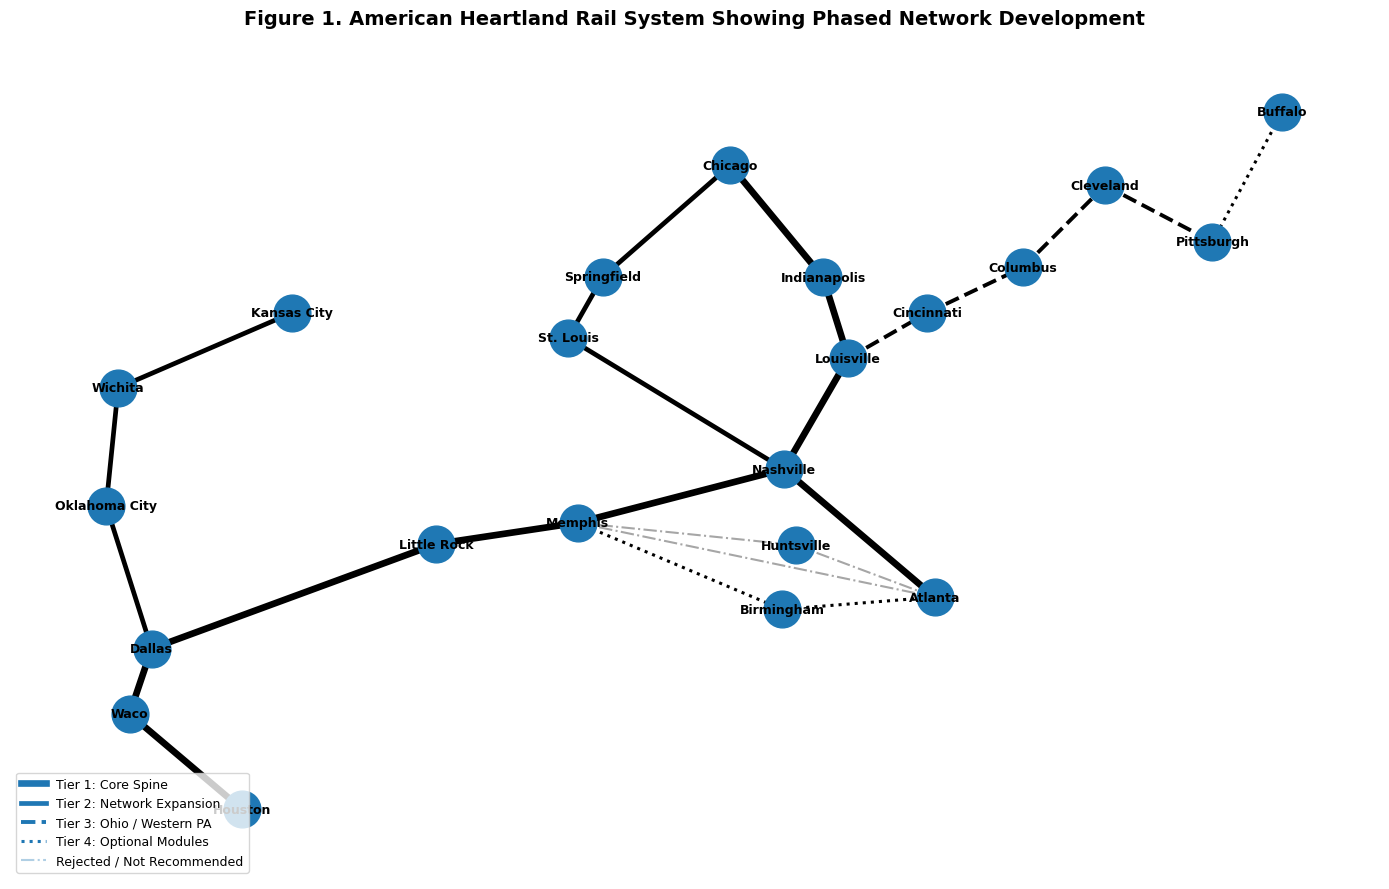

In [120]:
# ============================================================
# FIGURE 1: AMERICAN HEARTLAND RAIL SYSTEM MAP
# Phased network development (Tier 1–Tier 4)
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

print("Building Figure 1: American Heartland Rail system map")

# ------------------------------------------------------------
# NODE POSITIONS
# Approximate lon/lat-style plotting coordinates
# ------------------------------------------------------------
node_pos = {
    "Chicago": (-87.63, 41.88),
    "Springfield": (-89.65, 39.78),
    "Indianapolis": (-86.16, 39.77),
    "Louisville": (-85.76, 38.25),
    "Cincinnati": (-84.51, 39.10),
    "Columbus": (-82.99, 39.96),
    "Cleveland": (-81.69, 41.50),
    "Pittsburgh": (-79.99, 40.44),
    "Buffalo": (-78.88, 42.89),
    "Nashville": (-86.78, 36.16),
    "Atlanta": (-84.39, 33.75),
    "Memphis": (-90.05, 35.15),
    "Birmingham": (-86.81, 33.52),
    "Huntsville": (-86.59, 34.73),
    "Little Rock": (-92.29, 34.75),
    "Dallas": (-96.80, 32.78),
    "Waco": (-97.15, 31.55),
    "Houston": (-95.37, 29.76),
    "Oklahoma City": (-97.52, 35.47),
    "Wichita": (-97.33, 37.69),
    "Kansas City": (-94.58, 39.10),
    "St. Louis": (-90.20, 38.63),
}

# ------------------------------------------------------------
# TIER DEFINITIONS
# ------------------------------------------------------------
tier1_edges = [
    ("Chicago", "Indianapolis"),
    ("Indianapolis", "Louisville"),
    ("Louisville", "Nashville"),
    ("Nashville", "Atlanta"),
    ("Nashville", "Memphis"),
    ("Memphis", "Little Rock"),
    ("Little Rock", "Dallas"),
    ("Dallas", "Waco"),
    ("Waco", "Houston"),
]

tier2_edges = [
    ("Chicago", "Springfield"),
    ("Springfield", "St. Louis"),
    ("St. Louis", "Nashville"),
    ("Dallas", "Oklahoma City"),
    ("Oklahoma City", "Wichita"),
    ("Wichita", "Kansas City"),
]

tier3_edges = [
    ("Louisville", "Cincinnati"),
    ("Cincinnati", "Columbus"),
    ("Columbus", "Cleveland"),
    ("Cleveland", "Pittsburgh"),
]

tier4_edges = [
    ("Memphis", "Birmingham"),
    ("Birmingham", "Atlanta"),
    ("Pittsburgh", "Buffalo"),
]

# Rejected / tested but not recommended
rejected_edges = [
    ("Memphis", "Atlanta"),
    ("Memphis", "Huntsville"),
    ("Huntsville", "Atlanta"),
]

# ------------------------------------------------------------
# BUILD GRAPH
# ------------------------------------------------------------
G = nx.Graph()
for node, pos in node_pos.items():
    G.add_node(node, pos=pos)

for edge in tier1_edges + tier2_edges + tier3_edges + tier4_edges + rejected_edges:
    G.add_edge(*edge)

pos = nx.get_node_attributes(G, "pos")

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

# Tier 4 first (back layer)
nx.draw_networkx_edges(
    G, pos,
    edgelist=tier4_edges,
    width=2.2,
    style="dotted",
    ax=ax,
)

# Tier 3
nx.draw_networkx_edges(
    G, pos,
    edgelist=tier3_edges,
    width=2.8,
    style="dashed",
    ax=ax,
)

# Tier 2
nx.draw_networkx_edges(
    G, pos,
    edgelist=tier2_edges,
    width=3.4,
    style="solid",
    ax=ax,
)

# Tier 1
nx.draw_networkx_edges(
    G, pos,
    edgelist=tier1_edges,
    width=4.8,
    style="solid",
    ax=ax,
)

# Rejected corridors in faint gray
nx.draw_networkx_edges(
    G, pos,
    edgelist=rejected_edges,
    width=1.5,
    style="dashdot",
    alpha=0.35,
    ax=ax,
)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=700,
    ax=ax,
)

# Labels
nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_weight="bold",
    ax=ax,
)

# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], linewidth=4.8, linestyle='solid', label='Tier 1: Core Spine'),
    Line2D([0], [0], linewidth=3.4, linestyle='solid', label='Tier 2: Network Expansion'),
    Line2D([0], [0], linewidth=2.8, linestyle='dashed', label='Tier 3: Ohio / Western PA'),
    Line2D([0], [0], linewidth=2.2, linestyle='dotted', label='Tier 4: Optional Modules'),
    Line2D([0], [0], linewidth=1.5, linestyle='dashdot', alpha=0.35, label='Rejected / Not Recommended'),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    frameon=True,
    fontsize=9
)

# ------------------------------------------------------------
# FORMATTING
# ------------------------------------------------------------
ax.set_title(
    "Figure 1. American Heartland Rail System Showing Phased Network Development",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Building Figure 2: Baseline system performance summary


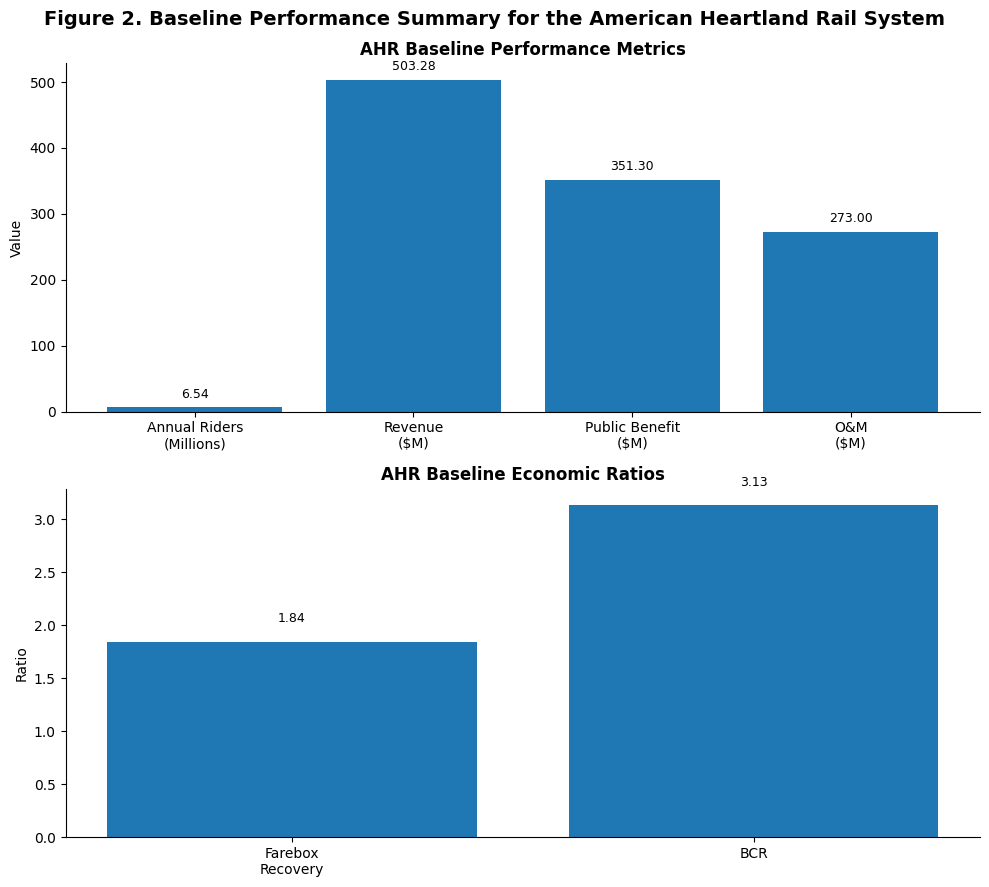

In [121]:
# ============================================================
# FIGURE 2: BASELINE SYSTEM PERFORMANCE SUMMARY
# American Heartland Rail full system
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

print("Building Figure 2: Baseline system performance summary")

# ------------------------------------------------------------
# USE YOUR FINAL FULL SYSTEM BASELINE
# Assumes these already exist:
#   FULL_SEGMENTS
#   FULL_FREQS
#   CITIES
#   PARAMS
#   evaluate_network_variable_freq_safe
# ------------------------------------------------------------
_, baseline_summary = evaluate_network_variable_freq_safe(
    FULL_SEGMENTS, CITIES, PARAMS, FULL_FREQS
)

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
main_metrics = pd.DataFrame({
    "Metric": [
        "Annual Riders\n(Millions)",
        "Revenue\n($M)",
        "Public Benefit\n($M)",
        "O&M\n($M)",
    ],
    "Value": [
        baseline_summary["annual_riders"] / 1_000_000,
        baseline_summary["annual_revenue_m"],
        baseline_summary["annual_public_benefit_m"],
        baseline_summary["annual_om_m"],
    ]
})

ratio_metrics = pd.DataFrame({
    "Metric": [
        "Farebox\nRecovery",
        "BCR"
    ],
    "Value": [
        baseline_summary["farebox_recovery"],
        baseline_summary["bcr_like"],
    ]
})

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# Top panel: main performance metrics
axes[0].bar(main_metrics["Metric"], main_metrics["Value"])
axes[0].set_ylabel("Value")
axes[0].set_title("AHR Baseline Performance Metrics", fontsize=12, fontweight="bold")

# Add value labels
for i, v in enumerate(main_metrics["Value"]):
    axes[0].text(i, v + max(main_metrics["Value"]) * 0.02, f"{v:,.2f}",
                 ha="center", va="bottom", fontsize=9)

# Bottom panel: farebox + BCR
axes[1].bar(ratio_metrics["Metric"], ratio_metrics["Value"])
axes[1].set_ylabel("Ratio")
axes[1].set_title("AHR Baseline Economic Ratios", fontsize=12, fontweight="bold")

# Add value labels
for i, v in enumerate(ratio_metrics["Value"]):
    axes[1].text(i, v + max(ratio_metrics["Value"]) * 0.05, f"{v:,.2f}",
                 ha="center", va="bottom", fontsize=9)

# Clean formatting
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Figure 2. Baseline Performance Summary for the American Heartland Rail System",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

Running Monte Carlo + Building Figure 3

Monte Carlo complete.


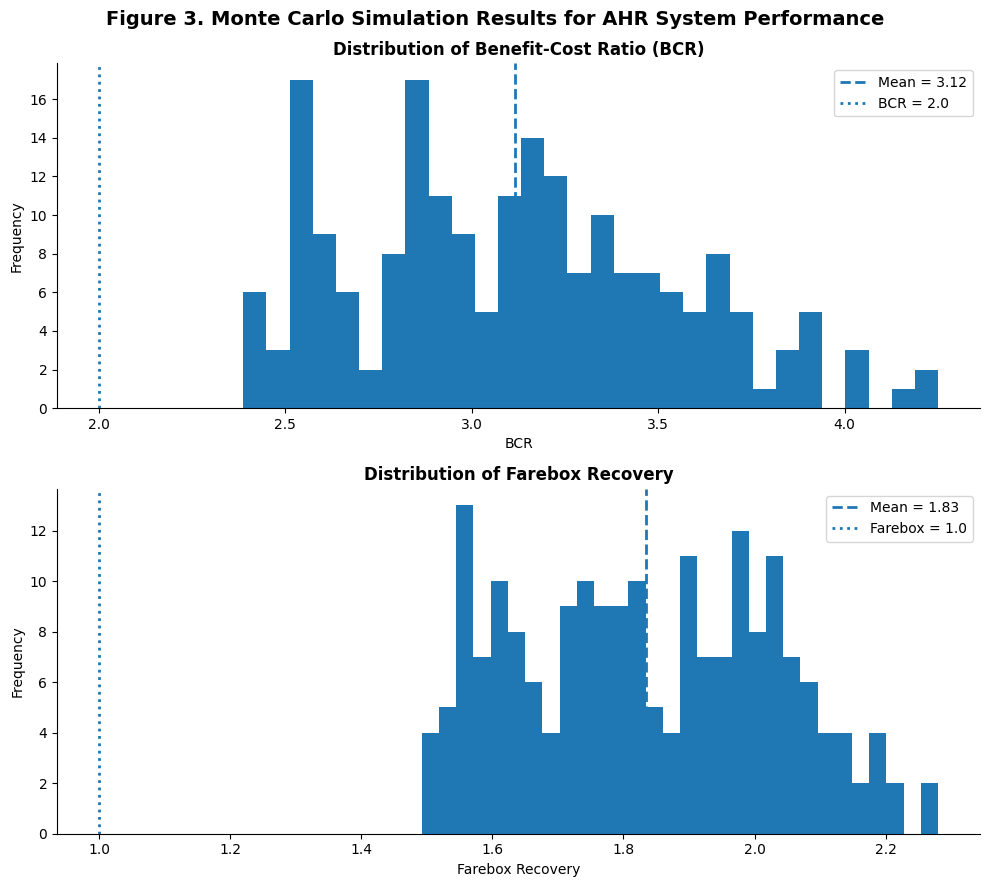

In [123]:
# ============================================================
# FIGURE 3: MONTE CARLO + DISTRIBUTION (ALL-IN-ONE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Running Monte Carlo + Building Figure 3")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_names = [
    "FULL_SEGMENTS",
    "FULL_FREQS",
    "CITIES",
    "PARAMS",
    "evaluate_network_variable_freq_safe",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Missing required objects: " + ", ".join(missing))

# ------------------------------------------------------------
# MONTE CARLO SETTINGS
# ------------------------------------------------------------
N_RUNS = 200

results = []

# ------------------------------------------------------------
# MONTE CARLO LOOP
# ------------------------------------------------------------
for i in range(N_RUNS):

    # Random multipliers
    fare_mult = np.random.uniform(0.8, 1.2)
    om_mult = np.random.uniform(0.8, 1.3)
    demand_mult = np.random.uniform(0.85, 1.15)

    # Copy params
    p = PARAMS.copy()
    p["fare_per_mile"] = PARAMS["fare_per_mile"] * fare_mult
    p["trips_factor"] = PARAMS["trips_factor"] * demand_mult

    # Handle possible missing key safely
    if "om_per_mile" in PARAMS:
        p["om_per_mile"] = PARAMS["om_per_mile"] * om_mult

    # Run model
    _, summary = evaluate_network_variable_freq_safe(
        FULL_SEGMENTS, CITIES, p, FULL_FREQS
    )

    results.append({
        "bcr_like": summary["bcr_like"],
        "farebox_recovery": summary["farebox_recovery"],
    })

# Convert to DataFrame
mc_results_df = pd.DataFrame(results)

print("\nMonte Carlo complete.")

# ------------------------------------------------------------
# BUILD FIGURE 3
# ------------------------------------------------------------
bcr = mc_results_df["bcr_like"]
farebox = mc_results_df["farebox_recovery"]

bcr_mean = bcr.mean()
farebox_mean = farebox.mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# --- BCR ---
axes[0].hist(bcr, bins=30)
axes[0].axvline(bcr_mean, linestyle="--", linewidth=2, label=f"Mean = {bcr_mean:.2f}")
axes[0].axvline(2.0, linestyle=":", linewidth=2, label="BCR = 2.0")

axes[0].set_title("Distribution of Benefit-Cost Ratio (BCR)", fontweight="bold")
axes[0].set_xlabel("BCR")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# --- Farebox ---
axes[1].hist(farebox, bins=30)
axes[1].axvline(farebox_mean, linestyle="--", linewidth=2, label=f"Mean = {farebox_mean:.2f}")
axes[1].axvline(1.0, linestyle=":", linewidth=2, label="Farebox = 1.0")

axes[1].set_title("Distribution of Farebox Recovery", fontweight="bold")
axes[1].set_xlabel("Farebox Recovery")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Clean look
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Figure 3. Monte Carlo Simulation Results for AHR System Performance",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()

Running segment importance analysis + Building Figure 4

=== TOP 10 SEGMENTS BY RIDERSHIP LOSS ===

              removed_segment  distance_miles    rider_loss  rider_loss_pct  revenue_loss_m  revenue_loss_pct  bcr_loss  bcr_loss_pct
7               Dallas - Waco             100 1,622,639.156          24.823         128.965            25.625     0.713        22.769
8              Waco - Houston             185 1,561,161.775          23.883         127.537            25.341     0.624        19.921
0      Chicago - Indianapolis             185 1,455,833.944          22.271         130.404            25.911     0.646        20.651
1   Indianapolis - Louisville             115 1,287,937.439          19.703         137.731            27.366     0.763        24.359
12    Louisville - Cincinnati             100 1,133,281.425          17.337         113.769            22.605     0.617        19.710
2      Louisville - Nashville             175   981,515.294          15.015         128.296     

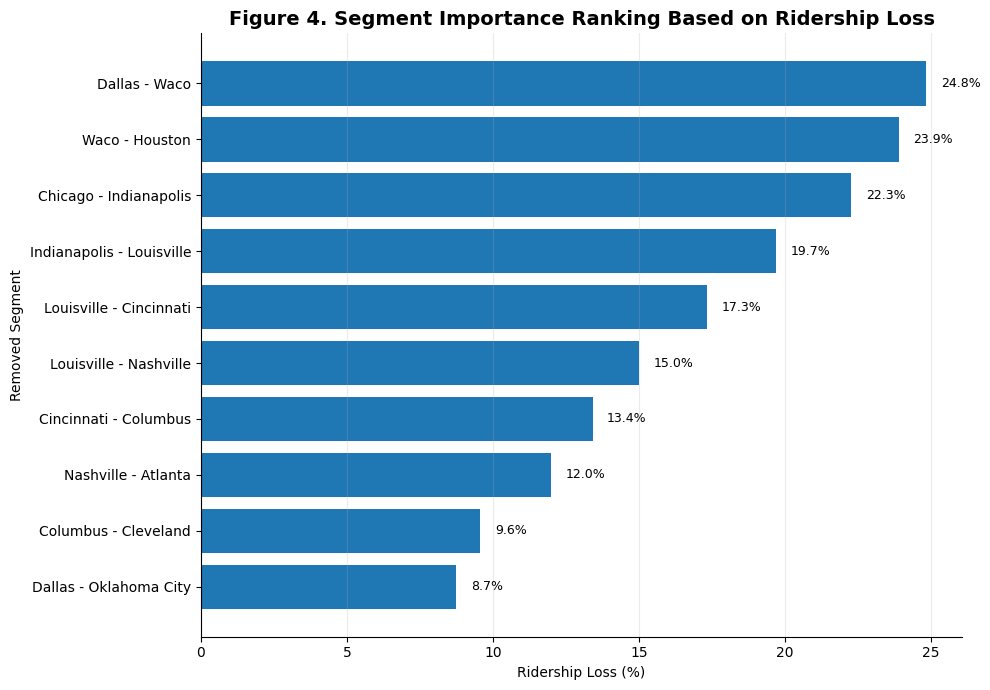

In [124]:
# ============================================================
# FIGURE 4: SEGMENT IMPORTANCE BY RIDERSHIP LOSS
# American Heartland Rail full system
# ============================================================

import copy
import pandas as pd
import matplotlib.pyplot as plt

print("Running segment importance analysis + Building Figure 4")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_names = [
    "FULL_SEGMENTS",
    "FULL_FREQS",
    "CITIES",
    "PARAMS",
    "evaluate_network_variable_freq_safe",
    "rail_segment_key",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Missing required objects: " + ", ".join(missing))

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------
_, base_summary = evaluate_network_variable_freq_safe(
    FULL_SEGMENTS, CITIES, PARAMS, FULL_FREQS
)

base_riders = base_summary["annual_riders"]
base_revenue = base_summary["annual_revenue_m"]
base_bcr = base_summary["bcr_like"]

# ------------------------------------------------------------
# REMOVE ONE SEGMENT AT A TIME
# ------------------------------------------------------------
rows = []

for seg in FULL_SEGMENTS:
    reduced_segments = [
        s for s in FULL_SEGMENTS
        if not (s.a == seg.a and s.b == seg.b and s.dist == seg.dist)
    ]

    reduced_freqs = copy.deepcopy(FULL_FREQS)
    reduced_freqs.pop(rail_segment_key(seg.a, seg.b), None)

    _, summary = evaluate_network_variable_freq_safe(
        reduced_segments, CITIES, PARAMS, reduced_freqs
    )

    riders = summary["annual_riders"]
    revenue = summary["annual_revenue_m"]
    bcr = summary["bcr_like"]

    rider_loss = base_riders - riders
    revenue_loss = base_revenue - revenue
    bcr_loss = base_bcr - bcr

    rows.append({
        "removed_segment": f"{seg.a} - {seg.b}",
        "distance_miles": seg.dist,
        "rider_loss": rider_loss,
        "rider_loss_pct": 100 * rider_loss / base_riders if base_riders > 0 else 0,
        "revenue_loss_m": revenue_loss,
        "revenue_loss_pct": 100 * revenue_loss / base_revenue if base_revenue > 0 else 0,
        "bcr_loss": bcr_loss,
        "bcr_loss_pct": 100 * bcr_loss / base_bcr if base_bcr > 0 else 0,
    })

segment_importance_df = pd.DataFrame(rows).sort_values("rider_loss_pct", ascending=False)

print("\n=== TOP 10 SEGMENTS BY RIDERSHIP LOSS ===\n")
print(segment_importance_df.head(10))

# ------------------------------------------------------------
# BUILD FIGURE 4
# ------------------------------------------------------------
plot_df = segment_importance_df.head(10).copy()
plot_df = plot_df.sort_values("rider_loss_pct", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(plot_df["removed_segment"], plot_df["rider_loss_pct"])

# Add labels
for bar, val in zip(bars, plot_df["rider_loss_pct"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9
    )

ax.set_xlabel("Ridership Loss (%)")
ax.set_ylabel("Removed Segment")
ax.set_title(
    "Figure 4. Segment Importance Ranking Based on Ridership Loss",
    fontsize=14,
    fontweight="bold"
)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

Building Figure 5: Memphis-Atlanta corridor comparison

=== FIGURE 5 DATA ===

         scenario  delta_riders_m  delta_revenue_m  delta_bcr  delta_miles
0  Direct MEM–ATL          -0.678          -58.403     -0.703          380
1     MEM–BHM–ATL          -0.421          -44.490     -0.638          390
2     MEM–HSV–ATL          -0.580          -52.442     -0.680          390


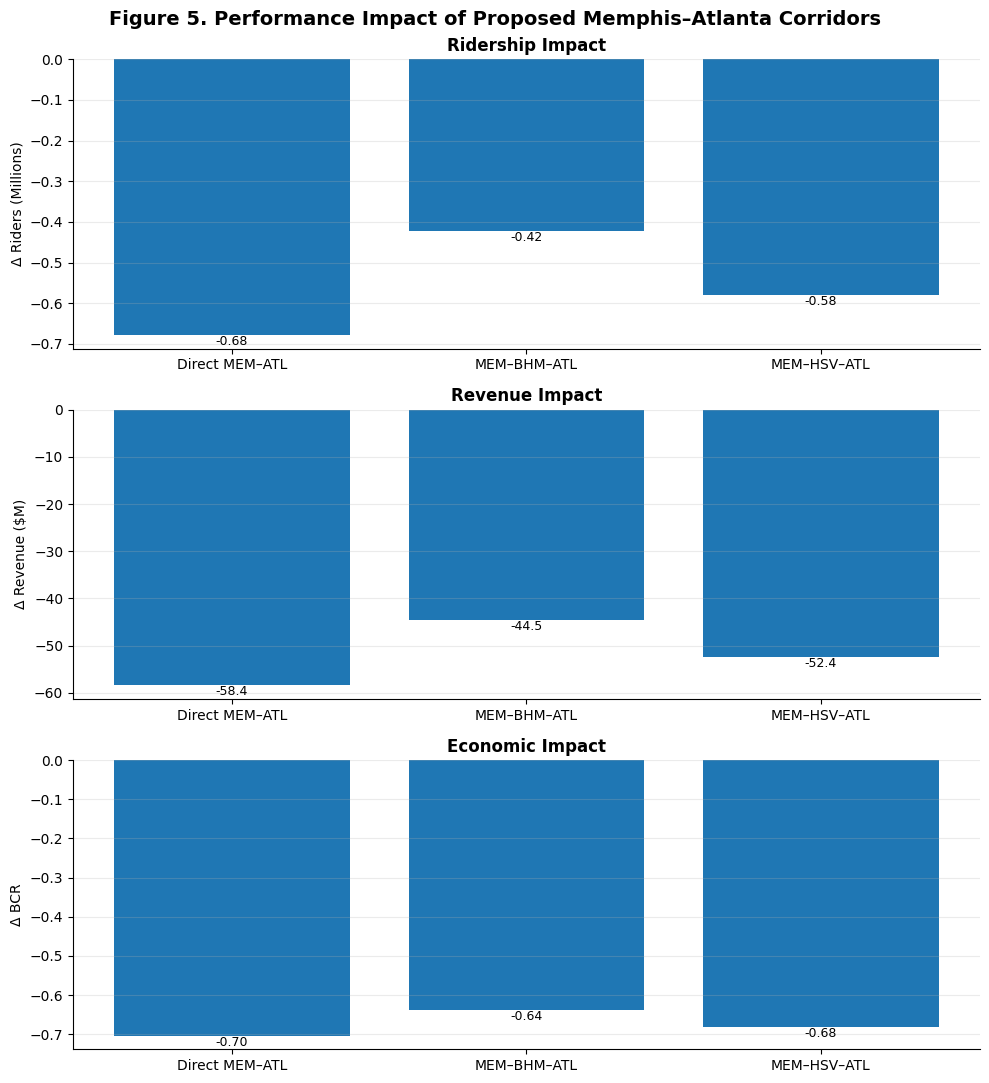

In [125]:
# ============================================================
# FIGURE 5: PERFORMANCE IMPACT OF PROPOSED MEMPHIS-ATLANTA CORRIDORS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

print("Building Figure 5: Memphis-Atlanta corridor comparison")

# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------
required_names = [
    "CITIES",
    "City",
    "Segment",
    "FULL_SEGMENTS",
    "FULL_FREQS",
    "PARAMS",
    "evaluate_network_variable_freq_safe",
    "rail_segment_key",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError("Missing required objects: " + ", ".join(missing))

# ------------------------------------------------------------
# ENSURE CITIES EXIST
# ------------------------------------------------------------
city_additions = {
    "Birmingham": 1.1,
    "Huntsville": 0.5,
}
for city_name, pop in city_additions.items():
    if city_name not in CITIES:
        CITIES[city_name] = City(city_name, pop)

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------
_, base_summary = evaluate_network_variable_freq_safe(
    FULL_SEGMENTS, CITIES, PARAMS, FULL_FREQS
)

# ------------------------------------------------------------
# HELPER
# ------------------------------------------------------------
def copy_freqs(base):
    return {k: v for k, v in base.items()}

# ------------------------------------------------------------
# SCENARIOS
# ------------------------------------------------------------
scenarios = {}

# 1. Direct Memphis -> Atlanta
seg_mem_atl = Segment("Memphis", "Atlanta", 380)
freqs_1 = copy_freqs(FULL_FREQS)
freqs_1[rail_segment_key("Memphis", "Atlanta")] = 8
scenarios["Direct MEM–ATL"] = {
    "segments": FULL_SEGMENTS + [seg_mem_atl],
    "freqs": freqs_1,
}

# 2. Memphis -> Birmingham -> Atlanta
seg_mem_bhm = Segment("Memphis", "Birmingham", 240)
seg_bhm_atl = Segment("Birmingham", "Atlanta", 150)
freqs_2 = copy_freqs(FULL_FREQS)
freqs_2[rail_segment_key("Memphis", "Birmingham")] = 8
freqs_2[rail_segment_key("Birmingham", "Atlanta")] = 8
scenarios["MEM–BHM–ATL"] = {
    "segments": FULL_SEGMENTS + [seg_mem_bhm, seg_bhm_atl],
    "freqs": freqs_2,
}

# 3. Memphis -> Huntsville -> Atlanta
seg_mem_hsv = Segment("Memphis", "Huntsville", 210)
seg_hsv_atl = Segment("Huntsville", "Atlanta", 180)
freqs_3 = copy_freqs(FULL_FREQS)
freqs_3[rail_segment_key("Memphis", "Huntsville")] = 8
freqs_3[rail_segment_key("Huntsville", "Atlanta")] = 8
scenarios["MEM–HSV–ATL"] = {
    "segments": FULL_SEGMENTS + [seg_mem_hsv, seg_hsv_atl],
    "freqs": freqs_3,
}

# ------------------------------------------------------------
# RUN SCENARIOS
# ------------------------------------------------------------
rows = []

for name, cfg in scenarios.items():
    _, summary = evaluate_network_variable_freq_safe(
        cfg["segments"], CITIES, PARAMS, cfg["freqs"]
    )

    rows.append({
        "scenario": name,
        "delta_riders_m": (summary["annual_riders"] - base_summary["annual_riders"]) / 1_000_000,
        "delta_revenue_m": summary["annual_revenue_m"] - base_summary["annual_revenue_m"],
        "delta_bcr": summary["bcr_like"] - base_summary["bcr_like"],
        "delta_miles": summary["route_miles"] - base_summary["route_miles"],
    })

fig5_df = pd.DataFrame(rows)

print("\n=== FIGURE 5 DATA ===\n")
print(fig5_df)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# Panel 1: Delta riders
axes[0].bar(fig5_df["scenario"], fig5_df["delta_riders_m"])
axes[0].set_ylabel("Δ Riders (Millions)")
axes[0].set_title("Ridership Impact", fontweight="bold")

for i, v in enumerate(fig5_df["delta_riders_m"]):
    axes[0].text(i, v, f"{v:.2f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)

# Panel 2: Delta revenue
axes[1].bar(fig5_df["scenario"], fig5_df["delta_revenue_m"])
axes[1].set_ylabel("Δ Revenue ($M)")
axes[1].set_title("Revenue Impact", fontweight="bold")

for i, v in enumerate(fig5_df["delta_revenue_m"]):
    axes[1].text(i, v, f"{v:.1f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)

# Panel 3: Delta BCR
axes[2].bar(fig5_df["scenario"], fig5_df["delta_bcr"])
axes[2].set_ylabel("Δ BCR")
axes[2].set_title("Economic Impact", fontweight="bold")

for i, v in enumerate(fig5_df["delta_bcr"]):
    axes[2].text(i, v, f"{v:.2f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)

# Styling
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Figure 5. Performance Impact of Proposed Memphis–Atlanta Corridors",
    fontsize=14,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()